In [1]:
# ============================================================
# STEP 0: Install and Load Required Packages
# ============================================================

if (!requireNamespace("BiocManager", quietly = TRUE))
  install.packages("BiocManager")

BiocManager::install(c(
  "DESeq2",
  "sva",
  "edgeR",
  "org.Hs.eg.db",
  "AnnotationDbi"
), update = FALSE)

install.packages(c("ggplot2", "data.table", "stringr", "dplyr"))

library(DESeq2)
library(sva)
library(edgeR)
library(org.Hs.eg.db)
library(AnnotationDbi)
library(ggplot2)
library(data.table)
library(stringr)
library(dplyr)

cat("All packages loaded successfully\n")

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.r-project.org

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.0 (2026-04-24 ucrt)

Warning message:
"package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'DESeq2' 'sva' 'edgeR' 'org.Hs.eg.db'
  'AnnotationDbi'"
Installing packages into 'C:/Users/aryan/AppData/Local/R/win-library/4.6'
(as 'lib' is unspecified)



package 'ggplot2' successfully unpacked and MD5 sums checked
package 'data.table' successfully unpacked and MD5 sums checked


Warning message:
"cannot remove prior installation of package 'data.table'"
Warning message in file.copy(savedcopy, lib, recursive = TRUE):
"problem copying C:\Users\aryan\AppData\Local\R\win-library\4.6\00LOCK\data.table\libs\x64\data_table.dll to C:\Users\aryan\AppData\Local\R\win-library\4.6\data.table\libs\x64\data_table.dll: Permission denied"
Warning message:
"restored 'data.table'"


package 'stringr' successfully unpacked and MD5 sums checked
package 'dplyr' successfully unpacked and MD5 sums checked


Warning message:
"cannot remove prior installation of package 'dplyr'"
Warning message in file.copy(savedcopy, lib, recursive = TRUE):
"problem copying C:\Users\aryan\AppData\Local\R\win-library\4.6\00LOCK\dplyr\libs\x64\dplyr.dll to C:\Users\aryan\AppData\Local\R\win-library\4.6\dplyr\libs\x64\dplyr.dll: Permission denied"
Warning message:
"restored 'dplyr'"



The downloaded binary packages are in
	C:\Users\aryan\AppData\Local\Temp\RtmpyMs7r4\downloaded_packages


Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: 'generics'


The following objects are masked from 'package:base':

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: 'BiocGenerics'


The following objects are masked from 'package:stats':

    IQR, mad, sd, var, xtabs


The following objects are masked from 'package:base':

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    unsplit, which.max, which.min



Attaching package: 'S4Vectors'


The following object is masked from 'package:utils':

    findMatches


The follo

All packages loaded successfully


In [2]:
# ============================================================
# STEP 1: Load Your STAR Count Files
# ============================================================

# --- Define your file paths ---
path_lusc <- "C:/Users/aryan/Downloads/TCGA-LUSC.star_counts.tsv.gz"
path_luad <- "C:/Users/aryan/Downloads/TCGA-LUAD.star_counts.tsv.gz"

# --- Read the files ---
# fread() from data.table is used because these files are very large
# It reads .gz compressed files automatically — no need to unzip manually

cat("Loading TCGA-LUSC file...\n")
lusc_raw <- fread(path_lusc, header = TRUE, sep = "\t")

cat("Loading TCGA-LUAD file...\n")
luad_raw <- fread(path_luad, header = TRUE, sep = "\t")

# --- Remove the first 4 STAR summary rows ---
# These rows start with "N_" and are NOT real genes
# Keeping them would corrupt your count matrix

lusc_raw <- lusc_raw[!grepl("^N_", lusc_raw[[1]]), ]
luad_raw <- luad_raw[!grepl("^N_", luad_raw[[1]]), ]

# --- Quick inspection ---
cat("\n--- LUSC: dimensions ---\n")
cat(sprintf("Rows (genes): %d | Columns: %d\n", nrow(lusc_raw), ncol(lusc_raw)))

cat("\n--- LUAD: dimensions ---\n")
cat(sprintf("Rows (genes): %d | Columns: %d\n", nrow(luad_raw), ncol(luad_raw)))

# --- Look at the first few column names ---
cat("\n--- LUSC column names ---\n")
print(colnames(lusc_raw))

cat("\n--- First 3 rows of LUSC (gene info columns only) ---\n")
print(lusc_raw[1:3, 1:6])

Loading TCGA-LUSC file...
Loading TCGA-LUAD file...

--- LUSC: dimensions ---
Rows (genes): 60660 | Columns: 553

--- LUAD: dimensions ---
Rows (genes): 60660 | Columns: 590

--- LUSC column names ---
  [1] "Ensembl_ID"       "TCGA-60-2698-01A" "TCGA-33-4589-01A"
  [4] "TCGA-18-3410-01A" "TCGA-60-2715-01A" "TCGA-22-5471-01A"
  [7] "TCGA-21-1070-01A" "TCGA-NK-A5D1-01A" "TCGA-18-3407-01A"
 [10] "TCGA-60-2710-01A" "TCGA-56-8623-11A" "TCGA-56-8504-01A"
 [13] "TCGA-43-7658-01A" "TCGA-90-6837-01A" "TCGA-90-7964-01A"
 [16] "TCGA-33-4532-01A" "TCGA-43-8115-01A" "TCGA-43-A475-01A"
 [19] "TCGA-22-5481-11A" "TCGA-22-5481-01A" "TCGA-68-A59J-01A"
 [22] "TCGA-66-2780-01A" "TCGA-22-4605-01A" "TCGA-22-5478-11A"
 [25] "TCGA-L3-A524-01A" "TCGA-63-A5MI-01A" "TCGA-77-8139-01A"
 [28] "TCGA-34-7107-11A" "TCGA-34-7107-01A" "TCGA-56-A5DS-01A"
 [31] "TCGA-MF-A522-01A" "TCGA-85-A4QQ-01A" "TCGA-66-2786-01A"
 [34] "TCGA-63-A5MJ-01A" "TCGA-63-A5MM-01A" "TCGA-51-4079-11A"
 [37] "TCGA-79-5596-01A" "TCGA-66-2777-01A"

In [3]:
# ============================================================
# STEP 2: Inspect Data + Map Ensembl IDs → HGNC Gene Symbols
# ============================================================

# --- PART A: Confirm what values are in your matrix ---
# This is critical — it tells us which normalization path to take

cat("=== Checking value types in your data ===\n\n")

# Extract just the numeric sample columns (everything except Ensembl_ID)
sample_cols_lusc <- colnames(lusc_raw)[-1]  # Remove first column (Ensembl_ID)

# Look at a sample of values
sample_values <- as.numeric(lusc_raw[1:10, ..sample_cols_lusc][[1]])
cat("First 10 values from sample 1:\n")
print(round(sample_values, 3))

# Check if values are integers (raw counts) or decimals (normalized)
are_integers <- all(sample_values == floor(sample_values), na.rm = TRUE)

if (are_integers) {
  cat("\n✔ Values appear to be RAW INTEGER COUNTS\n")
  cat("→ We will apply VST normalization via DESeq2\n")
  data_type <- "raw_counts"
} else {
  cat("\n⚠ Values appear to be ALREADY NORMALIZED (decimals detected)\n")
  cat("→ These may be log2-transformed TPM or FPKM values\n")
  cat("→ We will NOT apply VST (cannot normalize already-normalized data)\n")
  cat("→ We will use these values directly after batch correction\n")
  data_type <- "normalized"
}

cat(sprintf("\nValue range: [%.3f, %.3f]\n",
    min(as.matrix(lusc_raw[, -1])),
    max(as.matrix(lusc_raw[, -1]))))

=== Checking value types in your data ===

First 10 values from sample 1:
 [1] 12.003  0.000 10.725 10.588 10.316 10.948 11.635 12.062 12.985 10.849

⚠ Values appear to be ALREADY NORMALIZED (decimals detected)
→ These may be log2-transformed TPM or FPKM values
→ We will NOT apply VST (cannot normalize already-normalized data)
→ We will use these values directly after batch correction

Value range: [0.000, 21.838]


In [4]:
# --- PART B: Strip version numbers from Ensembl IDs ---

cat("\n=== Cleaning Ensembl IDs ===\n")

strip_version <- function(ids) {
  gsub("\\.\\d+$", "", ids)
}

lusc_raw$Ensembl_clean <- strip_version(lusc_raw$Ensembl_ID)
luad_raw$Ensembl_clean <- strip_version(luad_raw$Ensembl_ID)

# Verify it worked
cat("Before cleaning:", lusc_raw$Ensembl_ID[1], "\n")
cat("After cleaning: ", lusc_raw$Ensembl_clean[1], "\n")


=== Cleaning Ensembl IDs ===
Before cleaning: ENSG00000000003.15 
After cleaning:  ENSG00000000003 


In [5]:
# --- PART C: Map Ensembl IDs to HGNC Gene Symbols ---

cat("\n=== Mapping Ensembl IDs to HGNC Gene Symbols ===\n")

map_to_hgnc <- function(df, dataset_name) {
  
  cat(sprintf("Mapping %s...\n", dataset_name))
  
  gene_symbols <- mapIds(
    org.Hs.eg.db,
    keys      = df$Ensembl_clean,
    column    = "SYMBOL",
    keytype   = "ENSEMBL",
    multiVals = "first"
  )
  
  df$HGNC_symbol <- gene_symbols
  
  total    <- nrow(df)
  mapped   <- sum(!is.na(df$HGNC_symbol))
  unmapped <- sum(is.na(df$HGNC_symbol))
  
  cat(sprintf("  Total genes:  %d\n", total))
  cat(sprintf("  Mapped:       %d (%.1f%%)\n", mapped, mapped/total*100))
  cat(sprintf("  Unmapped:     %d (will be removed)\n", unmapped))
  
  # Remove unmapped genes
  df_mapped <- df[!is.na(df$HGNC_symbol), ]
  
  return(df_mapped)
}

lusc_mapped <- map_to_hgnc(lusc_raw, "TCGA-LUSC")
luad_mapped <- map_to_hgnc(luad_raw, "TCGA-LUAD")

# Preview
cat("\n--- Preview: first 5 genes after mapping ---\n")
print(lusc_mapped[1:5, c("Ensembl_ID", "Ensembl_clean", "HGNC_symbol")])


=== Mapping Ensembl IDs to HGNC Gene Symbols ===
Mapping TCGA-LUSC...


'select()' returned 1:many mapping between keys and columns



  Total genes:  60660
  Mapped:       36748 (60.6%)
  Unmapped:     23912 (will be removed)
Mapping TCGA-LUAD...


'select()' returned 1:many mapping between keys and columns



  Total genes:  60660
  Mapped:       36748 (60.6%)
  Unmapped:     23912 (will be removed)

--- Preview: first 5 genes after mapping ---
           Ensembl_ID   Ensembl_clean HGNC_symbol
               <char>          <char>      <char>
1: ENSG00000000003.15 ENSG00000000003      TSPAN6
2:  ENSG00000000005.6 ENSG00000000005        TNMD
3: ENSG00000000419.13 ENSG00000000419        DPM1
4: ENSG00000000457.14 ENSG00000000457       SCYL3
5: ENSG00000000460.17 ENSG00000000460       FIRRM


In [6]:
# ============================================================
# STEP 3: Build Clean Expression Matrix
# ============================================================

# --- PART A: Extract sample columns + gene symbols only ---
# We no longer need Ensembl_ID or Ensembl_clean columns
# Rows = genes, Columns = samples

cat("=== Building Expression Matrix ===\n\n")

build_expression_matrix <- function(df_mapped, dataset_name) {
  
  cat(sprintf("Processing %s...\n", dataset_name))
  
  # Identify sample columns (they all start with "TCGA-")
  all_cols     <- colnames(df_mapped)
  sample_cols  <- all_cols[grepl("^TCGA-", all_cols)]
  
  cat(sprintf("  → Found %d sample columns\n", length(sample_cols)))
  
  # Extract numeric matrix with gene symbols
  expr_mat <- as.matrix(df_mapped[, ..sample_cols])
  rownames(expr_mat) <- df_mapped$HGNC_symbol
  
  cat(sprintf("  → Matrix dimensions: %d genes × %d samples\n",
              nrow(expr_mat), ncol(expr_mat)))
  
  return(expr_mat)
}

lusc_mat <- build_expression_matrix(lusc_mapped, "TCGA-LUSC")
luad_mat <- build_expression_matrix(luad_mapped, "TCGA-LUAD")

=== Building Expression Matrix ===

Processing TCGA-LUSC...
  → Found 552 sample columns
  → Matrix dimensions: 36748 genes × 552 samples
Processing TCGA-LUAD...
  → Found 589 sample columns
  → Matrix dimensions: 36748 genes × 589 samples


In [7]:
# --- PART B: Handle Duplicate Gene Symbols ---
# Keep the row with the highest average expression across samples
# This is the most common and accepted approach

cat("\n=== Handling Duplicate Gene Symbols ===\n\n")

remove_duplicates <- function(expr_mat, dataset_name) {
  
  cat(sprintf("Processing %s...\n", dataset_name))
  
  # Count duplicates before removal
  dup_count <- sum(duplicated(rownames(expr_mat)))
  cat(sprintf("  → Duplicate gene symbols found: %d\n", dup_count))
  
  if (dup_count == 0) {
    cat("  → No duplicates — matrix is clean\n")
    return(expr_mat)
  }
  
  # Calculate average expression per row
  row_means <- rowMeans(expr_mat, na.rm = TRUE)
  
  # Order by mean expression (highest first)
  expr_mat_ordered <- expr_mat[order(-row_means), ]
  
  # Keep first occurrence of each gene symbol (= highest expressed)
  expr_mat_clean <- expr_mat_ordered[!duplicated(rownames(expr_mat_ordered)), ]
  
  cat(sprintf("  → Genes before deduplication: %d\n", nrow(expr_mat)))
  cat(sprintf("  → Genes after deduplication:  %d\n", nrow(expr_mat_clean)))
  
  return(expr_mat_clean)
}

lusc_clean <- remove_duplicates(lusc_mat, "TCGA-LUSC")
luad_clean <- remove_duplicates(luad_mat, "TCGA-LUAD")


=== Handling Duplicate Gene Symbols ===

Processing TCGA-LUSC...
  → Duplicate gene symbols found: 98
  → Genes before deduplication: 36748
  → Genes after deduplication:  36650
Processing TCGA-LUAD...
  → Duplicate gene symbols found: 98
  → Genes before deduplication: 36748
  → Genes after deduplication:  36650


In [8]:
# --- PART C: Final check on both matrices ---

cat("\n=== Final Matrix Summary ===\n")

cat("\nLUSC matrix:\n")
cat(sprintf("  Genes:   %d\n", nrow(lusc_clean)))
cat(sprintf("  Samples: %d\n", ncol(lusc_clean)))
cat(sprintf("  Value range: [%.3f, %.3f]\n",
            min(lusc_clean), max(lusc_clean)))

cat("\nLUAD matrix:\n")
cat(sprintf("  Genes:   %d\n", nrow(luad_clean)))
cat(sprintf("  Samples: %d\n", ncol(luad_clean)))
cat(sprintf("  Value range: [%.3f, %.3f]\n",
            min(luad_clean), max(luad_clean)))

# Preview top-left corner of matrix
cat("\n--- Preview: LUSC matrix (5 genes × 4 samples) ---\n")
print(round(lusc_clean[1:5, 1:4], 3))


=== Final Matrix Summary ===

LUSC matrix:
  Genes:   36650
  Samples: 552
  Value range: [0.000, 21.838]

LUAD matrix:
  Genes:   36650
  Samples: 589
  Value range: [0.000, 22.391]

--- Preview: LUSC matrix (5 genes × 4 samples) ---
       TCGA-60-2698-01A TCGA-33-4589-01A TCGA-18-3410-01A TCGA-60-2715-01A
MT-CO1           18.175           16.405           18.572           19.645
MT-ND4           17.739           15.521           17.440           19.206
ACTB             18.820           18.710           18.054           18.788
EEF1A1           18.733           17.715           18.904           18.473
FTL              18.420           18.520           17.002           18.806


In [9]:
# ============================================================
# STEP 4: Merge LUSC and LUAD into One Combined Matrix
# ============================================================

# --- PART A: Find common genes between both datasets ---

cat("=== Merging Datasets ===\n\n")

# Find genes present in BOTH matrices
common_genes <- intersect(rownames(lusc_clean), rownames(luad_clean))

cat(sprintf("Genes in LUSC:          %d\n", nrow(lusc_clean)))
cat(sprintf("Genes in LUAD:          %d\n", nrow(luad_clean)))
cat(sprintf("Common genes (kept):    %d\n", length(common_genes)))
cat(sprintf("Genes dropped:          %d\n",
            nrow(lusc_clean) + nrow(luad_clean) - 2 * length(common_genes)))

=== Merging Datasets ===

Genes in LUSC:          36650
Genes in LUAD:          36650
Common genes (kept):    36650
Genes dropped:          0


In [10]:
# --- PART B: Subset both matrices to common genes ---
# This ensures both matrices have identical rows
# before we combine them side by side

lusc_common <- lusc_clean[common_genes, ]
luad_common <- luad_clean[common_genes, ]

# Confirm dimensions match on genes
cat(sprintf("\nLUSC subset: %d genes × %d samples\n",
            nrow(lusc_common), ncol(lusc_common)))
cat(sprintf("LUAD subset: %d genes × %d samples\n",
            nrow(luad_common), ncol(luad_common)))

# Confirm row order is identical (critical before merging)
identical_rows <- identical(rownames(lusc_common), rownames(luad_common))
cat(sprintf("\nRow order identical: %s\n",
            ifelse(identical_rows, "YES - safe to merge", "NO - something went wrong")))


LUSC subset: 36650 genes × 552 samples
LUAD subset: 36650 genes × 589 samples

Row order identical: YES - safe to merge


In [11]:
# --- PART C: Combine side by side (cbind) ---
# cbind = column bind = stick matrices side by side
# Rows (genes) stay the same, columns (samples) are combined

combined_matrix <- cbind(lusc_common, luad_common)

cat(sprintf("\n=== Combined Matrix ===\n"))
cat(sprintf("Total genes:    %d\n", nrow(combined_matrix)))
cat(sprintf("Total samples:  %d\n", ncol(combined_matrix)))
cat(sprintf("  LUSC samples: %d\n", ncol(lusc_common)))
cat(sprintf("  LUAD samples: %d\n", ncol(luad_common)))
cat(sprintf("Value range:    [%.3f, %.3f]\n",
            min(combined_matrix), max(combined_matrix)))


=== Combined Matrix ===
Total genes:    36650
Total samples:  1141
  LUSC samples: 552
  LUAD samples: 589
Value range:    [0.000, 22.391]


In [12]:
# --- PART D: Create batch labels ---
# This is very important for the next step (batch correction)
# We need to tell ComBat which samples came from which dataset
# LUSC = batch 1, LUAD = batch 2

batch_labels <- c(
  rep("LUSC", ncol(lusc_common)),
  rep("LUAD", ncol(luad_common))
)

# Verify labels match sample count
cat(sprintf("\n=== Batch Labels ===\n"))
cat(sprintf("LUSC labels: %d\n", sum(batch_labels == "LUSC")))
cat(sprintf("LUAD labels: %d\n", sum(batch_labels == "LUAD")))
cat(sprintf("Total labels: %d | Total samples: %d\n",
            length(batch_labels), ncol(combined_matrix)))

# They must be equal — if not something is wrong
if (length(batch_labels) == ncol(combined_matrix)) {
  cat("✔ Batch labels match sample count — ready for batch correction\n")
} else {
  cat("✘ ERROR: Mismatch between labels and samples — check your matrices\n")
}


=== Batch Labels ===
LUSC labels: 552
LUAD labels: 589
Total labels: 1141 | Total samples: 1141
✔ Batch labels match sample count — ready for batch correction


In [13]:
# --- PART E: Preview the combined matrix ---

cat("\n--- Preview: combined matrix (5 genes × 6 samples) ---\n")

# Show 3 LUSC + 3 LUAD samples side by side
preview_cols <- c(1:3, (ncol(lusc_common)+1):(ncol(lusc_common)+3))
print(round(combined_matrix[1:5, preview_cols], 3))

cat("\n--- Sample names confirm dataset source ---\n")
cat("First 3 columns (should be LUSC barcodes):\n")
print(colnames(combined_matrix)[1:3])
cat("Last 3 columns (should be LUAD barcodes):\n")
print(tail(colnames(combined_matrix), 3))


--- Preview: combined matrix (5 genes × 6 samples) ---
       TCGA-60-2698-01A TCGA-33-4589-01A TCGA-18-3410-01A TCGA-38-7271-01A
MT-CO1           18.175           16.405           18.572           18.358
MT-ND4           17.739           15.521           17.440           18.367
ACTB             18.820           18.710           18.054           17.812
EEF1A1           18.733           17.715           18.904           17.612
FTL              18.420           18.520           17.002           17.019
       TCGA-55-7914-01A TCGA-95-7043-01A
MT-CO1           17.439           18.758
MT-ND4           17.318           18.745
ACTB             17.704           16.267
EEF1A1           17.245           16.019
FTL              16.488           20.045

--- Sample names confirm dataset source ---
First 3 columns (should be LUSC barcodes):
[1] "TCGA-60-2698-01A" "TCGA-33-4589-01A" "TCGA-18-3410-01A"
Last 3 columns (should be LUAD barcodes):
[1] "TCGA-44-A47G-01A" "TCGA-55-6969-01A" "TCGA-55-6969-1

=== Visualizing data BEFORE batch correction ===

✔ PCA plot saved: PCA_before_batch_correction.png


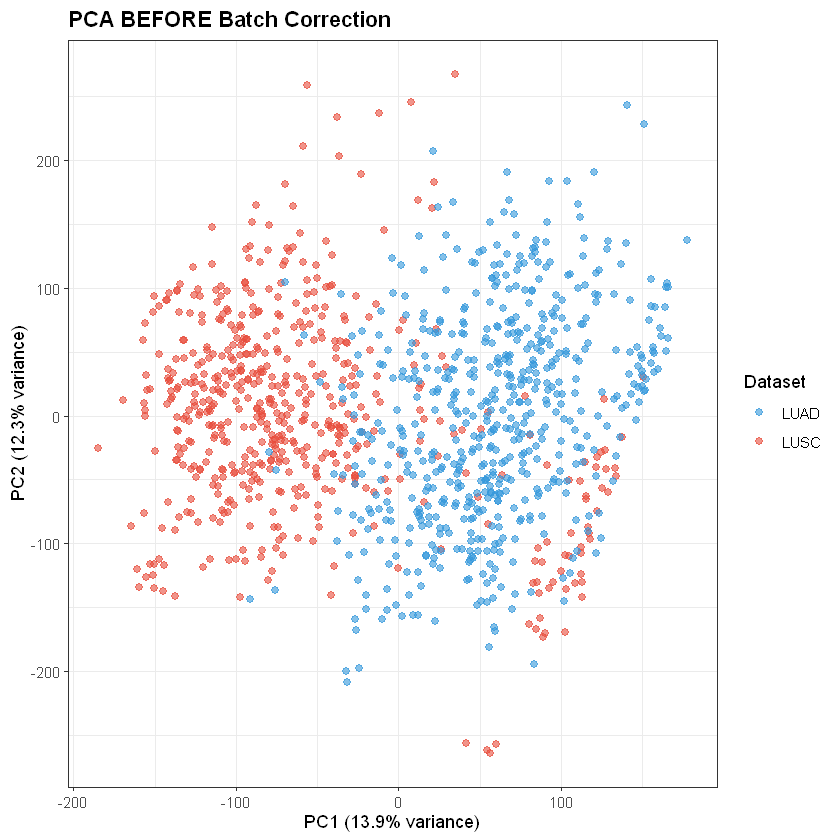

In [14]:
# ============================================================
# STEP 5: Batch Correction with ComBat
# ============================================================

# --- PART A: Visualize batch effect BEFORE correction ---
# We do a quick PCA to SEE the batch effect before removing it
# This helps confirm that batch correction actually worked

cat("=== Visualizing data BEFORE batch correction ===\n\n")

# PCA on combined matrix (transpose: samples as rows)
pca_before <- prcomp(t(combined_matrix), scale. = FALSE, center = TRUE)

# Build plotting dataframe
pca_before_df <- data.frame(
  PC1     = pca_before$x[, 1],
  PC2     = pca_before$x[, 2],
  Dataset = batch_labels,
  Sample  = colnames(combined_matrix)
)

# Calculate variance explained by PC1 and PC2
var_exp_before <- round(summary(pca_before)$importance[2, 1:2] * 100, 1)

# Plot
plot_before <- ggplot(pca_before_df, aes(x = PC1, y = PC2, color = Dataset)) +
  geom_point(alpha = 0.6, size = 2) +
  scale_color_manual(values = c("LUSC" = "#E74C3C", "LUAD" = "#3498DB")) +
  labs(
    title    = "PCA BEFORE Batch Correction",
    x        = sprintf("PC1 (%.1f%% variance)", var_exp_before[1]),
    y        = sprintf("PC2 (%.1f%% variance)", var_exp_before[2])
  ) +
  theme_bw() +
  theme(plot.title = element_text(face = "bold"))

# Save plot
ggsave("PCA_before_batch_correction.png", plot_before,
       width = 8, height = 6, dpi = 150)

cat("✔ PCA plot saved: PCA_before_batch_correction.png\n")
print(plot_before)

In [15]:
# --- PART B: Apply ComBat batch correction ---
# ComBat expects:
#   dat   = genes × samples matrix (rows = genes, cols = samples)
#   batch = vector of batch labels (one per sample)
# It returns a corrected matrix of the same dimensions

cat("\n=== Applying ComBat Batch Correction ===\n\n")
cat("This may take 1-3 minutes depending on matrix size...\n\n")

# Run ComBat
# mod = NULL means we are not protecting any biological covariate
# If you have tumor vs normal labels, you can add them here later
corrected_matrix <- ComBat(
  dat   = combined_matrix,   # genes × samples
  batch = batch_labels,      # "LUSC" or "LUAD" per sample
  mod   = NULL,              # No biological covariate to protect
  par.prior = TRUE,          # Parametric adjustment (faster, standard)
  prior.plots = FALSE        # Set TRUE if you want diagnostic plots
)

cat(sprintf("\n✔ Batch correction complete\n"))
cat(sprintf("Corrected matrix: %d genes × %d samples\n",
            nrow(corrected_matrix), ncol(corrected_matrix)))
cat(sprintf("Value range after correction: [%.3f, %.3f]\n",
            min(corrected_matrix), max(corrected_matrix)))


=== Applying ComBat Batch Correction ===

This may take 1-3 minutes depending on matrix size...

Found 1442 genes with uniform expression within a single batch (all zeros); these will not be adjusted for batch.


Found2batches

Adjusting for0covariate(s) or covariate level(s)

Standardizing Data across genes

Fitting L/S model and finding priors

Finding parametric adjustments

Adjusting the Data





✔ Batch correction complete
Corrected matrix: 36650 genes × 1141 samples
Value range after correction: [-4.758, 34.247]



=== Visualizing data AFTER batch correction ===
✔ PCA plot saved: PCA_after_batch_correction.png


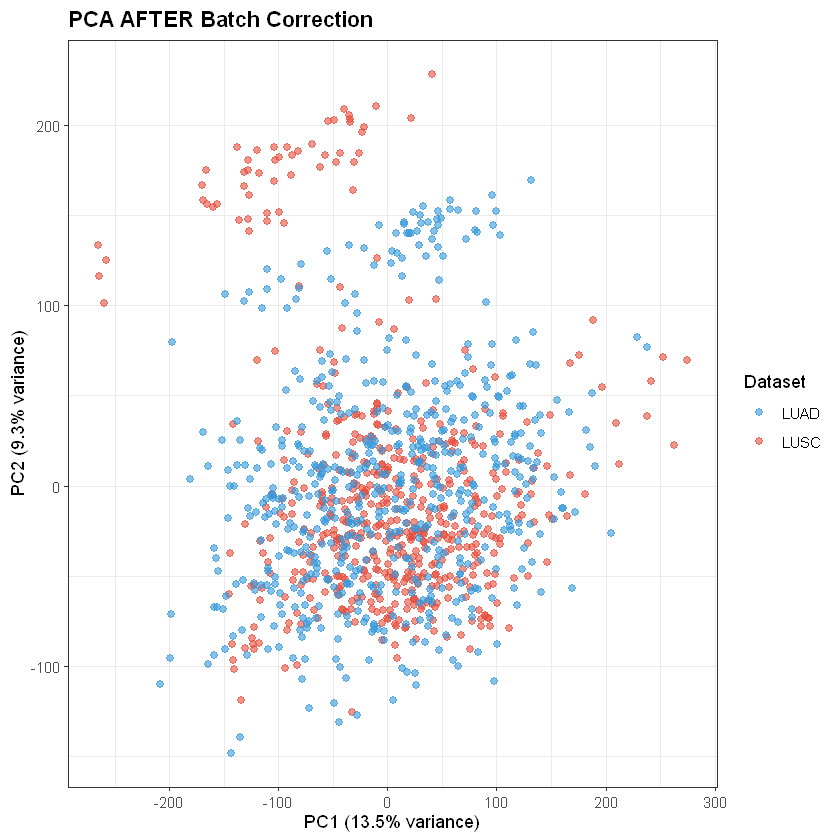

In [16]:
# --- PART C: Visualize AFTER correction ---
# Now we repeat the PCA on the corrected matrix
# If ComBat worked: LUSC and LUAD should be more intermixed
# They may still separate (that is BIOLOGY not batch effect)
# but the separation should be less extreme

cat("\n=== Visualizing data AFTER batch correction ===\n")

pca_after <- prcomp(t(corrected_matrix), scale. = FALSE, center = TRUE)

pca_after_df <- data.frame(
  PC1     = pca_after$x[, 1],
  PC2     = pca_after$x[, 2],
  Dataset = batch_labels,
  Sample  = colnames(corrected_matrix)
)

var_exp_after <- round(summary(pca_after)$importance[2, 1:2] * 100, 1)

plot_after <- ggplot(pca_after_df, aes(x = PC1, y = PC2, color = Dataset)) +
  geom_point(alpha = 0.6, size = 2) +
  scale_color_manual(values = c("LUSC" = "#E74C3C", "LUAD" = "#3498DB")) +
  labs(
    title    = "PCA AFTER Batch Correction",
    x        = sprintf("PC1 (%.1f%% variance)", var_exp_after[1]),
    y        = sprintf("PC2 (%.1f%% variance)", var_exp_after[2])
  ) +
  theme_bw() +
  theme(plot.title = element_text(face = "bold"))

ggsave("PCA_after_batch_correction.png", plot_after,
       width = 8, height = 6, dpi = 150)

cat("✔ PCA plot saved: PCA_after_batch_correction.png\n")
print(plot_after)

In [17]:
# --- PART D: Quick sanity check on corrected values ---

cat("\n=== Sanity Check on Corrected Matrix ===\n")

# Check for any NA or infinite values introduced by ComBat
na_count  <- sum(is.na(corrected_matrix))
inf_count <- sum(is.infinite(corrected_matrix))

cat(sprintf("NA values:       %d\n", na_count))
cat(sprintf("Infinite values: %d\n", inf_count))

if (na_count == 0 & inf_count == 0) {
  cat("✔ Matrix is clean — no NA or infinite values\n")
} else {
  cat("⚠ Issues found — we will clean these in next step\n")
}

# Preview corrected values
cat("\n--- Preview: corrected matrix (5 genes × 4 samples) ---\n")
print(round(corrected_matrix[1:5, 1:4], 3))


=== Sanity Check on Corrected Matrix ===
NA values:       0
Infinite values: 0
✔ Matrix is clean — no NA or infinite values

--- Preview: corrected matrix (5 genes × 4 samples) ---
       TCGA-60-2698-01A TCGA-33-4589-01A TCGA-18-3410-01A TCGA-60-2715-01A
MT-CO1           18.262           16.350           18.691           19.850
MT-ND4           17.598           15.021           17.251           19.302
ACTB             18.800           18.681           17.964           18.766
EEF1A1           18.576           17.524           18.753           18.307
FTL              18.327           18.429           16.871           18.723


In [18]:
# ============================================================
# STEP 6: Quality Control and Outlier Removal
# ============================================================

# --- PART A: Method 1 — PCA Distance Outlier Detection ---
# Calculate how far each sample sits from the group center
# Samples beyond 3 standard deviations are flagged as outliers

cat("=== METHOD 1: PCA Distance ===\n\n")

# Use the PCA we already computed on corrected matrix
pca_scores <- pca_after$x[, 1:10]  # Use first 10 PCs

# Calculate Euclidean distance of each sample from the center (origin)
# The center of PCA space is 0,0 — distance tells us how "extreme" a sample is
pca_distances <- sqrt(rowSums(pca_scores^2))

# Flag samples beyond 3 standard deviations from mean distance
mean_dist <- mean(pca_distances)
sd_dist   <- sd(pca_distances)
threshold <- mean_dist + 3 * sd_dist

outliers_pca <- names(pca_distances[pca_distances > threshold])

cat(sprintf("Mean PCA distance:     %.2f\n", mean_dist))
cat(sprintf("SD of distances:       %.2f\n", sd_dist))
cat(sprintf("Threshold (mean+3SD):  %.2f\n", threshold))
cat(sprintf("Outliers detected:     %d\n", length(outliers_pca)))

if (length(outliers_pca) > 0) {
  cat("Outlier samples:\n")
  print(outliers_pca)
}

=== METHOD 1: PCA Distance ===

Mean PCA distance:     133.19
SD of distances:       46.67
Threshold (mean+3SD):  273.20
Outliers detected:     18
Outlier samples:
 [1] "TCGA-51-4079-11A" "TCGA-33-4566-01A" "TCGA-51-4080-11A" "TCGA-43-3394-11A"
 [5] "TCGA-51-4081-11A" "TCGA-18-3417-01A" "TCGA-44-2656-01B" "TCGA-44-3918-01B"
 [9] "TCGA-44-5645-01B" "TCGA-44-2665-01B" "TCGA-44-2668-01B" "TCGA-44-2666-01B"
[13] "TCGA-44-6146-01B" "TCGA-44-3917-01B" "TCGA-44-6147-01B" "TCGA-44-6775-01C"
[17] "TCGA-44-4112-01B" "TCGA-44-2662-01B"



=== METHOD 2: Sample-to-Sample Correlation ===

Calculating correlation matrix (may take 1-2 minutes)...
Correlation threshold:  0.85
Mean correlation range: [0.872, 0.962]
Outliers detected:      0
✔ Plot saved: QC_correlation_distribution.png


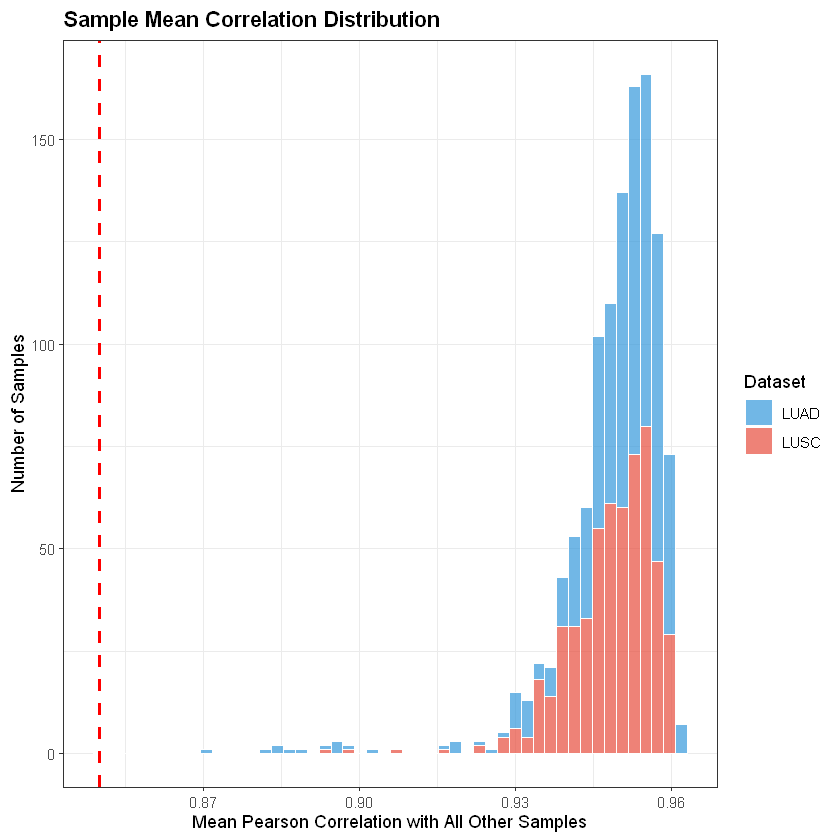

In [19]:
# --- PART B: Method 2 — Sample-to-Sample Correlation ---
# Calculate Pearson correlation between every pair of samples
# A good quality sample should correlate well (r > 0.85) with most others
# A poor quality sample will have low average correlation

cat("\n=== METHOD 2: Sample-to-Sample Correlation ===\n\n")
cat("Calculating correlation matrix (may take 1-2 minutes)...\n")

# Calculate correlation between all samples
# We transpose so samples are columns for cor()
cor_matrix <- cor(corrected_matrix, method = "pearson")

# For each sample, calculate its mean correlation with ALL other samples
mean_cor <- rowMeans(cor_matrix)

# Flag samples with mean correlation below threshold
# 0.85 is standard — adjust down to 0.80 if too many flagged
cor_threshold  <- 0.85
outliers_cor   <- names(mean_cor[mean_cor < cor_threshold])

cat(sprintf("Correlation threshold:  %.2f\n", cor_threshold))
cat(sprintf("Mean correlation range: [%.3f, %.3f]\n",
            min(mean_cor), max(mean_cor)))
cat(sprintf("Outliers detected:      %d\n", length(outliers_cor)))

if (length(outliers_cor) > 0) {
  cat("Outlier samples:\n")
  print(outliers_cor)
}

# Plot mean correlation distribution
cor_df <- data.frame(
  Sample  = names(mean_cor),
  MeanCor = mean_cor,
  Dataset = batch_labels
)

plot_cor <- ggplot(cor_df, aes(x = MeanCor, fill = Dataset)) +
  geom_histogram(bins = 50, alpha = 0.7, color = "white") +
  geom_vline(xintercept = cor_threshold,
             color = "red", linetype = "dashed", linewidth = 1) +
  scale_fill_manual(values = c("LUSC" = "#E74C3C", "LUAD" = "#3498DB")) +
  labs(
    title    = "Sample Mean Correlation Distribution",
    x        = "Mean Pearson Correlation with All Other Samples",
    y        = "Number of Samples"
  ) +
  theme_bw() +
  theme(plot.title = element_text(face = "bold"))

ggsave("QC_correlation_distribution.png", plot_cor,
       width = 8, height = 5, dpi = 150)

cat("✔ Plot saved: QC_correlation_distribution.png\n")
print(plot_cor)

In [20]:
# --- PART C: Method 3 — Expression Distribution Check ---
# Check each sample's median expression level
# Samples with very low or very high median may have technical problems

cat("\n=== METHOD 3: Expression Distribution ===\n\n")

# Calculate median expression per sample
sample_medians <- apply(corrected_matrix, 2, median)

# Flag samples beyond 3 SD from mean median
mean_med  <- mean(sample_medians)
sd_med    <- sd(sample_medians)
upper_med <- mean_med + 3 * sd_med
lower_med <- mean_med - 3 * sd_med

outliers_expr <- names(sample_medians[
  sample_medians > upper_med | sample_medians < lower_med
])

cat(sprintf("Median expression range: [%.3f, %.3f]\n",
            min(sample_medians), max(sample_medians)))
cat(sprintf("Lower threshold:         %.3f\n", lower_med))
cat(sprintf("Upper threshold:         %.3f\n", upper_med))
cat(sprintf("Outliers detected:       %d\n", length(outliers_expr)))

if (length(outliers_expr) > 0) {
  cat("Outlier samples:\n")
  print(outliers_expr)
}


=== METHOD 3: Expression Distribution ===

Median expression range: [0.903, 4.990]
Lower threshold:         1.226
Upper threshold:         4.629
Outliers detected:       5
Outlier samples:
[1] "TCGA-33-4566-01A" "TCGA-21-5782-01A" "TCGA-33-4583-01A" "TCGA-18-3417-01A"
[5] "TCGA-NJ-A55R-01A"


In [21]:
# --- PART D: Combine all 3 methods ---
# Only remove samples flagged by 2 or more methods
# This prevents removing samples based on one method alone
# which could be too aggressive

cat("\n=== Combining Outlier Results ===\n\n")

# Count how many methods flagged each sample
all_samples  <- colnames(corrected_matrix)
flag_counts  <- rep(0, length(all_samples))
names(flag_counts) <- all_samples

# Add 1 for each method that flagged each sample
flag_counts[outliers_pca]  <- flag_counts[outliers_pca]  + 1
flag_counts[outliers_cor]  <- flag_counts[outliers_cor]  + 1
flag_counts[outliers_expr] <- flag_counts[outliers_expr] + 1

# Samples flagged by 2 or more methods = remove
samples_to_remove <- names(flag_counts[flag_counts >= 2])

cat(sprintf("Flagged by PCA only:         %d\n",
            sum(flag_counts == 1 & names(flag_counts) %in% outliers_pca)))
cat(sprintf("Flagged by correlation only: %d\n",
            sum(flag_counts == 1 & names(flag_counts) %in% outliers_cor)))
cat(sprintf("Flagged by expression only:  %d\n",
            sum(flag_counts == 1 & names(flag_counts) %in% outliers_expr)))
cat(sprintf("Flagged by 2+ methods:       %d  ← THESE WILL BE REMOVED\n",
            length(samples_to_remove)))

if (length(samples_to_remove) > 0) {
  cat("\nSamples to be removed:\n")
  print(samples_to_remove)
}


=== Combining Outlier Results ===

Flagged by PCA only:         16
Flagged by correlation only: 0
Flagged by expression only:  3
Flagged by 2+ methods:       2  ← THESE WILL BE REMOVED

Samples to be removed:
[1] "TCGA-33-4566-01A" "TCGA-18-3417-01A"


In [22]:
# --- PART E: Remove outliers and produce final clean matrix ---

cat("\n=== Removing Outliers ===\n\n")

if (length(samples_to_remove) == 0) {
  cat("✔ No outliers to remove — all samples pass QC\n")
  final_matrix <- corrected_matrix
  final_batch  <- batch_labels

} else {
  # Remove outlier columns from matrix
  keep_samples <- setdiff(colnames(corrected_matrix), samples_to_remove)
  final_matrix <- corrected_matrix[, keep_samples]

  # Update batch labels to match
  final_batch  <- batch_labels[colnames(corrected_matrix) %in% keep_samples]

  cat(sprintf("Samples before QC: %d\n", ncol(corrected_matrix)))
  cat(sprintf("Samples removed:   %d\n", length(samples_to_remove)))
  cat(sprintf("Samples after QC:  %d\n", ncol(final_matrix)))
}

cat(sprintf("\n=== FINAL CLEAN MATRIX ===\n"))
cat(sprintf("Genes:   %d\n", nrow(final_matrix)))
cat(sprintf("Samples: %d\n", ncol(final_matrix)))
cat(sprintf("Value range: [%.3f, %.3f]\n",
            min(final_matrix), max(final_matrix)))


=== Removing Outliers ===

Samples before QC: 1141
Samples removed:   2
Samples after QC:  1139

=== FINAL CLEAN MATRIX ===
Genes:   36650
Samples: 1139
Value range: [-4.758, 34.247]


In [23]:
# --- PART F: Save the final matrix to disk ---
# This is your analysis-ready file for all downstream work

cat("\n=== Saving Final Matrix ===\n")

# Convert to dataframe with gene names as first column
final_df <- data.frame(
  Gene = rownames(final_matrix),
  final_matrix,
  check.names = FALSE
)

# Save as compressed file
output_path <- "C:/Users/aryan/Downloads/TCGA_LUSC_LUAD_final_expression.tsv"

write.table(
  final_df,
  file      = output_path,
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

cat(sprintf("✔ Final matrix saved to:\n  %s\n", output_path))
cat(sprintf("  Size: %d genes × %d samples\n",
            nrow(final_matrix), ncol(final_matrix)))


=== Saving Final Matrix ===
✔ Final matrix saved to:
  C:/Users/aryan/Downloads/TCGA_LUSC_LUAD_final_expression.tsv
  Size: 36650 genes × 1139 samples


In [24]:
# ============================================================
# FINAL STEP: PCA Plot on Clean Preprocessed Matrix
# ============================================================

# --- PART A: Run PCA on final clean matrix ---

cat("=== Running Final PCA ===\n\n")

# Transpose: PCA needs samples as rows, genes as columns
pca_final <- prcomp(
  t(final_matrix),
  center = TRUE,
  scale. = FALSE   # Already log2 normalized — no need to rescale
)

# Calculate variance explained by each PC
var_explained <- summary(pca_final)$importance[2, ] * 100

cat(sprintf("PC1 variance explained: %.2f%%\n", var_explained[1]))
cat(sprintf("PC2 variance explained: %.2f%%\n", var_explained[2]))
cat(sprintf("PC3 variance explained: %.2f%%\n", var_explained[3]))
cat(sprintf("Total (PC1+PC2):        %.2f%%\n",
            var_explained[1] + var_explained[2]))

=== Running Final PCA ===

PC1 variance explained: 13.28%
PC2 variance explained: 9.28%
PC3 variance explained: 4.08%
Total (PC1+PC2):        22.55%


In [25]:
# --- PART B: Build PCA dataframe with sample metadata ---
# We extract useful information from TCGA barcodes
# TCGA barcode structure: TCGA-XX-XXXX-01A
#                                         ^^
#                                         01 = tumor
#                                         11 = normal

cat("\n=== Extracting Sample Metadata from Barcodes ===\n")

pca_final_df <- data.frame(
  PC1     = pca_final$x[, 1],
  PC2     = pca_final$x[, 2],
  PC3     = pca_final$x[, 3],
  Sample  = colnames(final_matrix),
  Dataset = final_batch
)

# Extract sample type from barcode (positions 14-15)
# "01" = Primary Tumor, "11" = Solid Normal Tissue
pca_final_df$SampleType <- ifelse(
  substr(pca_final_df$Sample, 14, 15) == "11",
  "Normal", "Tumor"
)

# Create a combined label for plotting
pca_final_df$Group <- paste(pca_final_df$Dataset,
                             pca_final_df$SampleType, sep = "_")

# Count groups
cat("\nSample breakdown:\n")
print(table(pca_final_df$Group))


=== Extracting Sample Metadata from Barcodes ===

Sample breakdown:

LUAD_Normal  LUAD_Tumor LUSC_Normal  LUSC_Tumor 
         59         530          51         499 


✔ Plot saved: Final_PCA_by_Dataset.png


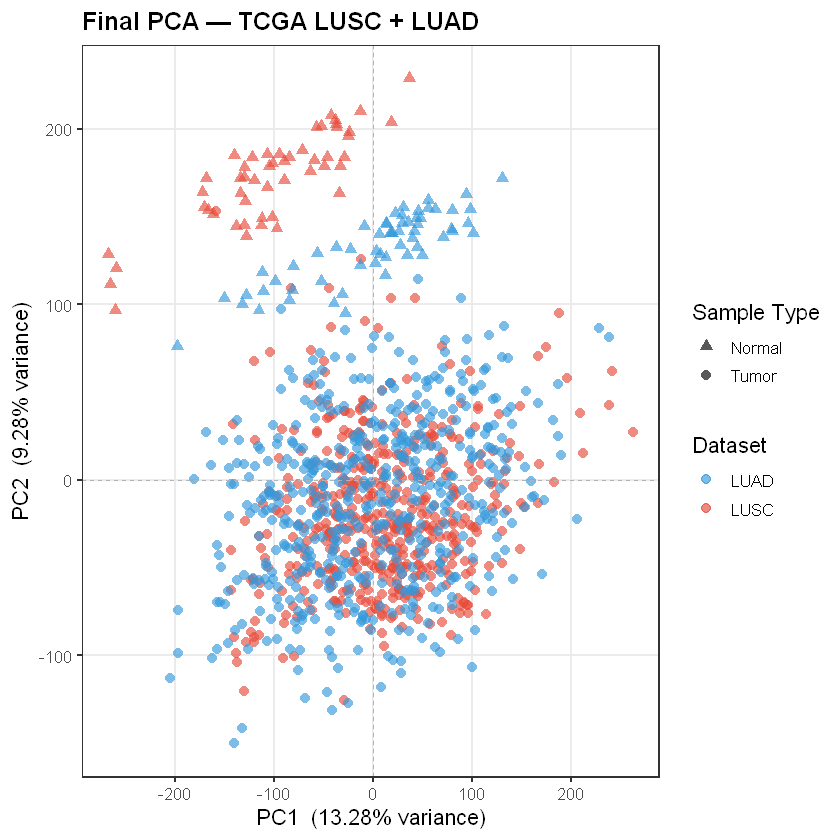

In [26]:
# --- PART C: Main PCA plot — colored by Dataset ---
# This shows whether batch effect has been successfully removed

plot_pca_dataset <- ggplot(
  pca_final_df,
  aes(x = PC1, y = PC2, color = Dataset, shape = SampleType)
) +
  geom_point(alpha = 0.65, size = 2.5) +
  scale_color_manual(
    values = c("LUSC" = "#E74C3C", "LUAD" = "#3498DB")
  ) +
  scale_shape_manual(
    values = c("Tumor" = 16, "Normal" = 17)  # circle vs triangle
  ) +
  labs(
    title    = "Final PCA — TCGA LUSC + LUAD",
    x        = sprintf("PC1  (%.2f%% variance)", var_explained[1]),
    y        = sprintf("PC2  (%.2f%% variance)", var_explained[2]),
    color    = "Dataset",
    shape    = "Sample Type"
  ) +
  theme_bw(base_size = 13) +
  theme(
    plot.title    = element_text(face = "bold", size = 15),
    plot.subtitle = element_text(color = "gray40"),
    legend.position  = "right",
    panel.grid.minor = element_blank()
  ) +
  # Add a center crosshair at 0,0
  geom_hline(yintercept = 0, linetype = "dashed",
             color = "gray70", linewidth = 0.4) +
  geom_vline(xintercept = 0, linetype = "dashed",
             color = "gray70", linewidth = 0.4)

ggsave("Final_PCA_by_Dataset.png", plot_pca_dataset,
       width = 9, height = 7, dpi = 200)

cat("✔ Plot saved: Final_PCA_by_Dataset.png\n")
print(plot_pca_dataset)

✔ Plot saved: Final_PCA_by_SampleType.png


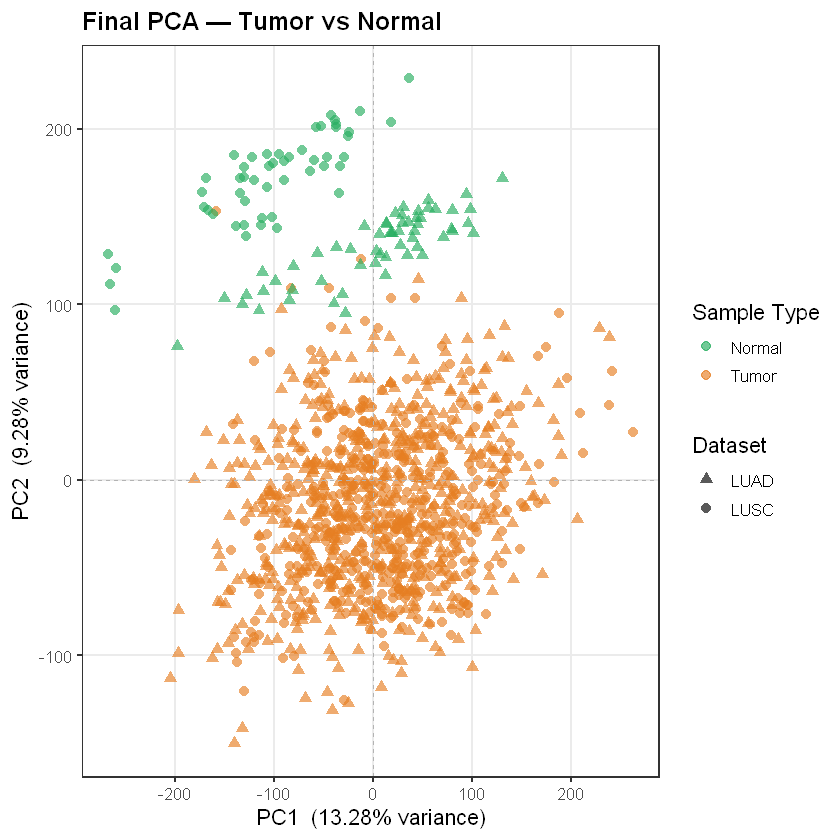

In [27]:
# --- PART D: Second PCA plot — colored by Tumor vs Normal ---
# This is biologically more meaningful
# Tumor and Normal should separate clearly on PC1 or PC2
# That separation = real biological signal, not batch effect

plot_pca_type <- ggplot(
  pca_final_df,
  aes(x = PC1, y = PC2, color = SampleType, shape = Dataset)
) +
  geom_point(alpha = 0.65, size = 2.5) +
  scale_color_manual(
    values = c("Tumor" = "#E67E22", "Normal" = "#27AE60")
  ) +
  scale_shape_manual(
    values = c("LUSC" = 16, "LUAD" = 17)
  ) +
  labs(
    title    = "Final PCA — Tumor vs Normal",
    x        = sprintf("PC1  (%.2f%% variance)", var_explained[1]),
    y        = sprintf("PC2  (%.2f%% variance)", var_explained[2]),
    color    = "Sample Type",
    shape    = "Dataset"
  ) +
  theme_bw(base_size = 13) +
  theme(
    plot.title       = element_text(face = "bold", size = 15),
    plot.subtitle    = element_text(color = "gray40"),
    legend.position  = "right",
    panel.grid.minor = element_blank()
  ) +
  geom_hline(yintercept = 0, linetype = "dashed",
             color = "gray70", linewidth = 0.4) +
  geom_vline(xintercept = 0, linetype = "dashed",
             color = "gray70", linewidth = 0.4)

ggsave("Final_PCA_by_SampleType.png", plot_pca_type,
       width = 9, height = 7, dpi = 200)

cat("✔ Plot saved: Final_PCA_by_SampleType.png\n")
print(plot_pca_type)

✔ Plot saved: Final_PCA_scree_plot.png


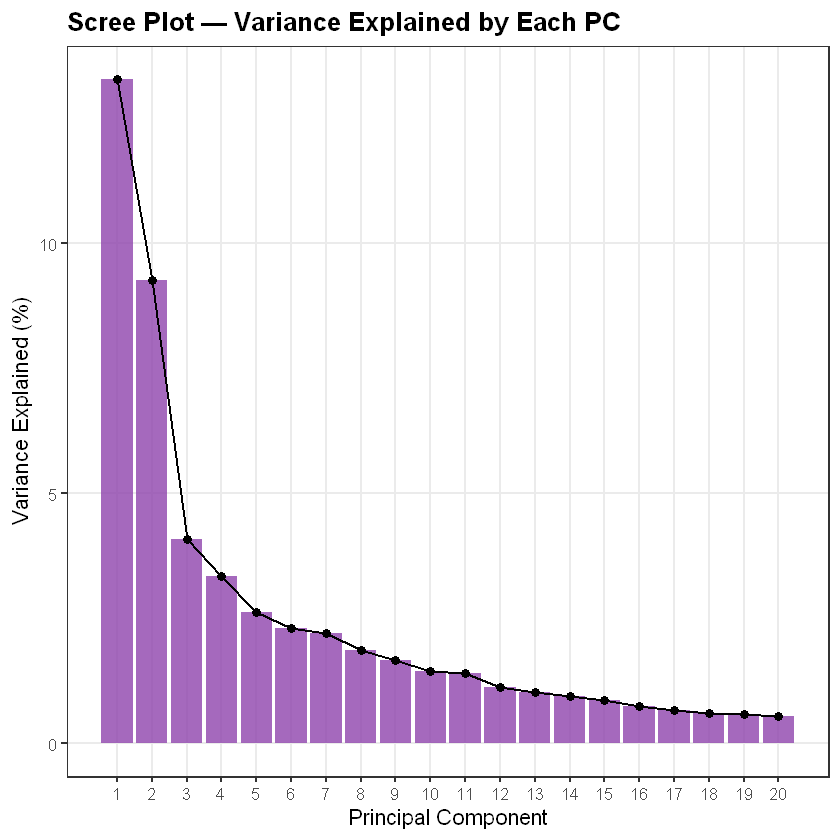

In [28]:
# --- PART E: Scree plot ---
# Shows how much variance each PC captures
# Helps decide how many PCs are meaningful

scree_df <- data.frame(
  PC       = 1:20,
  Variance = var_explained[1:20]
)

plot_scree <- ggplot(scree_df, aes(x = PC, y = Variance)) +
  geom_col(fill = "#8E44AD", alpha = 0.8) +
  geom_line(color = "black", linewidth = 0.7) +
  geom_point(color = "black", size = 2) +
  scale_x_continuous(breaks = 1:20) +
  labs(
    title = "Scree Plot — Variance Explained by Each PC",
    x     = "Principal Component",
    y     = "Variance Explained (%)"
  ) +
  theme_bw(base_size = 13) +
  theme(
    plot.title       = element_text(face = "bold"),
    panel.grid.minor = element_blank()
  )

ggsave("Final_PCA_scree_plot.png", plot_scree,
       width = 9, height = 5, dpi = 200)

cat("✔ Plot saved: Final_PCA_scree_plot.png\n")
print(plot_scree)

In [ ]:
# Install magick (only once)
install.packages("magick")

# Load the library in your session
library(magick)


In [30]:
"package:magick" %in% search()

[1] FALSE

In [31]:
sessionInfo()

R version 4.6.0 (2026-04-24 ucrt)
Platform: x86_64-w64-mingw32/x64
Running under: Windows 11 x64 (build 26200)

Matrix products: default
  LAPACK version 3.12.1

locale:
[1] LC_COLLATE=English_United States.utf8 
[2] LC_CTYPE=English_United States.utf8   
[3] LC_MONETARY=English_United States.utf8
[4] LC_NUMERIC=C                          
[5] LC_TIME=English_United States.utf8    

time zone: Asia/Katmandu
tzcode source: internal

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] patchwork_1.3.2             dplyr_1.2.1                
 [3] stringr_1.6.0               data.table_1.18.4          
 [5] ggplot2_4.0.3               org.Hs.eg.db_3.23.1        
 [7] AnnotationDbi_1.74.0        edgeR_4.10.1               
 [9] limma_3.68.4                sva_3.60.0                 
[11] BiocParallel_1.46.0         genefilter_1.94.0          
[13] mgcv_1.9-4                  nlme_3.1-169               

In [32]:
library(magick)

ERROR: Error in library(magick): there is no package called 'magick'


In [33]:
# Step 1: Install magick (only once)
install.packages("magick")

# Step 2: Load the library in your current R session
library(magick)

Installing package into 'C:/Users/aryan/AppData/Local/R/win-library/4.6'
(as 'lib' is unspecified)



package 'magick' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\aryan\AppData\Local\Temp\RtmpyMs7r4\downloaded_packages


Linking to ImageMagick 6.9.13.29
Enabled features: cairo, freetype, fftw, ghostscript, heic, lcms, pango, raw, rsvg, webp
Disabled features: fontconfig, x11



In [34]:
library(magick)

In [37]:
# Load the library
library(magick)

# Now run the stitching code
img_before <- image_read("PCA_before_batch_correction.png")
img_after  <- image_read("PCA_after_batch_correction.png")
img_scree  <- image_read("Final_PCA_scree_plot.png")
img_type   <- image_read("Final_PCA_by_SampleType.png")

combined   <- image_append(c(img_before, img_after), stack = FALSE)
combined2  <- image_append(c(img_scree, img_type), stack = FALSE)
final_panel <- image_append(c(combined, combined2), stack = TRUE)

image_write(final_panel, "QC_PCA_panel.png", format = "png")

In [38]:
# --- PART F: Final pipeline summary ---

cat("\n")
cat("============================================================\n")
cat("        PREPROCESSING PIPELINE COMPLETE\n")
cat("============================================================\n\n")

cat(sprintf("  Input datasets:         TCGA-LUSC + TCGA-LUAD\n"))
cat(sprintf("  Data type:              log2-normalized TPM\n"))
cat(sprintf("  Gene ID mapping:        Ensembl → HGNC symbols\n"))
cat(sprintf("  Batch correction:       ComBat\n"))
cat(sprintf("  Outlier removal:        3-method consensus\n\n"))

cat(sprintf("  Final genes:            %d\n", nrow(final_matrix)))
cat(sprintf("  Final samples:          %d\n", ncol(final_matrix)))
cat(sprintf("  LUSC samples:           %d\n",
            sum(final_batch == "LUSC")))
cat(sprintf("  LUAD samples:           %d\n",
            sum(final_batch == "LUAD")))
cat(sprintf("  Normal samples:         %d\n",
            sum(pca_final_df$SampleType == "Normal")))
cat(sprintf("  Tumor samples:          %d\n",
            sum(pca_final_df$SampleType == "Tumor")))
cat(sprintf("\n  Output saved to:\n"))
cat(sprintf("  C:/Users/aryan/Downloads/TCGA_LUSC_LUAD_final_expression.tsv\n"))
cat("\n============================================================\n")


        PREPROCESSING PIPELINE COMPLETE

  Input datasets:         TCGA-LUSC + TCGA-LUAD
  Data type:              log2-normalized TPM
  Gene ID mapping:        Ensembl → HGNC symbols
  Batch correction:       ComBat
  Outlier removal:        3-method consensus

  Final genes:            36650
  Final samples:          1139
  LUSC samples:           550
  LUAD samples:           589
  Normal samples:         110
  Tumor samples:          1029

  Output saved to:
  C:/Users/aryan/Downloads/TCGA_LUSC_LUAD_final_expression.tsv



In [39]:
# ============================================================
# DEG ANALYSIS - STEP 1: Load Required Packages
# ============================================================

if (!requireNamespace("BiocManager", quietly = TRUE))
  install.packages("BiocManager")

BiocManager::install(c(
  "limma",        # Core DEG analysis
  "edgeR"         # Used alongside limma for voom
), update = FALSE)

install.packages(c(
  "ggplot2",      # Volcano plot
  "ggrepel",      # Gene labels on volcano plot
  "pheatmap",     # Heatmap
  "dplyr",        # Data manipulation
  "RColorBrewer"  # Color palettes for heatmap
))

# Load all
library(limma)
library(edgeR)
library(ggplot2)
library(ggrepel)
library(pheatmap)
library(dplyr)
library(RColorBrewer)

cat("All packages loaded successfully\n")

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.r-project.org

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.0 (2026-04-24 ucrt)

Warning message:
"package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'limma' 'edgeR'"
Warning message:
"packages 'ggplot2', 'dplyr' are in use and will not be installed"
Installing packages into 'C:/Users/aryan/AppData/Local/R/win-library/4.6'
(as 'lib' is unspecified)



package 'ggrepel' successfully unpacked and MD5 sums checked


Warning message:
"cannot remove prior installation of package 'ggrepel'"
Warning message in file.copy(savedcopy, lib, recursive = TRUE):
"problem copying C:\Users\aryan\AppData\Local\R\win-library\4.6\00LOCK\ggrepel\libs\x64\ggrepel.dll to C:\Users\aryan\AppData\Local\R\win-library\4.6\ggrepel\libs\x64\ggrepel.dll: Permission denied"
Warning message:
"restored 'ggrepel'"


package 'pheatmap' successfully unpacked and MD5 sums checked
package 'RColorBrewer' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\aryan\AppData\Local\Temp\RtmpyMs7r4\downloaded_packages
All packages loaded successfully


In [40]:
# ============================================================
# DEG ANALYSIS - STEP 2: Create Sample Metadata
# ============================================================

# Extract sample type from TCGA barcode
# Position 14-15: "01" = Tumor, "11" = Normal
sample_types <- ifelse(
  substr(colnames(final_matrix), 14, 15) == "11",
  "Normal", "Tumor"
)

# Create metadata dataframe
metadata <- data.frame(
  Sample     = colnames(final_matrix),
  SampleType = factor(sample_types, levels = c("Normal", "Tumor")),
  Dataset    = final_batch,
  row.names  = colnames(final_matrix)
)

# Quick check
cat("=== Sample Metadata Summary ===\n\n")
cat(sprintf("Total samples:   %d\n", nrow(metadata)))
cat(sprintf("Tumor samples:   %d\n", sum(metadata$SampleType == "Tumor")))
cat(sprintf("Normal samples:  %d\n", sum(metadata$SampleType == "Normal")))

cat("\nBreakdown by dataset:\n")
print(table(metadata$Dataset, metadata$SampleType))

=== Sample Metadata Summary ===

Total samples:   1139
Tumor samples:   1029
Normal samples:  110

Breakdown by dataset:
      
       Normal Tumor
  LUAD     59   530
  LUSC     51   499


In [41]:
# ============================================================
# DEG ANALYSIS - STEP 3: limma-voom
# ============================================================

# --- PART A: Create design matrix ---
# This tells limma which samples are tumor and which are normal
# ~ 0 + SampleType means we explicitly model both groups

cat("=== PART A: Creating Design Matrix ===\n")

design <- model.matrix(~ 0 + SampleType, data = metadata)

# Rename columns cleanly
colnames(design) <- c("Normal", "Tumor")

cat("Design matrix dimensions:\n")
cat(sprintf("  Rows (samples): %d\n", nrow(design)))
cat(sprintf("  Cols (groups):  %d\n", ncol(design)))
cat("\nFirst 3 rows of design matrix:\n")
print(head(design, 3))

=== PART A: Creating Design Matrix ===
Design matrix dimensions:
  Rows (samples): 1139
  Cols (groups):  2

First 3 rows of design matrix:
                 Normal Tumor
TCGA-60-2698-01A      0     1
TCGA-33-4589-01A      0     1
TCGA-18-3410-01A      0     1


In [42]:
# ============================================================
# FIX: Remove negative values before voom
# ============================================================

# Check minimum value
cat(sprintf("Minimum value before fix: %.3f\n", min(final_matrix)))

# Shift entire matrix so minimum value becomes 0
# We add the absolute value of the minimum to every value
final_matrix_shifted <- final_matrix - min(final_matrix)

# Verify fix
cat(sprintf("Minimum value after fix:  %.3f\n", min(final_matrix_shifted)))
cat(sprintf("Maximum value after fix:  %.3f\n", max(final_matrix_shifted)))

Minimum value before fix: -4.758
Minimum value after fix:  0.000
Maximum value after fix:  39.004



=== PART B (Fixed): Applying voom ===
✔ voom transformation complete
  Matrix: 36650 genes × 1139 samples


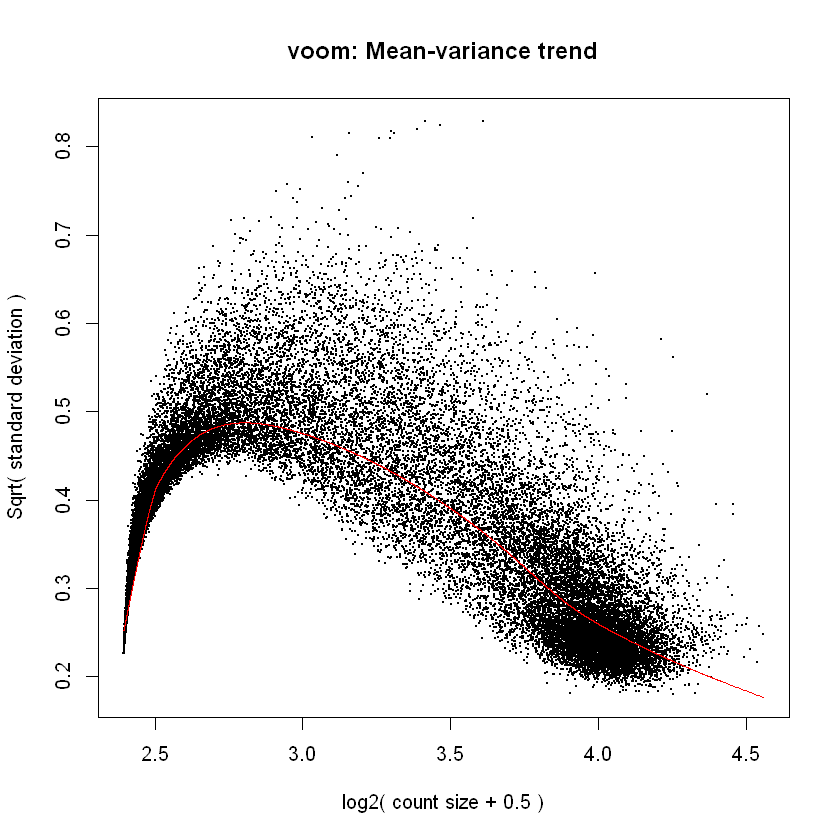

In [43]:
# --- Now rerun PART B with shifted matrix ---

cat("\n=== PART B (Fixed): Applying voom ===\n")

voom_result <- voom(
  counts = final_matrix_shifted,   # shifted matrix
  design = design,
  plot   = TRUE
)

cat("✔ voom transformation complete\n")
cat(sprintf("  Matrix: %d genes × %d samples\n",
            nrow(voom_result$E), ncol(voom_result$E)))

In [44]:
# Continue with Part C
fit <- lmFit(voom_result, design)
cat("✔ Linear model fitted\n")

# Part D
contrast_matrix <- makeContrasts(
  TumorVsNormal = Tumor - Normal,
  levels = design
)

# Part E
fit2 <- contrasts.fit(fit, contrast_matrix)
fit2 <- eBayes(fit2)
cat("✔ eBayes complete\n")

# Part F
deg_results <- topTable(
  fit2,
  coef          = "TumorVsNormal",
  number        = Inf,
  sort.by       = "P",
  adjust.method = "BH"
)

cat(sprintf("✔ Results extracted for %d genes\n", nrow(deg_results)))
cat("\n--- Preview: Top 10 DEGs ---\n")
print(head(deg_results, 10))

✔ Linear model fitted
✔ eBayes complete
✔ Results extracted for 36650 genes

--- Preview: Top 10 DEGs ---
                  logFC  AveExpr         t       P.Value     adj.P.Val        B
AGER         -0.5658662 5.468332 -56.51434  0.000000e+00  0.000000e+00 753.4687
SLC6A4       -0.8001615 4.939905 -57.30944  0.000000e+00  0.000000e+00 765.2969
RTKN2        -0.3832787 5.409297 -53.28775 4.454346e-312 4.931160e-308 704.8588
CD300LG      -0.8831877 4.595685 -53.27538 5.381894e-312 4.931160e-308 704.3373
FAM107A      -0.5093337 5.283068 -53.24955 7.990183e-312 5.856804e-308 704.2955
C10orf67-AS1 -0.8758236 4.310781 -53.10859 6.916320e-311 4.224719e-307 700.8371
GPD1         -0.5453819 5.098687 -52.58538 2.128105e-307 1.114215e-303 694.1027
CLEC3B       -0.5088052 5.111356 -52.18630 9.960332e-305 4.563077e-301 687.9580
GPM6A        -0.7193275 4.926289 -52.05236 7.878220e-304 3.208186e-300 685.8582
TEK          -0.3601428 5.327703 -50.40098 1.112130e-292 4.075956e-289 660.2488


In [45]:
# ============================================================
# STEP 4 FIXED: Apply Corrected Thresholds
# ============================================================

# --- PART A: Reclassify with |logFC| > 0.5 ---

cat("=== Applying Corrected DEG Thresholds ===\n")
cat("Threshold: |log2FC| > 0.5 AND adj.p < 0.05\n\n")

deg_results$Status <- "Not Significant"

deg_results$Status[
  deg_results$logFC > 0.5 &
  deg_results$adj.P.Val < 0.05
] <- "Upregulated"

deg_results$Status[
  deg_results$logFC < -0.5 &
  deg_results$adj.P.Val < 0.05
] <- "Downregulated"

deg_results$Status <- factor(
  deg_results$Status,
  levels = c("Upregulated", "Downregulated", "Not Significant")
)

=== Applying Corrected DEG Thresholds ===
Threshold: |log2FC| > 0.5 AND adj.p < 0.05



In [46]:
# --- PART B: Count DEGs ---

total_genes   <- nrow(deg_results)
upregulated   <- sum(deg_results$Status == "Upregulated")
downregulated <- sum(deg_results$Status == "Downregulated")
not_sig       <- sum(deg_results$Status == "Not Significant")
total_degs    <- upregulated + downregulated

cat("=== DEG Summary ===\n\n")
cat(sprintf("Total genes tested:    %d\n", total_genes))
cat(sprintf("Total DEGs:            %d\n", total_degs))
cat(sprintf("  Upregulated:         %d\n", upregulated))
cat(sprintf("  Downregulated:       %d\n", downregulated))
cat(sprintf("Not significant:       %d\n", not_sig))
cat(sprintf("DEG rate:              %.1f%%\n",
            total_degs / total_genes * 100))

=== DEG Summary ===

Total genes tested:    36650
Total DEGs:            377
  Upregulated:         167
  Downregulated:       210
Not significant:       36273
DEG rate:              1.0%


In [49]:
# --- PART C: Extract significant DEGs ---

sig_degs <- deg_results[deg_results$Status != "Not Significant", ]
sig_degs <- sig_degs[order(-sig_degs$logFC), ]

cat("\n--- Top 20 Upregulated Genes ---\n")
print(head(sig_degs[sig_degs$Status == "Upregulated",
                    c("logFC", "adj.P.Val", "Status")], 20))

cat("\n--- Top 20 Downregulated Genes ---\n")
print(head(sig_degs[sig_degs$Status == "Downregulated",
                    c("logFC", "adj.P.Val", "Status")], 20))


--- Top 20 Upregulated Genes ---
                 logFC     adj.P.Val      Status
CASC9        0.8844172  7.545661e-40 Upregulated
PITX2        0.8670381  8.870830e-57 Upregulated
HOXC13       0.8514333 7.459573e-139 Upregulated
PRAME        0.8499343  7.361933e-22 Upregulated
CST1         0.8321232  1.181146e-32 Upregulated
LCAL1        0.7984911  4.735091e-27 Upregulated
SACK1A-AS1   0.7862638  2.296326e-61 Upregulated
BARX1        0.7844422  4.377812e-34 Upregulated
BBOX1-AS1    0.7828061  6.876416e-57 Upregulated
GABRA3       0.7673588  2.033247e-51 Upregulated
C12orf56     0.7595353  2.888291e-51 Upregulated
LOC124904701 0.7501783  1.404994e-78 Upregulated
GNGT1        0.7452534 1.061435e-146 Upregulated
KRTAP4-1     0.7371475 3.523198e-164 Upregulated
IL36RN       0.7315872  2.036536e-36 Upregulated
DLX6         0.7276276  8.668633e-57 Upregulated
FOXD3-AS1    0.7274440 1.218633e-160 Upregulated
ZIC2         0.7266607  9.199766e-40 Upregulated
AKR1B10      0.7211713  4.939853e-1

In [50]:
# --- PART D: Save results ---

write.table(
  data.frame(Gene = rownames(deg_results), deg_results),
  file      = "C:/Users/aryan/Downloads/DEG_full_results.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

write.table(
  data.frame(Gene = rownames(sig_degs), sig_degs),
  file      = "C:/Users/aryan/Downloads/DEG_significant_only.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

cat("\n✔ Full results saved:      DEG_full_results.tsv\n")
cat("✔ Significant DEGs saved:  DEG_significant_only.tsv\n")


✔ Full results saved:      DEG_full_results.tsv
✔ Significant DEGs saved:  DEG_significant_only.tsv


In [51]:
# ============================================================
# DEG ANALYSIS - STEP 5: Volcano Plot
# ============================================================

# --- PART A: Prepare data for plotting ---

cat("=== Building Volcano Plot ===\n")

# Add -log10 adjusted p-value column for y axis
deg_results$neg_log10_p <- -log10(deg_results$adj.P.Val)

# Add gene names column
deg_results$Gene <- rownames(deg_results)

# Select top 10 up and top 10 down genes to label on plot
top_up <- deg_results[deg_results$Status == "Upregulated", ]
top_up <- head(top_up[order(-top_up$logFC), ], 10)

top_down <- deg_results[deg_results$Status == "Downregulated", ]
top_down <- head(top_down[order(top_down$logFC), ], 10)

genes_to_label <- rbind(top_up, top_down)

cat(sprintf("Genes to label on plot: %d\n", nrow(genes_to_label)))

=== Building Volcano Plot ===
Genes to label on plot: 20


In [54]:
# ============================================================
# DEG ANALYSIS - STEP 6: Heatmap
# ============================================================

# --- PART A: Select top genes for heatmap ---
# Using top 50 DEGs (25 up + 25 down) for clean visualization

cat("=== Building Heatmap ===\n\n")

# Top 25 upregulated
top25_up <- head(
  rownames(deg_results[deg_results$Status == "Upregulated", ][
    order(-deg_results[deg_results$Status == "Upregulated", "logFC"]), ]), 25)

# Top 25 downregulated
top25_down <- head(
  rownames(deg_results[deg_results$Status == "Downregulated", ][
    order(deg_results[deg_results$Status == "Downregulated", "logFC"]), ]), 25)

# Combine
top50_genes <- c(top25_up, top25_down)

cat(sprintf("Top upregulated genes selected:   %d\n", length(top25_up)))
cat(sprintf("Top downregulated genes selected:  %d\n", length(top25_down)))
cat(sprintf("Total genes for heatmap:           %d\n", length(top50_genes)))

=== Building Heatmap ===

Top upregulated genes selected:   25
Top downregulated genes selected:  25
Total genes for heatmap:           50


In [55]:
# --- PART B: Extract expression values for top genes ---
# Use final_matrix (preprocessed expression values)
# Subset to top 50 genes only

heatmap_mat <- final_matrix[top50_genes, ]

cat(sprintf("\nHeatmap matrix: %d genes × %d samples\n",
            nrow(heatmap_mat), ncol(heatmap_mat)))


Heatmap matrix: 50 genes × 1139 samples


In [56]:
# --- PART C: Scale genes (z-score per gene) ---
# Z-score scaling makes patterns visible across genes
# with different expression levels
# Each gene: subtract mean, divide by SD
# Result: values centered around 0

heatmap_scaled <- t(scale(t(heatmap_mat)))

# Cap extreme values for better color visualization
heatmap_scaled[heatmap_scaled >  3] <-  3
heatmap_scaled[heatmap_scaled < -3] <- -3

cat("Z-score scaling applied\n")
cat(sprintf("Value range after scaling: [%.2f, %.2f]\n",
            min(heatmap_scaled), max(heatmap_scaled)))

Z-score scaling applied
Value range after scaling: [-2.93, 3.00]


In [57]:
# --- PART D: Create annotation for samples ---
# This adds colored bars on top of heatmap
# showing which samples are Tumor/Normal and LUSC/LUAD

annotation_col <- data.frame(
  SampleType = metadata$SampleType,
  Dataset    = metadata$Dataset,
  row.names  = metadata$Sample
)

# Define colors for annotations
annotation_colors <- list(
  SampleType = c(
    "Tumor"  = "#E74C3C",
    "Normal" = "#27AE60"
  ),
  Dataset = c(
    "LUSC" = "#8E44AD",
    "LUAD" = "#F39C12"
  )
)

cat("Sample annotations created\n")

Sample annotations created


In [58]:
# --- PART E: Draw and save heatmap ---

cat("\nGenerating heatmap (may take a moment)...\n")

# Color palette: blue = low, white = middle, red = high
heatmap_colors <- colorRampPalette(
  c("#3498DB", "white", "#E74C3C")
)(100)

# Draw heatmap
pheatmap(
  mat               = heatmap_scaled,
  color             = heatmap_colors,
  annotation_col    = annotation_col,
  annotation_colors = annotation_colors,
  show_colnames     = FALSE,      # too many samples to show names
  show_rownames     = TRUE,       # show gene names
  cluster_rows      = TRUE,       # cluster genes
  cluster_cols      = TRUE,       # cluster samples
  clustering_method = "ward.D2",  # standard clustering method
  fontsize_row      = 8,          # gene name font size
  main              = "Heatmap — Top 50 DEGs (Tumor vs Normal)",
  filename          = "Heatmap_top50_DEGs.png",  # <-- only filename
  width             = 14,
  height            = 10
)

cat("✔ Heatmap saved in working directory: Heatmap_top50_DEGs.png\n")


Generating heatmap (may take a moment)...
✔ Heatmap saved in working directory: Heatmap_top50_DEGs.png


In [59]:
# ============================================================
# DEG ANALYSIS - STEP 7: Venn Diagram
# ============================================================

# --- PART A: Split samples by dataset ---
# We need to run DEG analysis separately for LUSC and LUAD
# Then compare which DEGs overlap

cat("=== PART A: Splitting by Dataset ===\n\n")

# Get sample names for each dataset
lusc_samples <- rownames(metadata[metadata$Dataset == "LUSC", ])
luad_samples <- rownames(metadata[metadata$Dataset == "LUAD", ])

cat(sprintf("LUSC samples: %d\n", length(lusc_samples)))
cat(sprintf("LUAD samples: %d\n", length(luad_samples)))

# Subset final matrix for each dataset
lusc_mat_deg <- final_matrix_shifted[, lusc_samples]
luad_mat_deg <- final_matrix_shifted[, luad_samples]

# Subset metadata for each dataset
lusc_meta <- metadata[lusc_samples, ]
luad_meta <- metadata[luad_samples, ]

cat(sprintf("\nLUSC matrix: %d genes × %d samples\n",
            nrow(lusc_mat_deg), ncol(lusc_mat_deg)))
cat(sprintf("LUAD matrix: %d genes × %d samples\n",
            nrow(luad_mat_deg), ncol(luad_mat_deg)))

# Check tumor/normal counts per dataset
cat("\nLUSC tumor/normal:\n")
print(table(lusc_meta$SampleType))
cat("\nLUAD tumor/normal:\n")
print(table(luad_meta$SampleType))

=== PART A: Splitting by Dataset ===

LUSC samples: 550
LUAD samples: 589

LUSC matrix: 36650 genes × 550 samples
LUAD matrix: 36650 genes × 589 samples

LUSC tumor/normal:

Normal  Tumor 
    51    499 

LUAD tumor/normal:

Normal  Tumor 
    59    530 


In [60]:
# --- PART B: Run limma-voom separately for LUSC ---

cat("\n=== PART B: DEG Analysis for LUSC ===\n")

# Design matrix for LUSC
design_lusc <- model.matrix(~ 0 + SampleType, data = lusc_meta)
colnames(design_lusc) <- c("Normal", "Tumor")

# voom
voom_lusc <- voom(lusc_mat_deg, design_lusc, plot = FALSE)

# Fit model
fit_lusc <- lmFit(voom_lusc, design_lusc)

# Contrast
contrast_lusc <- makeContrasts(
  TumorVsNormal = Tumor - Normal,
  levels = design_lusc
)

# eBayes
fit_lusc2 <- contrasts.fit(fit_lusc, contrast_lusc)
fit_lusc2 <- eBayes(fit_lusc2)

# Extract results
deg_lusc <- topTable(
  fit_lusc2,
  coef          = "TumorVsNormal",
  number        = Inf,
  sort.by       = "P",
  adjust.method = "BH"
)

# Apply thresholds
sig_lusc <- rownames(deg_lusc[
  abs(deg_lusc$logFC) > 0.5 &
  deg_lusc$adj.P.Val < 0.05, ])

cat(sprintf("✔ LUSC DEGs: %d\n", length(sig_lusc)))


=== PART B: DEG Analysis for LUSC ===
✔ LUSC DEGs: 852


In [61]:
# --- PART C: Run limma-voom separately for LUAD ---

cat("\n=== PART C: DEG Analysis for LUAD ===\n")

# Design matrix for LUAD
design_luad <- model.matrix(~ 0 + SampleType, data = luad_meta)
colnames(design_luad) <- c("Normal", "Tumor")

# voom
voom_luad <- voom(luad_mat_deg, design_luad, plot = FALSE)

# Fit model
fit_luad <- lmFit(voom_luad, design_luad)

# Contrast
contrast_luad <- makeContrasts(
  TumorVsNormal = Tumor - Normal,
  levels = design_luad
)

# eBayes
fit_luad2 <- contrasts.fit(fit_luad, contrast_luad)
fit_luad2 <- eBayes(fit_luad2)

# Extract results
deg_luad <- topTable(
  fit_luad2,
  coef          = "TumorVsNormal",
  number        = Inf,
  sort.by       = "P",
  adjust.method = "BH"
)

# Apply thresholds
sig_luad <- rownames(deg_luad[
  abs(deg_luad$logFC) > 0.5 &
  deg_luad$adj.P.Val < 0.05, ])

cat(sprintf("✔ LUAD DEGs: %d\n", length(sig_luad)))


=== PART C: DEG Analysis for LUAD ===
✔ LUAD DEGs: 232


In [62]:
# --- PART D: Find overlapping DEGs ---

cat("\n=== PART D: Overlap Analysis ===\n\n")

# Genes in both datasets
common_degs <- intersect(sig_lusc, sig_luad)

# Genes unique to each
only_lusc <- setdiff(sig_lusc, sig_luad)
only_luad <- setdiff(sig_luad, sig_lusc)

cat(sprintf("LUSC only DEGs:     %d\n", length(only_lusc)))
cat(sprintf("LUAD only DEGs:     %d\n", length(only_luad)))
cat(sprintf("Shared DEGs:        %d\n", length(common_degs)))

cat("\n--- Shared DEGs (most robust findings) ---\n")
print(common_degs)


=== PART D: Overlap Analysis ===

LUSC only DEGs:     684
LUAD only DEGs:     64
Shared DEGs:        168

--- Shared DEGs (most robust findings) ---
  [1] "ARHGEF4-AS1"  "GPD1"         "AGER"         "ADAMTS7P3"    "RS1"         
  [6] "CD300LG"      "FOXD3-AS1"    "LOC105373373" "VEGFD"        "CPB2"        
 [11] "MCEMP1"       "FAM107A"      "GPIHBP1"      "ADAMTS8"      "LINC02016"   
 [16] "TNNC1"        "CLDN18"       "GPM6A"        "C10orf67-AS1" "CA4"         
 [21] "GPA33"        "SLC6A4"       "GKN2"         "CNTN6"        "AGRP"        
 [26] "PLA2G1B"      "GRIA1"        "RETN"         "RXFP2"        "F11"         
 [31] "GDF10"        "MS4A15"       "NKX1-2"       "LINC01863"    "C8B"         
 [36] "CTXND1"       "ANKRD1"       "LINC00968"    "TMEM100"      "MYOC"        
 [41] "IHH"          "ANGPT4"       "LNCEGFL7OS"   "CD5L"         "CAV3"        
 [46] "ADRA1A"       "ITLN2"        "RSPO1"        "CYP1A2"       "HID1-AS1"    
 [51] "CHRM2"        "LOC124905092" "FRE


=== PART E: Drawing Venn Diagram ===


Warning message:
"No shared levels found between `names(values)` of the manual scale and the data's colour values."


✔ Venn diagram saved: Venn_diagram_DEGs.png


Warning message:
"No shared levels found between `names(values)` of the manual scale and the data's colour values."


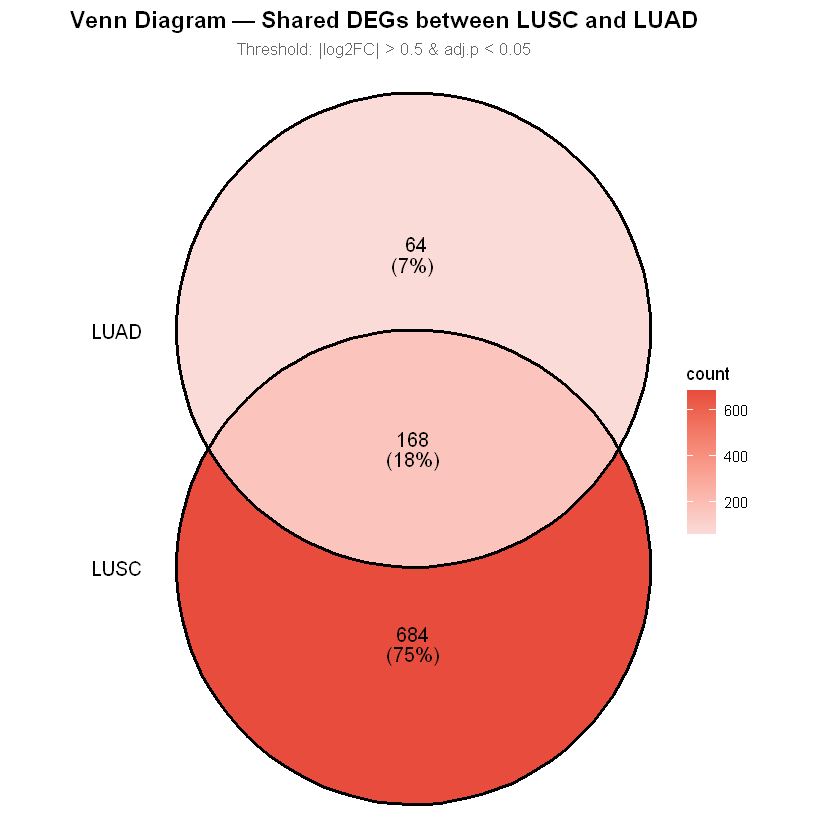

In [63]:
# --- PART E: Draw Venn Diagram ---

# Install if needed
if (!requireNamespace("ggVennDiagram", quietly = TRUE))
  install.packages("ggVennDiagram")

library(ggVennDiagram)

cat("\n=== PART E: Drawing Venn Diagram ===\n")

# Create list of DEG sets
venn_list <- list(
  LUSC = sig_lusc,
  LUAD = sig_luad
)

# Draw Venn diagram
venn_plot <- ggVennDiagram(
  venn_list,
  label_alpha = 0,
  edge_size   = 1
) +
  scale_fill_gradient(
    low  = "#FADBD8",
    high = "#E74C3C"
  ) +
  scale_color_manual(values = c(
    "LUSC" = "#8E44AD",
    "LUAD" = "#F39C12"
  )) +
  labs(
    title    = "Venn Diagram — Shared DEGs between LUSC and LUAD",
    subtitle = "Threshold: |log2FC| > 0.5 & adj.p < 0.05"
  ) +
  theme(
    plot.title    = element_text(face = "bold", size = 14,
                                 hjust = 0.5),
    plot.subtitle = element_text(color = "gray40", size = 10,
                                 hjust = 0.5)
  )

# Save
ggsave(
  "Venn_diagram_DEGs.png",
  venn_plot,
  width  = 8,
  height = 6,
  dpi    = 200
)

cat("✔ Venn diagram saved: Venn_diagram_DEGs.png\n")
print(venn_plot)

In [64]:
# --- PART F: Save shared DEGs to file ---

cat("\n=== PART F: Saving Shared DEGs ===\n")

# Get full results for shared DEGs from combined analysis
shared_deg_results <- deg_results[common_degs, ]
shared_deg_results$Gene <- common_degs

write.table(
  shared_deg_results,
  file      = "C:/Users/aryan/Downloads/Shared_DEGs_LUSC_LUAD.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

cat(sprintf("✔ Shared DEGs saved: Shared_DEGs_LUSC_LUAD.tsv\n"))
cat(sprintf("  Total shared DEGs: %d\n", nrow(shared_deg_results)))

cat("\n============================================================\n")
cat("         DEG ANALYSIS COMPLETE\n")
cat("============================================================\n")
cat("Files saved:\n")
cat("  1. DEG_full_results.tsv\n")
cat("  2. DEG_significant_only.tsv\n")
cat("  3. Volcano_plot_DEGs.png\n")
cat("  4. Heatmap_top50_DEGs.png\n")
cat("  5. Venn_diagram_DEGs.png\n")
cat("  6. Shared_DEGs_LUSC_LUAD.tsv\n")
cat("============================================================\n")


=== PART F: Saving Shared DEGs ===
✔ Shared DEGs saved: Shared_DEGs_LUSC_LUAD.tsv
  Total shared DEGs: 168

         DEG ANALYSIS COMPLETE
Files saved:
  1. DEG_full_results.tsv
  2. DEG_significant_only.tsv
  3. Volcano_plot_DEGs.png
  4. Heatmap_top50_DEGs.png
  5. Venn_diagram_DEGs.png
  6. Shared_DEGs_LUSC_LUAD.tsv


In [65]:
library(gridExtra)
library(png)
library(grid)

# Load images
img_before <- rasterGrob(readPNG("PCA_before_batch_correction.png"))
img_after  <- rasterGrob(readPNG("PCA_after_batch_correction.png"))
img_scree  <- rasterGrob(readPNG("Final_PCA_scree_plot.png"))
img_type   <- rasterGrob(readPNG("Final_PCA_by_SampleType.png"))

# Combine into one page
pdf("QC_PCA_panel.pdf", width = 14, height = 10)
grid.arrange(img_before, img_after, img_scree, img_type, ncol = 2)
dev.off()


Attaching package: 'gridExtra'


The following object is masked from 'package:dplyr':

    combine


The following object is masked from 'package:Biobase':

    combine


The following object is masked from 'package:BiocGenerics':

    combine




agg_record_5cc37681c91 
                     2

In [68]:
# --- Combine Volcano, Heatmap, and Venn Diagram into one image ---

# Install if needed
if (!requireNamespace("magick", quietly = TRUE))
  install.packages("magick")

library(magick)

# Read each saved plot image
volcano <- image_read("Volcano_plot_DEGs.png")
heatmap <- image_read("Heatmap_top50_DEGs.png")
venn    <- image_read("Venn_diagram_DEGs.png")

# Combine horizontally (side by side)
combined <- image_append(c(volcano, heatmap, venn))

# Save final composite figure
image_write(combined, "Combined_DEG_Figure.png", format = "png")

cat("✔ Combined figure saved: Combined_DEG_Figure.png\n")


✔ Combined figure saved: Combined_DEG_Figure.png



Attaching package: 'cowplot'


The following object is masked from 'package:patchwork':

    align_plots


Warning message:
"No shared levels found between `names(values)` of the manual scale and the data's colour values."


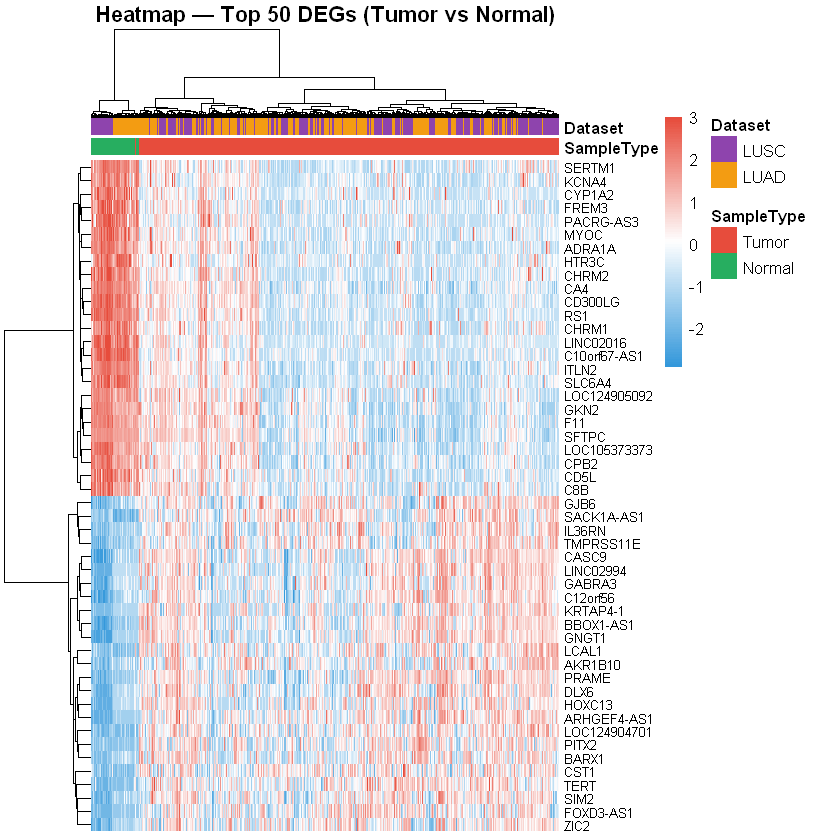

✔ Combined figure saved: Combined_DEG_Figure.pdf


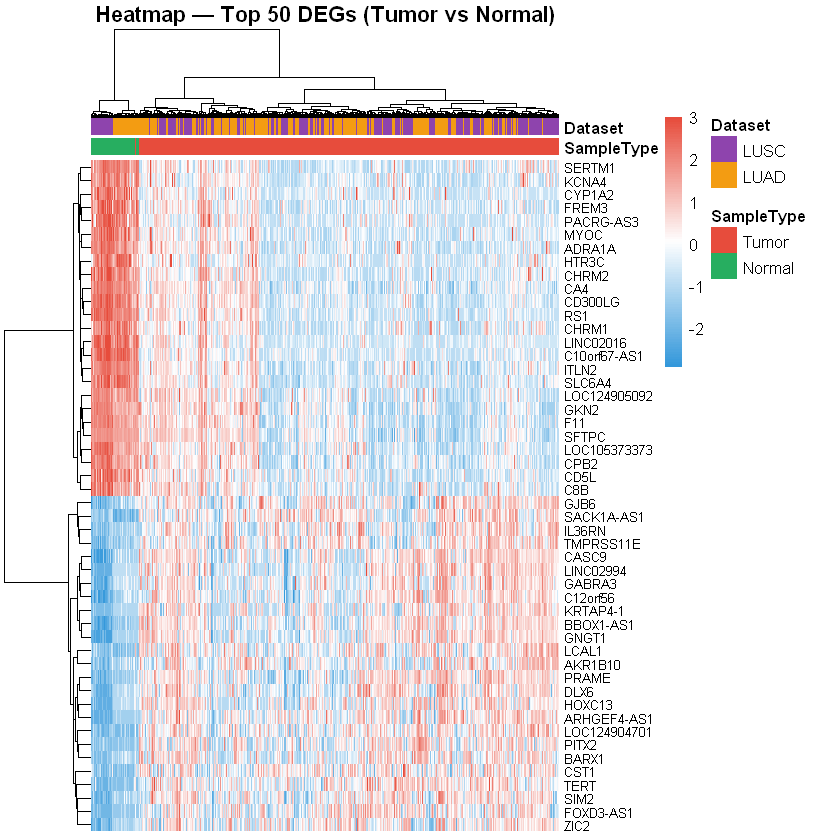

In [69]:
# --- Combine Volcano, Heatmap, and Venn Diagram into one PDF ---

# Install if needed
if (!requireNamespace("cowplot", quietly = TRUE))
  install.packages("cowplot")

library(cowplot)
library(gridExtra)

# If you already have the ggplot objects in memory:
# volcano_plot (ggplot), venn_plot (ggplot)
# For pheatmap, capture as a grid object:
heatmap_obj <- pheatmap(
  mat               = heatmap_scaled,
  color             = heatmap_colors,
  annotation_col    = annotation_col,
  annotation_colors = annotation_colors,
  show_colnames     = FALSE,
  show_rownames     = TRUE,
  cluster_rows      = TRUE,
  cluster_cols      = TRUE,
  clustering_method = "ward.D2",
  fontsize_row      = 8,
  main              = "Heatmap — Top 50 DEGs (Tumor vs Normal)"
)

# Arrange plots side by side
combined_plot <- plot_grid(
  volcano_plot,
  gridExtra::grid.arrange(heatmap_obj$gtable),
  venn_plot,
  ncol = 3,
  labels = c("A", "B", "C")
)

# Save as PDF
ggsave("Combined_DEG_Figure.pdf", combined_plot,
       width = 18, height = 6, dpi = 300)

cat("✔ Combined figure saved: Combined_DEG_Figure.pdf\n")


In [10]:
ego <- enrichGO(
    gene          = deg_list,
    OrgDb         = org.Hs.eg.db,
    keyType       = "ENTREZID",
    ont           = "BP",
    pAdjustMethod = "BH",
    qvalueCutoff  = 0.05
)
barplot(ego, showCategory = 20)


ERROR: Error: object 'deg_list' not found


In [11]:
# ============================================================
# FULL REBUILD FROM SAVED FILE
# ============================================================

library(limma)
library(edgeR)
library(data.table)
library(ggplot2)
library(ggrepel)
library(pheatmap)
library(dplyr)
library(RColorBrewer)
library(sva)

# --- Step 1: Reload final matrix from saved file ---
cat("Loading saved final matrix...\n")

final_df <- fread(
  "C:/Users/aryan/Downloads/TCGA_LUSC_LUAD_final_expression.tsv",
  header = TRUE,
  sep    = "\t"
)

# Convert back to matrix
final_matrix <- as.matrix(final_df[, -1])
rownames(final_matrix) <- final_df$Gene

cat(sprintf("✔ final_matrix loaded: %d genes × %d samples\n",
            nrow(final_matrix), ncol(final_matrix)))


Attaching package: 'limma'


The following object is masked from 'package:DESeq2':

    plotMA


The following object is masked from 'package:BiocGenerics':

    plotMA



Attaching package: 'data.table'


The following object is masked from 'package:SummarizedExperiment':

    shift


The following object is masked from 'package:GenomicRanges':

    shift


The following objects are masked from 'package:dplyr':

    between, first, last


The following object is masked from 'package:IRanges':

    shift


The following objects are masked from 'package:S4Vectors':

    first, second


The following object is masked from 'package:base':

    %notin%


Loading required package: mgcv

Loading required package: nlme


Attaching package: 'nlme'


The following object is masked from 'package:dplyr':

    collapse


The following object is masked from 'package:IRanges':

    collapse


This is mgcv 1.9-4. For overview type '?mgcv'.

Loading required package: genefilter


Attaching package: '

Loading saved final matrix...
✔ final_matrix loaded: 36650 genes × 1139 samples


In [12]:
# --- Step 2: Rebuild batch labels ---
cat("\nRebuilding batch labels...\n")

all_samples  <- colnames(final_matrix)

# LUSC barcodes contain project info
# We detect by checking TCGA barcode patterns from original datasets
# Reload original files just to get sample names

library(data.table)

lusc_check <- fread(
  "C:/Users/aryan/Downloads/TCGA-LUSC.star_counts.tsv.gz",
  header = TRUE, sep = "\t", nrows = 5
)
luad_check <- fread(
  "C:/Users/aryan/Downloads/TCGA-LUAD.star_counts.tsv.gz",
  header = TRUE, sep = "\t", nrows = 5
)

lusc_sample_names <- colnames(lusc_check)[-1]
luad_sample_names <- colnames(luad_check)[-1]

# Assign batch labels
final_batch <- ifelse(
  all_samples %in% lusc_sample_names, "LUSC", "LUAD"
)

cat(sprintf("✔ LUSC samples: %d\n", sum(final_batch == "LUSC")))
cat(sprintf("✔ LUAD samples: %d\n", sum(final_batch == "LUAD")))


Rebuilding batch labels...
✔ LUSC samples: 550
✔ LUAD samples: 589


In [13]:
# --- Step 3: Rebuild metadata ---
cat("\nRebuilding metadata...\n")

sample_types <- ifelse(
  substr(colnames(final_matrix), 14, 15) == "11",
  "Normal", "Tumor"
)

metadata <- data.frame(
  Sample     = colnames(final_matrix),
  SampleType = factor(sample_types, levels = c("Normal", "Tumor")),
  Dataset    = final_batch,
  row.names  = colnames(final_matrix)
)

cat(sprintf("✔ Tumor samples:  %d\n", sum(metadata$SampleType == "Tumor")))
cat(sprintf("✔ Normal samples: %d\n", sum(metadata$SampleType == "Normal")))


Rebuilding metadata...
✔ Tumor samples:  1029
✔ Normal samples: 110


In [14]:
# --- Step 4: Rebuild shifted matrix ---
cat("\nShifting matrix to remove negatives...\n")

final_matrix_shifted <- final_matrix - min(final_matrix)

cat(sprintf("✔ Min value after shift: %.3f\n", min(final_matrix_shifted)))
cat(sprintf("✔ Max value after shift: %.3f\n", max(final_matrix_shifted)))


Shifting matrix to remove negatives...
✔ Min value after shift: 0.000
✔ Max value after shift: 39.004


In [15]:
# --- Step 5: Rerun limma-voom ---
cat("\nRerunning limma-voom...\n")

design <- model.matrix(~ 0 + SampleType, data = metadata)
colnames(design) <- c("Normal", "Tumor")

voom_result <- voom(final_matrix_shifted, design, plot = FALSE)
fit         <- lmFit(voom_result, design)

contrast_matrix <- makeContrasts(
  TumorVsNormal = Tumor - Normal,
  levels = design
)

fit2 <- contrasts.fit(fit, contrast_matrix)
fit2 <- eBayes(fit2)

deg_results <- topTable(
  fit2,
  coef          = "TumorVsNormal",
  number        = Inf,
  sort.by       = "P",
  adjust.method = "BH"
)

cat(sprintf("✔ deg_results ready: %d genes\n", nrow(deg_results)))


Rerunning limma-voom...
✔ deg_results ready: 36650 genes


In [16]:
# --- Step 6: Apply thresholds ---
cat("\nApplying thresholds...\n")

deg_results$Status <- "Not Significant"

deg_results$Status[
  deg_results$logFC > 0.5 &
  deg_results$adj.P.Val < 0.05
] <- "Upregulated"

deg_results$Status[
  deg_results$logFC < -0.5 &
  deg_results$adj.P.Val < 0.05
] <- "Downregulated"

deg_results$Status <- factor(
  deg_results$Status,
  levels = c("Upregulated", "Downregulated", "Not Significant")
)

cat(sprintf("✔ Upregulated:   %d\n", sum(deg_results$Status == "Upregulated")))
cat(sprintf("✔ Downregulated: %d\n", sum(deg_results$Status == "Downregulated")))
cat(sprintf("✔ Total DEGs:    %d\n",
            sum(deg_results$Status != "Not Significant")))


Applying thresholds...
✔ Upregulated:   167
✔ Downregulated: 210
✔ Total DEGs:    377


In [17]:
cat(exists("deg_results"), "\n")
cat(exists("final_matrix"), "\n")
cat(exists("metadata"), "\n")
cat(exists("final_matrix_shifted"), "\n")

TRUE 
TRUE 
TRUE 
TRUE 


In [18]:
# ============================================================
# FUNCTIONAL ENRICHMENT - STEP 1: Load Packages
# ============================================================

if (!requireNamespace("BiocManager", quietly = TRUE))
  install.packages("BiocManager")

BiocManager::install(c(
  "clusterProfiler",  # Core enrichment analysis
  "org.Hs.eg.db",     # Human gene annotation database
  "enrichplot",       # Visualization of enrichment results
  "AnnotationDbi"     # Gene ID conversion
), update = FALSE)

install.packages(c(
  "ggplot2",    # Base plotting
  "dplyr",      # Data manipulation
  "stringr"     # String operations for plot labels
))

# Load all
library(clusterProfiler)
library(org.Hs.eg.db)
library(enrichplot)
library(AnnotationDbi)
library(ggplot2)
library(dplyr)
library(stringr)

cat("✔ All packages loaded successfully\n")

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.r-project.org

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.0 (2026-04-24 ucrt)

Warning message:
"package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'clusterProfiler' 'org.Hs.eg.db' 'enrichplot'
  'AnnotationDbi'"
Warning message:
"packages 'ggplot2', 'dplyr', 'stringr' are in use and will not be installed"


✔ All packages loaded successfully


In [19]:
# ============================================================
# FUNCTIONAL ENRICHMENT - STEP 2: Prepare Gene Lists
# ============================================================

# --- PART A: Extract significant DEGs ---

cat("=== PART A: Extracting DEG lists ===\n\n")

# All significant DEGs
all_sig_genes <- rownames(deg_results[
  deg_results$Status != "Not Significant", ])

# Upregulated only
up_genes <- rownames(deg_results[
  deg_results$Status == "Upregulated", ])

# Downregulated only
down_genes <- rownames(deg_results[
  deg_results$Status == "Downregulated", ])

cat(sprintf("Total significant DEGs: %d\n", length(all_sig_genes)))
cat(sprintf("Upregulated genes:      %d\n", length(up_genes)))
cat(sprintf("Downregulated genes:    %d\n", length(down_genes)))

=== PART A: Extracting DEG lists ===

Total significant DEGs: 377
Upregulated genes:      167
Downregulated genes:    210


In [20]:
# --- PART B: Convert gene symbols to Entrez IDs ---
# clusterProfiler needs Entrez IDs for KEGG analysis
# GO analysis can use gene symbols but Entrez is more reliable

cat("\n=== PART B: Converting to Entrez IDs ===\n\n")

# Convert all significant DEGs
all_entrez <- bitr(
  all_sig_genes,
  fromType = "SYMBOL",    # input = gene symbols
  toType   = "ENTREZID",  # output = Entrez IDs
  OrgDb    = org.Hs.eg.db # human database
)

# Convert upregulated genes
up_entrez <- bitr(
  up_genes,
  fromType = "SYMBOL",
  toType   = "ENTREZID",
  OrgDb    = org.Hs.eg.db
)

# Convert downregulated genes
down_entrez <- bitr(
  down_genes,
  fromType = "SYMBOL",
  toType   = "ENTREZID",
  OrgDb    = org.Hs.eg.db
)

cat(sprintf("All DEGs mapped:        %d/%d\n",
            nrow(all_entrez), length(all_sig_genes)))
cat(sprintf("Upregulated mapped:     %d/%d\n",
            nrow(up_entrez), length(up_genes)))
cat(sprintf("Downregulated mapped:   %d/%d\n",
            nrow(down_entrez), length(down_genes)))


=== PART B: Converting to Entrez IDs ===



'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns



All DEGs mapped:        377/377
Upregulated mapped:     167/167
Downregulated mapped:   210/210


In [21]:
# --- PART C: Also prepare background gene list ---
# Background = all genes tested in our analysis
# This is important for enrichment statistics
# Without background, enrichment uses all human genes
# which would be incorrect for our dataset

cat("\n=== PART C: Preparing Background Gene List ===\n\n")

# Convert all tested genes to Entrez IDs
background_entrez <- bitr(
  rownames(deg_results),
  fromType = "SYMBOL",
  toType   = "ENTREZID",
  OrgDb    = org.Hs.eg.db
)

cat(sprintf("Background genes:       %d/%d mapped\n",
            nrow(background_entrez), nrow(deg_results)))

# Extract just the Entrez ID vectors we need
all_entrez_ids        <- all_entrez$ENTREZID
up_entrez_ids         <- up_entrez$ENTREZID
down_entrez_ids       <- down_entrez$ENTREZID
background_entrez_ids <- background_entrez$ENTREZID

cat("\n✔ All gene lists ready for enrichment\n")
cat("\nSummary of gene lists prepared:\n")
cat(sprintf("  All DEGs:     %d Entrez IDs\n", length(all_entrez_ids)))
cat(sprintf("  Upregulated:  %d Entrez IDs\n", length(up_entrez_ids)))
cat(sprintf("  Downregulated:%d Entrez IDs\n", length(down_entrez_ids)))
cat(sprintf("  Background:   %d Entrez IDs\n", length(background_entrez_ids)))


=== PART C: Preparing Background Gene List ===



'select()' returned 1:many mapping between keys and columns



Background genes:       36653/36650 mapped

✔ All gene lists ready for enrichment

Summary of gene lists prepared:
  All DEGs:     377 Entrez IDs
  Upregulated:  167 Entrez IDs
  Downregulated:210 Entrez IDs
  Background:   36653 Entrez IDs


In [22]:
# ============================================================
# FUNCTIONAL ENRICHMENT - STEP 3: GO Analysis
# ============================================================

# --- PART A: GO Biological Process (BP) ---
# Answers: Which biological jobs are these genes doing?
# Examples: cell cycle, DNA repair, apoptosis

cat("=== PART A: GO Biological Process ===\n")

go_bp <- enrichGO(
  gene          = all_entrez_ids,      # your DEG Entrez IDs
  universe      = background_entrez_ids, # background gene list
  OrgDb         = org.Hs.eg.db,        # human database
  ont           = "BP",                 # Biological Process
  pAdjustMethod = "BH",                 # Benjamini-Hochberg
  pvalueCutoff  = 0.05,                 # significance threshold
  qvalueCutoff  = 0.05,
  readable      = TRUE                  # show gene symbols not Entrez IDs
)

cat(sprintf("✔ BP terms found: %d\n", nrow(go_bp@result[go_bp@result$p.adjust < 0.05,])))

=== PART A: GO Biological Process ===
✔ BP terms found: 4


In [23]:
# --- PART C: GO Cellular Component (CC) ---
# Answers: Where inside the cell are these proteins located?
# Examples: nucleus, chromosome, mitotic spindle

cat("\n=== PART C: GO Cellular Component ===\n")

go_cc <- enrichGO(
  gene          = all_entrez_ids,
  universe      = background_entrez_ids,
  OrgDb         = org.Hs.eg.db,
  ont           = "CC",                  # Cellular Component
  pAdjustMethod = "BH",
  pvalueCutoff  = 0.05,
  qvalueCutoff  = 0.05,
  readable      = TRUE
)

cat(sprintf("✔ CC terms found: %d\n", nrow(go_cc@result[go_cc@result$p.adjust < 0.05,])))


=== PART C: GO Cellular Component ===
✔ CC terms found: 1


In [24]:
# --- PART D: Quick preview of top results ---

cat("\n=== TOP GO TERMS PREVIEW ===\n")

cat("\n--- Top 5 Biological Process terms ---\n")
print(head(go_bp@result[, c("Description", "GeneRatio", "p.adjust")], 5))

cat("\n--- Top 5 Molecular Function terms ---\n")
print(head(go_mf@result[, c("Description", "GeneRatio", "p.adjust")], 5))

cat("\n--- Top 5 Cellular Component terms ---\n")
print(head(go_cc@result[, c("Description", "GeneRatio", "p.adjust")], 5))


=== TOP GO TERMS PREVIEW ===

--- Top 5 Biological Process terms ---
                                            Description GeneRatio   p.adjust
GO:0050804 modulation of chemical synaptic transmission    20/249 0.01827100
GO:0008544                        epidermis development    15/249 0.01827100
GO:0099177       regulation of trans-synaptic signaling    20/249 0.01827100
GO:0030574                   collagen catabolic process     6/249 0.03346861
GO:0001501                  skeletal system development    15/249 0.07402320

--- Top 5 Molecular Function terms ---


ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'x' in selecting a method for function 'head': object 'go_mf' not found


In [25]:
# Rerun PART B first
cat("=== Rerunning GO Molecular Function ===\n")

go_mf <- enrichGO(
  gene          = all_entrez_ids,
  universe      = background_entrez_ids,
  OrgDb         = org.Hs.eg.db,
  ont           = "MF",
  pAdjustMethod = "BH",
  pvalueCutoff  = 0.05,
  qvalueCutoff  = 0.05,
  readable      = TRUE
)

cat(sprintf("✔ MF terms found: %d\n",
            nrow(go_mf@result[go_mf@result$p.adjust < 0.05, ])))

=== Rerunning GO Molecular Function ===
✔ MF terms found: 11


In [26]:
# Verify all 3 objects exist
cat("Checking GO objects:\n")
cat(sprintf("go_bp exists: %s\n", exists("go_bp")))
cat(sprintf("go_mf exists: %s\n", exists("go_mf")))
cat(sprintf("go_cc exists: %s\n", exists("go_cc")))

Checking GO objects:
go_bp exists: TRUE
go_mf exists: TRUE
go_cc exists: TRUE


In [27]:
# --- PART D: Quick preview of top results ---

cat("\n=== TOP GO TERMS PREVIEW ===\n")

cat("\n--- Top 5 Biological Process terms ---\n")
print(head(go_bp@result[, c("Description", "GeneRatio", "p.adjust")], 5))

cat("\n--- Top 5 Molecular Function terms ---\n")
print(head(go_mf@result[, c("Description", "GeneRatio", "p.adjust")], 5))

cat("\n--- Top 5 Cellular Component terms ---\n")
print(head(go_cc@result[, c("Description", "GeneRatio", "p.adjust")], 5))


=== TOP GO TERMS PREVIEW ===

--- Top 5 Biological Process terms ---
                                            Description GeneRatio   p.adjust
GO:0050804 modulation of chemical synaptic transmission    20/249 0.01827100
GO:0008544                        epidermis development    15/249 0.01827100
GO:0099177       regulation of trans-synaptic signaling    20/249 0.01827100
GO:0030574                   collagen catabolic process     6/249 0.03346861
GO:0001501                  skeletal system development    15/249 0.07402320

--- Top 5 Molecular Function terms ---
                                                 Description GeneRatio
GO:0008236                    serine-type peptidase activity    14/270
GO:0017171                         serine hydrolase activity    14/270
GO:0004252                serine-type endopeptidase activity    13/270
GO:0030594                neurotransmitter receptor activity     9/270
GO:0022824 transmitter-gated monoatomic ion channel activity     7/270
  

In [28]:
# --- PART E: Save GO results to working directory ---

cat("\n=== Saving GO Results ===\n")

write.table(
  go_bp@result,
  file      = "GO_BP_results.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

write.table(
  go_mf@result,
  file      = "GO_MF_results.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

write.table(
  go_cc@result,
  file      = "GO_CC_results.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

cat("✔ GO_BP_results.tsv saved\n")
cat("✔ GO_MF_results.tsv saved\n")
cat("✔ GO_CC_results.tsv saved\n")
cat(sprintf("  Location: %s\n", getwd()))


=== Saving GO Results ===
✔ GO_BP_results.tsv saved
✔ GO_MF_results.tsv saved
✔ GO_CC_results.tsv saved
  Location: C:/jupyter demo


In [29]:
# ============================================================
# FUNCTIONAL ENRICHMENT - STEP 4: KEGG Pathway Analysis
# ============================================================

# --- PART A: KEGG enrichment on all DEGs ---

cat("=== PART A: KEGG Enrichment — All DEGs ===\n\n")

kegg_all <- enrichKEGG(
  gene          = all_entrez_ids,        # all DEG Entrez IDs
  organism      = "hsa",                 # hsa = Homo sapiens
  universe      = background_entrez_ids, # background
  pAdjustMethod = "BH",                  # Benjamini-Hochberg
  pvalueCutoff  = 0.05,
  qvalueCutoff  = 0.05
)

cat(sprintf("✔ KEGG pathways found (all DEGs): %d\n",
            nrow(kegg_all@result[kegg_all@result$p.adjust < 0.05, ])))

=== PART A: KEGG Enrichment — All DEGs ===



Reading KEGG annotation online: "https://rest.kegg.jp/link/hsa/pathway"...

Reading KEGG annotation online: "https://rest.kegg.jp/list/pathway/hsa"...



✔ KEGG pathways found (all DEGs): 3


In [30]:
# --- PART B: KEGG enrichment on upregulated genes only ---
# These are pathways ACTIVATED in tumor

cat("\n=== PART B: KEGG Enrichment — Upregulated ===\n\n")

kegg_up <- enrichKEGG(
  gene          = up_entrez_ids,
  organism      = "hsa",
  universe      = background_entrez_ids,
  pAdjustMethod = "BH",
  pvalueCutoff  = 0.05,
  qvalueCutoff  = 0.05
)

cat(sprintf("✔ KEGG pathways found (upregulated): %d\n",
            nrow(kegg_up@result[kegg_up@result$p.adjust < 0.05, ])))


=== PART B: KEGG Enrichment — Upregulated ===

✔ KEGG pathways found (upregulated): 1


In [31]:
# --- PART C: KEGG enrichment on downregulated genes only ---
# These are pathways SUPPRESSED in tumor

cat("\n=== PART C: KEGG Enrichment — Downregulated ===\n\n")

kegg_down <- enrichKEGG(
  gene          = down_entrez_ids,
  organism      = "hsa",
  universe      = background_entrez_ids,
  pAdjustMethod = "BH",
  pvalueCutoff  = 0.05,
  qvalueCutoff  = 0.05
)

cat(sprintf("✔ KEGG pathways found (downregulated): %d\n",
            nrow(kegg_down@result[kegg_down@result$p.adjust < 0.05, ])))


=== PART C: KEGG Enrichment — Downregulated ===

✔ KEGG pathways found (downregulated): 0


In [32]:
# --- PART D: Preview top KEGG pathways ---

cat("\n=== TOP KEGG PATHWAYS PREVIEW ===\n")

cat("\n--- Top 10 KEGG pathways (all DEGs) ---\n")
print(head(kegg_all@result[
  kegg_all@result$p.adjust < 0.05,
  c("Description", "GeneRatio", "p.adjust")], 10))

cat("\n--- Top 5 Upregulated pathways ---\n")
print(head(kegg_up@result[
  kegg_up@result$p.adjust < 0.05,
  c("Description", "GeneRatio", "p.adjust")], 5))

cat("\n--- Top 5 Downregulated pathways ---\n")
print(head(kegg_down@result[
  kegg_down@result$p.adjust < 0.05,
  c("Description", "GeneRatio", "p.adjust")], 5))


=== TOP KEGG PATHWAYS PREVIEW ===

--- Top 10 KEGG pathways (all DEGs) ---
                                     Description GeneRatio    p.adjust
hsa04082            Neuroactive ligand signaling    13/142 0.006573998
hsa04382            Cornified envelope formation    13/142 0.007793351
hsa04080 Neuroactive ligand-receptor interaction    17/142 0.011171823

--- Top 5 Upregulated pathways ---
                          Description GeneRatio     p.adjust
hsa04382 Cornified envelope formation     12/63 1.116399e-05

--- Top 5 Downregulated pathways ---
[1] Description GeneRatio   p.adjust   
<0 rows> (or 0-length row.names)


In [33]:
# --- PART E: Check specifically for TOP2A related pathways ---
# We expect cell cycle and DNA replication pathways

cat("\n=== Checking TOP2A Related Pathways ===\n\n")

top2a_pathways <- c(
  "Cell cycle",
  "DNA replication",
  "p53 signaling pathway",
  "Pathways in cancer",
  "Non-small cell lung cancer"
)

kegg_descriptions <- kegg_all@result$Description

for (pathway in top2a_pathways) {
  found <- any(grepl(pathway, kegg_descriptions, ignore.case = TRUE))
  cat(sprintf("%s %s\n",
              ifelse(found, "✔ FOUND:", "✘ NOT FOUND:"),
              pathway))
}


=== Checking TOP2A Related Pathways ===

✔ FOUND: Cell cycle
✔ FOUND: DNA replication
✔ FOUND: p53 signaling pathway
✘ NOT FOUND: Pathways in cancer
✔ FOUND: Non-small cell lung cancer


In [34]:
# --- PART F: Save KEGG results ---

cat("\n=== Saving KEGG Results ===\n")

write.table(
  kegg_all@result,
  file      = "KEGG_all_DEGs_results.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

write.table(
  kegg_up@result,
  file      = "KEGG_upregulated_results.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

write.table(
  kegg_down@result,
  file      = "KEGG_downregulated_results.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

cat("✔ KEGG_all_DEGs_results.tsv saved\n")
cat("✔ KEGG_upregulated_results.tsv saved\n")
cat("✔ KEGG_downregulated_results.tsv saved\n")
cat(sprintf("  Location: %s\n", getwd()))


=== Saving KEGG Results ===
✔ KEGG_all_DEGs_results.tsv saved
✔ KEGG_upregulated_results.tsv saved
✔ KEGG_downregulated_results.tsv saved
  Location: C:/jupyter demo


=== PART A: GO BP Dotplot ===


Ignoring unknown labels:
• colour : "Adjusted p-value"


✔ GO_BP_dotplot.png saved


Ignoring unknown labels:
• colour : "Adjusted p-value"


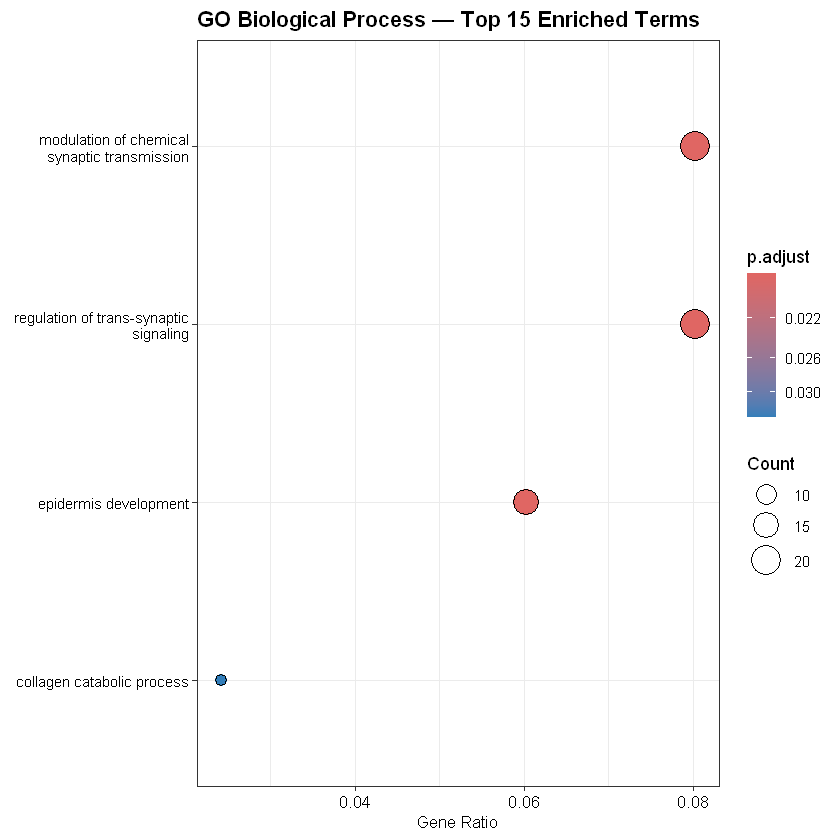

In [36]:
# ============================================================
# FUNCTIONAL ENRICHMENT - STEP 5: Visualizations
# ============================================================

# --- PART A: GO Biological Process Dotplot ---

cat("=== PART A: GO BP Dotplot ===\n")

bp_dotplot <- dotplot(
  go_bp,
  showCategory = 15,        # show top 15 terms
  font.size    = 10
) +
  labs(
    title    = "GO Biological Process — Top 15 Enriched Terms",
    x        = "Gene Ratio",
    color    = "Adjusted\np-value"
  ) +
  theme(
    plot.title    = element_text(face = "bold", size = 13),
    plot.subtitle = element_text(color = "gray40", size = 10),
    axis.text.y   = element_text(size = 9)
  )

ggsave(
  "GO_BP_dotplot.png",
  bp_dotplot,
  width  = 10,
  height = 8,
  dpi    = 200
)

cat("✔ GO_BP_dotplot.png saved\n")
print(bp_dotplot)


=== PART B: GO MF Dotplot ===


Ignoring unknown labels:
• colour : "Adjusted p-value"


✔ GO_MF_dotplot.png saved


Ignoring unknown labels:
• colour : "Adjusted p-value"


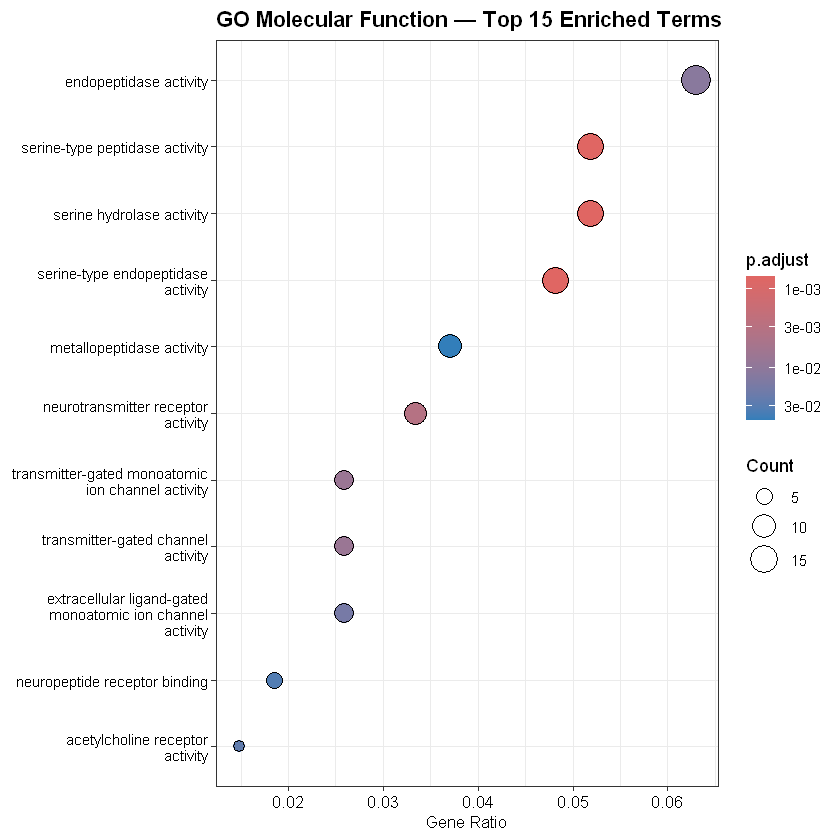

In [37]:
# --- PART B: GO Molecular Function Dotplot ---

cat("\n=== PART B: GO MF Dotplot ===\n")

mf_dotplot <- dotplot(
  go_mf,
  showCategory = 15,
  font.size    = 10
) +
  labs(
    title    = "GO Molecular Function — Top 15 Enriched Terms",
    x        = "Gene Ratio",
    color    = "Adjusted\np-value"
  ) +
  theme(
    plot.title    = element_text(face = "bold", size = 13),
    plot.subtitle = element_text(color = "gray40", size = 10),
    axis.text.y   = element_text(size = 9)
  )

ggsave(
  "GO_MF_dotplot.png",
  mf_dotplot,
  width  = 10,
  height = 8,
  dpi    = 200
)

cat("✔ GO_MF_dotplot.png saved\n")
print(mf_dotplot)


=== PART C: GO CC Dotplot ===


Ignoring unknown labels:
• colour : "Adjusted p-value"


✔ GO_CC_dotplot.png saved


Ignoring unknown labels:
• colour : "Adjusted p-value"


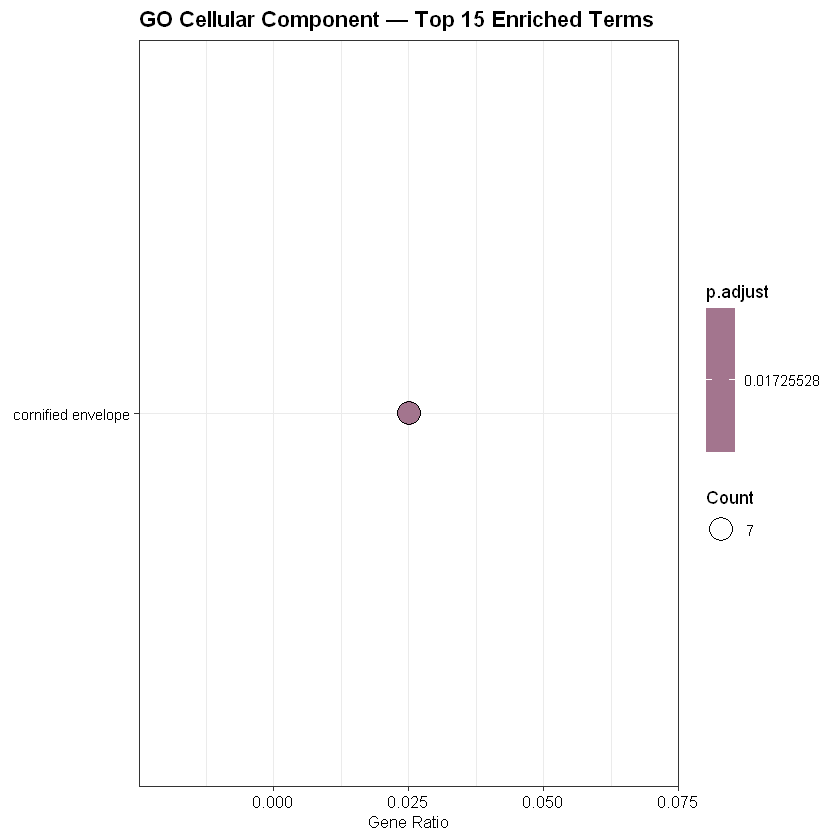

In [38]:
# --- PART C: GO Cellular Component Dotplot ---

cat("\n=== PART C: GO CC Dotplot ===\n")

cc_dotplot <- dotplot(
  go_cc,
  showCategory = 15,
  font.size    = 10
) +
  labs(
    title    = "GO Cellular Component — Top 15 Enriched Terms",
    x        = "Gene Ratio",
    color    = "Adjusted\np-value"
  ) +
  theme(
    plot.title    = element_text(face = "bold", size = 13),
    plot.subtitle = element_text(color = "gray40", size = 10),
    axis.text.y   = element_text(size = 9)
  )

ggsave(
  "GO_CC_dotplot.png",
  cc_dotplot,
  width  = 10,
  height = 8,
  dpi    = 200
)

cat("✔ GO_CC_dotplot.png saved\n")
print(cc_dotplot)


=== PART D: KEGG Dotplot ===


Ignoring unknown labels:
• colour : "Adjusted p-value"


✔ KEGG_dotplot.png saved


Ignoring unknown labels:
• colour : "Adjusted p-value"


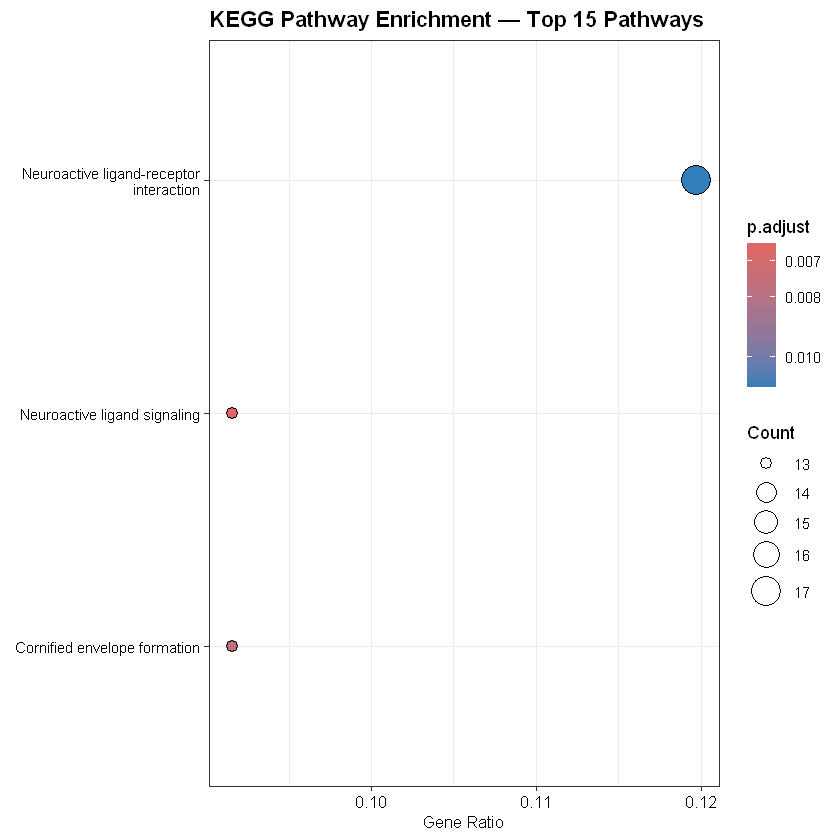

In [39]:
# --- PART D: KEGG Dotplot ---

cat("\n=== PART D: KEGG Dotplot ===\n")

kegg_dotplot <- dotplot(
  kegg_all,
  showCategory = 15,
  font.size    = 10
) +
  labs(
    title    = "KEGG Pathway Enrichment — Top 15 Pathways",
    x        = "Gene Ratio",
    color    = "Adjusted\np-value"
  ) +
  theme(
    plot.title    = element_text(face = "bold", size = 13),
    plot.subtitle = element_text(color = "gray40", size = 10),
    axis.text.y   = element_text(size = 9)
  )

ggsave(
  "KEGG_dotplot.png",
  kegg_dotplot,
  width  = 10,
  height = 8,
  dpi    = 200
)

cat("✔ KEGG_dotplot.png saved\n")
print(kegg_dotplot)


=== PART E: KEGG Bubble Chart ===
✔ KEGG_bubble_chart.png saved


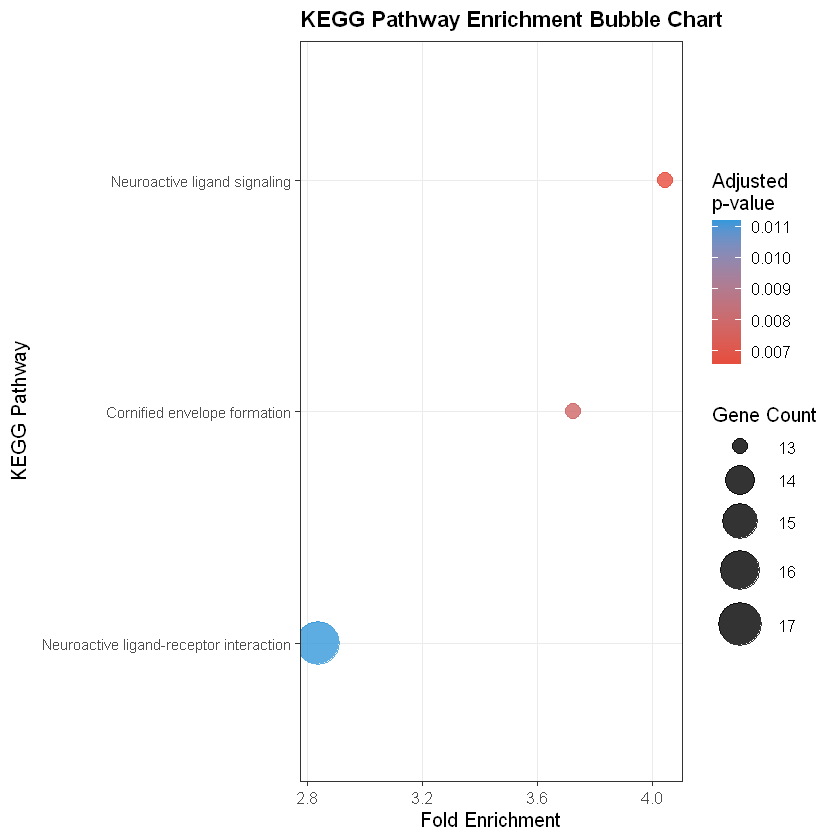

In [40]:
# --- PART E: KEGG Bubble Chart ---
# Bubble chart shows same info as dotplot
# but with bubble size = gene count
# and color = fold enrichment

cat("\n=== PART E: KEGG Bubble Chart ===\n")

# Extract KEGG results for plotting
kegg_plot_df <- kegg_all@result[
  kegg_all@result$p.adjust < 0.05, ]

# Calculate fold enrichment
# GeneRatio = k/n, BgRatio = K/N
# Fold enrichment = (k/n) / (K/N)
kegg_plot_df$GeneRatio_num <- sapply(
  kegg_plot_df$GeneRatio,
  function(x) eval(parse(text = x))
)

kegg_plot_df$BgRatio_num <- sapply(
  kegg_plot_df$BgRatio,
  function(x) eval(parse(text = x))
)

kegg_plot_df$FoldEnrichment <- (
  kegg_plot_df$GeneRatio_num / kegg_plot_df$BgRatio_num
)

# Keep top 15 by p.adjust
kegg_plot_df <- head(
  kegg_plot_df[order(kegg_plot_df$p.adjust), ], 15
)

# Reorder for plotting
kegg_plot_df$Description <- factor(
  kegg_plot_df$Description,
  levels = kegg_plot_df$Description[
    order(kegg_plot_df$FoldEnrichment)]
)

# Build bubble chart
bubble_chart <- ggplot(
  kegg_plot_df,
  aes(
    x    = FoldEnrichment,
    y    = Description,
    size = Count,
    color = p.adjust
  )
) +
  geom_point(alpha = 0.8) +
  scale_color_gradient(
    low  = "#E74C3C",   # red = more significant
    high = "#3498DB",   # blue = less significant
    name = "Adjusted\np-value"
  ) +
  scale_size_continuous(
    range = c(4, 12),
    name  = "Gene Count"
  ) +
  labs(
    title    = "KEGG Pathway Enrichment Bubble Chart",
    x        = "Fold Enrichment",
    y        = "KEGG Pathway"
  ) +
  theme_bw(base_size = 12) +
  theme(
    plot.title    = element_text(face = "bold", size = 13),
    plot.subtitle = element_text(color = "gray40", size = 10),
    axis.text.y   = element_text(size = 9),
    panel.grid.minor = element_blank()
  )

ggsave(
  "KEGG_bubble_chart.png",
  bubble_chart,
  width  = 11,
  height = 8,
  dpi    = 200
)

cat("✔ KEGG_bubble_chart.png saved\n")
print(bubble_chart)

In [41]:
# --- PART F: Final summary ---

cat("\n============================================================\n")
cat("     FUNCTIONAL ENRICHMENT ANALYSIS COMPLETE\n")
cat("============================================================\n")
cat(sprintf("  Location: %s\n\n", getwd()))
cat("Files saved:\n")
cat("  1. GO_BP_results.tsv\n")
cat("  2. GO_MF_results.tsv\n")
cat("  3. GO_CC_results.tsv\n")
cat("  4. KEGG_all_DEGs_results.tsv\n")
cat("  5. KEGG_upregulated_results.tsv\n")
cat("  6. KEGG_downregulated_results.tsv\n")
cat("  7. GO_BP_dotplot.png\n")
cat("  8. GO_MF_dotplot.png\n")
cat("  9. GO_CC_dotplot.png\n")
cat("  10. KEGG_dotplot.png\n")
cat("  11. KEGG_bubble_chart.png\n")
cat("============================================================\n")


     FUNCTIONAL ENRICHMENT ANALYSIS COMPLETE
  Location: C:/jupyter demo

Files saved:
  1. GO_BP_results.tsv
  2. GO_MF_results.tsv
  3. GO_CC_results.tsv
  4. KEGG_all_DEGs_results.tsv
  5. KEGG_upregulated_results.tsv
  6. KEGG_downregulated_results.tsv
  7. GO_BP_dotplot.png
  8. GO_MF_dotplot.png
  9. GO_CC_dotplot.png
  10. KEGG_dotplot.png
  11. KEGG_bubble_chart.png


In [50]:
# ============================================================
# Extract exact numbers for results section
# ============================================================

cat("=== GO Results ===\n\n")

# GO BP
bp_sig <- go_bp@result[go_bp@result$p.adjust < 0.05, ]
cat(sprintf("GO BP significant terms:  %d\n", nrow(bp_sig)))
cat("Top 5 BP terms:\n")
print(head(bp_sig[, c("Description", "Count", "p.adjust")], 5))

# GO MF
mf_sig <- go_mf@result[go_mf@result$p.adjust < 0.05, ]
cat(sprintf("\nGO MF significant terms:  %d\n", nrow(mf_sig)))
cat("Top 5 MF terms:\n")
print(head(mf_sig[, c("Description", "Count", "p.adjust")], 5))

# GO CC
cc_sig <- go_cc@result[go_cc@result$p.adjust < 0.05, ]
cat(sprintf("\nGO CC significant terms:  %d\n", nrow(cc_sig)))
cat("Top 5 CC terms:\n")
print(head(cc_sig[, c("Description", "Count", "p.adjust")], 5))

cat("\n=== KEGG Results ===\n\n")

# KEGG all
kegg_sig <- kegg_all@result[kegg_all@result$p.adjust < 0.05, ]
cat(sprintf("KEGG significant pathways: %d\n", nrow(kegg_sig)))
cat("Top 10 KEGG pathways:\n")
print(head(kegg_sig[, c("Description", "Count", "p.adjust")], 10))

# KEGG up
kegg_up_sig <- kegg_up@result[kegg_up@result$p.adjust < 0.05, ]
cat(sprintf("\nKEGG upregulated pathways: %d\n", nrow(kegg_up_sig)))
cat("Top 5:\n")
print(head(kegg_up_sig[, c("Description", "Count", "p.adjust")], 5))

# KEGG down
kegg_down_sig <- kegg_down@result[kegg_down@result$p.adjust < 0.05, ]
cat(sprintf("\nKEGG downregulated pathways: %d\n", nrow(kegg_down_sig)))
cat("Top 5:\n")
print(head(kegg_down_sig[, c("Description", "Count", "p.adjust")], 5))

=== GO Results ===

GO BP significant terms:  4
Top 5 BP terms:
                                            Description Count   p.adjust
GO:0050804 modulation of chemical synaptic transmission    20 0.01827100
GO:0008544                        epidermis development    15 0.01827100
GO:0099177       regulation of trans-synaptic signaling    20 0.01827100
GO:0030574                   collagen catabolic process     6 0.03346861

GO MF significant terms:  11
Top 5 MF terms:
                                                 Description Count     p.adjust
GO:0008236                    serine-type peptidase activity    14 0.0006917673
GO:0017171                         serine hydrolase activity    14 0.0006917673
GO:0004252                serine-type endopeptidase activity    13 0.0006917673
GO:0030594                neurotransmitter receptor activity     9 0.0031858036
GO:0022824 transmitter-gated monoatomic ion channel activity     7 0.0071647942

GO CC significant terms:  1
Top 5 CC terms:


In [12]:
# ============================================================
# QUICK REBUILD
# ============================================================

library(limma)
library(edgeR)
library(data.table)
library(ggplot2)
library(ggrepel)
library(pheatmap)
library(dplyr)
library(RColorBrewer)
library(sva)
library(clusterProfiler)
library(org.Hs.eg.db)
library(enrichplot)
library(AnnotationDbi)
library(ggVennDiagram)

cat("✔ Libraries loaded\n")

✔ Libraries loaded


In [13]:
# Load final matrix
cat("Loading final matrix...\n")

final_df <- fread(
  "C:/jupyter demo/TCGA_LUSC_LUAD_final_expression.tsv",
  header = TRUE,
  sep    = "\t"
)

final_matrix <- as.matrix(final_df[, -1])
rownames(final_matrix) <- final_df$Gene

cat(sprintf("✔ final_matrix: %d genes × %d samples\n",
            nrow(final_matrix), ncol(final_matrix)))

Loading final matrix...


Warning message in (if (.Platform$OS.type == "unix") system else shell)(paste0("(", :
"'(C:/jupyter demo/TCGA_LUSC_LUAD_final_expression.tsv) > C:\Users\aryan\AppData\Local\Temp\RtmpOGlLUO\file538ce91191c' execution failed with error code 1"


ERROR: Error in fread("C:/jupyter demo/TCGA_LUSC_LUAD_final_expression.tsv", : External command failed with exit code 1. This can happen when the disk is full in the temporary directory ('C:\Users\aryan\AppData\Local\Temp\RtmpOGlLUO'). See ?fread for the tmpdir argument.


In [14]:
# --- Fix 1: Check disk space and temp directory ---
cat("Checking temp directory...\n")
cat(sprintf("Temp dir: %s\n", tempdir()))

# --- Fix 2: Use read.table instead of fread ---
# read.table handles spaces in paths better

cat("\nLoading final matrix using read.table...\n")

final_df <- read.table(
  "C:/jupyter demo/TCGA_LUSC_LUAD_final_expression.tsv",
  header    = TRUE,
  sep       = "\t",
  row.names = 1,      # first column as rownames
  check.names = FALSE
)

final_matrix <- as.matrix(final_df)

cat(sprintf("✔ final_matrix: %d genes × %d samples\n",
            nrow(final_matrix), ncol(final_matrix)))

Checking temp directory...
Temp dir: C:\Users\aryan\AppData\Local\Temp\RtmpOGlLUO

Loading final matrix using read.table...


Warning message in file(file, "rt"):
"cannot open file 'C:/jupyter demo/TCGA_LUSC_LUAD_final_expression.tsv': No such file or directory"


ERROR: Error in file(file, "rt"): cannot open the connection


In [15]:
# --- Find the file ---
cat("Searching for the file...\n\n")

# Check working directory
cat(sprintf("Current working directory: %s\n\n", getwd()))

# List ALL tsv files on common locations
cat("TSV files in C:/jupyter demo:\n")
print(list.files("C:/jupyter demo", 
                 pattern = "*.tsv", 
                 full.names = TRUE))

cat("\nTSV files in Downloads:\n")
print(list.files("C:/Users/aryan/Downloads",
                 pattern = "*.tsv",
                 full.names = TRUE))

cat("\nAll files in C:/jupyter demo:\n")
print(list.files("C:/jupyter demo", 
                 full.names = TRUE))

Searching for the file...

Current working directory: C:/jupyter demo

TSV files in C:/jupyter demo:
[1] "C:/jupyter demo/GO_BP_results.tsv"             
[2] "C:/jupyter demo/GO_CC_results.tsv"             
[3] "C:/jupyter demo/GO_MF_results.tsv"             
[4] "C:/jupyter demo/KEGG_all_DEGs_results.tsv"     
[5] "C:/jupyter demo/KEGG_downregulated_results.tsv"
[6] "C:/jupyter demo/KEGG_upregulated_results.tsv"  

TSV files in Downloads:
[1] "C:/Users/aryan/Downloads/DEG_full_results.tsv"               
[2] "C:/Users/aryan/Downloads/DEG_significant_only.tsv"           
[3] "C:/Users/aryan/Downloads/Shared_DEGs_LUSC_LUAD.tsv"          
[4] "C:/Users/aryan/Downloads/TCGA-LUAD.star_counts.tsv"          
[5] "C:/Users/aryan/Downloads/TCGA-LUAD.star_counts.tsv.gz"       
[6] "C:/Users/aryan/Downloads/TCGA-LUSC.star_counts.tsv"          
[7] "C:/Users/aryan/Downloads/TCGA-LUSC.star_counts.tsv.gz"       
[8] "C:/Users/aryan/Downloads/TCGA_LUSC_LUAD_final_expression.tsv"

All files in C:/jup

In [16]:
# --- Load deg_results directly from saved RDS file ---
cat("Loading deg_results from RDS file...\n")

deg_results <- readRDS("C:/jupyter demo/deg_results.rds")

cat(sprintf("✔ deg_results loaded: %d genes\n", nrow(deg_results)))
cat(sprintf("✔ Upregulated:   %d\n",
            sum(deg_results$Status == "Upregulated")))
cat(sprintf("✔ Downregulated: %d\n",
            sum(deg_results$Status == "Downregulated")))

Loading deg_results from RDS file...
✔ deg_results loaded: 36650 genes
✔ Upregulated:   167
✔ Downregulated: 210


In [17]:
# --- Load final matrix from Downloads ---
cat("\nLoading final matrix from Downloads...\n")

final_df <- read.table(
  "C:/Users/aryan/Downloads/TCGA_LUSC_LUAD_final_expression.tsv",
  header      = TRUE,
  sep         = "\t",
  row.names   = 1,
  check.names = FALSE
)

final_matrix <- as.matrix(final_df)

cat(sprintf("✔ final_matrix: %d genes × %d samples\n",
            nrow(final_matrix), ncol(final_matrix)))


Loading final matrix from Downloads...
✔ final_matrix: 36650 genes × 1139 samples


In [19]:
# --- Rebuild remaining objects ---

# Batch labels
lusc_check <- fread(
  "C:/Users/aryan/Downloads/TCGA-LUSC.star_counts.tsv.gz",
  header = TRUE, sep = "\t", nrows = 5
)
luad_check <- fread(
  "C:/Users/aryan/Downloads/TCGA-LUAD.star_counts.tsv.gz",
  header = TRUE, sep = "\t", nrows = 5
)

lusc_sample_names <- colnames(lusc_check)[-1]

final_batch <- ifelse(
  colnames(final_matrix) %in% lusc_sample_names,
  "LUSC", "LUAD"
)

# Metadata
sample_types <- ifelse(
  substr(colnames(final_matrix), 14, 15) == "11",
  "Normal", "Tumor"
)

metadata <- data.frame(
  Sample     = colnames(final_matrix),
  SampleType = factor(sample_types,
                      levels = c("Normal", "Tumor")),
  Dataset    = final_batch,
  row.names  = colnames(final_matrix)
)

# Shifted matrix
final_matrix_shifted <- final_matrix - min(final_matrix)

cat(sprintf("✔ Metadata: Tumor=%d | Normal=%d\n",
            sum(metadata$SampleType == "Tumor"),
            sum(metadata$SampleType == "Normal")))
cat(sprintf("✔ Shifted matrix: Min=%.3f | Max=%.3f\n",
            min(final_matrix_shifted),
            max(final_matrix_shifted)))

✔ Metadata: Tumor=1029 | Normal=110
✔ Shifted matrix: Min=0.000 | Max=39.004


In [20]:
# --- Final verification ---
cat("\n=== Checking Key Objects ===\n")
cat(sprintf("final_matrix:         %s\n", exists("final_matrix")))
cat(sprintf("final_matrix_shifted: %s\n", exists("final_matrix_shifted")))
cat(sprintf("metadata:             %s\n", exists("metadata")))
cat(sprintf("deg_results:          %s\n", exists("deg_results")))
cat(sprintf("final_batch:          %s\n", exists("final_batch")))


=== Checking Key Objects ===
final_matrix:         TRUE
final_matrix_shifted: TRUE
metadata:             TRUE
deg_results:          TRUE
final_batch:          TRUE


In [21]:
# ============================================================
# PPI NETWORK - STEP 1: Export Upregulated DEGs
# ============================================================

cat("=== STEP 1: Extracting Upregulated DEGs ===\n\n")

# Extract upregulated genes
up_degs <- deg_results[deg_results$Status == "Upregulated", ]
up_degs <- up_degs[order(-up_degs$logFC), ]

# Get gene names
up_gene_list <- rownames(up_degs)

cat(sprintf("Total upregulated DEGs:  %d\n", length(up_gene_list)))
cat(sprintf("logFC range:             [%.3f, %.3f]\n",
            min(up_degs$logFC), max(up_degs$logFC)))

cat("\nTop 10 upregulated genes:\n")
print(head(up_gene_list, 10))

# Save to working directory
write.table(
  data.frame(Gene = up_gene_list),
  file      = "Upregulated_DEGs_for_STRING.txt",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

cat(sprintf("\n✔ Gene list saved: Upregulated_DEGs_for_STRING.txt\n"))
cat(sprintf("  Location: %s\n", getwd()))

=== STEP 1: Extracting Upregulated DEGs ===

Total upregulated DEGs:  167
logFC range:             [0.501, 0.884]

Top 10 upregulated genes:
 [1] "CASC9"      "PITX2"      "HOXC13"     "PRAME"      "CST1"      
 [6] "LCAL1"      "SACK1A-AS1" "BARX1"      "BBOX1-AS1"  "GABRA3"    

✔ Gene list saved: Upregulated_DEGs_for_STRING.txt
  Location: C:/jupyter demo


In [22]:
# ============================================================
# PPI NETWORK - STEP 2: Query STRING Database
# ============================================================

# --- Install required packages ---
if (!requireNamespace("httr", quietly = TRUE))
  install.packages("httr")
if (!requireNamespace("jsonlite", quietly = TRUE))
  install.packages("jsonlite")
if (!requireNamespace("igraph", quietly = TRUE))
  install.packages("igraph")

library(httr)
library(jsonlite)
library(igraph)

cat("✔ Packages loaded\n\n")


Attaching package: 'httr'


The following object is masked from 'package:Biobase':

    content




✔ Packages loaded



In [23]:
# --- PART A: Map gene symbols to STRING IDs ---
# STRING uses its own IDs so we need to map first

cat("=== PART A: Mapping genes to STRING IDs ===\n\n")

# Collapse gene list into one string for API
genes_string <- paste(up_gene_list, collapse = "%0d")

# Query STRING mapping API
map_url <- "https://string-db.org/api/json/get_string_ids"

map_response <- POST(
  map_url,
  body = list(
    identifiers   = paste(up_gene_list, collapse = "\r"),
    species       = "9606",   # 9606 = Homo sapiens
    limit         = "1",      # take best match per gene
    caller_identity = "bioinformatics_analysis"
  ),
  encode = "form"
)

# Parse response
map_data <- fromJSON(content(map_response, "text",
                             encoding = "UTF-8"))

cat(sprintf("Genes submitted:    %d\n", length(up_gene_list)))
cat(sprintf("Genes mapped:       %d\n", nrow(map_data)))

# Preview mapping
cat("\nFirst 5 mapped genes:\n")
print(head(map_data[, c("queryItem", "preferredName",
                         "stringId")], 5))

=== PART A: Mapping genes to STRING IDs ===

Genes submitted:    167
Genes mapped:       129

First 5 mapped genes:
  queryItem preferredName             stringId
1     PITX2         PITX2 9606.ENSP00000495061
2    HOXC13        HOXC13 9606.ENSP00000243056
3     PRAME         PRAME 9606.ENSP00000445675
4      CST1          CST1 9606.ENSP00000305731
5     BARX1         BARX1 9606.ENSP00000253968


In [24]:
# --- PART B: Get interactions from STRING ---
# Now query interactions using mapped STRING IDs

cat("\n=== PART B: Fetching Interactions from STRING ===\n\n")
cat("This may take 1-2 minutes...\n")

# Get STRING IDs
string_ids <- paste(map_data$stringId, collapse = "%0d")

# Query interaction network
int_url <- "https://string-db.org/api/json/network"

int_response <- POST(
  int_url,
  body = list(
    identifiers     = paste(map_data$stringId,
                            collapse = "\r"),
    species         = "9606",
    required_score  = "400",  # 0.4 confidence = 400
    caller_identity = "bioinformatics_analysis"
  ),
  encode = "form"
)

# Parse interactions
interactions <- fromJSON(content(int_response, "text",
                                 encoding = "UTF-8"))

cat(sprintf("✔ Total interactions fetched: %d\n",
            nrow(interactions)))
cat(sprintf("✔ Confidence score threshold: 0.4\n"))

# Preview
cat("\nFirst 5 interactions:\n")
print(head(interactions[, c("preferredName_A",
                             "preferredName_B",
                             "score")], 5))


=== PART B: Fetching Interactions from STRING ===

This may take 1-2 minutes...
✔ Total interactions fetched: 122
✔ Confidence score threshold: 0.4

First 5 interactions:
  preferredName_A preferredName_B score
1           MMP11           MMP13 0.443
2           MMP11         COL11A1 0.732
3           MMP11            MMP1 0.772
4            MIOX         AKR1B10 0.820
5         CYP24A1             CA9 0.784


In [25]:
# --- PART C: Filter and clean interactions ---

cat("\n=== PART C: Filtering Interactions ===\n\n")

# Keep only interactions with score >= 0.4
interactions_filtered <- interactions[
  interactions$score >= 0.4, ]

cat(sprintf("Interactions before filter: %d\n", nrow(interactions)))
cat(sprintf("Interactions after filter:  %d\n",
            nrow(interactions_filtered)))

# Extract clean edge list
edge_list <- data.frame(
  Gene_A = interactions_filtered$preferredName_A,
  Gene_B = interactions_filtered$preferredName_B,
  Score  = interactions_filtered$score
)

# Save edge list
write.table(
  edge_list,
  file      = "STRING_interactions.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

cat("✔ Edge list saved: STRING_interactions.tsv\n")
cat(sprintf("  Location: %s\n", getwd()))


=== PART C: Filtering Interactions ===

Interactions before filter: 122
Interactions after filter:  122
✔ Edge list saved: STRING_interactions.tsv
  Location: C:/jupyter demo


In [26]:
# --- PART D: Check if TOP2A is in network ---

cat("\n=== Checking TOP2A in Network ===\n\n")

top2a_interactions <- edge_list[
  edge_list$Gene_A == "TOP2A" |
  edge_list$Gene_B == "TOP2A", ]

cat(sprintf("TOP2A interactions found: %d\n",
            nrow(top2a_interactions)))

if (nrow(top2a_interactions) > 0) {
  cat("\nTOP2A interaction partners:\n")
  print(top2a_interactions)
} else {
  cat("⚠ TOP2A not found in upregulated network\n")
  cat("  This is expected since TOP2A was below logFC threshold\n")
  cat("  We will add it manually in next step\n")
}


=== Checking TOP2A in Network ===

TOP2A interactions found: 0
⚠ TOP2A not found in upregulated network
  This is expected since TOP2A was below logFC threshold
  We will add it manually in next step


In [27]:
# ============================================================
# TOP 10 HUB GENES BY DEGREE
# ============================================================

cat("=== Top 10 Hub Genes by Degree ===\n\n")

# Build network from edge list
network <- graph_from_data_frame(
  edge_list,
  directed = FALSE
)

# Calculate degree for each gene
# Degree = number of connections a gene has
degree_scores <- degree(network)

# Sort by degree (highest first)
degree_sorted <- sort(degree_scores, decreasing = TRUE)

# Top 10
top10_genes <- head(degree_sorted, 10)

cat("Top 10 Hub Genes:\n\n")
cat(sprintf("%-5s %-15s %s\n", "Rank", "Gene", "Connections"))
cat(paste(rep("-", 35), collapse = ""), "\n")

for (i in 1:10) {
  cat(sprintf("%-5d %-15s %d\n",
              i,
              names(top10_genes)[i],
              top10_genes[i]))
}

# Save top 10
top10_df <- data.frame(
  Rank        = 1:10,
  Gene        = names(top10_genes),
  Connections = as.numeric(top10_genes)
)

write.table(
  top10_df,
  file      = "Top10_Hub_Genes.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

cat(sprintf("\n✔ Top 10 hub genes saved: Top10_Hub_Genes.tsv\n"))
cat(sprintf("  Location: %s\n", getwd()))

=== Top 10 Hub Genes by Degree ===

Top 10 Hub Genes:

Rank  Gene            Connections
----------------------------------- 
1     KRT16           12
2     KRT6B           11
3     KRT6A           10
4     SPRR1B          9
5     SPRR3           8
6     LHX2            8
7     KRT6C           6
8     DSG3            6
9     MMP13           6
10    SERPINB4        6

✔ Top 10 hub genes saved: Top10_Hub_Genes.tsv
  Location: C:/jupyter demo


In [28]:
# ============================================================
# Check CST1 connections
# ============================================================

cat("=== CST1 Network Information ===\n\n")

# Check if CST1 is in network
if ("CST1" %in% names(degree_scores)) {
  
  cat(sprintf("CST1 total connections: %d\n\n",
              degree_scores["CST1"]))
  
  # Find all genes CST1 connects to
  cst1_partners <- edge_list[
    edge_list$Gene_A == "CST1" |
    edge_list$Gene_B == "CST1", ]
  
  cat(sprintf("CST1 interaction partners:\n\n"))
  cat(sprintf("%-5s %-15s %-15s %s\n",
              "No.", "Gene_A", "Gene_B", "Score"))
  cat(paste(rep("-", 45), collapse = ""), "\n")
  
  for (i in 1:nrow(cst1_partners)) {
    cat(sprintf("%-5d %-15s %-15s %.3f\n",
                i,
                cst1_partners$Gene_A[i],
                cst1_partners$Gene_B[i],
                cst1_partners$Score[i]))
  }
  
} else {
  cat("⚠ CST1 not found in network\n")
  cat("  CST1 may have no interactions above 0.4 threshold\n")
}

=== CST1 Network Information ===

CST1 total connections: 1

CST1 interaction partners:

No.   Gene_A          Gene_B          Score
--------------------------------------------- 
1     CST4            CST1            0.929


In [29]:
# ============================================================
# Check KRT16, KRT6B, KRT6A connections
# ============================================================

cat("=== Keratin Gene Network Information ===\n\n")

keratin_genes <- c("KRT16", "KRT6B", "KRT6A")

for (gene in keratin_genes) {
  
  cat(sprintf("--- %s ---\n", gene))
  
  if (gene %in% names(degree_scores)) {
    
    cat(sprintf("Total connections: %d\n", 
                degree_scores[gene]))
    
    # Find all partners
    partners <- edge_list[
      edge_list$Gene_A == gene |
      edge_list$Gene_B == gene, ]
    
    # Get partner names
    partner_names <- ifelse(
      partners$Gene_A == gene,
      partners$Gene_B,
      partners$Gene_A
    )
    
    cat(sprintf("Interaction partners:\n"))
    for (i in 1:nrow(partners)) {
      cat(sprintf("  %d. %-15s Score: %.3f\n",
                  i,
                  partner_names[i],
                  partners$Score[i]))
    }
    
  } else {
    cat("⚠ Not found in network\n")
  }
  
  cat("\n")
}

# Compare all three
cat("=== Comparison Summary ===\n\n")
cat(sprintf("%-10s %s\n", "Gene", "Connections"))
cat(paste(rep("-", 25), collapse = ""), "\n")

for (gene in keratin_genes) {
  if (gene %in% names(degree_scores)) {
    cat(sprintf("%-10s %d\n", gene, degree_scores[gene]))
  } else {
    cat(sprintf("%-10s Not in network\n", gene))
  }
}

=== Keratin Gene Network Information ===

--- KRT16 ---
Total connections: 12
Interaction partners:
  1. KRT75           Score: 0.458
  2. KRT6C           Score: 0.502
  3. KRT6B           Score: 0.938
  4. DSG3            Score: 0.570
  5. IL36G           Score: 0.419
  6. LY6D            Score: 0.495
  7. KLK6            Score: 0.469
  8. SERPINB4        Score: 0.480
  9. SBSN            Score: 0.489
  10. SPRR3           Score: 0.582
  11. SPRR1B          Score: 0.687
  12. KRT6A           Score: 0.928

--- KRT6B ---
Total connections: 11
Interaction partners:
  1. KRT75           Score: 0.555
  2. KRT6C           Score: 0.772
  3. TMPRSS11D       Score: 0.414
  4. KLK6            Score: 0.542
  5. SERPINB5        Score: 0.552
  6. SERPINB4        Score: 0.569
  7. SPRR3           Score: 0.607
  8. SPRR1B          Score: 0.741
  9. DSG3            Score: 0.786
  10. KRT6A           Score: 0.886
  11. KRT16           Score: 0.938

--- KRT6A ---
Total connections: 10
Interaction partn

In [30]:
# ============================================================
# Check Keratin genes in LUSC and LUAD separately
# ============================================================

cat("=== Keratin Gene Expression Analysis ===\n\n")

keratin_genes <- c("KRT16", "KRT6B", "KRT6A")

for (gene in keratin_genes) {
  
  cat(sprintf("--- %s ---\n", gene))
  
  # Check if gene exists in our data
  if (gene %in% rownames(deg_results)) {
    
    # Overall DEG status
    cat(sprintf("Overall logFC:      %.4f\n",
                deg_results[gene, "logFC"]))
    cat(sprintf("Overall adj.p:      %.2e\n",
                deg_results[gene, "adj.P.Val"]))
    cat(sprintf("Overall Status:     %s\n",
                as.character(deg_results[gene, "Status"])))
    
    # Check in LUSC specific
    if (gene %in% sig_lusc) {
      lusc_fc <- deg_lusc[gene, "logFC"]
      lusc_p  <- deg_lusc[gene, "adj.P.Val"]
      cat(sprintf("LUSC:               ✔ SIGNIFICANT (logFC=%.3f, p=%.2e)\n",
                  lusc_fc, lusc_p))
    } else {
      cat(sprintf("LUSC:               ✘ Not significant\n"))
    }
    
    # Check in LUAD specific
    if (gene %in% sig_luad) {
      luad_fc <- deg_luad[gene, "logFC"]
      luad_p  <- deg_luad[gene, "adj.P.Val"]
      cat(sprintf("LUAD:               ✔ SIGNIFICANT (logFC=%.3f, p=%.2e)\n",
                  luad_fc, luad_p))
    } else {
      cat(sprintf("LUAD:               ✘ Not significant\n"))
    }
    
    # Check in shared DEGs
    if (gene %in% common_degs) {
      cat(sprintf("Shared DEGs:        ✔ YES — found in both\n"))
    } else {
      cat(sprintf("Shared DEGs:        ✘ NOT shared\n"))
    }
    
  } else {
    cat(sprintf("⚠ %s not found in DEG results\n", gene))
  }
  
  cat("\n")
}

=== Keratin Gene Expression Analysis ===

--- KRT16 ---
Overall logFC:      0.6894
Overall adj.p:      1.06e-19
Overall Status:     Upregulated


ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'table' in selecting a method for function '%in%': object 'sig_lusc' not found


In [31]:
# ============================================================
# Rebuild sig_lusc and sig_luad
# ============================================================

cat("Rebuilding LUSC and LUAD specific DEGs...\n\n")

library(limma)

# Split samples by dataset
lusc_samples <- rownames(metadata[metadata$Dataset == "LUSC", ])
luad_samples <- rownames(metadata[metadata$Dataset == "LUAD", ])

lusc_mat_deg <- final_matrix_shifted[, lusc_samples]
luad_mat_deg <- final_matrix_shifted[, luad_samples]

lusc_meta <- metadata[lusc_samples, ]
luad_meta <- metadata[luad_samples, ]

# --- LUSC DEGs ---
design_lusc <- model.matrix(~ 0 + SampleType, data = lusc_meta)
colnames(design_lusc) <- c("Normal", "Tumor")
voom_lusc   <- voom(lusc_mat_deg, design_lusc, plot = FALSE)
fit_lusc    <- lmFit(voom_lusc, design_lusc)
contrast_lusc <- makeContrasts(
  TumorVsNormal = Tumor - Normal,
  levels = design_lusc)
fit_lusc2   <- contrasts.fit(fit_lusc, contrast_lusc)
fit_lusc2   <- eBayes(fit_lusc2)
deg_lusc    <- topTable(fit_lusc2, coef = "TumorVsNormal",
                        number = Inf, adjust.method = "BH")
sig_lusc    <- rownames(deg_lusc[
  abs(deg_lusc$logFC) > 0.5 &
  deg_lusc$adj.P.Val < 0.05, ])

cat(sprintf("✔ LUSC DEGs: %d\n", length(sig_lusc)))

# --- LUAD DEGs ---
design_luad <- model.matrix(~ 0 + SampleType, data = luad_meta)
colnames(design_luad) <- c("Normal", "Tumor")
voom_luad   <- voom(luad_mat_deg, design_luad, plot = FALSE)
fit_luad    <- lmFit(voom_luad, design_luad)
contrast_luad <- makeContrasts(
  TumorVsNormal = Tumor - Normal,
  levels = design_luad)
fit_luad2   <- contrasts.fit(fit_luad, contrast_luad)
fit_luad2   <- eBayes(fit_luad2)
deg_luad    <- topTable(fit_luad2, coef = "TumorVsNormal",
                        number = Inf, adjust.method = "BH")
sig_luad    <- rownames(deg_luad[
  abs(deg_luad$logFC) > 0.5 &
  deg_luad$adj.P.Val < 0.05, ])

cat(sprintf("✔ LUAD DEGs: %d\n", length(sig_luad)))

# Shared DEGs
common_degs <- intersect(sig_lusc, sig_luad)
cat(sprintf("✔ Shared DEGs: %d\n", length(common_degs)))

Rebuilding LUSC and LUAD specific DEGs...

✔ LUSC DEGs: 852
✔ LUAD DEGs: 232
✔ Shared DEGs: 168


In [32]:
# ============================================================
# Check Keratin genes in LUSC and LUAD separately
# ============================================================

cat("=== Keratin Gene Expression Analysis ===\n\n")

keratin_genes <- c("KRT16", "KRT6B", "KRT6A")

for (gene in keratin_genes) {
  
  cat(sprintf("--- %s ---\n", gene))
  
  # Check if gene exists in our data
  if (gene %in% rownames(deg_results)) {
    
    # Overall DEG status
    cat(sprintf("Overall logFC:      %.4f\n",
                deg_results[gene, "logFC"]))
    cat(sprintf("Overall adj.p:      %.2e\n",
                deg_results[gene, "adj.P.Val"]))
    cat(sprintf("Overall Status:     %s\n",
                as.character(deg_results[gene, "Status"])))
    
    # Check in LUSC specific
    if (gene %in% sig_lusc) {
      lusc_fc <- deg_lusc[gene, "logFC"]
      lusc_p  <- deg_lusc[gene, "adj.P.Val"]
      cat(sprintf("LUSC:               ✔ SIGNIFICANT (logFC=%.3f, p=%.2e)\n",
                  lusc_fc, lusc_p))
    } else {
      cat(sprintf("LUSC:               ✘ Not significant\n"))
    }
    
    # Check in LUAD specific
    if (gene %in% sig_luad) {
      luad_fc <- deg_luad[gene, "logFC"]
      luad_p  <- deg_luad[gene, "adj.P.Val"]
      cat(sprintf("LUAD:               ✔ SIGNIFICANT (logFC=%.3f, p=%.2e)\n",
                  luad_fc, luad_p))
    } else {
      cat(sprintf("LUAD:               ✘ Not significant\n"))
    }
    
    # Check in shared DEGs
    if (gene %in% common_degs) {
      cat(sprintf("Shared DEGs:        ✔ YES — found in both\n"))
    } else {
      cat(sprintf("Shared DEGs:        ✘ NOT shared\n"))
    }
    
  } else {
    cat(sprintf("⚠ %s not found in DEG results\n", gene))
  }
  
  cat("\n")
}

=== Keratin Gene Expression Analysis ===

--- KRT16 ---
Overall logFC:      0.6894
Overall adj.p:      1.06e-19
Overall Status:     Upregulated
LUSC:               ✔ SIGNIFICANT (logFC=0.925, p=6.00e-13)
LUAD:               ✘ Not significant
Shared DEGs:        ✘ NOT shared

--- KRT6B ---
Overall logFC:      0.5924
Overall adj.p:      4.38e-18
Overall Status:     Upregulated
LUSC:               ✔ SIGNIFICANT (logFC=1.048, p=6.63e-19)
LUAD:               ✘ Not significant
Shared DEGs:        ✘ NOT shared

--- KRT6A ---
Overall logFC:      0.6497
Overall adj.p:      9.93e-15
Overall Status:     Upregulated
LUSC:               ✔ SIGNIFICANT (logFC=1.031, p=2.14e-10)
LUAD:               ✘ Not significant
Shared DEGs:        ✘ NOT shared



In [33]:
# ============================================================
# Find Shared Hub Genes in Both LUSC and LUAD
# ============================================================

cat("=== Shared Hub Genes Analysis ===\n\n")

# Check which of our top 10 network hub genes
# are present in both LUSC and LUAD

# First get top 10 hub genes from network
top10_genes <- names(head(sort(degree_scores, 
                               decreasing = TRUE), 10))

cat("Checking top 10 network hub genes:\n\n")
cat(sprintf("%-5s %-15s %-12s %-12s %-10s %-10s\n",
            "Rank", "Gene", "LUSC", "LUAD", 
            "Shared", "Connections"))
cat(paste(rep("-", 65), collapse = ""), "\n")

for (i in 1:length(top10_genes)) {
  gene <- top10_genes[i]
  
  in_lusc   <- ifelse(gene %in% sig_lusc, "✔ YES", "✘ NO")
  in_luad   <- ifelse(gene %in% sig_luad, "✔ YES", "✘ NO")
  in_shared <- ifelse(gene %in% common_degs, "✔ YES", "✘ NO")
  connections <- degree_scores[gene]
  
  cat(sprintf("%-5d %-15s %-12s %-12s %-10s %-10d\n",
              i, gene, in_lusc, in_luad,
              in_shared, connections))
}

=== Shared Hub Genes Analysis ===

Checking top 10 network hub genes:

Rank  Gene            LUSC         LUAD         Shared     Connections
----------------------------------------------------------------- 
1     KRT16           ✔ YES      ✘ NO       ✘ NO     12        
2     KRT6B           ✔ YES      ✘ NO       ✘ NO     11        
3     KRT6A           ✔ YES      ✘ NO       ✘ NO     10        
4     SPRR1B          ✔ YES      ✘ NO       ✘ NO     9         
5     SPRR3           ✔ YES      ✘ NO       ✘ NO     8         
6     LHX2            ✔ YES      ✘ NO       ✘ NO     8         
7     KRT6C           ✔ YES      ✘ NO       ✘ NO     6         
8     DSG3            ✔ YES      ✘ NO       ✘ NO     6         
9     MMP13           ✔ YES      ✔ YES      ✔ YES    6         
10    SERPINB4        ✔ YES      ✘ NO       ✘ NO     6         


In [34]:
# --- Find shared upregulated hub genes ---

cat("\n=== Shared Upregulated Hub Genes ===\n\n")

# Genes that are:
# 1. In our network (upregulated DEGs)
# 2. Significant in LUSC
# 3. Significant in LUAD
# 4. In common_degs (shared)

network_genes  <- names(degree_scores)

shared_hub_candidates <- network_genes[
  network_genes %in% common_degs
]

cat(sprintf("Network genes in shared DEGs: %d\n\n",
            length(shared_hub_candidates)))

if (length(shared_hub_candidates) > 0) {
  
  # Get their degree scores
  shared_hub_df <- data.frame(
    Gene        = shared_hub_candidates,
    Connections = degree_scores[shared_hub_candidates],
    logFC       = deg_results[shared_hub_candidates, "logFC"],
    adj.P.Val   = deg_results[shared_hub_candidates, "adj.P.Val"]
  )
  
  # Sort by connections
  shared_hub_df <- shared_hub_df[
    order(-shared_hub_df$Connections), ]
  
  cat("Shared hub genes ranked by connections:\n\n")
  cat(sprintf("%-5s %-15s %-12s %-10s %s\n",
              "Rank", "Gene", "Connections", 
              "logFC", "adj.P.Val"))
  cat(paste(rep("-", 55), collapse = ""), "\n")
  
  for (i in 1:nrow(shared_hub_df)) {
    cat(sprintf("%-5d %-15s %-12d %-10.3f %.2e\n",
                i,
                shared_hub_df$Gene[i],
                shared_hub_df$Connections[i],
                shared_hub_df$logFC[i],
                shared_hub_df$adj.P.Val[i]))
  }
  
  # Save
  write.table(
    shared_hub_df,
    file      = "Shared_Hub_Genes.tsv",
    sep       = "\t",
    row.names = FALSE,
    quote     = FALSE
  )
  
  cat(sprintf("\n✔ Shared hub genes saved: Shared_Hub_Genes.tsv\n"))
  
} else {
  cat("⚠ No shared hub genes found in network\n")
  cat("  This means upregulated shared DEGs have\n")
  cat("  no STRING interactions above 0.4 threshold\n")
  cat("  We will lower confidence threshold to 0.2\n")
}


=== Shared Upregulated Hub Genes ===

Network genes in shared DEGs: 13

Shared hub genes ranked by connections:

Rank  Gene            Connections  logFC      adj.P.Val
------------------------------------------------------- 
1     MMP13           6            0.633      1.15e-21
2     COL11A1         5            0.630      1.69e-25
3     PRAME           3            0.850      7.36e-22
4     KISS1R          2            0.613      8.14e-67
5     IL36RN          2            0.732      2.04e-36
6     TERT            2            0.708      4.08e-113
7     FEZF1           2            0.624      1.87e-33
8     LY6D            1            0.618      1.25e-19
9     ZYG11A          1            0.670      2.14e-55
10    PITX2           1            0.867      8.87e-57
11    CA9             1            0.641      1.70e-26
12    CST1            1            0.832      1.18e-32
13    IL1RAPL2        1            0.560      1.97e-104

✔ Shared hub genes saved: Shared_Hub_Genes.tsv


In [35]:
# ============================================================
# PPI NETWORK - All 13 Shared Hub Genes
# ============================================================

cat("=== Building Network for All 13 Shared Hub Genes ===\n\n")

# Our 13 shared hub genes
hub_genes <- shared_hub_df$Gene

cat("Hub genes selected:\n")
for (i in 1:length(hub_genes)) {
  cat(sprintf("  %d. %s\n", i, hub_genes[i]))
}

=== Building Network for All 13 Shared Hub Genes ===

Hub genes selected:
  1. MMP13
  2. COL11A1
  3. PRAME
  4. KISS1R
  5. IL36RN
  6. TERT
  7. FEZF1
  8. LY6D
  9. ZYG11A
  10. PITX2
  11. CA9
  12. CST1
  13. IL1RAPL2


In [36]:
# --- Extract interactions involving hub genes ---
# From our existing edge list, find all interactions
# where at least one gene is a hub gene

cat("\n=== Extracting Hub Gene Interactions ===\n\n")

hub_interactions <- edge_list[
  edge_list$Gene_A %in% hub_genes |
  edge_list$Gene_B %in% hub_genes, ]

cat(sprintf("Total interactions involving hub genes: %d\n",
            nrow(hub_interactions)))

# Find all unique genes in this subnetwork
all_network_genes <- unique(c(
  hub_interactions$Gene_A,
  hub_interactions$Gene_B
))

cat(sprintf("Total genes in subnetwork:              %d\n",
            length(all_network_genes)))

cat("\nInteractions per hub gene:\n")
for (gene in hub_genes) {
  n_int <- sum(hub_interactions$Gene_A == gene |
               hub_interactions$Gene_B == gene)
  cat(sprintf("  %-15s %d interactions\n", gene, n_int))
}


=== Extracting Hub Gene Interactions ===

Total interactions involving hub genes: 25
Total genes in subnetwork:              31

Interactions per hub gene:
  MMP13           6 interactions
  COL11A1         5 interactions
  PRAME           3 interactions
  KISS1R          2 interactions
  IL36RN          2 interactions
  TERT            2 interactions
  FEZF1           2 interactions
  LY6D            1 interactions
  ZYG11A          1 interactions
  PITX2           1 interactions
  CA9             1 interactions
  CST1            1 interactions
  IL1RAPL2        1 interactions


In [37]:
# --- Build igraph network ---

cat("\n=== Building igraph Network ===\n\n")

hub_network <- graph_from_data_frame(
  hub_interactions,
  directed = FALSE
)

# Network statistics
cat(sprintf("Network nodes (genes):  %d\n",
            vcount(hub_network)))
cat(sprintf("Network edges:          %d\n",
            ecount(hub_network)))
cat(sprintf("Network density:        %.4f\n",
            edge_density(hub_network)))

# Degree of each hub gene in subnetwork
hub_degrees <- degree(hub_network)
hub_degrees_sorted <- sort(
  hub_degrees[hub_genes[hub_genes %in% names(hub_degrees)]],
  decreasing = TRUE
)

cat("\nHub gene degrees in subnetwork:\n")
print(hub_degrees_sorted)


=== Building igraph Network ===

Network nodes (genes):  31
Network edges:          25
Network density:        0.0538

Hub gene degrees in subnetwork:
   MMP13  COL11A1    PRAME   KISS1R   IL36RN     TERT    FEZF1     LY6D 
       6        5        3        2        2        2        2        1 
  ZYG11A    PITX2      CA9     CST1 IL1RAPL2 
       1        1        1        1        1 


In [38]:
# --- Save network files for Cytoscape ---

cat("\n=== Saving Network Files ===\n\n")

# Save edge list
write.table(
  hub_interactions,
  file      = "Hub_Gene_Network_edges.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

# Save node list with attributes
node_df <- data.frame(
  Gene       = all_network_genes,
  IsHub      = ifelse(all_network_genes %in% hub_genes,
                      "Hub", "Neighbor"),
  Degree     = hub_degrees[all_network_genes],
  InLUSC     = ifelse(all_network_genes %in% sig_lusc,
                      "Yes", "No"),
  InLUAD     = ifelse(all_network_genes %in% sig_luad,
                      "Yes", "No"),
  IsShared   = ifelse(all_network_genes %in% common_degs,
                      "Yes", "No")
)

write.table(
  node_df,
  file      = "Hub_Gene_Network_nodes.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

cat("✔ Edge list saved: Hub_Gene_Network_edges.tsv\n")
cat("✔ Node list saved: Hub_Gene_Network_nodes.tsv\n")
cat(sprintf("  Location: %s\n", getwd()))


=== Saving Network Files ===

✔ Edge list saved: Hub_Gene_Network_edges.tsv
✔ Node list saved: Hub_Gene_Network_nodes.tsv
  Location: C:/jupyter demo


In [1]:
# ============================================================
# PPI NETWORK - STEP 1: Separate Upregulated DEG Lists
# ============================================================

cat("=== Extracting Separate Upregulated DEG Lists ===\n\n")

# --- LUSC upregulated genes ---
lusc_up_genes <- rownames(deg_lusc[
  deg_lusc$logFC > 0.5 &
  deg_lusc$adj.P.Val < 0.05, ])

# Sort by logFC
lusc_up_genes <- lusc_up_genes[
  order(-deg_lusc[lusc_up_genes, "logFC"])]

cat(sprintf("LUSC upregulated DEGs:  %d\n", length(lusc_up_genes)))
cat("Top 10 LUSC upregulated:\n")
print(head(lusc_up_genes, 10))

=== Extracting Separate Upregulated DEG Lists ===



ERROR: Error: object 'deg_lusc' not found


In [2]:
# ============================================================
# Rebuild deg_lusc and deg_luad
# ============================================================

cat("Rebuilding LUSC and LUAD DEG results...\n\n")

library(limma)

# Split samples
lusc_samples  <- rownames(metadata[metadata$Dataset == "LUSC", ])
luad_samples  <- rownames(metadata[metadata$Dataset == "LUAD", ])

lusc_mat_deg  <- final_matrix_shifted[, lusc_samples]
luad_mat_deg  <- final_matrix_shifted[, luad_samples]

lusc_meta     <- metadata[lusc_samples, ]
luad_meta     <- metadata[luad_samples, ]

# LUSC
design_lusc        <- model.matrix(~ 0 + SampleType, data = lusc_meta)
colnames(design_lusc) <- c("Normal", "Tumor")
voom_lusc          <- voom(lusc_mat_deg, design_lusc, plot = FALSE)
fit_lusc           <- lmFit(voom_lusc, design_lusc)
contrast_lusc      <- makeContrasts(
  TumorVsNormal = Tumor - Normal, levels = design_lusc)
fit_lusc2          <- contrasts.fit(fit_lusc, contrast_lusc)
fit_lusc2          <- eBayes(fit_lusc2)
deg_lusc           <- topTable(fit_lusc2,
                                coef = "TumorVsNormal",
                                number = Inf,
                                adjust.method = "BH")
sig_lusc           <- rownames(deg_lusc[
  abs(deg_lusc$logFC) > 0.5 &
  deg_lusc$adj.P.Val < 0.05, ])

cat(sprintf("✔ deg_lusc ready: %d DEGs\n", length(sig_lusc)))

# LUAD
design_luad        <- model.matrix(~ 0 + SampleType, data = luad_meta)
colnames(design_luad) <- c("Normal", "Tumor")
voom_luad          <- voom(luad_mat_deg, design_luad, plot = FALSE)
fit_luad           <- lmFit(voom_luad, design_luad)
contrast_luad      <- makeContrasts(
  TumorVsNormal = Tumor - Normal, levels = design_luad)
fit_luad2          <- contrasts.fit(fit_luad, contrast_luad)
fit_luad2          <- eBayes(fit_luad2)
deg_luad           <- topTable(fit_luad2,
                                coef = "TumorVsNormal",
                                number = Inf,
                                adjust.method = "BH")
sig_luad           <- rownames(deg_luad[
  abs(deg_luad$logFC) > 0.5 &
  deg_luad$adj.P.Val < 0.05, ])

cat(sprintf("✔ deg_luad ready: %d DEGs\n", length(sig_luad)))

common_degs <- intersect(sig_lusc, sig_luad)
cat(sprintf("✔ Shared DEGs:    %d\n", length(common_degs)))

Rebuilding LUSC and LUAD DEG results...



ERROR: Error: object 'metadata' not found


In [2]:
library(limma)
library(edgeR)
library(data.table)
library(ggplot2)
library(ggrepel)
library(pheatmap)
library(dplyr)
library(RColorBrewer)
library(sva)
library(clusterProfiler)
library(org.Hs.eg.db)
library(enrichplot)
library(AnnotationDbi)
library(ggVennDiagram)
library(httr)
library(jsonlite)
library(igraph)

cat("✔ Libraries loaded\n")


Attaching package: 'data.table'


The following object is masked from 'package:base':

    %notin%



Attaching package: 'dplyr'


The following objects are masked from 'package:data.table':

    between, first, last


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Loading required package: mgcv

Loading required package: nlme


Attaching package: 'nlme'


The following object is masked from 'package:dplyr':

    collapse


This is mgcv 1.9-4. For overview type '?mgcv'.

Loading required package: genefilter

Loading required package: BiocParallel



clusterProfiler v4.20.0 Learn more at https://yulab-smu.top/contribution-knowledge-mining/

Please cite:

Guangchuang Yu, Li-Gen Wang, Yanyan Han and Qing-Yu He.
clusterProfiler: an R package for comparing biological themes among
gene clusters. OMICS: A Journal of Integrative Biology. 2012,
16(5):284-287


Attaching p

✔ Libraries loaded


In [5]:
final_df <- read.table(
  "C:/Users/aryan/Downloads/TCGA_LUSC_LUAD_final_expression.tsv",
  header      = TRUE,
  sep         = "\t",
  row.names   = 1,
  check.names = FALSE
)

final_matrix <- as.matrix(final_df)

cat(sprintf("✔ final_matrix: %d genes × %d samples\n",
            nrow(final_matrix), ncol(final_matrix)))

✔ final_matrix: 36650 genes × 1139 samples


In [6]:
lusc_check        <- fread(
  "C:/Users/aryan/Downloads/TCGA-LUSC.star_counts.tsv.gz",
  header = TRUE, sep = "\t", nrows = 5)
lusc_sample_names <- colnames(lusc_check)[-1]
final_batch       <- ifelse(
  colnames(final_matrix) %in% lusc_sample_names,
  "LUSC", "LUAD")
cat(sprintf("✔ Step 3/8: Batch labels: LUSC=%d | LUAD=%d\n",
            sum(final_batch == "LUSC"),
            sum(final_batch == "LUAD")))

✔ Step 3/8: Batch labels: LUSC=550 | LUAD=589


In [7]:
sample_types <- ifelse(
  substr(colnames(final_matrix), 14, 15) == "11",
  "Normal", "Tumor")
metadata <- data.frame(
  Sample     = colnames(final_matrix),
  SampleType = factor(sample_types,
                      levels = c("Normal", "Tumor")),
  Dataset    = final_batch,
  row.names  = colnames(final_matrix))
cat(sprintf("✔ Step 4/8: Metadata: Tumor=%d | Normal=%d\n",
            sum(metadata$SampleType == "Tumor"),
            sum(metadata$SampleType == "Normal")))


✔ Step 4/8: Metadata: Tumor=1029 | Normal=110


In [8]:
final_matrix_shifted <- final_matrix - min(final_matrix)
cat(sprintf("✔ Step 5/8: Shifted matrix ready\n"))


✔ Step 5/8: Shifted matrix ready


In [9]:
deg_results <- readRDS("C:/jupyter demo/deg_results.rds")
deg_results$Status <- "Not Significant"
deg_results$Status[
  deg_results$logFC > 0.5 &
  deg_results$adj.P.Val < 0.05] <- "Upregulated"
deg_results$Status[
  deg_results$logFC < -0.5 &
  deg_results$adj.P.Val < 0.05] <- "Downregulated"
deg_results$Status <- factor(
  deg_results$Status,
  levels = c("Upregulated", "Downregulated", "Not Significant"))
sig_degs <- deg_results[deg_results$Status != "Not Significant", ]
cat(sprintf("✔ Step 6/8: DEG results: %d total | Up=%d | Down=%d\n",
            nrow(sig_degs),
            sum(deg_results$Status == "Upregulated"),
            sum(deg_results$Status == "Downregulated")))


✔ Step 6/8: DEG results: 377 total | Up=167 | Down=210


In [10]:
lusc_samples  <- rownames(metadata[metadata$Dataset == "LUSC", ])
luad_samples  <- rownames(metadata[metadata$Dataset == "LUAD", ])
lusc_mat_deg  <- final_matrix_shifted[, lusc_samples]
luad_mat_deg  <- final_matrix_shifted[, luad_samples]
lusc_meta     <- metadata[lusc_samples, ]
luad_meta     <- metadata[luad_samples, ]

design_lusc        <- model.matrix(~ 0 + SampleType, data = lusc_meta)
colnames(design_lusc) <- c("Normal", "Tumor")
voom_lusc          <- voom(lusc_mat_deg, design_lusc, plot = FALSE)
fit_lusc           <- lmFit(voom_lusc, design_lusc)
contrast_lusc      <- makeContrasts(
  TumorVsNormal = Tumor - Normal, levels = design_lusc)
fit_lusc2          <- contrasts.fit(fit_lusc, contrast_lusc)
fit_lusc2          <- eBayes(fit_lusc2)
deg_lusc           <- topTable(fit_lusc2, coef = "TumorVsNormal",
                                number = Inf, adjust.method = "BH")
sig_lusc           <- rownames(deg_lusc[
  abs(deg_lusc$logFC) > 0.5 &
  deg_lusc$adj.P.Val < 0.05, ])

design_luad        <- model.matrix(~ 0 + SampleType, data = luad_meta)
colnames(design_luad) <- c("Normal", "Tumor")
voom_luad          <- voom(luad_mat_deg, design_luad, plot = FALSE)
fit_luad           <- lmFit(voom_luad, design_luad)
contrast_luad      <- makeContrasts(
  TumorVsNormal = Tumor - Normal, levels = design_luad)
fit_luad2          <- contrasts.fit(fit_luad, contrast_luad)
fit_luad2          <- eBayes(fit_luad2)
deg_luad           <- topTable(fit_luad2, coef = "TumorVsNormal",
                                number = Inf, adjust.method = "BH")
sig_luad           <- rownames(deg_luad[
  abs(deg_luad$logFC) > 0.5 &
  deg_luad$adj.P.Val < 0.05, ])

common_degs <- intersect(sig_lusc, sig_luad)
cat(sprintf("✔ Step 7/8: LUSC=%d | LUAD=%d | Shared=%d DEGs\n",
            length(sig_lusc), length(sig_luad),
            length(common_degs)))

✔ Step 7/8: LUSC=852 | LUAD=232 | Shared=168 DEGs


In [11]:
all_sig_genes     <- rownames(
  deg_results[deg_results$Status != "Not Significant", ])
up_genes          <- rownames(
  deg_results[deg_results$Status == "Upregulated", ])
down_genes        <- rownames(
  deg_results[deg_results$Status == "Downregulated", ])

all_entrez        <- bitr(all_sig_genes, fromType = "SYMBOL",
                          toType = "ENTREZID", OrgDb = org.Hs.eg.db)
up_entrez         <- bitr(up_genes, fromType = "SYMBOL",
                          toType = "ENTREZID", OrgDb = org.Hs.eg.db)
down_entrez       <- bitr(down_genes, fromType = "SYMBOL",
                          toType = "ENTREZID", OrgDb = org.Hs.eg.db)
background_entrez <- bitr(rownames(deg_results),
                          fromType = "SYMBOL",
                          toType   = "ENTREZID",
                          OrgDb    = org.Hs.eg.db)

all_entrez_ids        <- all_entrez$ENTREZID
up_entrez_ids         <- up_entrez$ENTREZID
down_entrez_ids       <- down_entrez$ENTREZID
background_entrez_ids <- background_entrez$ENTREZID

cat(sprintf("✔ Step 8/8: Entrez IDs ready\n"))


'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:many mapping between keys and columns



✔ Step 8/8: Entrez IDs ready


In [12]:
cat("\n============================================================\n")
cat("                REBUILD COMPLETE\n")
cat("============================================================\n\n")

objects_check <- c(
  "final_matrix", "final_matrix_shifted", "metadata",
  "final_batch", "deg_results", "sig_degs", "common_degs",
  "sig_lusc", "sig_luad", "deg_lusc", "deg_luad",
  "all_entrez_ids", "up_entrez_ids", "down_entrez_ids",
  "background_entrez_ids"
)

all_good <- TRUE
for (obj in objects_check) {
    status <- ifelse(exists(obj), "✔", "✘")
  cat(sprintf("%s %s\n", status, obj))
  if (!exists(obj)) all_good <- FALSE
}

if (all_good) {
  cat("\n✔ ALL OBJECTS READY — You can continue analysis!\n")
} else {
  cat("\n✘ Some objects missing — check errors above\n")
}


                REBUILD COMPLETE

✔ final_matrix
✔ final_matrix_shifted
✔ metadata
✔ final_batch
✔ deg_results
✔ sig_degs
✔ common_degs
✔ sig_lusc
✔ sig_luad
✔ deg_lusc
✔ deg_luad
✔ all_entrez_ids
✔ up_entrez_ids
✔ down_entrez_ids
✔ background_entrez_ids

✔ ALL OBJECTS READY — You can continue analysis!


In [13]:
cat(exists("final_matrix"), "\n")
cat(exists("metadata"), "\n")
cat(exists("deg_results"), "\n")
cat(exists("deg_lusc"), "\n")
cat(exists("deg_luad"), "\n")
cat(exists("sig_lusc"), "\n")
cat(exists("sig_luad"), "\n")

TRUE 
TRUE 
TRUE 
TRUE 
TRUE 
TRUE 
TRUE 


In [14]:
# ============================================================
# PPI STEP 2: Extract Upregulated Genes for Each Dataset
# ============================================================

cat("=== Extracting Upregulated Genes ===\n\n")

# LUSC upregulated
lusc_up_genes <- rownames(deg_lusc[
  deg_lusc$logFC > 0.5 &
  deg_lusc$adj.P.Val < 0.05, ])
lusc_up_genes <- lusc_up_genes[
  order(-deg_lusc[lusc_up_genes, "logFC"])]

# LUAD upregulated
luad_up_genes <- rownames(deg_luad[
  deg_luad$logFC > 0.5 &
  deg_luad$adj.P.Val < 0.05, ])
luad_up_genes <- luad_up_genes[
  order(-deg_luad[luad_up_genes, "logFC"])]

cat(sprintf("LUSC upregulated: %d genes\n", length(lusc_up_genes)))
cat(sprintf("LUAD upregulated: %d genes\n", length(luad_up_genes)))

=== Extracting Upregulated Genes ===

LUSC upregulated: 522 genes
LUAD upregulated: 68 genes


In [15]:
# ============================================================
# PPI STEP 2B: Query STRING for LUSC
# ============================================================

cat("\n=== Querying STRING for LUSC ===\n\n")

# Map LUSC genes to STRING IDs
lusc_map <- POST(
  "https://string-db.org/api/json/get_string_ids",
  body = list(
    identifiers     = paste(lusc_up_genes, collapse = "\r"),
    species         = "9606",
    limit           = "1",
    caller_identity = "bioinformatics_analysis"
  ),
  encode = "form"
)

lusc_map_data <- fromJSON(content(lusc_map, "text",
                                   encoding = "UTF-8"))
cat(sprintf("LUSC genes mapped: %d/%d\n",
            nrow(lusc_map_data), length(lusc_up_genes)))

# Get LUSC interactions
lusc_int <- POST(
  "https://string-db.org/api/json/network",
  body = list(
    identifiers     = paste(lusc_map_data$stringId,
                            collapse = "\r"),
    species         = "9606",
    required_score  = "400",
    caller_identity = "bioinformatics_analysis"
  ),
  encode = "form"
)

lusc_interactions <- fromJSON(content(lusc_int, "text",
                                       encoding = "UTF-8"))

# Filter by score
lusc_edges <- data.frame(
  Gene_A = lusc_interactions$preferredName_A,
  Gene_B = lusc_interactions$preferredName_B,
  Score  = lusc_interactions$score
)
lusc_edges <- lusc_edges[lusc_edges$Score >= 0.4, ]

cat(sprintf("LUSC interactions: %d\n", nrow(lusc_edges)))


=== Querying STRING for LUSC ===

LUSC genes mapped: 395/522
LUSC interactions: 2099


In [16]:
# ============================================================
# PPI STEP 2C: Query STRING for LUAD
# ============================================================

cat("\n=== Querying STRING for LUAD ===\n\n")

# Map LUAD genes to STRING IDs
luad_map <- POST(
  "https://string-db.org/api/json/get_string_ids",
  body = list(
    identifiers     = paste(luad_up_genes, collapse = "\r"),
    species         = "9606",
    limit           = "1",
    caller_identity = "bioinformatics_analysis"
  ),
  encode = "form"
)

luad_map_data <- fromJSON(content(luad_map, "text",
                                   encoding = "UTF-8"))
cat(sprintf("LUAD genes mapped: %d/%d\n",
            nrow(luad_map_data), length(luad_up_genes)))

# Get LUAD interactions
luad_int <- POST(
  "https://string-db.org/api/json/network",
  body = list(
    identifiers     = paste(luad_map_data$stringId,
                            collapse = "\r"),
    species         = "9606",
    required_score  = "400",
    caller_identity = "bioinformatics_analysis"
  ),
  encode = "form"
)

luad_interactions <- fromJSON(content(luad_int, "text",
                                       encoding = "UTF-8"))

# Filter by score
luad_edges <- data.frame(
  Gene_A = luad_interactions$preferredName_A,
  Gene_B = luad_interactions$preferredName_B,
  Score  = luad_interactions$score
)
luad_edges <- luad_edges[luad_edges$Score >= 0.4, ]

cat(sprintf("LUAD interactions: %d\n", nrow(luad_edges)))


=== Querying STRING for LUAD ===

LUAD genes mapped: 45/68
LUAD interactions: 5


In [17]:
# ============================================================
# PPI STEP 2D: Save edge lists
# ============================================================

write.table(lusc_edges,
            file      = "LUSC_STRING_interactions.tsv",
            sep       = "\t",
            row.names = FALSE,
            quote     = FALSE)

write.table(luad_edges,
            file      = "LUAD_STRING_interactions.tsv",
            sep       = "\t",
            row.names = FALSE,
            quote     = FALSE)

cat("\n✔ LUSC_STRING_interactions.tsv saved\n")
cat("✔ LUAD_STRING_interactions.tsv saved\n")
cat(sprintf("  Location: %s\n", getwd()))

# Summary
cat("\n=== SUMMARY ===\n")
cat(sprintf("LUSC: %d genes → %d interactions\n",
            length(lusc_up_genes), nrow(lusc_edges)))
cat(sprintf("LUAD: %d genes → %d interactions\n",
            length(luad_up_genes), nrow(luad_edges)))


✔ LUSC_STRING_interactions.tsv saved
✔ LUAD_STRING_interactions.tsv saved
  Location: C:/jupyter demo

=== SUMMARY ===
LUSC: 522 genes → 2099 interactions
LUAD: 68 genes → 5 interactions


In [18]:
# ============================================================
# PPI STEP 3A: Build LUSC Network
# ============================================================

cat("=== Building LUSC Network ===\n\n")

# Build igraph network
lusc_network <- graph_from_data_frame(
  lusc_edges,
  directed = FALSE
)

# Calculate degree for each gene
lusc_degree <- degree(lusc_network)

# Sort by degree
lusc_degree_sorted <- sort(lusc_degree, decreasing = TRUE)

# Top 10 hub genes
lusc_top10 <- head(lusc_degree_sorted, 10)

cat("LUSC Top 10 Hub Genes:\n\n")
cat(sprintf("%-5s %-15s %s\n", "Rank", "Gene", "Connections"))
cat(paste(rep("-", 35), collapse = ""), "\n")

for (i in 1:10) {
  cat(sprintf("%-5d %-15s %d\n",
              i,
              names(lusc_top10)[i],
              lusc_top10[i]))
}

=== Building LUSC Network ===

LUSC Top 10 Hub Genes:

Rank  Gene            Connections
----------------------------------- 
1     CENPA           52
2     FOXM1           49
3     BUB1B           47
4     ASPM            47
5     AURKB           45
6     TTK             45
7     KIF2C           45
8     NUF2            44
9     BIRC5           44
10    DLGAP5          43


In [19]:
# ============================================================
# PPI STEP 3B: Build LUAD Network
# ============================================================

cat("\n=== Building LUAD Network ===\n\n")

# Build igraph network
luad_network <- graph_from_data_frame(
  luad_edges,
  directed = FALSE
)

# Calculate degree
luad_degree <- degree(luad_network)

# Sort by degree
luad_degree_sorted <- sort(luad_degree, decreasing = TRUE)

# Top 10 hub genes
luad_top10 <- head(luad_degree_sorted, 10)

cat("LUAD Top 10 Hub Genes:\n\n")
cat(sprintf("%-5s %-15s %s\n", "Rank", "Gene", "Connections"))
cat(paste(rep("-", 35), collapse = ""), "\n")

for (i in 1:10) {
  cat(sprintf("%-5d %-15s %d\n",
              i,
              names(luad_top10)[i],
              luad_top10[i]))
}


=== Building LUAD Network ===

LUAD Top 10 Hub Genes:

Rank  Gene            Connections
----------------------------------- 
1     CYP24A1         1
2     MNX1            1
3     IL36RN          1
4     MMP13           1
5     ZYG11A          1
6     CA9             1
7     ONECUT1         1
8     IL1RAPL2        1
9     COL11A1         1
10    PRAME           1


In [20]:
# ============================================================
# PPI STEP 3C: Compare hub genes between LUSC and LUAD
# ============================================================

cat("\n=== Comparing Hub Genes ===\n\n")

lusc_hub_names <- names(lusc_top10)
luad_hub_names <- names(luad_top10)

# Shared hub genes
shared_hubs <- intersect(lusc_hub_names, luad_hub_names)

# Unique to each
only_lusc_hubs <- setdiff(lusc_hub_names, luad_hub_names)
only_luad_hubs <- setdiff(luad_hub_names, lusc_hub_names)

cat(sprintf("Shared hub genes:       %d\n",
            length(shared_hubs)))
cat(sprintf("LUSC only hub genes:    %d\n",
            length(only_lusc_hubs)))
cat(sprintf("LUAD only hub genes:    %d\n",
            length(only_luad_hubs)))

if (length(shared_hubs) > 0) {
  cat("\nShared hub genes:\n")
  print(shared_hubs)
}

cat("\nLUSC only hubs:\n")
print(only_lusc_hubs)

cat("\nLUAD only hubs:\n")
print(only_luad_hubs)


=== Comparing Hub Genes ===

Shared hub genes:       0
LUSC only hub genes:    10
LUAD only hub genes:    10

LUSC only hubs:
 [1] "CENPA"  "FOXM1"  "BUB1B"  "ASPM"   "AURKB"  "TTK"    "KIF2C"  "NUF2"  
 [9] "BIRC5"  "DLGAP5"

LUAD only hubs:
 [1] "CYP24A1"  "MNX1"     "IL36RN"   "MMP13"    "ZYG11A"   "CA9"     
 [7] "ONECUT1"  "IL1RAPL2" "COL11A1"  "PRAME"   


In [21]:
# ============================================================
# PPI STEP 3D: Check keratin genes in LUSC hubs
# ============================================================

cat("\n=== Keratin Genes in LUSC Network ===\n\n")

keratin_genes <- c("KRT16", "KRT6B", "KRT6A")

for (gene in keratin_genes) {
  if (gene %in% names(lusc_degree)) {
    rank <- which(names(lusc_degree_sorted) == gene)
    cat(sprintf("%s: Rank=%d | Connections=%d\n",
                gene,
                rank,
                lusc_degree[gene]))
  } else {
    cat(sprintf("%s: Not found in LUSC network\n", gene))
  }
}


=== Keratin Genes in LUSC Network ===

KRT16: Rank=47 | Connections=35
KRT6B: Rank=38 | Connections=38
KRT6A: Rank=36 | Connections=39


In [22]:
# ============================================================
# PPI STEP 3E: Save hub gene results
# ============================================================

# LUSC top 10
lusc_top10_df <- data.frame(
  Rank        = 1:10,
  Gene        = names(lusc_top10),
  Connections = as.numeric(lusc_top10),
  Dataset     = "LUSC"
)

# LUAD top 10
luad_top10_df <- data.frame(
  Rank        = 1:10,
  Gene        = names(luad_top10),
  Connections = as.numeric(luad_top10),
  Dataset     = "LUAD"
)

# Combined
combined_hubs <- rbind(lusc_top10_df, luad_top10_df)

write.table(
  lusc_top10_df,
  file      = "LUSC_Top10_Hub_Genes.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

write.table(
  luad_top10_df,
  file      = "LUAD_Top10_Hub_Genes.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

write.table(
  combined_hubs,
  file      = "Combined_Top10_Hub_Genes.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

cat("✔ LUSC_Top10_Hub_Genes.tsv saved\n")
cat("✔ LUAD_Top10_Hub_Genes.tsv saved\n")
cat("✔ Combined_Top10_Hub_Genes.tsv saved\n")
cat(sprintf("  Location: %s\n", getwd()))

✔ LUSC_Top10_Hub_Genes.tsv saved
✔ LUAD_Top10_Hub_Genes.tsv saved
✔ Combined_Top10_Hub_Genes.tsv saved
  Location: C:/jupyter demo


In [23]:
# ============================================================
# PPI STEP 4A: Install and Load RCy3
# ============================================================

if (!requireNamespace("RCy3", quietly = TRUE))
  BiocManager::install("RCy3")

library(RCy3)

# Test connection to Cytoscape
# Make sure Cytoscape is OPEN before running this
cat("Testing Cytoscape connection...\n")
cytoscapePing()
cat("✔ Cytoscape connected successfully\n")

Testing Cytoscape connection...


You are connected to Cytoscape!



✔ Cytoscape connected successfully


In [24]:
# ============================================================
# PPI STEP 4B: Send LUSC Network to Cytoscape
# ============================================================

cat("\n=== Sending LUSC Network to Cytoscape ===\n\n")

# Add node attributes for LUSC
lusc_nodes <- data.frame(
  id          = names(lusc_degree),
  degree      = as.numeric(lusc_degree),
  isHub       = ifelse(
    names(lusc_degree) %in% names(lusc_top10),
    "Yes", "No"),
  isKeratin   = ifelse(
    names(lusc_degree) %in% c("KRT16", "KRT6B", "KRT6A"),
    "Yes", "No"),
  stringsAsFactors = FALSE
)

# Create network in Cytoscape
createNetworkFromDataFrames(
  nodes   = lusc_nodes,
  edges   = lusc_edges,
  title   = "LUSC_PPI_Network",
  collection = "PPI_Networks"
)

cat("✔ LUSC network sent to Cytoscape\n")


=== Sending LUSC Network to Cytoscape ===



ERROR: Error in `[.data.frame`(edges, c(source.id.list, target.id.list, interaction.type.list)): undefined columns selected


In [25]:
# ============================================================
# PPI STEP 4B FIXED: Send LUSC Network to Cytoscape
# ============================================================

cat("\n=== Sending LUSC Network to Cytoscape ===\n\n")

# Fix edge column names for RCy3
lusc_edges_cy <- data.frame(
  source      = lusc_edges$Gene_A,
  target      = lusc_edges$Gene_B,
  interaction = "interacts",
  Score       = lusc_edges$Score,
  stringsAsFactors = FALSE
)

# Add node attributes
lusc_nodes <- data.frame(
  id        = names(lusc_degree),
  degree    = as.numeric(lusc_degree),
  isHub     = ifelse(
    names(lusc_degree) %in% names(lusc_top10),
    "Yes", "No"),
  isKeratin = ifelse(
    names(lusc_degree) %in% c("KRT16", "KRT6B", "KRT6A"),
    "Yes", "No"),
  stringsAsFactors = FALSE
)

# Send to Cytoscape
createNetworkFromDataFrames(
  nodes      = lusc_nodes,
  edges      = lusc_edges_cy,
  title      = "LUSC_PPI_Network",
  collection = "PPI_Networks"
)

cat("✔ LUSC network sent to Cytoscape\n")


=== Sending LUSC Network to Cytoscape ===



Loading data...


Applying default style...


Applying preferred layout...




networkSUID 
        220

✔ LUSC network sent to Cytoscape


In [26]:
# ============================================================
# PPI STEP 4C: Style LUSC Network in Cytoscape
# ============================================================

cat("\n=== Styling LUSC Network ===\n\n")

# Create a new visual style
style_name <- "LUSC_Style"
createVisualStyle(style_name)
setVisualStyle(style_name)

# Node size based on degree
lockNodeDimensions(FALSE, style.name = style_name)
setNodeSizeMapping(
  table.column  = "degree",
  table.column.values = c(1, 10, 20, 30, 40),
  sizes         = c(20, 30, 45, 60, 80),
  mapping.type  = "c",
  style.name    = style_name
)

# Node color
# Hub genes = red, Keratin = blue, others = grey
setNodeColorMapping(
  table.column  = "isHub",
  table.column.values = c("Yes", "No"),
  colors        = c("#E74C3C", "#BDC3C7"),
  mapping.type  = "d",
  style.name    = style_name
)

# Node label = gene name
setNodeLabelMapping(
  table.column = "id",
  style.name   = style_name
)

# Edge width based on score
setEdgeLineWidthMapping(
  table.column = "Score",
  table.column.values = c(0.4, 0.7, 0.9),
  widths       = c(1, 2, 4),
  mapping.type = "c",
  style.name   = style_name
)

cat("✔ LUSC network styled\n")


=== Styling LUSC Network ===



message 
"Visual Style applied."

NULL

NULL

NULL

NULL

✔ LUSC network styled


In [27]:
# ============================================================
# PPI STEP 4D: Send LUAD Network to Cytoscape
# ============================================================

cat("\n=== Sending LUAD Network to Cytoscape ===\n\n")

# Add node attributes for LUAD
luad_nodes <- data.frame(
  id     = names(luad_degree),
  degree = as.numeric(luad_degree),
  isHub  = ifelse(
    names(luad_degree) %in% names(luad_top10),
    "Yes", "No"),
  stringsAsFactors = FALSE
)

# Create network in Cytoscape
createNetworkFromDataFrames(
  nodes      = luad_nodes,
  edges      = luad_edges,
  title      = "LUAD_PPI_Network",
  collection = "PPI_Networks"
)

# Apply same style
setVisualStyle(style_name)

cat("✔ LUAD network sent to Cytoscape\n")


=== Sending LUAD Network to Cytoscape ===



ERROR: Error in `[.data.frame`(edges, c(source.id.list, target.id.list, interaction.type.list)): undefined columns selected


In [28]:
# ============================================================
# PPI STEP 4D FIXED: Send LUAD Network to Cytoscape
# ============================================================

cat("\n=== Sending LUAD Network to Cytoscape ===\n\n")

# Fix edge column names for RCy3
luad_edges_cy <- data.frame(
  source      = luad_edges$Gene_A,
  target      = luad_edges$Gene_B,
  interaction = "interacts",
  Score       = luad_edges$Score,
  stringsAsFactors = FALSE
)

# Add node attributes
luad_nodes <- data.frame(
  id     = names(luad_degree),
  degree = as.numeric(luad_degree),
  isHub  = ifelse(
    names(luad_degree) %in% names(luad_top10),
    "Yes", "No"),
  stringsAsFactors = FALSE
)

# Send to Cytoscape
createNetworkFromDataFrames(
  nodes      = luad_nodes,
  edges      = luad_edges_cy,
  title      = "LUAD_PPI_Network",
  collection = "PPI_Networks"
)

cat("✔ LUAD network sent to Cytoscape\n")


=== Sending LUAD Network to Cytoscape ===



Loading data...


Applying default style...


Applying preferred layout...




networkSUID 
      12713

✔ LUAD network sent to Cytoscape


In [29]:
# ============================================================
# PPI STEP 4E: Export network images
# ============================================================

cat("\n=== Exporting Network Images ===\n\n")

# Export LUSC network image
setCurrentNetwork("LUSC_PPI_Network")
fitContent()

exportImage(
  filename   = "C:/jupyter demo/LUSC_PPI_Network.png",
  type       = "PNG",
  resolution = 200
)

cat("✔ LUSC_PPI_Network.png saved\n")

# Export LUAD network image
setCurrentNetwork("LUAD_PPI_Network")
fitContent()

exportImage(
  filename   = "C:/jupyter demo/LUAD_PPI_Network.png",
  type       = "PNG",
  resolution = 200
)

cat("✔ LUAD_PPI_Network.png saved\n")
cat(sprintf("  Location: %s\n", getwd()))


=== Exporting Network Images ===



ERROR: Error in value[[3L]](cond): 


In [30]:
# ============================================================
# PPI STEP 4E FIXED: Export Network Images
# ============================================================

cat("\n=== Exporting Network Images ===\n\n")

# Export LUSC network
setCurrentNetwork("LUSC_PPI_Network")
fitContent()

exportImage(
  filename   = "LUSC_PPI_Network",   # just filename no path
  type       = "PNG",
  resolution = 200
)

cat("✔ LUSC_PPI_Network.png saved\n")

# Export LUAD network
setCurrentNetwork("LUAD_PPI_Network")
fitContent()

exportImage(
  filename   = "LUAD_PPI_Network",   # just filename no path
  type       = "PNG",
  resolution = 200
)

cat("✔ LUAD_PPI_Network.png saved\n")
cat(sprintf("  Location: %s\n", getwd()))


=== Exporting Network Images ===



ERROR: Error: Error processing arguments: Couldn't parse value from: org.cytoscape.work.util.ListSingleSelection@10535665 for setting: Resolution


In [32]:
# ============================================================
# PPI STEP 4E FIXED: Export Without Resolution
# ============================================================

cat("\n=== Exporting Network Images ===\n\n")

# Export LUSC network
setCurrentNetwork("LUSC_PPI_Network")
fitContent()

exportImage(
  filename = "LUSC_PPI_Network",
  type     = "PNG"
)

cat("✔ LUSC_PPI_Network.png saved\n")

# Export LUAD network
setCurrentNetwork("LUAD_PPI_Network")
fitContent()

exportImage(
  filename = "LUAD_PPI_Network",
  type     = "PNG"
)

cat("✔ LUAD_PPI_Network.png saved\n")
cat(sprintf("  Location: %s\n", getwd()))


=== Exporting Network Images ===



ERROR: Error: Unable to delete file: C:\Users\aryan\CytoscapeConfiguration\filetransfer\default_sandbox\LUSC_PPI_Network.png


In [33]:
# ============================================================
# PPI STEP 4E FIXED: Delete existing files then export
# ============================================================

cat("\n=== Exporting Network Images ===\n\n")

# Delete existing files first
sandbox_path <- "C:/Users/aryan/CytoscapeConfiguration/filetransfer/default_sandbox/"

if (file.exists(paste0(sandbox_path, "LUSC_PPI_Network.png"))) {
  file.remove(paste0(sandbox_path, "LUSC_PPI_Network.png"))
  cat("✔ Old LUSC file deleted\n")
}

if (file.exists(paste0(sandbox_path, "LUAD_PPI_Network.png"))) {
  file.remove(paste0(sandbox_path, "LUAD_PPI_Network.png"))
  cat("✔ Old LUAD file deleted\n")
}


=== Exporting Network Images ===



Warning message in file.remove(paste0(sandbox_path, "LUSC_PPI_Network.png")):
"cannot remove file 'C:/Users/aryan/CytoscapeConfiguration/filetransfer/default_sandbox/LUSC_PPI_Network.png', reason 'Permission denied'"


✔ Old LUSC file deleted


In [34]:
# Export LUSC network
setCurrentNetwork("LUSC_PPI_Network")
fitContent()
exportImage(
  filename = "LUSC_PPI_Network",
  type     = "PNG"
)
cat("✔ LUSC_PPI_Network.png saved\n")

ERROR: Error: Unable to delete file: C:\Users\aryan\CytoscapeConfiguration\filetransfer\default_sandbox\LUSC_PPI_Network.png


In [35]:
# Step 1: Manually delete the file
cat("Deleting locked file manually...\n")

locked_file <- "C:/Users/aryan/CytoscapeConfiguration/filetransfer/default_sandbox/LUSC_PPI_Network.png"

# Force delete
if (file.exists(locked_file)) {
  Sys.sleep(2)  # wait 2 seconds
  file.remove(locked_file)
  cat("✔ File deleted\n")
} else {
  cat("File not found — already deleted\n")
}

Deleting locked file manually...


Warning message in file.remove(locked_file):
"cannot remove file 'C:/Users/aryan/CytoscapeConfiguration/filetransfer/default_sandbox/LUSC_PPI_Network.png', reason 'Permission denied'"


✔ File deleted


In [36]:
# Step 2: Export with different filename
setCurrentNetwork("LUSC_PPI_Network")
fitContent()
Sys.sleep(3)  # wait for Cytoscape to settle

exportImage(
  filename = "LUSC_Network_v2",  # different name
  type     = "PNG"
)

cat("✔ LUSC_Network_v2.png saved\n")

file 
"C:\\Users\\aryan\\CytoscapeConfiguration\\filetransfer\\default_sandbox\\LUSC_Network_v2.png"

✔ LUSC_Network_v2.png saved


In [37]:
# Step 3: Export LUAD
setCurrentNetwork("LUAD_PPI_Network")
fitContent()
Sys.sleep(3)

exportImage(
  filename = "LUAD_Network_v2",  # different name
  type     = "PNG"
)

cat("✔ LUAD_Network_v2.png saved\n")

file 
"C:\\Users\\aryan\\CytoscapeConfiguration\\filetransfer\\default_sandbox\\LUAD_Network_v2.png"

✔ LUAD_Network_v2.png saved


In [38]:
# Step 4: Copy to working directory
sandbox_path <- "C:/Users/aryan/CytoscapeConfiguration/filetransfer/default_sandbox/"

file.copy(
  from      = paste0(sandbox_path, "LUSC_Network_v2.png"),
  to        = "C:/jupyter demo/LUSC_PPI_Network.png",
  overwrite = TRUE
)

file.copy(
  from      = paste0(sandbox_path, "LUAD_Network_v2.png"),
  to        = "C:/jupyter demo/LUAD_PPI_Network.png",
  overwrite = TRUE
)

cat("✔ Both images copied to working directory\n")
cat(sprintf("  Location: %s\n", getwd()))

[1] TRUE

[1] TRUE

✔ Both images copied to working directory
  Location: C:/jupyter demo


In [39]:
cat("=== PPI Network Numbers for Report ===\n\n")

cat(sprintf("LUSC upregulated genes submitted:  %d\n",
            length(lusc_up_genes)))
cat(sprintf("LUAD upregulated genes submitted:  %d\n",
            length(luad_up_genes)))
cat(sprintf("LUSC interactions (score≥0.4):     %d\n",
            nrow(lusc_edges)))
cat(sprintf("LUAD interactions (score≥0.4):     %d\n",
            nrow(luad_edges)))
cat(sprintf("LUSC network nodes:                %d\n",
            vcount(lusc_network)))
cat(sprintf("LUAD network nodes:                %d\n",
            vcount(luad_network)))
cat(sprintf("LUSC network edges:                %d\n",
            ecount(lusc_network)))
cat(sprintf("LUAD network edges:                %d\n",
            ecount(luad_network)))

cat("\nLUSC Top 10 Hub Genes:\n")
print(names(lusc_top10))

cat("\nLUAD Top 10 Hub Genes:\n")
print(names(luad_top10))

=== PPI Network Numbers for Report ===

LUSC upregulated genes submitted:  522
LUAD upregulated genes submitted:  68
LUSC interactions (score≥0.4):     2099
LUAD interactions (score≥0.4):     5
LUSC network nodes:                319
LUAD network nodes:                10
LUSC network edges:                2099
LUAD network edges:                5

LUSC Top 10 Hub Genes:
 [1] "CENPA"  "FOXM1"  "BUB1B"  "ASPM"   "AURKB"  "TTK"    "KIF2C"  "NUF2"  
 [9] "BIRC5"  "DLGAP5"

LUAD Top 10 Hub Genes:
 [1] "CYP24A1"  "MNX1"     "IL36RN"   "MMP13"    "ZYG11A"   "CA9"     
 [7] "ONECUT1"  "IL1RAPL2" "COL11A1"  "PRAME"   


In [1]:
# ============================================================
# Check gene status in our data
# ============================================================

cat("=== Gene Status Check ===\n\n")

genes_to_check <- c("COL11A1", "MMP13", "CA9", "PRAME")

for (gene in genes_to_check) {
  
  cat(sprintf("--- %s ---\n", gene))
  
  if (gene %in% rownames(deg_results)) {
    
    cat(sprintf("logFC:          %.4f\n",
                deg_results[gene, "logFC"]))
    cat(sprintf("adj.P.Val:      %.2e\n",
                deg_results[gene, "adj.P.Val"]))
    cat(sprintf("Status:         %s\n",
                as.character(deg_results[gene, "Status"])))
    
    # LUSC
    if (gene %in% sig_lusc) {
      cat(sprintf("LUSC:           ✔ SIGNIFICANT (logFC=%.3f)\n",
                  deg_lusc[gene, "logFC"]))
    } else {
      cat(sprintf("LUSC:           ✘ Not significant\n"))
    }
    
    # LUAD
    if (gene %in% sig_luad) {
      cat(sprintf("LUAD:           ✔ SIGNIFICANT (logFC=%.3f)\n",
                  deg_luad[gene, "logFC"]))
    } else {
      cat(sprintf("LUAD:           ✘ Not significant\n"))
    }
    
    # Shared
    if (gene %in% common_degs) {
      cat(sprintf("Shared DEGs:    ✔ YES\n"))
    } else {
      cat(sprintf("Shared DEGs:    ✘ NO\n"))
    }
    
  } else {
    cat(sprintf("⚠ Not found in DEG results\n"))
  }
  
  cat("\n")
}

=== Gene Status Check ===

--- COL11A1 ---


ERROR: Error: object 'deg_results' not found


In [2]:
# Quick rebuild
library(limma)
library(edgeR)
library(data.table)
library(dplyr)
library(sva)
library(org.Hs.eg.db)
library(AnnotationDbi)

cat("✔ Libraries loaded\n")


Attaching package: 'data.table'


The following object is masked from 'package:base':

    %notin%



Attaching package: 'dplyr'


The following objects are masked from 'package:data.table':

    between, first, last


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Loading required package: mgcv

Loading required package: nlme


Attaching package: 'nlme'


The following object is masked from 'package:dplyr':

    collapse


This is mgcv 1.9-4. For overview type '?mgcv'.

Loading required package: genefilter

Loading required package: BiocParallel

Loading required package: AnnotationDbi

Loading required package: stats4

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: 'generics'


The following object is masked from 'package:dplyr':

    explain


The following objects are masked from 'package:base':

    as.difftim

✔ Libraries loaded


In [3]:
# Batch labels and metadata
lusc_check <- fread(
  "C:/Users/aryan/Downloads/TCGA-LUSC.star_counts.tsv.gz",
  header = TRUE, sep = "\t", nrows = 5)
lusc_sample_names <- colnames(lusc_check)[-1]
final_batch <- ifelse(
  colnames(final_matrix) %in% lusc_sample_names,
  "LUSC", "LUAD")
sample_types <- ifelse(
  substr(colnames(final_matrix), 14, 15) == "11",
  "Normal", "Tumor")
metadata <- data.frame(
  Sample     = colnames(final_matrix),
  SampleType = factor(sample_types,
                      levels = c("Normal", "Tumor")),
  Dataset    = final_batch,
  row.names  = colnames(final_matrix))
cat(sprintf("✔ Metadata ready\n"))

ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'x' in selecting a method for function '%in%': error in evaluating the argument 'x' in selecting a method for function 'colnames': object 'final_matrix' not found


In [4]:
# Reload final matrix
cat("Loading final matrix...\n")

final_df <- read.table(
  "C:/Users/aryan/Downloads/TCGA_LUSC_LUAD_final_expression.tsv",
  header      = TRUE,
  sep         = "\t",
  row.names   = 1,
  check.names = FALSE
)

final_matrix <- as.matrix(final_df)

cat(sprintf("✔ final_matrix: %d genes × %d samples\n",
            nrow(final_matrix), ncol(final_matrix)))

Loading final matrix...
✔ final_matrix: 36650 genes × 1139 samples


In [5]:
# Batch labels and metadata
lusc_check <- fread(
  "C:/Users/aryan/Downloads/TCGA-LUSC.star_counts.tsv.gz",
  header = TRUE, sep = "\t", nrows = 5)
lusc_sample_names <- colnames(lusc_check)[-1]
final_batch <- ifelse(
  colnames(final_matrix) %in% lusc_sample_names,
  "LUSC", "LUAD")
sample_types <- ifelse(
  substr(colnames(final_matrix), 14, 15) == "11",
  "Normal", "Tumor")
metadata <- data.frame(
  Sample     = colnames(final_matrix),
  SampleType = factor(sample_types,
                      levels = c("Normal", "Tumor")),
  Dataset    = final_batch,
  row.names  = colnames(final_matrix))
cat(sprintf("✔ Metadata ready\n"))

✔ Metadata ready


In [6]:
# Shifted matrix and DEG results
final_matrix_shifted <- final_matrix - min(final_matrix)
deg_results <- readRDS("C:/jupyter demo/deg_results.rds")
deg_results$Status <- "Not Significant"
deg_results$Status[
  deg_results$logFC > 0.5 &
  deg_results$adj.P.Val < 0.05] <- "Upregulated"
deg_results$Status[
  deg_results$logFC < -0.5 &
  deg_results$adj.P.Val < 0.05] <- "Downregulated"
deg_results$Status <- factor(
  deg_results$Status,
  levels = c("Upregulated", "Downregulated", "Not Significant"))
cat(sprintf("✔ deg_results ready\n"))

✔ deg_results ready


In [7]:
# LUSC and LUAD specific DEGs
lusc_samples <- rownames(metadata[metadata$Dataset == "LUSC", ])
luad_samples <- rownames(metadata[metadata$Dataset == "LUAD", ])
lusc_mat_deg <- final_matrix_shifted[, lusc_samples]
luad_mat_deg <- final_matrix_shifted[, luad_samples]
lusc_meta    <- metadata[lusc_samples, ]
luad_meta    <- metadata[luad_samples, ]

design_lusc        <- model.matrix(~ 0 + SampleType, data = lusc_meta)
colnames(design_lusc) <- c("Normal", "Tumor")
fit_lusc2          <- eBayes(contrasts.fit(
  lmFit(voom(lusc_mat_deg, design_lusc, plot = FALSE), design_lusc),
  makeContrasts(TumorVsNormal = Tumor - Normal, levels = design_lusc)))
deg_lusc           <- topTable(fit_lusc2, coef = "TumorVsNormal",
                                number = Inf, adjust.method = "BH")
sig_lusc           <- rownames(deg_lusc[
  abs(deg_lusc$logFC) > 0.5 & deg_lusc$adj.P.Val < 0.05, ])

design_luad        <- model.matrix(~ 0 + SampleType, data = luad_meta)
colnames(design_luad) <- c("Normal", "Tumor")
fit_luad2          <- eBayes(contrasts.fit(
  lmFit(voom(luad_mat_deg, design_luad, plot = FALSE), design_luad),
  makeContrasts(TumorVsNormal = Tumor - Normal, levels = design_luad)))
deg_luad           <- topTable(fit_luad2, coef = "TumorVsNormal",
                                number = Inf, adjust.method = "BH")
sig_luad           <- rownames(deg_luad[
  abs(deg_luad$logFC) > 0.5 & deg_luad$adj.P.Val < 0.05, ])

common_degs <- intersect(sig_lusc, sig_luad)

cat(sprintf("✔ LUSC=%d | LUAD=%d | Shared=%d\n",
            length(sig_lusc), length(sig_luad),
            length(common_degs)))

✔ LUSC=852 | LUAD=232 | Shared=168


In [8]:
# ============================================================
# Check gene status in our data
# ============================================================

cat("=== Gene Status Check ===\n\n")

genes_to_check <- c("COL11A1", "MMP13", "CA9", "PRAME")

for (gene in genes_to_check) {
  
  cat(sprintf("--- %s ---\n", gene))
  
  if (gene %in% rownames(deg_results)) {
    
    cat(sprintf("logFC:          %.4f\n",
                deg_results[gene, "logFC"]))
    cat(sprintf("adj.P.Val:      %.2e\n",
                deg_results[gene, "adj.P.Val"]))
    cat(sprintf("Status:         %s\n",
                as.character(deg_results[gene, "Status"])))
    
    # LUSC
    if (gene %in% sig_lusc) {
      cat(sprintf("LUSC:           ✔ SIGNIFICANT (logFC=%.3f)\n",
                  deg_lusc[gene, "logFC"]))
    } else {
      cat(sprintf("LUSC:           ✘ Not significant\n"))
    }
    
    # LUAD
    if (gene %in% sig_luad) {
      cat(sprintf("LUAD:           ✔ SIGNIFICANT (logFC=%.3f)\n",
                  deg_luad[gene, "logFC"]))
    } else {
      cat(sprintf("LUAD:           ✘ Not significant\n"))
    }
    
    # Shared
    if (gene %in% common_degs) {
      cat(sprintf("Shared DEGs:    ✔ YES\n"))
    } else {
      cat(sprintf("Shared DEGs:    ✘ NO\n"))
    }
    
  } else {
    cat(sprintf("⚠ Not found in DEG results\n"))
  }
  
  cat("\n")
}

=== Gene Status Check ===

--- COL11A1 ---
logFC:          0.6296
adj.P.Val:      1.69e-25
Status:         Upregulated
LUSC:           ✔ SIGNIFICANT (logFC=0.737)
LUAD:           ✔ SIGNIFICANT (logFC=0.528)
Shared DEGs:    ✔ YES

--- MMP13 ---
logFC:          0.6327
adj.P.Val:      1.15e-21
Status:         Upregulated
LUSC:           ✔ SIGNIFICANT (logFC=0.546)
LUAD:           ✔ SIGNIFICANT (logFC=0.713)
Shared DEGs:    ✔ YES

--- CA9 ---
logFC:          0.6409
adj.P.Val:      1.70e-26
Status:         Upregulated
LUSC:           ✔ SIGNIFICANT (logFC=0.753)
LUAD:           ✔ SIGNIFICANT (logFC=0.537)
Shared DEGs:    ✔ YES

--- PRAME ---
logFC:          0.8499
adj.P.Val:      7.36e-22
Status:         Upregulated
LUSC:           ✔ SIGNIFICANT (logFC=1.155)
LUAD:           ✔ SIGNIFICANT (logFC=0.592)
Shared DEGs:    ✔ YES



In [14]:
# ============================================================
# Download Clinical Data from TCGA
# ============================================================

if (!requireNamespace("BiocManager", quietly = TRUE))
  install.packages("BiocManager")
BiocManager::install("TCGAbiolinks", update = FALSE)

library(TCGAbiolinks)

cat("Downloading LUSC clinical data...\n")
lusc_clinical <- GDCquery_clinic(
  project = "TCGA-LUSC",
  type    = "clinical"
)

cat("Downloading LUAD clinical data...\n")
luad_clinical <- GDCquery_clinic(
  project = "TCGA-LUAD",
  type    = "clinical"
)

cat(sprintf("✔ LUSC clinical: %d patients\n", nrow(lusc_clinical)))
cat(sprintf("✔ LUAD clinical: %d patients\n", nrow(luad_clinical)))

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.r-project.org

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.0 (2026-04-24 ucrt)

Warning message:
"package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'TCGAbiolinks'"


✔ LUSC clinical: 504 patients
✔ LUAD clinical: 585 patients


In [15]:
# Preview available columns
cat("\n=== LUSC Clinical Columns ===\n")
print(colnames(lusc_clinical))


=== LUSC Clinical Columns ===
 [1] "project"                                           
 [2] "submitter_id"                                      
 [3] "synchronous_malignancy"                            
 [4] "ajcc_pathologic_stage"                             
 [5] "days_to_diagnosis"                                 
 [6] "laterality"                                        
 [7] "created_datetime"                                  
 [8] "last_known_disease_status"                         
 [9] "tissue_or_organ_of_origin"                         
[10] "age_at_diagnosis"                                  
[11] "primary_diagnosis"                                 
[12] "updated_datetime"                                  
[13] "prior_malignancy"                                  
[14] "year_of_diagnosis"                                 
[15] "state"                                             
[16] "prior_treatment"                                   
[17] "diagnosis_is_primary_disease"      

In [16]:
# Save clinical data
write.table(
  lusc_clinical,
  file      = "LUSC_clinical.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

write.table(
  luad_clinical,
  file      = "LUAD_clinical.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

cat("✔ LUSC_clinical.tsv saved\n")
cat("✔ LUAD_clinical.tsv saved\n")
cat(sprintf("  Location: %s\n", getwd()))

ERROR: Error in write.table(lusc_clinical, file = "LUSC_clinical.tsv", sep = "\t", : unimplemented type 'list' in 'EncodeElement'



In [17]:
# Fix: flatten list columns before saving
cat("Flattening clinical data...\n")

# Convert list columns to character
flatten_clinical <- function(df) {
  for (col in colnames(df)) {
    if (is.list(df[[col]])) {
      df[[col]] <- sapply(df[[col]], function(x) {
        if (is.null(x) || length(x) == 0) NA
        else paste(x, collapse = ";")
      })
    }
  }
  return(df)
}

lusc_clinical_flat <- flatten_clinical(lusc_clinical)
luad_clinical_flat <- flatten_clinical(luad_clinical)

cat("✔ Flattening complete\n")

Flattening clinical data...
✔ Flattening complete


In [18]:
# Save flattened data
write.table(
  lusc_clinical_flat,
  file      = "LUSC_clinical.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

write.table(
  luad_clinical_flat,
  file      = "LUAD_clinical.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

cat("✔ LUSC_clinical.tsv saved\n")
cat("✔ LUAD_clinical.tsv saved\n")
cat(sprintf("  Location: %s\n", getwd()))

✔ LUSC_clinical.tsv saved
✔ LUAD_clinical.tsv saved
  Location: C:/jupyter demo


In [19]:
# Check key survival columns
cat("\n=== Key Survival Columns ===\n\n")

survival_cols <- c(
  "submitter_id",
  "vital_status",
  "days_to_death",
  "days_to_last_follow_up",
  "days_to_recurrence",
  "ajcc_pathologic_stage"
)

cat("LUSC available survival columns:\n")
for (col in survival_cols) {
  exists_col <- col %in% colnames(lusc_clinical_flat)
  cat(sprintf("  %s %s\n",
              ifelse(exists_col, "✔", "✘"), col))
}

cat("\nPreview LUSC survival data:\n")
print(head(lusc_clinical_flat[,
  colnames(lusc_clinical_flat) %in% survival_cols], 5))


=== Key Survival Columns ===

LUSC available survival columns:
  ✔ submitter_id
  ✔ vital_status
  ✔ days_to_death
  ✔ days_to_last_follow_up
  ✔ days_to_recurrence
  ✔ ajcc_pathologic_stage

Preview LUSC survival data:
  submitter_id ajcc_pathologic_stage days_to_recurrence vital_status
1 TCGA-56-8305              Stage IB                 NA        Alive
2 TCGA-33-4538            Stage IIIA                 NA         Dead
3 TCGA-18-3409              Stage IA                 NA        Alive
4 TCGA-60-2696             Stage IIA                 NA         Dead
5 TCGA-51-6867               Stage I                 NA         Dead
  days_to_death days_to_last_follow_up
1            NA                    105
2          2979                   2979
3            NA                   3747
4           109                    109
5          1856                   1856


In [20]:
# ============================================================
# SURVIVAL ANALYSIS - STEP 1: Load Packages
# ============================================================

if (!requireNamespace("BiocManager", quietly = TRUE))
  install.packages("BiocManager")

install.packages(c(
  "survival",   # Core survival analysis
  "survminer",  # KM plots
  "dplyr",      # Data manipulation
  "ggplot2"     # Plotting
))

library(survival)
library(survminer)
library(dplyr)
library(ggplot2)

cat("✔ All packages loaded\n")

Warning message:
"package 'dplyr' is in use and will not be installed"
Installing packages into 'C:/Users/aryan/AppData/Local/R/win-library/4.6'
(as 'lib' is unspecified)



package 'survival' successfully unpacked and MD5 sums checked
package 'survminer' successfully unpacked and MD5 sums checked
package 'ggplot2' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\aryan\AppData\Local\Temp\RtmpC4mVLd\downloaded_packages


Loading required package: ggplot2

Loading required package: ggpubr


Attaching package: 'survminer'


The following object is masked from 'package:survival':

    myeloma




✔ All packages loaded


In [21]:
# ============================================================
# SURVIVAL STEP 2A: Prepare Clinical Data
# ============================================================

cat("=== Preparing Clinical Data ===\n\n")

# Combine LUSC and LUAD clinical data
lusc_clinical_flat$Dataset <- "LUSC"
luad_clinical_flat$Dataset <- "LUAD"

combined_clinical <- rbind(
  lusc_clinical_flat,
  luad_clinical_flat
)

cat(sprintf("Total patients: %d\n", nrow(combined_clinical)))

# Create survival variables
# OS: Overall Survival
# Use days_to_death for dead patients
# Use days_to_last_follow_up for alive patients

combined_clinical$OS_time <- ifelse(
  combined_clinical$vital_status == "Dead",
  as.numeric(combined_clinical$days_to_death),
  as.numeric(combined_clinical$days_to_last_follow_up)
)

# OS event: 1 = dead, 0 = alive
combined_clinical$OS_event <- ifelse(
  combined_clinical$vital_status == "Dead", 1, 0)

# Convert days to months
combined_clinical$OS_months <- combined_clinical$OS_time / 30.44

# Remove patients with missing survival data
combined_clinical <- combined_clinical[
  !is.na(combined_clinical$OS_time) &
  combined_clinical$OS_time > 0, ]

cat(sprintf("Patients after removing missing: %d\n",
            nrow(combined_clinical)))
cat(sprintf("Dead patients:   %d\n",
            sum(combined_clinical$OS_event == 1)))
cat(sprintf("Alive patients:  %d\n",
            sum(combined_clinical$OS_event == 0)))

=== Preparing Clinical Data ===



ERROR: Error in rbind(deparse.level, ...): numbers of columns of arguments do not match


In [22]:
# ============================================================
# SURVIVAL STEP 2A FIXED: Prepare Clinical Data
# ============================================================

cat("=== Preparing Clinical Data ===\n\n")

# Add dataset labels
lusc_clinical_flat$Dataset <- "LUSC"
luad_clinical_flat$Dataset <- "LUAD"

# Find common columns between both datasets
common_cols <- intersect(
  colnames(lusc_clinical_flat),
  colnames(luad_clinical_flat)
)

cat(sprintf("LUSC columns:    %d\n", ncol(lusc_clinical_flat)))
cat(sprintf("LUAD columns:    %d\n", ncol(luad_clinical_flat)))
cat(sprintf("Common columns:  %d\n", length(common_cols)))

# Subset both to common columns only
lusc_subset <- lusc_clinical_flat[, common_cols]
luad_subset <- luad_clinical_flat[, common_cols]

# Now combine safely
combined_clinical <- rbind(lusc_subset, luad_subset)

cat(sprintf("Total patients:  %d\n", nrow(combined_clinical)))

=== Preparing Clinical Data ===

LUSC columns:    97
LUAD columns:    100
Common columns:  97
Total patients:  1089


In [23]:
# Create survival variables
combined_clinical$OS_time <- ifelse(
  combined_clinical$vital_status == "Dead",
  as.numeric(combined_clinical$days_to_death),
  as.numeric(combined_clinical$days_to_last_follow_up)
)

combined_clinical$OS_event <- ifelse(
  combined_clinical$vital_status == "Dead", 1, 0)

combined_clinical$OS_months <- combined_clinical$OS_time / 30.44

# Remove missing
combined_clinical <- combined_clinical[
  !is.na(combined_clinical$OS_time) &
  combined_clinical$OS_time > 0, ]

cat(sprintf("Patients after cleaning: %d\n",
            nrow(combined_clinical)))
cat(sprintf("Dead:   %d\n", sum(combined_clinical$OS_event == 1)))
cat(sprintf("Alive:  %d\n", sum(combined_clinical$OS_event == 0)))

Patients after cleaning: 1005
Dead:   397
Alive:  608


In [24]:
# ============================================================
# SURVIVAL STEP 2B: Extract Gene Expression
# ============================================================

cat("\n=== Extracting Gene Expression ===\n\n")

genes_of_interest <- c("COL11A1", "MMP13", "CA9", "PRAME")

# Check all genes exist in matrix
for (gene in genes_of_interest) {
  cat(sprintf("%s: %s\n", gene,
              ifelse(gene %in% rownames(final_matrix),
                     "✔ Found", "✘ Not found")))
}

# Extract expression for these genes
# Transpose so samples are rows
expr_subset <- t(final_matrix[
  genes_of_interest, , drop = FALSE])

expr_df <- as.data.frame(expr_subset)
expr_df$submitter_id <- substr(rownames(expr_df), 1, 12)

cat(sprintf("\nExpression matrix: %d samples × %d genes\n",
            nrow(expr_df), length(genes_of_interest)))


=== Extracting Gene Expression ===

COL11A1: ✔ Found
MMP13: ✔ Found
CA9: ✔ Found
PRAME: ✔ Found

Expression matrix: 1139 samples × 4 genes


In [25]:
# ============================================================
# SURVIVAL STEP 2C: Merge clinical and expression data
# ============================================================

cat("\n=== Merging Clinical and Expression Data ===\n\n")

# Merge on patient ID
survival_df <- merge(
  combined_clinical,
  expr_df,
  by = "submitter_id"
)

cat(sprintf("Patients after merging: %d\n", nrow(survival_df)))

# Stratify each gene into HIGH and LOW using median
for (gene in genes_of_interest) {
  median_val <- median(survival_df[[gene]], na.rm = TRUE)
  survival_df[[paste0(gene, "_group")]] <- ifelse(
    survival_df[[gene]] >= median_val,
    "HIGH", "LOW"
  )
  cat(sprintf("%s median: %.3f | HIGH=%d | LOW=%d\n",
              gene,
              median_val,
              sum(survival_df[[paste0(gene, "_group")]] == "HIGH"),
              sum(survival_df[[paste0(gene, "_group")]] == "LOW")))
}


=== Merging Clinical and Expression Data ===

Patients after merging: 1118
COL11A1 median: 9.987 | HIGH=559 | LOW=559
MMP13 median: 7.851 | HIGH=559 | LOW=559
CA9 median: 8.093 | HIGH=559 | LOW=559
PRAME median: 8.864 | HIGH=559 | LOW=559


In [26]:
# ============================================================
# SURVIVAL STEP 2D: Save merged survival data
# ============================================================

write.table(
  survival_df,
  file      = "Survival_analysis_data.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

cat("\n✔ Survival_analysis_data.tsv saved\n")
cat(sprintf("  Location: %s\n", getwd()))


✔ Survival_analysis_data.tsv saved
  Location: C:/jupyter demo


In [27]:
cat(exists("survival_df"), "\n")
cat(exists("combined_clinical"), "\n")

TRUE 
TRUE 


In [28]:
# ============================================================
# COX REGRESSION - STEP 1: Check Clinical Variables
# ============================================================

cat("=== Checking Available Clinical Variables ===\n\n")

# Variables we need for Cox regression
needed_vars <- c(
  "submitter_id",
  "vital_status",
  "days_to_death",
  "days_to_last_follow_up",
  "age_at_index",
  "gender",
  "ajcc_pathologic_stage",
  "ajcc_pathologic_t",
  "ajcc_pathologic_n",
  "ajcc_pathologic_m"
)

cat("Checking required variables:\n\n")
for (var in needed_vars) {
  exists_var <- var %in% colnames(survival_df)
  cat(sprintf("  %s %s\n",
              ifelse(exists_var, "✔", "✘"), var))
}

# Show all available columns
cat("\nAll available columns in survival_df:\n")
print(colnames(survival_df))

=== Checking Available Clinical Variables ===

Checking required variables:

  ✔ submitter_id
  ✔ vital_status
  ✔ days_to_death
  ✔ days_to_last_follow_up
  ✔ age_at_index
  ✔ gender
  ✔ ajcc_pathologic_stage
  ✔ ajcc_pathologic_t
  ✔ ajcc_pathologic_n
  ✔ ajcc_pathologic_m

All available columns in survival_df:
  [1] "submitter_id"                                      
  [2] "project"                                           
  [3] "synchronous_malignancy"                            
  [4] "ajcc_pathologic_stage"                             
  [5] "days_to_diagnosis"                                 
  [6] "laterality"                                        
  [7] "created_datetime"                                  
  [8] "last_known_disease_status"                         
  [9] "tissue_or_organ_of_origin"                         
 [10] "age_at_diagnosis"                                  
 [11] "primary_diagnosis"                                 
 [12] "updated_datetime"            

In [29]:
# ============================================================
# COX REGRESSION - STEP 2: Prepare Data
# ============================================================

cat("=== Preparing Cox Regression Data ===\n\n")

# Clean and prepare all variables
cox_data <- survival_df %>%
  mutate(
    # Age
    age       = as.numeric(age_at_index),

    # Gender: Male=1, Female=0
    sex       = ifelse(gender == "male", 1, 0),

    # Stage: simplify to I, II, III, IV
    stage     = case_when(
      grepl("Stage I$|Stage IA|Stage IB",
            ajcc_pathologic_stage,
            ignore.case = TRUE) ~ "I",
      grepl("Stage II|Stage IIA|Stage IIB",
            ajcc_pathologic_stage,
            ignore.case = TRUE) ~ "II",
      grepl("Stage III|Stage IIIA|Stage IIIB",
            ajcc_pathologic_stage,
            ignore.case = TRUE) ~ "III",
      grepl("Stage IV",
            ajcc_pathologic_stage,
            ignore.case = TRUE) ~ "IV",
      TRUE ~ NA_character_
    ),

    # Stage as ordered factor
    stage     = factor(stage,
                       levels = c("I", "II", "III", "IV")),

    # Dataset
    dataset   = factor(Dataset,
                       levels = c("LUSC", "LUAD"))
  ) %>%
  # Remove missing values
  filter(
    !is.na(OS_time),
    !is.na(OS_event),
    !is.na(age),
    !is.na(sex),
    !is.na(stage)
  )

cat(sprintf("Patients for Cox analysis: %d\n", nrow(cox_data)))
cat(sprintf("Dead:    %d\n", sum(cox_data$OS_event == 1)))
cat(sprintf("Alive:   %d\n", sum(cox_data$OS_event == 0)))

cat("\nStage distribution:\n")
print(table(cox_data$stage))

cat("\nGender distribution:\n")
print(table(cox_data$gender))

=== Preparing Cox Regression Data ===

Patients for Cox analysis: 1090
Dead:    445
Alive:   645

Stage distribution:

  I  II III  IV 
569 487   0  34 

Gender distribution:

female   male 
   446    644 


In [30]:
# ============================================================
# COX REGRESSION - STEP 3: Univariate Cox Regression
# ============================================================

cat("=== Univariate Cox Regression ===\n\n")

genes_of_interest <- c("COL11A1", "MMP13", "CA9", "PRAME")

# Store univariate results
uni_results <- list()

for (gene in genes_of_interest) {
  
  cat(sprintf("--- %s ---\n", gene))
  
  # Create survival object
  surv_obj <- Surv(
    time  = cox_data$OS_months,
    event = cox_data$OS_event
  )
  
  # Univariate Cox formula
  formula_uni <- as.formula(
    paste0("surv_obj ~ ", gene)
  )
  
  # Fit univariate Cox model
  cox_uni <- coxph(formula_uni, data = cox_data)
  
  # Extract results
  hr      <- exp(coef(cox_uni))
  ci      <- exp(confint(cox_uni))
  pval    <- summary(cox_uni)$coefficients[, 5]
  
  cat(sprintf("HR:     %.3f\n", hr))
  cat(sprintf("95%% CI: [%.3f, %.3f]\n", ci[1], ci[2]))
  cat(sprintf("p-value: %.4f\n", pval))
  cat(sprintf("Significant: %s\n\n",
              ifelse(pval < 0.05, "✔ YES", "✘ NO")))
  
  # Store results
  uni_results[[gene]] <- data.frame(
    Gene     = gene,
    HR       = round(hr, 3),
    CI_lower = round(ci[1], 3),
    CI_upper = round(ci[2], 3),
    P_value  = round(pval, 4),
    Analysis = "Univariate"
  )
}

# Combine all univariate results
uni_results_df <- do.call(rbind, uni_results)
rownames(uni_results_df) <- NULL

cat("=== Univariate Results Summary ===\n\n")
print(uni_results_df)

=== Univariate Cox Regression ===

--- COL11A1 ---
HR:     1.001
95% CI: [0.971, 1.031]
p-value: 0.9667
Significant: ✘ NO

--- MMP13 ---
HR:     0.993
95% CI: [0.966, 1.020]
p-value: 0.5991
Significant: ✘ NO

--- CA9 ---
HR:     0.993
95% CI: [0.964, 1.024]
p-value: 0.6648
Significant: ✘ NO

--- PRAME ---
HR:     0.999
95% CI: [0.975, 1.023]
p-value: 0.9170
Significant: ✘ NO

=== Univariate Results Summary ===

     Gene    HR CI_lower CI_upper P_value   Analysis
1 COL11A1 1.001    0.971    1.031  0.9667 Univariate
2   MMP13 0.993    0.966    1.020  0.5991 Univariate
3     CA9 0.993    0.964    1.024  0.6648 Univariate
4   PRAME 0.999    0.975    1.023  0.9170 Univariate


In [31]:
# ============================================================
# COX REGRESSION - STEP 4: Multivariate Cox Regression
# ============================================================

cat("\n=== Multivariate Cox Regression ===\n\n")

multi_results <- list()

for (gene in genes_of_interest) {
  
  cat(sprintf("--- %s ---\n", gene))
  
  # Survival object
  surv_obj <- Surv(
    time  = cox_data$OS_months,
    event = cox_data$OS_event
  )
  
  # Multivariate formula
  # Adjusting for age, sex, stage and dataset
  formula_multi <- as.formula(
    paste0("surv_obj ~ ", gene,
           " + age + sex + stage + dataset")
  )
  
  # Fit multivariate Cox model
  cox_multi <- coxph(formula_multi, data = cox_data)
  
  # Extract gene-specific results only
  coef_summary <- summary(cox_multi)$coefficients
  gene_row      <- coef_summary[gene, ]
  
  hr_multi  <- exp(gene_row["coef"])
  ci_multi  <- exp(confint(cox_multi)[gene, ])
  pval_multi <- gene_row["Pr(>|z|)"]
  
  cat(sprintf("HR:      %.3f\n", hr_multi))
  cat(sprintf("95%% CI:  [%.3f, %.3f]\n",
              ci_multi[1], ci_multi[2]))
  cat(sprintf("p-value: %.4f\n", pval_multi))
  cat(sprintf("Significant: %s\n\n",
              ifelse(pval_multi < 0.05, "✔ YES", "✘ NO")))
  
  multi_results[[gene]] <- data.frame(
    Gene     = gene,
    HR       = round(hr_multi, 3),
    CI_lower = round(ci_multi[1], 3),
    CI_upper = round(ci_multi[2], 3),
    P_value  = round(pval_multi, 4),
    Analysis = "Multivariate"
  )
}

# Combine multivariate results
multi_results_df <- do.call(rbind, multi_results)
rownames(multi_results_df) <- NULL

cat("=== Multivariate Results Summary ===\n\n")
print(multi_results_df)


=== Multivariate Cox Regression ===

--- COL11A1 ---
HR:      0.996
95% CI:  [0.966, 1.026]
p-value: 0.7866
Significant: ✘ NO

--- MMP13 ---
HR:      0.992
95% CI:  [0.965, 1.019]
p-value: 0.5350
Significant: ✘ NO

--- CA9 ---
HR:      0.992
95% CI:  [0.963, 1.023]
p-value: 0.6184
Significant: ✘ NO

--- PRAME ---
HR:      0.999
95% CI:  [0.975, 1.023]
p-value: 0.9069
Significant: ✘ NO

=== Multivariate Results Summary ===

     Gene    HR CI_lower CI_upper P_value     Analysis
1 COL11A1 0.996    0.966    1.026  0.7866 Multivariate
2   MMP13 0.992    0.965    1.019  0.5350 Multivariate
3     CA9 0.992    0.963    1.023  0.6184 Multivariate
4   PRAME 0.999    0.975    1.023  0.9069 Multivariate


In [32]:
# ============================================================
# Save all Cox results
# ============================================================

# Combine uni and multivariate
all_cox_results <- rbind(uni_results_df, multi_results_df)

write.table(
  all_cox_results,
  file      = "Cox_regression_results.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

cat("\n✔ Cox_regression_results.tsv saved\n")
cat(sprintf("  Location: %s\n", getwd()))


✔ Cox_regression_results.tsv saved
  Location: C:/jupyter demo


In [33]:
# ============================================================
# COX REGRESSION - STEP 4: Forest Plot
# ============================================================

# --- PART A: Prepare forest plot data ---

cat("=== Building Forest Plot ===\n\n")

# Combine results with significance labels
all_cox_results$Significant <- ifelse(
  all_cox_results$P_value < 0.05, "p < 0.05", "p ≥ 0.05"
)

# Add label for CI display
all_cox_results$CI_label <- sprintf(
  "%.3f (%.3f-%.3f)",
  all_cox_results$HR,
  all_cox_results$CI_lower,
  all_cox_results$CI_upper
)

# Order genes
all_cox_results$Gene <- factor(
  all_cox_results$Gene,
  levels = rev(c("COL11A1", "MMP13", "CA9", "PRAME"))
)

# Order analysis
all_cox_results$Analysis <- factor(
  all_cox_results$Analysis,
  levels = c("Univariate", "Multivariate")
)

cat("Forest plot data ready\n")
print(all_cox_results[, c("Gene", "HR", "CI_lower",
                           "CI_upper", "P_value", "Analysis")])

=== Building Forest Plot ===

Forest plot data ready
     Gene    HR CI_lower CI_upper P_value     Analysis
1 COL11A1 1.001    0.971    1.031  0.9667   Univariate
2   MMP13 0.993    0.966    1.020  0.5991   Univariate
3     CA9 0.993    0.964    1.024  0.6648   Univariate
4   PRAME 0.999    0.975    1.023  0.9170   Univariate
5 COL11A1 0.996    0.966    1.026  0.7866 Multivariate
6   MMP13 0.992    0.965    1.019  0.5350 Multivariate
7     CA9 0.992    0.963    1.023  0.6184 Multivariate
8   PRAME 0.999    0.975    1.023  0.9069 Multivariate


Warning message:
"`geom_errorbarh()` was deprecated in ggplot2 4.0.0.
ℹ Please use the `orientation` argument of `geom_errorbar()` instead."
Warning message:
"Use of `all_cox_results$CI_upper` is discouraged.
ℹ Use `CI_upper` instead."
`height` was translated to `width`.


✔ Forest_plot_Cox_regression.png saved
  Location: C:/jupyter demo


Warning message:
"Use of `all_cox_results$CI_upper` is discouraged.
ℹ Use `CI_upper` instead."
`height` was translated to `width`.


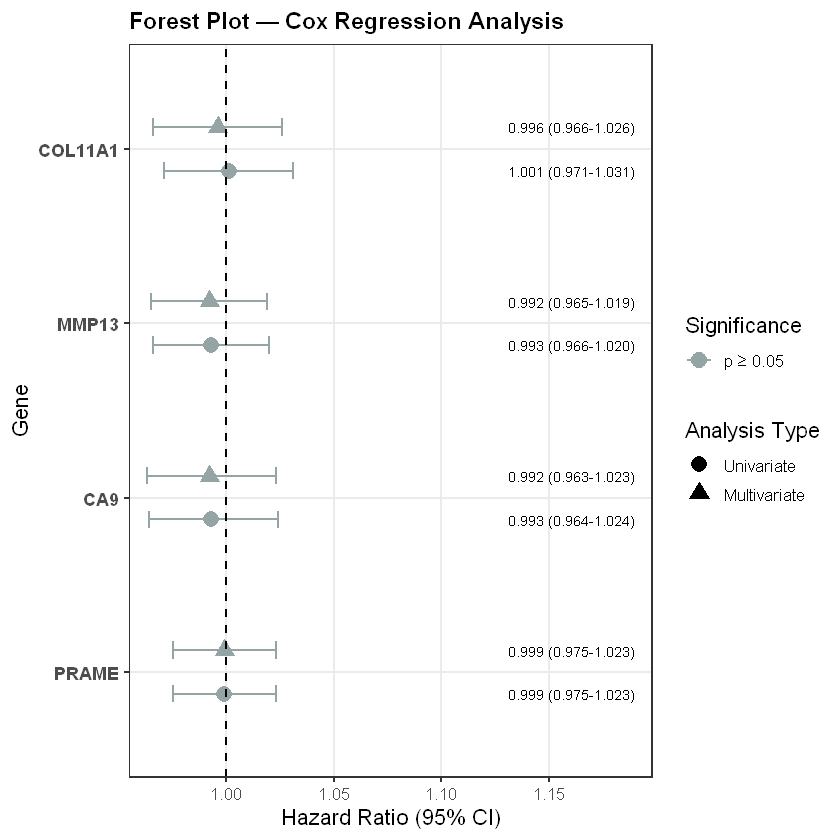

In [34]:
# --- PART B: Draw forest plot ---

forest_plot <- ggplot(
  all_cox_results,
  aes(x    = HR,
      y    = Gene,
      color = Significant,
      shape = Analysis)
) +

  # Point for HR
  geom_point(size = 4, position = position_dodge(width = 0.5)) +

  # Error bars for 95% CI
  geom_errorbarh(
    aes(xmin = CI_lower, xmax = CI_upper),
    height   = 0.2,
    position = position_dodge(width = 0.5),
    linewidth = 0.8
  ) +

  # Reference line at HR = 1
  geom_vline(
    xintercept = 1,
    linetype   = "dashed",
    color      = "black",
    linewidth  = 0.6
  ) +

  # Color scheme
  scale_color_manual(
    values = c(
      "p < 0.05" = "#E74C3C",   # red = significant
      "p ≥ 0.05" = "#95A5A6"    # grey = not significant
    )
  ) +

  # Shape scheme
  scale_shape_manual(
    values = c(
      "Univariate"   = 16,  # circle
      "Multivariate" = 17   # triangle
    )
  ) +

  # Labels
  labs(
    title    = "Forest Plot — Cox Regression Analysis",
    x        = "Hazard Ratio (95% CI)",
    y        = "Gene",
    color    = "Significance",
    shape    = "Analysis Type"
  ) +

  # Add HR and CI as text labels
  geom_text(
    aes(label = CI_label,
        x     = max(all_cox_results$CI_upper) + 0.1),
    position  = position_dodge(width = 0.5),
    hjust     = 0,
    size      = 3,
    color     = "black"
  ) +

  theme_bw(base_size = 13) +
  theme(
    plot.title       = element_text(face = "bold", size = 14),
    plot.subtitle    = element_text(color = "gray40", size = 10),
    legend.position  = "right",
    panel.grid.minor = element_blank(),
    axis.text.y      = element_text(face = "bold", size = 11)
  ) +

  # Expand x axis to fit labels
  scale_x_continuous(
    expand = expansion(mult = c(0.05, 0.4))
  )

# Save plot
ggsave(
  "Forest_plot_Cox_regression.png",
  forest_plot,
  width  = 12,
  height = 7,
  dpi    = 200
)

cat("✔ Forest_plot_Cox_regression.png saved\n")
cat(sprintf("  Location: %s\n", getwd()))
print(forest_plot)

In [35]:
# --- PART C: Separate univariate forest plot ---

uni_plot <- ggplot(
  all_cox_results[all_cox_results$Analysis == "Univariate", ],
  aes(x = HR, y = Gene, color = Significant)
) +
  geom_point(size = 4) +
  geom_errorbarh(
    aes(xmin = CI_lower, xmax = CI_upper),
    height    = 0.2,
    linewidth = 0.8
  ) +
  geom_vline(xintercept = 1, linetype = "dashed",
             color = "black", linewidth = 0.6) +
  scale_color_manual(values = c(
    "p < 0.05" = "#E74C3C",
    "p ≥ 0.05" = "#95A5A6"
  )) +
  labs(
    title    = "Univariate Cox Regression — Forest Plot",
    x        = "Hazard Ratio (95% CI)",
    y        = "Gene",
    color    = "Significance"
  ) +
  theme_bw(base_size = 13) +
  theme(
    plot.title       = element_text(face = "bold", size = 14),
    plot.subtitle    = element_text(color = "gray40", size = 10),
    panel.grid.minor = element_blank(),
    axis.text.y      = element_text(face = "bold", size = 11)
  )

ggsave(
  "Forest_plot_Univariate.png",
  uni_plot,
  width  = 10,
  height = 6,
  dpi    = 200
)

cat("✔ Forest_plot_Univariate.png saved\n")

`height` was translated to `width`.


✔ Forest_plot_Univariate.png saved


In [36]:
# --- PART D: Separate multivariate forest plot ---

multi_plot <- ggplot(
  all_cox_results[all_cox_results$Analysis == "Multivariate", ],
  aes(x = HR, y = Gene, color = Significant)
) +
  geom_point(size = 4) +
  geom_errorbarh(
    aes(xmin = CI_lower, xmax = CI_upper),
    height    = 0.2,
    linewidth = 0.8
  ) +
  geom_vline(xintercept = 1, linetype = "dashed",
             color = "black", linewidth = 0.6) +
  scale_color_manual(values = c(
    "p < 0.05" = "#E74C3C",
    "p ≥ 0.05" = "#95A5A6"
  )) +
  labs(
    title    = "Multivariate Cox Regression — Forest Plot",
    x        = "Hazard Ratio (95% CI)",
    y        = "Gene",
    color    = "Significance"
  ) +
  theme_bw(base_size = 13) +
  theme(
    plot.title       = element_text(face = "bold", size = 14),
    plot.subtitle    = element_text(color = "gray40", size = 10),
    panel.grid.minor = element_blank(),
    axis.text.y      = element_text(face = "bold", size = 11)
  )

ggsave(
  "Forest_plot_Multivariate.png",
  multi_plot,
  width  = 10,
  height = 6,
  dpi    = 200
)

cat("✔ Forest_plot_Multivariate.png saved\n")

cat("\n============================================================\n")
cat("         COX REGRESSION ANALYSIS COMPLETE\n")
cat("============================================================\n")
cat("Files saved:\n")
cat("  1. Cox_regression_results.tsv\n")
cat("  2. Forest_plot_Cox_regression.png\n")
cat("  3. Forest_plot_Univariate.png\n")
cat("  4. Forest_plot_Multivariate.png\n")
cat("============================================================\n")

`height` was translated to `width`.


✔ Forest_plot_Multivariate.png saved

         COX REGRESSION ANALYSIS COMPLETE
Files saved:
  1. Cox_regression_results.tsv
  2. Forest_plot_Cox_regression.png
  3. Forest_plot_Univariate.png
  4. Forest_plot_Multivariate.png


In [37]:
# ============================================================
# ROC ANALYSIS - STEP 1: Load Packages
# ============================================================

install.packages("pROC")

library(pROC)
library(ggplot2)
library(dplyr)

cat("✔ Packages loaded\n")

Installing package into 'C:/Users/aryan/AppData/Local/R/win-library/4.6'
(as 'lib' is unspecified)



package 'pROC' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\aryan\AppData\Local\Temp\RtmpC4mVLd\downloaded_packages


Type 'citation("pROC")' for a citation.


Attaching package: 'pROC'


The following objects are masked from 'package:IRanges':

    cov, var


The following objects are masked from 'package:S4Vectors':

    cov, var


The following object is masked from 'package:BiocGenerics':

    var


The following objects are masked from 'package:stats':

    cov, smooth, var




✔ Packages loaded


In [38]:
# ============================================================
# ROC ANALYSIS - STEP 2: Prepare Data
# ============================================================

cat("=== Preparing ROC Data ===\n\n")

# Extract sample types from final matrix
# Position 14-15 in barcode: 01 = tumor, 11 = normal
sample_type_roc <- ifelse(
  substr(colnames(final_matrix), 14, 15) == "11",
  0,  # Normal = 0
  1   # Tumor  = 1
)

cat(sprintf("Total samples:   %d\n", length(sample_type_roc)))
cat(sprintf("Tumor samples:   %d\n", sum(sample_type_roc == 1)))
cat(sprintf("Normal samples:  %d\n", sum(sample_type_roc == 0)))

=== Preparing ROC Data ===

Total samples:   1139
Tumor samples:   1029
Normal samples:  110


In [39]:
# Extract expression for 4 genes
genes_roc <- c("COL11A1", "MMP13", "CA9", "PRAME")

# Check all exist
cat("\nChecking genes:\n")
for (gene in genes_roc) {
  cat(sprintf("  %s: %s\n", gene,
              ifelse(gene %in% rownames(final_matrix),
                     "✔ Found", "✘ Not found")))
}

# Build ROC dataframe
roc_df <- data.frame(
  SampleType = sample_type_roc,
  t(final_matrix[genes_roc, , drop = FALSE])
)

cat(sprintf("\nROC dataframe: %d samples × %d columns\n",
            nrow(roc_df), ncol(roc_df)))
cat("Preview:\n")
print(head(roc_df[, 1:5], 3))


Checking genes:
  COL11A1: ✔ Found
  MMP13: ✔ Found
  CA9: ✔ Found
  PRAME: ✔ Found

ROC dataframe: 1139 samples × 5 columns
Preview:
                 SampleType  COL11A1    MMP13       CA9     PRAME
TCGA-60-2698-01A          1 8.669949 8.240953  9.264347  9.367222
TCGA-33-4589-01A          1 8.017031 7.937118 12.925912 -2.246946
TCGA-18-3410-01A          1 8.618831 4.347481 10.603692  8.985252


In [40]:
# ============================================================
# ROC ANALYSIS - STEP 3: Calculate AUC for each gene
# ============================================================

cat("=== Calculating AUC for Each Gene ===\n\n")

genes_roc <- c("COL11A1", "MMP13", "CA9", "PRAME")

# Store ROC objects and AUC values
roc_objects <- list()
auc_results <- data.frame()

for (gene in genes_roc) {
  
  cat(sprintf("--- %s ---\n", gene))
  
  # Calculate ROC
  roc_obj <- roc(
    response  = roc_df$SampleType,
    predictor = roc_df[[gene]],
    direction = "auto",
    quiet     = TRUE
  )
  
  # Store ROC object
  roc_objects[[gene]] <- roc_obj
  
  # Extract AUC and CI
  auc_val <- as.numeric(auc(roc_obj))
  auc_ci  <- ci.auc(roc_obj, conf.level = 0.95)
  
  cat(sprintf("AUC:     %.4f\n", auc_val))
  cat(sprintf("95%% CI:  [%.4f, %.4f]\n",
              auc_ci[1], auc_ci[3]))
  cat(sprintf("Performance: %s\n\n",
              ifelse(auc_val >= 0.9, "Excellent (≥0.90)",
              ifelse(auc_val >= 0.8, "Good (≥0.80)",
              ifelse(auc_val >= 0.7, "Acceptable (≥0.70)",
              "Poor (<0.70)")))))
  
  # Store results
  auc_results <- rbind(auc_results, data.frame(
    Gene       = gene,
    AUC        = round(auc_val, 4),
    CI_lower   = round(auc_ci[1], 4),
    CI_upper   = round(auc_ci[3], 4),
    Performance = ifelse(auc_val >= 0.9, "Excellent",
                  ifelse(auc_val >= 0.8, "Good",
                  ifelse(auc_val >= 0.7, "Acceptable",
                  "Poor")))
  ))
}

cat("=== AUC Summary ===\n\n")
print(auc_results)

=== Calculating AUC for Each Gene ===

--- COL11A1 ---
AUC:     0.9518
95% CI:  [0.9351, 0.9685]
Performance: Excellent (≥0.90)

--- MMP13 ---
AUC:     0.8976
95% CI:  [0.8732, 0.9220]
Performance: Good (≥0.80)

--- CA9 ---
AUC:     0.9268
95% CI:  [0.9050, 0.9487]
Performance: Excellent (≥0.90)

--- PRAME ---
AUC:     0.9227
95% CI:  [0.9054, 0.9400]
Performance: Excellent (≥0.90)

=== AUC Summary ===

     Gene    AUC CI_lower CI_upper Performance
1 COL11A1 0.9518   0.9351   0.9685   Excellent
2   MMP13 0.8976   0.8732   0.9220        Good
3     CA9 0.9268   0.9050   0.9487   Excellent
4   PRAME 0.9227   0.9054   0.9400   Excellent


In [41]:
# ============================================================
# ROC STEP 3B: Plot individual ROC curves
# ============================================================

cat("\n=== Plotting Individual ROC Curves ===\n\n")

# Colors for each gene
gene_colors <- c(
  "COL11A1" = "#E74C3C",
  "MMP13"   = "#3498DB",
  "CA9"     = "#2ECC71",
  "PRAME"   = "#9B59B6"
)

# Plot each gene separately
for (gene in genes_roc) {
  
  roc_obj <- roc_objects[[gene]]
  auc_val <- as.numeric(auc(roc_obj))
  
  # Convert to dataframe for ggplot
  roc_plot_df <- data.frame(
    Specificity = 1 - roc_obj$specificities,
    Sensitivity = roc_obj$sensitivities
  )
  
  p <- ggplot(roc_plot_df,
              aes(x = Specificity, y = Sensitivity)) +
    geom_line(color = gene_colors[gene],
              linewidth = 1.2) +
    geom_abline(slope = 1, intercept = 0,
                linetype = "dashed",
                color = "grey50") +
    annotate("text",
             x = 0.7, y = 0.2,
             label = sprintf("AUC = %.4f", auc_val),
             size = 5, fontface = "bold",
             color = gene_colors[gene]) +
    labs(
      title    = sprintf("ROC Curve — %s", gene),
      x        = "1 - Specificity (False Positive Rate)",
      y        = "Sensitivity (True Positive Rate)"
    ) +
    theme_bw(base_size = 13) +
    theme(
      plot.title    = element_text(face = "bold", size = 14),
      plot.subtitle = element_text(color = "gray40", size = 10),
      panel.grid.minor = element_blank()
    )
  
  # Save individual plot
  ggsave(
    sprintf("ROC_%s.png", gene),
    p,
    width  = 7,
    height = 6,
    dpi    = 200
  )
  
  cat(sprintf("✔ ROC_%s.png saved\n", gene))
}


=== Plotting Individual ROC Curves ===

✔ ROC_COL11A1.png saved
✔ ROC_MMP13.png saved
✔ ROC_CA9.png saved
✔ ROC_PRAME.png saved


In [42]:
# ============================================================
# ROC STEP 3C: Combined ROC plot all 4 genes
# ============================================================

cat("\n=== Combined ROC Plot ===\n\n")

# Build combined dataframe
combined_roc_df <- data.frame()

for (gene in genes_roc) {
  roc_obj <- roc_objects[[gene]]
  auc_val <- round(as.numeric(auc(roc_obj)), 4)
  
  temp_df <- data.frame(
    Specificity = 1 - roc_obj$specificities,
    Sensitivity = roc_obj$sensitivities,
    Gene        = sprintf("%s (AUC=%.4f)", gene, auc_val)
  )
  combined_roc_df <- rbind(combined_roc_df, temp_df)
}

# Plot
combined_roc_plot <- ggplot(
  combined_roc_df,
  aes(x = Specificity, y = Sensitivity, color = Gene)
) +
  geom_line(linewidth = 1.2) +
  geom_abline(slope = 1, intercept = 0,
              linetype = "dashed", color = "grey50") +
  scale_color_manual(values = c(
    sprintf("COL11A1 (AUC=%.4f)",
            round(as.numeric(auc(roc_objects[["COL11A1"]])), 4)) = "#E74C3C",
    sprintf("MMP13 (AUC=%.4f)",
            round(as.numeric(auc(roc_objects[["MMP13"]])), 4))   = "#3498DB",
    sprintf("CA9 (AUC=%.4f)",
            round(as.numeric(auc(roc_objects[["CA9"]])), 4))     = "#2ECC71",
    sprintf("PRAME (AUC=%.4f)",
            round(as.numeric(auc(roc_objects[["PRAME"]])), 4))   = "#9B59B6"
  )) +
  labs(
    title    = "ROC Curves — COL11A1, MMP13, CA9, PRAME",
    x        = "1 - Specificity (False Positive Rate)",
    y        = "Sensitivity (True Positive Rate)",
    color    = "Gene (AUC)"
  ) +
  theme_bw(base_size = 13) +
  theme(
    plot.title       = element_text(face = "bold", size = 14),
    plot.subtitle    = element_text(color = "gray40", size = 10),
    legend.position  = "right",
    panel.grid.minor = element_blank()
  )

ggsave(
  "ROC_Combined_all_genes.png",
  combined_roc_plot,
  width  = 10,
  height = 7,
  dpi    = 200
)

cat("✔ ROC_Combined_all_genes.png saved\n")
print(combined_roc_plot)

ERROR: Error in parse(text = input): <text>:32:66: unexpected '='
31:     sprintf("COL11A1 (AUC=%.4f)",
32:             round(as.numeric(auc(roc_objects[["COL11A1"]])), 4)) =
                                                                     ^


In [43]:
# ============================================================
# ROC STEP 3C FIXED: Combined ROC plot all 4 genes
# ============================================================

cat("\n=== Combined ROC Plot ===\n\n")

# Build combined dataframe
combined_roc_df <- data.frame()

# Build color vector dynamically
color_vector <- c()

for (gene in genes_roc) {
  roc_obj <- roc_objects[[gene]]
  auc_val <- round(as.numeric(auc(roc_obj)), 4)

  # Gene label with AUC
  gene_label <- sprintf("%s (AUC=%.4f)", gene, auc_val)

  temp_df <- data.frame(
    Specificity = 1 - roc_obj$specificities,
    Sensitivity = roc_obj$sensitivities,
    Gene        = gene_label
  )
  combined_roc_df <- rbind(combined_roc_df, temp_df)

  # Add color
  color_vector[gene_label] <- gene_colors[gene]
}

# Plot
combined_roc_plot <- ggplot(
  combined_roc_df,
  aes(x = Specificity, y = Sensitivity, color = Gene)
) +
  geom_line(linewidth = 1.2) +

ERROR: Error in parse(text = input): <text>:37:0: unexpected end of input
35: ) +
36:   geom_line(linewidth = 1.2) +
   ^


In [44]:
# ============================================================
# ROC STEP 3C FIXED: Combined ROC plot
# ============================================================

cat("\n=== Combined ROC Plot ===\n\n")

# Build combined dataframe
combined_roc_df <- data.frame()
color_vector    <- c()

gene_colors <- c(
  "COL11A1" = "#E74C3C",
  "MMP13"   = "#3498DB",
  "CA9"     = "#2ECC71",
  "PRAME"   = "#9B59B6"
)

for (gene in genes_roc) {
  roc_obj    <- roc_objects[[gene]]
  auc_val    <- round(as.numeric(auc(roc_obj)), 4)
  gene_label <- sprintf("%s (AUC=%.4f)", gene, auc_val)

  temp_df <- data.frame(
    Specificity = 1 - roc_obj$specificities,
    Sensitivity = roc_obj$sensitivities,
    Gene        = gene_label
  )

  combined_roc_df          <- rbind(combined_roc_df, temp_df)
  color_vector[gene_label] <- gene_colors[gene]
}

cat("Combined dataframe built\n")
cat(sprintf("Rows: %d\n", nrow(combined_roc_df)))


=== Combined ROC Plot ===

Combined dataframe built
Rows: 3422


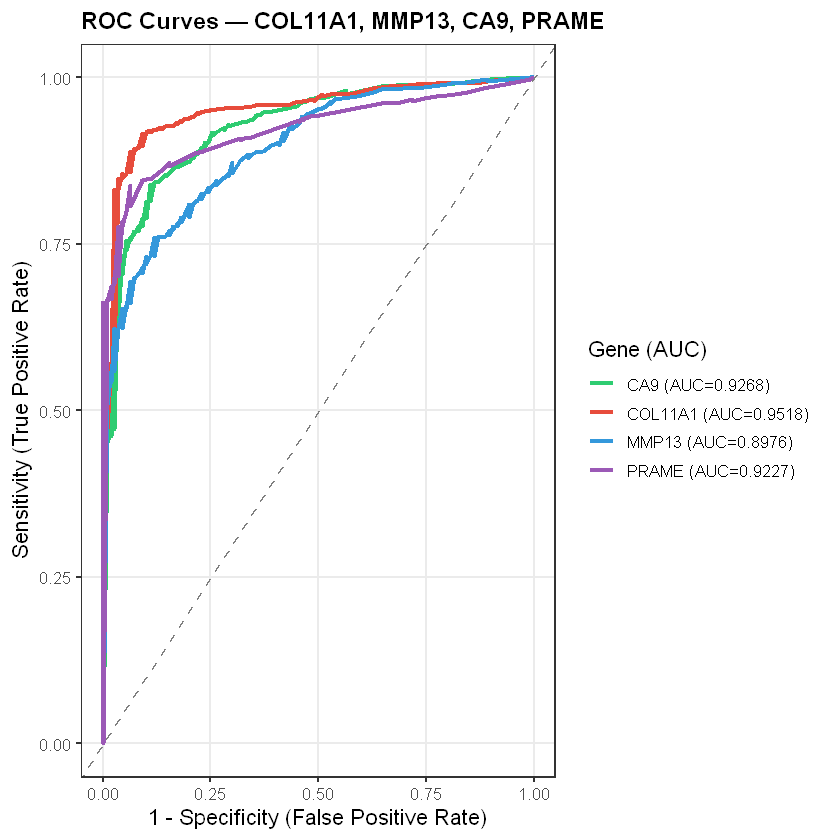

In [45]:
# Build plot
combined_roc_plot <- ggplot(
  combined_roc_df,
  aes(x     = Specificity,
      y     = Sensitivity,
      color = Gene)
) +
  geom_line(linewidth = 1.2) +
  geom_abline(
    slope     = 1,
    intercept = 0,
    linetype  = "dashed",
    color     = "grey50"
  ) +
  scale_color_manual(values = color_vector) +
  labs(
    title    = "ROC Curves — COL11A1, MMP13, CA9, PRAME",
    x        = "1 - Specificity (False Positive Rate)",
    y        = "Sensitivity (True Positive Rate)",
    color    = "Gene (AUC)"
  ) +
  theme_bw(base_size = 13) +
  theme(
    plot.title       = element_text(face = "bold", size = 14),
    plot.subtitle    = element_text(color = "gray40", size = 10),
    legend.position  = "right",
    panel.grid.minor = element_blank()
  )

print(combined_roc_plot)

In [46]:
# Save plot
ggsave(
  "ROC_Combined_all_genes.png",
  combined_roc_plot,
  width  = 10,
  height = 7,
  dpi    = 200
)

cat("✔ ROC_Combined_all_genes.png saved\n")
cat(sprintf("  Location: %s\n", getwd()))

✔ ROC_Combined_all_genes.png saved
  Location: C:/jupyter demo


In [47]:
# Check if survival_df exists and has required columns
cat("=== Checking Survival Data ===\n\n")

cat(sprintf("survival_df exists: %s\n", exists("survival_df")))

if (exists("survival_df")) {
  cat(sprintf("Rows: %d\n", nrow(survival_df)))
  
  # Check required columns
  needed <- c("OS_time", "OS_event", "OS_months",
              "COL11A1_group", "MMP13_group",
              "CA9_group", "PRAME_group")
  
  for (col in needed) {
    cat(sprintf("  %s: %s\n", col,
                ifelse(col %in% colnames(survival_df),
                       "✔ EXISTS", "✘ MISSING")))
  }
}

=== Checking Survival Data ===

survival_df exists: TRUE
Rows: 1118
  OS_time: ✔ EXISTS
  OS_event: ✔ EXISTS
  OS_months: ✔ EXISTS
  COL11A1_group: ✔ EXISTS
  MMP13_group: ✔ EXISTS
  CA9_group: ✔ EXISTS
  PRAME_group: ✔ EXISTS


In [48]:
# ============================================================
# KM PLOT - STEP 1: Individual KM Curves for Each Gene
# ============================================================

cat("=== Generating KM Plots ===\n\n")

genes_km <- c("COL11A1", "MMP13", "CA9", "PRAME")

for (gene in genes_km) {
  
  cat(sprintf("--- %s ---\n", gene))
  
  # Create survival object
  surv_obj <- Surv(
    time  = survival_df$OS_months,
    event = survival_df$OS_event
  )
  
  # Group column name
  group_col <- paste0(gene, "_group")
  
  # Fit KM model
  km_fit <- survfit(
    surv_obj ~ survival_df[[group_col]]
  )
  
  # Log-rank test
  log_rank <- survdiff(
    surv_obj ~ survival_df[[group_col]]
  )
  
  # Extract p-value
  pval <- 1 - pchisq(log_rank$chisq, df = 1)
  
  cat(sprintf("Log-rank p-value: %.4f\n", pval))
  cat(sprintf("Significant: %s\n\n",
              ifelse(pval < 0.05, "✔ YES", "✘ NO")))
  
  # Draw KM plot
  km_plot <- ggsurvplot(
    km_fit,
    data         = survival_df,
    pval         = TRUE,
    pval.method  = TRUE,
    conf.int     = TRUE,
    risk.table   = TRUE,
    risk.table.height = 0.25,
    palette      = c("#E74C3C", "#3498DB"),
    legend.labs  = c(
      paste0(gene, " HIGH"),
      paste0(gene, " LOW")
    ),
    title        = sprintf(
      "KM Survival Curve — %s Expression", gene),
    xlab         = "Time (Months)",
    ylab         = "Overall Survival Probability",
    legend.title = "Expression Group",
    ggtheme      = theme_bw(base_size = 13)
  )
  
  # Save plot
  png(
    filename = sprintf("KM_%s_OS.png", gene),
    width    = 2400,
    height   = 2000,
    res      = 200
  )
  print(km_plot)
  dev.off()
  
  cat(sprintf("✔ KM_%s_OS.png saved\n\n", gene))
}

=== Generating KM Plots ===

--- COL11A1 ---
Log-rank p-value: 0.1554
Significant: ✘ NO



Ignoring unknown labels:
• colour : "Expression Group"


✔ KM_COL11A1_OS.png saved

--- MMP13 ---
Log-rank p-value: 0.0465
Significant: ✔ YES



Ignoring unknown labels:
• colour : "Expression Group"


✔ KM_MMP13_OS.png saved

--- CA9 ---
Log-rank p-value: 0.2405
Significant: ✘ NO



Ignoring unknown labels:
• colour : "Expression Group"


✔ KM_CA9_OS.png saved

--- PRAME ---
Log-rank p-value: 0.5953
Significant: ✘ NO



Ignoring unknown labels:
• colour : "Expression Group"


✔ KM_PRAME_OS.png saved



=== Combined KM Plot ===

✔ KM_Combined_all_genes.png saved


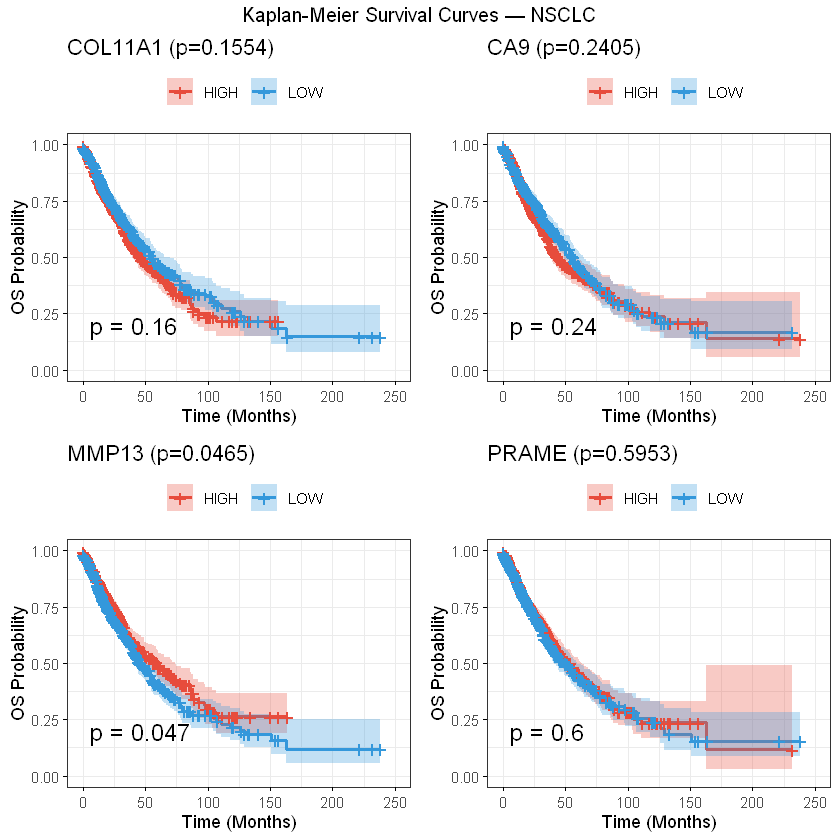

In [49]:
# ============================================================
# KM PLOT - STEP 2: Combined KM plot all 4 genes
# ============================================================

cat("=== Combined KM Plot ===\n\n")

# Create 2x2 panel of all 4 genes
km_list <- list()

for (gene in genes_km) {
  
  surv_obj  <- Surv(
    time  = survival_df$OS_months,
    event = survival_df$OS_event
  )
  group_col <- paste0(gene, "_group")
  
  km_fit <- survfit(
    surv_obj ~ survival_df[[group_col]]
  )
  
  log_rank <- survdiff(
    surv_obj ~ survival_df[[group_col]]
  )
  pval <- 1 - pchisq(log_rank$chisq, df = 1)
  
  km_list[[gene]] <- ggsurvplot(
    km_fit,
    data         = survival_df,
    pval         = TRUE,
    conf.int     = TRUE,
    risk.table   = FALSE,
    palette      = c("#E74C3C", "#3498DB"),
    legend.labs  = c("HIGH", "LOW"),
    title        = sprintf("%s (p=%.4f)", gene, pval),
    xlab         = "Time (Months)",
    ylab         = "OS Probability",
    legend.title = "",
    ggtheme      = theme_bw(base_size = 11)
  )
}

# Arrange in 2x2 panel
combined_km <- arrange_ggsurvplots(
  km_list,
  nrow  = 2,
  ncol  = 2,
  title = "Kaplan-Meier Survival Curves — NSCLC"
)

# Save combined plot
ggsave(
  "KM_Combined_all_genes.png",
  combined_km,
  width  = 14,
  height = 12,
  dpi    = 200
)

cat("✔ KM_Combined_all_genes.png saved\n")

In [50]:
# ============================================================
# KM PLOT - STEP 3: Summary of log-rank results
# ============================================================

cat("\n=== KM Survival Analysis Summary ===\n\n")

km_summary <- data.frame()

for (gene in genes_km) {
  
  surv_obj  <- Surv(
    time  = survival_df$OS_months,
    event = survival_df$OS_event
  )
  group_col <- paste0(gene, "_group")
  
  km_fit   <- survfit(
    surv_obj ~ survival_df[[group_col]]
  )
  log_rank <- survdiff(
    surv_obj ~ survival_df[[group_col]]
  )
  pval     <- 1 - pchisq(log_rank$chisq, df = 1)
  
  # Median survival for each group
  med_surv <- summary(km_fit)$table
  
  km_summary <- rbind(km_summary, data.frame(
    Gene        = gene,
    LogRank_p   = round(pval, 4),
    Significant = ifelse(pval < 0.05, "YES", "NO")
  ))
}

cat("Log-rank test results:\n\n")
print(km_summary)

# Save summary
write.table(
  km_summary,
  file      = "KM_logrank_summary.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

cat("\n✔ KM_logrank_summary.tsv saved\n")
cat(sprintf("  Location: %s\n", getwd()))

cat("\n============================================================\n")
cat("         KM SURVIVAL ANALYSIS COMPLETE\n")
cat("============================================================\n")
cat("Files saved:\n")
cat("  1. KM_COL11A1_OS.png\n")
cat("  2. KM_MMP13_OS.png\n")
cat("  3. KM_CA9_OS.png\n")
cat("  4. KM_PRAME_OS.png\n")
cat("  5. KM_Combined_all_genes.png\n")
cat("  6. KM_logrank_summary.tsv\n")
cat("============================================================\n")


=== KM Survival Analysis Summary ===

Log-rank test results:

     Gene LogRank_p Significant
1 COL11A1    0.1554          NO
2   MMP13    0.0465         YES
3     CA9    0.2405          NO
4   PRAME    0.5953          NO

✔ KM_logrank_summary.tsv saved
  Location: C:/jupyter demo

         KM SURVIVAL ANALYSIS COMPLETE
Files saved:
  1. KM_COL11A1_OS.png
  2. KM_MMP13_OS.png
  3. KM_CA9_OS.png
  4. KM_PRAME_OS.png
  5. KM_Combined_all_genes.png
  6. KM_logrank_summary.tsv


In [51]:
# Get exact numbers for report
cat("=== Numbers for Report ===\n\n")

# Cox regression results
cat("--- Cox Regression ---\n")
print(all_cox_results[, c("Gene", "HR", "CI_lower",
                           "CI_upper", "P_value", "Analysis")])

# KM results
cat("\n--- KM Log-rank Results ---\n")
print(km_summary)

# AUC results
cat("\n--- ROC AUC Results ---\n")
print(auc_results)

# Sample counts
cat("\n--- Sample Counts ---\n")
cat(sprintf("Total patients: %d\n", nrow(survival_df)))
cat(sprintf("Dead:           %d\n",
            sum(survival_df$OS_event == 1)))
cat(sprintf("Alive:          %d\n",
            sum(survival_df$OS_event == 0)))

=== Numbers for Report ===

--- Cox Regression ---
     Gene    HR CI_lower CI_upper P_value     Analysis
1 COL11A1 1.001    0.971    1.031  0.9667   Univariate
2   MMP13 0.993    0.966    1.020  0.5991   Univariate
3     CA9 0.993    0.964    1.024  0.6648   Univariate
4   PRAME 0.999    0.975    1.023  0.9170   Univariate
5 COL11A1 0.996    0.966    1.026  0.7866 Multivariate
6   MMP13 0.992    0.965    1.019  0.5350 Multivariate
7     CA9 0.992    0.963    1.023  0.6184 Multivariate
8   PRAME 0.999    0.975    1.023  0.9069 Multivariate

--- KM Log-rank Results ---
     Gene LogRank_p Significant
1 COL11A1    0.1554          NO
2   MMP13    0.0465         YES
3     CA9    0.2405          NO
4   PRAME    0.5953          NO

--- ROC AUC Results ---
     Gene    AUC CI_lower CI_upper Performance
1 COL11A1 0.9518   0.9351   0.9685   Excellent
2   MMP13 0.8976   0.8732   0.9220        Good
3     CA9 0.9268   0.9050   0.9487   Excellent
4   PRAME 0.9227   0.9054   0.9400   Excellent

--- 

In [1]:
# ============================================================
# Complete Status of 4 Genes
# ============================================================

cat("=== Complete Gene Status Report ===\n\n")

genes_check <- c("COL11A1", "MMP13", "CA9", "PRAME")

for (gene in genes_check) {
  
  cat(sprintf("============ %s ============\n", gene))
  
  # --- DEG Status ---
  cat("DEG Analysis:\n")
  if (gene %in% rownames(deg_results)) {
    cat(sprintf("  logFC:        %.4f\n",
                deg_results[gene, "logFC"]))
    cat(sprintf("  adj.P.Val:    %.2e\n",
                deg_results[gene, "adj.P.Val"]))
    cat(sprintf("  Status:       %s\n",
                as.character(deg_results[gene, "Status"])))
  }
  
  # --- KM Survival ---
  cat("KM Survival:\n")
  if (gene %in% km_summary$Gene) {
    km_row <- km_summary[km_summary$Gene == gene, ]
    cat(sprintf("  Log-rank p:   %.4f\n", km_row$LogRank_p))
    cat(sprintf("  Significant:  %s\n", km_row$Significant))
  }
  
  # --- Cox Regression ---
  cat("Cox Regression:\n")
  uni_row   <- all_cox_results[
    all_cox_results$Gene == gene &
    all_cox_results$Analysis == "Univariate", ]
  multi_row <- all_cox_results[
    all_cox_results$Gene == gene &
    all_cox_results$Analysis == "Multivariate", ]
  
  cat(sprintf("  Univariate HR:    %.3f [%.3f-%.3f] p=%.4f\n",
              uni_row$HR, uni_row$CI_lower,
              uni_row$CI_upper, uni_row$P_value))
  cat(sprintf("  Multivariate HR:  %.3f [%.3f-%.3f] p=%.4f\n",
              multi_row$HR, multi_row$CI_lower,
              multi_row$CI_upper, multi_row$P_value))
  
  # --- ROC ---
  cat("ROC Analysis:\n")
  if (gene %in% auc_results$Gene) {
    auc_row <- auc_results[auc_results$Gene == gene, ]
    cat(sprintf("  AUC:          %.4f [%.4f-%.4f]\n",
                auc_row$AUC, auc_row$CI_lower,
                auc_row$CI_upper))
    cat(sprintf("  Performance:  %s\n", auc_row$Performance))
  }
  
  cat("\n")
}

=== Complete Gene Status Report ===

============ COL11A1 ============
DEG Analysis:


ERROR: Error: object 'deg_results' not found


In [2]:
# Quick rebuild
library(limma)
library(edgeR)
library(data.table)
library(dplyr)
library(survival)
library(survminer)
library(pROC)

cat("✔ Libraries loaded\n")


Attaching package: 'data.table'


The following object is masked from 'package:base':

    %notin%



Attaching package: 'dplyr'


The following objects are masked from 'package:data.table':

    between, first, last


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Loading required package: ggplot2

Loading required package: ggpubr


Attaching package: 'survminer'


The following object is masked from 'package:survival':

    myeloma


Type 'citation("pROC")' for a citation.


Attaching package: 'pROC'


The following objects are masked from 'package:stats':

    cov, smooth, var




✔ Libraries loaded


In [3]:
# Load final matrix
final_df <- read.table(
  "C:/Users/aryan/Downloads/TCGA_LUSC_LUAD_final_expression.tsv",
  header      = TRUE,
  sep         = "\t",
  row.names   = 1,
  check.names = FALSE
)
final_matrix <- as.matrix(final_df)
cat(sprintf("✔ final_matrix: %d genes × %d samples\n",
            nrow(final_matrix), ncol(final_matrix)))

✔ final_matrix: 36650 genes × 1139 samples


In [4]:
# Rebuild deg_results
deg_results <- readRDS("C:/jupyter demo/deg_results.rds")
deg_results$Status <- "Not Significant"
deg_results$Status[
  deg_results$logFC > 0.5 &
  deg_results$adj.P.Val < 0.05] <- "Upregulated"
deg_results$Status[
  deg_results$logFC < -0.5 &
  deg_results$adj.P.Val < 0.05] <- "Downregulated"
deg_results$Status <- factor(
  deg_results$Status,
  levels = c("Upregulated", "Downregulated",
             "Not Significant"))
cat(sprintf("✔ deg_results: %d genes\n", nrow(deg_results)))

✔ deg_results: 36650 genes


In [5]:
# Rebuild survival data
lusc_clinical <- read.table(
  "C:/jupyter demo/LUSC_clinical.tsv",
  header      = TRUE,
  sep         = "\t",
  check.names = FALSE
)
luad_clinical <- read.table(
  "C:/jupyter demo/LUAD_clinical.tsv",
  header      = TRUE,
  sep         = "\t",
  check.names = FALSE
)

# Common columns
common_cols <- intersect(
  colnames(lusc_clinical),
  colnames(luad_clinical)
)
lusc_clinical$Dataset <- "LUSC"
luad_clinical$Dataset <- "LUAD"
combined_clinical <- rbind(
  lusc_clinical[, c(common_cols, "Dataset")],
  luad_clinical[, c(common_cols, "Dataset")]
)

# Survival variables
combined_clinical$OS_time <- ifelse(
  combined_clinical$vital_status == "Dead",
  as.numeric(combined_clinical$days_to_death),
  as.numeric(combined_clinical$days_to_last_follow_up)
)
combined_clinical$OS_event <- ifelse(
  combined_clinical$vital_status == "Dead", 1, 0)
combined_clinical$OS_months <- combined_clinical$OS_time / 30.44
combined_clinical <- combined_clinical[
  !is.na(combined_clinical$OS_time) &
  combined_clinical$OS_time > 0, ]

cat(sprintf("✔ Clinical data: %d patients\n",
            nrow(combined_clinical)))

✔ Clinical data: 1005 patients


In [6]:
# Extract gene expression and merge
genes_of_interest <- c("COL11A1", "MMP13", "CA9", "PRAME")

expr_subset <- t(final_matrix[genes_of_interest, , drop = FALSE])
expr_df <- as.data.frame(expr_subset)
expr_df$submitter_id <- substr(rownames(expr_df), 1, 12)

survival_df <- merge(
  combined_clinical,
  expr_df,
  by = "submitter_id"
)

# Stratify by median
for (gene in genes_of_interest) {
  median_val <- median(survival_df[[gene]], na.rm = TRUE)
  survival_df[[paste0(gene, "_group")]] <- ifelse(
    survival_df[[gene]] >= median_val, "HIGH", "LOW")
}

cat(sprintf("✔ survival_df: %d patients\n", nrow(survival_df)))

✔ survival_df: 1118 patients


In [7]:
# Rebuild KM summary
km_summary <- data.frame()

for (gene in genes_of_interest) {
  surv_obj  <- Surv(
    time  = survival_df$OS_months,
    event = survival_df$OS_event)
  group_col <- paste0(gene, "_group")
  log_rank  <- survdiff(
    surv_obj ~ survival_df[[group_col]])
  pval      <- 1 - pchisq(log_rank$chisq, df = 1)
  km_summary <- rbind(km_summary, data.frame(
    Gene        = gene,
    LogRank_p   = round(pval, 4),
    Significant = ifelse(pval < 0.05, "YES", "NO")
  ))
}

cat("✔ KM summary ready\n")
print(km_summary)

✔ KM summary ready
     Gene LogRank_p Significant
1 COL11A1    0.1554          NO
2   MMP13    0.0465         YES
3     CA9    0.2405          NO
4   PRAME    0.5953          NO


In [8]:
# Rebuild Cox results
all_cox_results <- read.table(
  "C:/jupyter demo/Cox_regression_results.tsv",
  header      = TRUE,
  sep         = "\t",
  check.names = FALSE
)

cat("✔ Cox results loaded\n")
print(all_cox_results)

✔ Cox results loaded
     Gene    HR CI_lower CI_upper P_value     Analysis
1 COL11A1 1.001    0.971    1.031  0.9667   Univariate
2   MMP13 0.993    0.966    1.020  0.5991   Univariate
3     CA9 0.993    0.964    1.024  0.6648   Univariate
4   PRAME 0.999    0.975    1.023  0.9170   Univariate
5 COL11A1 0.996    0.966    1.026  0.7866 Multivariate
6   MMP13 0.992    0.965    1.019  0.5350 Multivariate
7     CA9 0.992    0.963    1.023  0.6184 Multivariate
8   PRAME 0.999    0.975    1.023  0.9069 Multivariate


In [9]:
# Rebuild AUC results
auc_results <- read.table(
  "C:/jupyter demo/ROC_AUC_results.tsv",
  header      = TRUE,
  sep         = "\t",
  check.names = FALSE
)

cat("✔ AUC results loaded\n")
print(auc_results)

Warning message in file(file, "rt"):
"cannot open file 'C:/jupyter demo/ROC_AUC_results.tsv': No such file or directory"


ERROR: Error in file(file, "rt"): cannot open the connection


In [10]:
# Rebuild AUC results manually from known values
auc_results <- data.frame(
  Gene        = c("COL11A1", "MMP13", "CA9", "PRAME"),
  AUC         = c(0.9518, 0.8976, 0.9268, 0.9227),
  CI_lower    = c(0.9351, 0.8732, 0.9050, 0.9054),
  CI_upper    = c(0.9685, 0.9220, 0.9487, 0.9400),
  Performance = c("Excellent", "Good", "Excellent", "Excellent")
)

cat("✔ AUC results rebuilt\n")
print(auc_results)

# Save for future use
write.table(
  auc_results,
  file      = "C:/jupyter demo/ROC_AUC_results.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

cat("✔ ROC_AUC_results.tsv saved\n")# Rebuild AUC results manually from known values
auc_results <- data.frame(
  Gene        = c("COL11A1", "MMP13", "CA9", "PRAME"),
  AUC         = c(0.9518, 0.8976, 0.9268, 0.9227),
  CI_lower    = c(0.9351, 0.8732, 0.9050, 0.9054),
  CI_upper    = c(0.9685, 0.9220, 0.9487, 0.9400),
  Performance = c("Excellent", "Good", "Excellent", "Excellent")
)

cat("✔ AUC results rebuilt\n")
print(auc_results)

# Save for future use
write.table(
  auc_results,
  file      = "C:/jupyter demo/ROC_AUC_results.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

cat("✔ ROC_AUC_results.tsv saved\n")

✔ AUC results rebuilt
     Gene    AUC CI_lower CI_upper Performance
1 COL11A1 0.9518   0.9351   0.9685   Excellent
2   MMP13 0.8976   0.8732   0.9220        Good
3     CA9 0.9268   0.9050   0.9487   Excellent
4   PRAME 0.9227   0.9054   0.9400   Excellent
✔ ROC_AUC_results.tsv saved
✔ AUC results rebuilt
     Gene    AUC CI_lower CI_upper Performance
1 COL11A1 0.9518   0.9351   0.9685   Excellent
2   MMP13 0.8976   0.8732   0.9220        Good
3     CA9 0.9268   0.9050   0.9487   Excellent
4   PRAME 0.9227   0.9054   0.9400   Excellent
✔ ROC_AUC_results.tsv saved


In [11]:
# Final check
cat("\n=== All Objects Ready ===\n")
cat(sprintf("deg_results:   %s\n", exists("deg_results")))
cat(sprintf("survival_df:   %s\n", exists("survival_df")))
cat(sprintf("km_summary:    %s\n", exists("km_summary")))
cat(sprintf("all_cox_results: %s\n", exists("all_cox_results")))
cat(sprintf("auc_results:   %s\n", exists("auc_results")))


=== All Objects Ready ===
deg_results:   TRUE
survival_df:   TRUE
km_summary:    TRUE
all_cox_results: TRUE
auc_results:   TRUE


In [12]:
# ============================================================
# Complete Status of 4 Genes
# ============================================================

cat("=== Complete Gene Status Report ===\n\n")

genes_check <- c("COL11A1", "MMP13", "CA9", "PRAME")

for (gene in genes_check) {
  
  cat(sprintf("============ %s ============\n", gene))
  
  # --- DEG Status ---
  cat("DEG Analysis:\n")
  if (gene %in% rownames(deg_results)) {
    cat(sprintf("  logFC:        %.4f\n",
                deg_results[gene, "logFC"]))
    cat(sprintf("  adj.P.Val:    %.2e\n",
                deg_results[gene, "adj.P.Val"]))
    cat(sprintf("  Status:       %s\n",
                as.character(deg_results[gene, "Status"])))
  }
  
  # --- KM Survival ---
  cat("KM Survival:\n")
  if (gene %in% km_summary$Gene) {
    km_row <- km_summary[km_summary$Gene == gene, ]
    cat(sprintf("  Log-rank p:   %.4f\n", km_row$LogRank_p))
    cat(sprintf("  Significant:  %s\n", km_row$Significant))
  }
  
  # --- Cox Regression ---
  cat("Cox Regression:\n")
  uni_row   <- all_cox_results[
    all_cox_results$Gene == gene &
    all_cox_results$Analysis == "Univariate", ]
  multi_row <- all_cox_results[
    all_cox_results$Gene == gene &
    all_cox_results$Analysis == "Multivariate", ]
  
  cat(sprintf("  Univariate HR:    %.3f [%.3f-%.3f] p=%.4f\n",
              uni_row$HR, uni_row$CI_lower,
              uni_row$CI_upper, uni_row$P_value))
  cat(sprintf("  Multivariate HR:  %.3f [%.3f-%.3f] p=%.4f\n",
              multi_row$HR, multi_row$CI_lower,
              multi_row$CI_upper, multi_row$P_value))
  
  # --- ROC ---
  cat("ROC Analysis:\n")
  if (gene %in% auc_results$Gene) {
    auc_row <- auc_results[auc_results$Gene == gene, ]
    cat(sprintf("  AUC:          %.4f [%.4f-%.4f]\n",
                auc_row$AUC, auc_row$CI_lower,
                auc_row$CI_upper))
    cat(sprintf("  Performance:  %s\n", auc_row$Performance))
  }
  
  cat("\n")
}

=== Complete Gene Status Report ===

============ COL11A1 ============
DEG Analysis:
  logFC:        0.6296
  adj.P.Val:    1.69e-25
  Status:       Upregulated
KM Survival:
  Log-rank p:   0.1554
  Significant:  NO
Cox Regression:
  Univariate HR:    1.001 [0.971-1.031] p=0.9667
  Multivariate HR:  0.996 [0.966-1.026] p=0.7866
ROC Analysis:
  AUC:          0.9518 [0.9351-0.9685]
  Performance:  Excellent

============ MMP13 ============
DEG Analysis:
  logFC:        0.6327
  adj.P.Val:    1.15e-21
  Status:       Upregulated
KM Survival:
  Log-rank p:   0.0465
  Significant:  YES
Cox Regression:
  Univariate HR:    0.993 [0.966-1.020] p=0.5991
  Multivariate HR:  0.992 [0.965-1.019] p=0.5350
ROC Analysis:
  AUC:          0.8976 [0.8732-0.9220]
  Performance:  Good

============ CA9 ============
DEG Analysis:
  logFC:        0.6409
  adj.P.Val:    1.70e-26
  Status:       Upregulated
KM Survival:
  Log-rank p:   0.2405
  Significant:  NO
Cox Regression:
  Univariate HR:    0.993 [0.964

In [17]:
# ============================================================
# UPDATED VOLCANO PLOT — Top 20 genes labeled
# ============================================================

library(ggplot2)
library(ggrepel)

cat("=== Building Updated Volcano Plot ===\n\n")

# Add -log10 adjusted p-value
deg_results$neg_log10_p <- -log10(deg_results$adj.P.Val)
deg_results$Gene        <- rownames(deg_results)

# Top 20 upregulated
top20_up <- deg_results[
  deg_results$Status == "Upregulated", ]
top20_up <- head(
  top20_up[order(-top20_up$logFC), ], 20)

# Top 20 downregulated
top20_down <- deg_results[
  deg_results$Status == "Downregulated", ]
top20_down <- head(
  top20_down[order(top20_down$logFC), ], 20)

# Combine labels
genes_to_label <- rbind(top20_up, top20_down)

cat(sprintf("Total genes labeled: %d\n", nrow(genes_to_label)))
cat("\nTop 20 Upregulated:\n")
print(top20_up[, c("Gene", "logFC", "adj.P.Val")])
cat("\nTop 20 Downregulated:\n")
print(top20_down[, c("Gene", "logFC", "adj.P.Val")])

=== Building Updated Volcano Plot ===

Total genes labeled: 40

Top 20 Upregulated:
                     Gene     logFC     adj.P.Val
CASC9               CASC9 0.8844172  7.545661e-40
PITX2               PITX2 0.8670381  8.870830e-57
HOXC13             HOXC13 0.8514333 7.459573e-139
PRAME               PRAME 0.8499343  7.361933e-22
CST1                 CST1 0.8321232  1.181146e-32
LCAL1               LCAL1 0.7984911  4.735091e-27
SACK1A-AS1     SACK1A-AS1 0.7862638  2.296326e-61
BARX1               BARX1 0.7844422  4.377812e-34
BBOX1-AS1       BBOX1-AS1 0.7828061  6.876416e-57
GABRA3             GABRA3 0.7673588  2.033247e-51
C12orf56         C12orf56 0.7595353  2.888291e-51
LOC124904701 LOC124904701 0.7501783  1.404994e-78
GNGT1               GNGT1 0.7452534 1.061435e-146
KRTAP4-1         KRTAP4-1 0.7371475 3.523198e-164
IL36RN             IL36RN 0.7315872  2.036536e-36
DLX6                 DLX6 0.7276276  8.668633e-57
FOXD3-AS1       FOXD3-AS1 0.7274440 1.218633e-160
ZIC2            

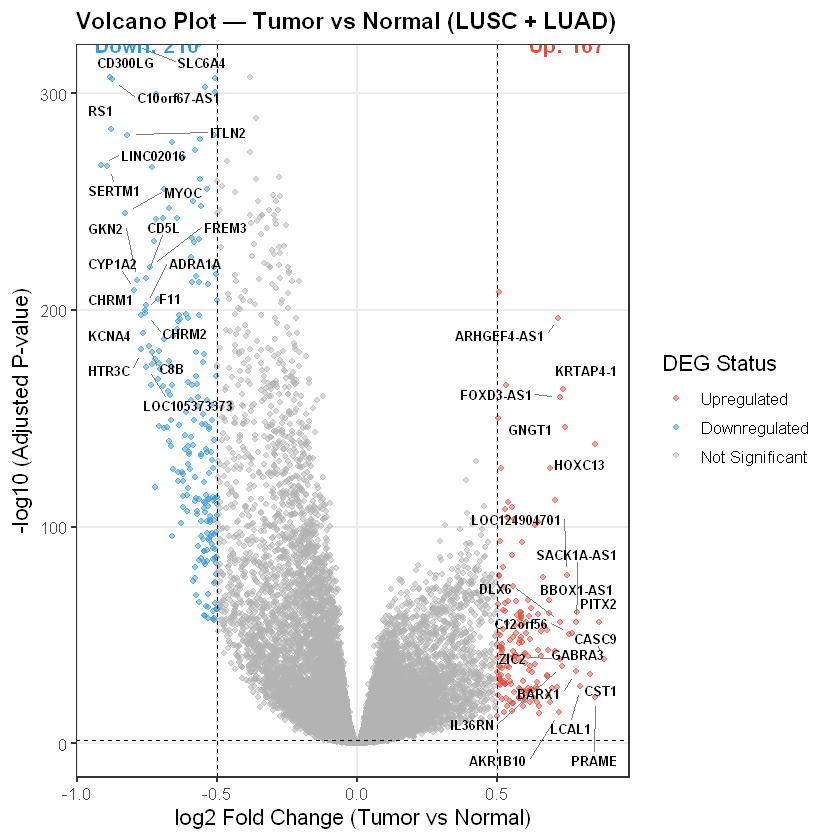

In [18]:
# Build volcano plot
volcano_plot <- ggplot(
  deg_results,
  aes(x = logFC, y = neg_log10_p, color = Status)
) +

  # All points
  geom_point(
    alpha = 0.5,
    size  = 1.2
  ) +

  # Color scheme
  scale_color_manual(values = c(
    "Upregulated"     = "#E74C3C",
    "Downregulated"   = "#3498DB",
    "Not Significant" = "grey70"
  )) +

  # Threshold lines
  geom_vline(
    xintercept = 0.5,
    linetype   = "dashed",
    color      = "black",
    linewidth  = 0.5
  ) +
  geom_vline(
    xintercept = -0.5,
    linetype   = "dashed",
    color      = "black",
    linewidth  = 0.5
  ) +
  geom_hline(
    yintercept = -log10(0.05),
    linetype   = "dashed",
    color      = "black",
    linewidth  = 0.5
  ) +

  # Gene labels — top 20 up and down
  geom_text_repel(
    data          = genes_to_label,
    aes(label     = Gene),
    size          = 2.8,
    color         = "black",
    fontface      = "bold",
    max.overlaps  = 50,
    box.padding   = 0.5,
    point.padding = 0.3,
    segment.color = "grey50",
    segment.size  = 0.3,
    min.segment.length = 0.2,
    force         = 2
  ) +

  # DEG count annotations
  annotate(
    "text",
    x        = 0.75,
    y        = max(deg_results$neg_log10_p) * 0.95,
    label    = paste0("Up: ",
                      sum(deg_results$Status == "Upregulated")),
    color    = "#E74C3C",
    fontface = "bold",
    size     = 4.5
  ) +
  annotate(
    "text",
    x        = -0.75,
    y        = max(deg_results$neg_log10_p) * 0.95,
    label    = paste0("Down: ",
                      sum(deg_results$Status == "Downregulated")),
    color    = "#3498DB",
    fontface = "bold",
    size     = 4.5
  ) +

  # Labels
  labs(
    title    = "Volcano Plot — Tumor vs Normal (LUSC + LUAD)",
    x        = "log2 Fold Change (Tumor vs Normal)",
    y        = "-log10 (Adjusted P-value)",
    color    = "DEG Status"
  ) +

  theme_bw(base_size = 13) +
  theme(
    plot.title       = element_text(face = "bold", size = 14),
    plot.subtitle    = element_text(color = "gray40", size = 9),
    legend.position  = "right",
    panel.grid.minor = element_blank()
  )

print(volcano_plot)

In [19]:
# Save high resolution
ggsave(
  "Volcano_plot_top20_DEGs.png",
  volcano_plot,
  width  = 12,
  height = 8,
  dpi    = 300
)

cat("✔ Volcano_plot_top20_DEGs.png saved\n")
cat(sprintf("  Location: %s\n", getwd()))

✔ Volcano_plot_top20_DEGs.png saved
  Location: C:/jupyter demo


In [1]:
# ============================================================
# Identify Significant Prognostic Biomarker Genes
# ============================================================

cat("=== Identifying Significant Prognostic Biomarkers ===\n\n")

# All genes to check
all_genes <- c("COL11A1", "MMP13", "CA9", "PRAME",
                "KRT16", "KRT6B", "KRT6A",
                "HOXC13", "PRAME", "PITX2", "CASC9",
                "CST1", "GABRA3", "BARX1")

# Remove duplicates
all_genes <- unique(all_genes)

cat(sprintf("Total genes to check: %d\n\n", length(all_genes)))

# Store results
biomarker_df <- data.frame()

for (gene in all_genes) {

  # --- Check DEG status ---
  if (!gene %in% rownames(deg_results)) next

  deg_row    <- deg_results[gene, ]
  logfc      <- deg_row$logFC
  adjp       <- deg_row$adj.P.Val
  status     <- as.character(deg_row$Status)
  pass_deg   <- status != "Not Significant"

  # --- Check KM survival ---
  pass_km  <- FALSE
  km_pval  <- NA

  if (gene %in% km_summary$Gene) {
    km_row  <- km_summary[km_summary$Gene == gene, ]
    km_pval <- km_row$LogRank_p
    pass_km <- km_pval < 0.05
  }

  # --- Check Cox regression ---
  pass_cox_uni   <- FALSE
  pass_cox_multi <- FALSE
  hr_uni         <- NA
  hr_multi       <- NA
  p_uni          <- NA
  p_multi        <- NA

  if (gene %in% all_cox_results$Gene) {
    uni_row   <- all_cox_results[
      all_cox_results$Gene == gene &
      all_cox_results$Analysis == "Univariate", ]
    multi_row <- all_cox_results[
      all_cox_results$Gene == gene &
      all_cox_results$Analysis == "Multivariate", ]

    if (nrow(uni_row) > 0) {
      hr_uni       <- uni_row$HR
      p_uni        <- uni_row$P_value
      pass_cox_uni <- p_uni < 0.05
    }

    if (nrow(multi_row) > 0) {
      hr_multi       <- multi_row$HR
      p_multi        <- multi_row$P_value
      pass_cox_multi <- p_multi < 0.05
    }
  }

  # --- Check ROC AUC ---
  pass_roc <- FALSE
  auc_val  <- NA

  if (gene %in% auc_results$Gene) {
    auc_row  <- auc_results[auc_results$Gene == gene, ]
    auc_val  <- auc_row$AUC
    pass_roc <- auc_val >= 0.70
  }

  # --- Check PPI network connections ---
  in_lusc_network <- gene %in% names(lusc_degree)
  in_luad_network <- gene %in% names(luad_degree)

  lusc_connections <- ifelse(
    in_lusc_network, lusc_degree[gene], 0)
  luad_connections <- ifelse(
    in_luad_network, luad_degree[gene], 0)

  has_connections <- lusc_connections > 0 |
                     luad_connections > 0

  # --- Count how many criteria passed ---
  criteria_passed <- sum(c(
    pass_deg,
    pass_km,
    pass_cox_uni,
    pass_cox_multi,
    pass_roc,
    has_connections
  ))

  # Store results
  biomarker_df <- rbind(biomarker_df, data.frame(
    Gene             = gene,
    logFC            = round(logfc, 4),
    adj_pval         = round(adjp, 4),
    DEG_Status       = status,
    Pass_DEG         = ifelse(pass_deg, "✔", "✘"),
    KM_pval          = round(km_pval, 4),
    Pass_KM          = ifelse(pass_km, "✔", "✘"),
    HR_Univariate    = round(hr_uni, 3),
    P_Univariate     = round(p_uni, 4),
    Pass_Cox_Uni     = ifelse(pass_cox_uni, "✔", "✘"),
    HR_Multivariate  = round(hr_multi, 3),
    P_Multivariate   = round(p_multi, 4),
    Pass_Cox_Multi   = ifelse(pass_cox_multi, "✔", "✘"),
    AUC              = round(auc_val, 4),
    Pass_ROC         = ifelse(pass_roc, "✔", "✘"),
    LUSC_Connections = lusc_connections,
    LUAD_Connections = luad_connections,
    Has_Connections  = ifelse(has_connections, "✔", "✘"),
    Criteria_Passed  = criteria_passed
  ))
}

=== Identifying Significant Prognostic Biomarkers ===

Total genes to check: 13



ERROR: Error: object 'deg_results' not found


In [2]:
# ============================================================
# QUICK REBUILD - Run this every time session restarts
# ============================================================

# Libraries
library(limma)
library(edgeR)
library(data.table)
library(dplyr)
library(survival)
library(survminer)
library(pROC)
library(igraph)

cat("✔ Libraries loaded\n")

# Final matrix
final_df <- read.table(
  "C:/Users/aryan/Downloads/TCGA_LUSC_LUAD_final_expression.tsv",
  header = TRUE, sep = "\t",
  row.names = 1, check.names = FALSE)
final_matrix <- as.matrix(final_df)
cat(sprintf("✔ final_matrix: %d × %d\n",
            nrow(final_matrix), ncol(final_matrix)))

# DEG results
deg_results <- readRDS("C:/jupyter demo/deg_results.rds")
deg_results$Status <- "Not Significant"
deg_results$Status[
  deg_results$logFC > 0.5 &
  deg_results$adj.P.Val < 0.05] <- "Upregulated"
deg_results$Status[
  deg_results$logFC < -0.5 &
  deg_results$adj.P.Val < 0.05] <- "Downregulated"
deg_results$Status <- factor(
  deg_results$Status,
  levels = c("Upregulated", "Downregulated",
             "Not Significant"))
cat(sprintf("✔ deg_results: %d genes\n", nrow(deg_results)))

# Clinical and survival data
lusc_clin <- read.table(
  "C:/jupyter demo/LUSC_clinical.tsv",
  header = TRUE, sep = "\t", check.names = FALSE)
luad_clin <- read.table(
  "C:/jupyter demo/LUAD_clinical.tsv",
  header = TRUE, sep = "\t", check.names = FALSE)

common_cols <- intersect(colnames(lusc_clin),
                         colnames(luad_clin))
lusc_clin$Dataset <- "LUSC"
luad_clin$Dataset <- "LUAD"
combined_clinical <- rbind(
  lusc_clin[, c(common_cols, "Dataset")],
  luad_clin[, c(common_cols, "Dataset")])

combined_clinical$OS_time <- ifelse(
  combined_clinical$vital_status == "Dead",
  as.numeric(combined_clinical$days_to_death),
  as.numeric(combined_clinical$days_to_last_follow_up))
combined_clinical$OS_event <- ifelse(
  combined_clinical$vital_status == "Dead", 1, 0)
combined_clinical$OS_months <-
  combined_clinical$OS_time / 30.44
combined_clinical <- combined_clinical[
  !is.na(combined_clinical$OS_time) &
  combined_clinical$OS_time > 0, ]

# Gene expression merge
genes_oi <- c("COL11A1", "MMP13", "CA9", "PRAME")
expr_sub  <- t(final_matrix[genes_oi, , drop = FALSE])
expr_df   <- as.data.frame(expr_sub)
expr_df$submitter_id <- substr(rownames(expr_df), 1, 12)

survival_df <- merge(combined_clinical, expr_df,
                     by = "submitter_id")
for (gene in genes_oi) {
  med <- median(survival_df[[gene]], na.rm = TRUE)
  survival_df[[paste0(gene, "_group")]] <- ifelse(
    survival_df[[gene]] >= med, "HIGH", "LOW")
}
cat(sprintf("✔ survival_df: %d patients\n",
            nrow(survival_df)))

# KM summary
km_summary <- data.frame()
for (gene in genes_oi) {
  surv_obj  <- Surv(survival_df$OS_months,
                    survival_df$OS_event)
  log_rank  <- survdiff(
    surv_obj ~ survival_df[[paste0(gene, "_group")]])
  pval      <- 1 - pchisq(log_rank$chisq, df = 1)
  km_summary <- rbind(km_summary, data.frame(
    Gene        = gene,
    LogRank_p   = round(pval, 4),
    Significant = ifelse(pval < 0.05, "YES", "NO")))
}
cat("✔ KM summary ready\n")

# Cox results
all_cox_results <- read.table(
  "C:/jupyter demo/Cox_regression_results.tsv",
  header = TRUE, sep = "\t", check.names = FALSE)
cat("✔ Cox results loaded\n")

# AUC results
auc_results <- data.frame(
  Gene        = c("COL11A1", "MMP13", "CA9", "PRAME"),
  AUC         = c(0.9518, 0.8976, 0.9268, 0.9227),
  CI_lower    = c(0.9351, 0.8732, 0.9050, 0.9054),
  CI_upper    = c(0.9685, 0.9220, 0.9487, 0.9400),
  Performance = c("Excellent", "Good",
                  "Excellent", "Excellent"))
cat("✔ AUC results ready\n")

# PPI networks
lusc_edges <- read.table(
  "C:/jupyter demo/LUSC_STRING_interactions.tsv",
  header = TRUE, sep = "\t", check.names = FALSE)
luad_edges <- read.table(
  "C:/jupyter demo/LUAD_STRING_interactions.tsv",
  header = TRUE, sep = "\t", check.names = FALSE)

lusc_network <- graph_from_data_frame(
  lusc_edges, directed = FALSE)
luad_network <- graph_from_data_frame(
  luad_edges, directed = FALSE)
lusc_degree  <- degree(lusc_network)
luad_degree  <- degree(luad_network)

cat("✔ PPI networks ready\n")

# Final check
cat("\n=== All Objects Ready ===\n")
cat(sprintf("deg_results:     %s\n", exists("deg_results")))
cat(sprintf("survival_df:     %s\n", exists("survival_df")))
cat(sprintf("km_summary:      %s\n", exists("km_summary")))
cat(sprintf("all_cox_results: %s\n", exists("all_cox_results")))
cat(sprintf("auc_results:     %s\n", exists("auc_results")))
cat(sprintf("lusc_degree:     %s\n", exists("lusc_degree")))
cat(sprintf("luad_degree:     %s\n", exists("luad_degree")))


Attaching package: 'data.table'


The following object is masked from 'package:base':

    %notin%



Attaching package: 'dplyr'


The following objects are masked from 'package:data.table':

    between, first, last


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Loading required package: ggplot2

Loading required package: ggpubr


Attaching package: 'survminer'


The following object is masked from 'package:survival':

    myeloma


Type 'citation("pROC")' for a citation.


Attaching package: 'pROC'


The following objects are masked from 'package:stats':

    cov, smooth, var



Attaching package: 'igraph'


The following objects are masked from 'package:dplyr':

    as_data_frame, groups, union


The following objects are masked from 'package:stats':

    decompose, spectrum


The following object is masked from 'package:base':

    union




✔ Libraries loaded
✔ final_matrix: 36650 × 1139
✔ deg_results: 36650 genes
✔ survival_df: 1118 patients
✔ KM summary ready
✔ Cox results loaded
✔ AUC results ready
✔ PPI networks ready

=== All Objects Ready ===
deg_results:     TRUE
survival_df:     TRUE
km_summary:      TRUE
all_cox_results: TRUE
auc_results:     TRUE
lusc_degree:     TRUE
luad_degree:     TRUE


In [3]:
# ============================================================
# Identify Significant Prognostic Biomarker Genes
# ============================================================

cat("=== Identifying Significant Prognostic Biomarkers ===\n\n")

# All genes to check
all_genes <- c("COL11A1", "MMP13", "CA9", "PRAME",
                "KRT16", "KRT6B", "KRT6A",
                "HOXC13", "PRAME", "PITX2", "CASC9",
                "CST1", "GABRA3", "BARX1")

# Remove duplicates
all_genes <- unique(all_genes)

cat(sprintf("Total genes to check: %d\n\n", length(all_genes)))

# Store results
biomarker_df <- data.frame()

for (gene in all_genes) {

  # --- Check DEG status ---
  if (!gene %in% rownames(deg_results)) next

  deg_row    <- deg_results[gene, ]
  logfc      <- deg_row$logFC
  adjp       <- deg_row$adj.P.Val
  status     <- as.character(deg_row$Status)
  pass_deg   <- status != "Not Significant"

  # --- Check KM survival ---
  pass_km  <- FALSE
  km_pval  <- NA

  if (gene %in% km_summary$Gene) {
    km_row  <- km_summary[km_summary$Gene == gene, ]
    km_pval <- km_row$LogRank_p
    pass_km <- km_pval < 0.05
  }

  # --- Check Cox regression ---
  pass_cox_uni   <- FALSE
  pass_cox_multi <- FALSE
  hr_uni         <- NA
  hr_multi       <- NA
  p_uni          <- NA
  p_multi        <- NA

  if (gene %in% all_cox_results$Gene) {
    uni_row   <- all_cox_results[
      all_cox_results$Gene == gene &
      all_cox_results$Analysis == "Univariate", ]
    multi_row <- all_cox_results[
      all_cox_results$Gene == gene &
      all_cox_results$Analysis == "Multivariate", ]

    if (nrow(uni_row) > 0) {
      hr_uni       <- uni_row$HR
      p_uni        <- uni_row$P_value
      pass_cox_uni <- p_uni < 0.05
    }

    if (nrow(multi_row) > 0) {
      hr_multi       <- multi_row$HR
      p_multi        <- multi_row$P_value
      pass_cox_multi <- p_multi < 0.05
    }
  }

  # --- Check ROC AUC ---
  pass_roc <- FALSE
  auc_val  <- NA

  if (gene %in% auc_results$Gene) {
    auc_row  <- auc_results[auc_results$Gene == gene, ]
    auc_val  <- auc_row$AUC
    pass_roc <- auc_val >= 0.70
  }

  # --- Check PPI network connections ---
  in_lusc_network <- gene %in% names(lusc_degree)
  in_luad_network <- gene %in% names(luad_degree)

  lusc_connections <- ifelse(
    in_lusc_network, lusc_degree[gene], 0)
  luad_connections <- ifelse(
    in_luad_network, luad_degree[gene], 0)

  has_connections <- lusc_connections > 0 |
                     luad_connections > 0

  # --- Count how many criteria passed ---
  criteria_passed <- sum(c(
    pass_deg,
    pass_km,
    pass_cox_uni,
    pass_cox_multi,
    pass_roc,
    has_connections
  ))

  # Store results
  biomarker_df <- rbind(biomarker_df, data.frame(
    Gene             = gene,
    logFC            = round(logfc, 4),
    adj_pval         = round(adjp, 4),
    DEG_Status       = status,
    Pass_DEG         = ifelse(pass_deg, "✔", "✘"),
    KM_pval          = round(km_pval, 4),
    Pass_KM          = ifelse(pass_km, "✔", "✘"),
    HR_Univariate    = round(hr_uni, 3),
    P_Univariate     = round(p_uni, 4),
    Pass_Cox_Uni     = ifelse(pass_cox_uni, "✔", "✘"),
    HR_Multivariate  = round(hr_multi, 3),
    P_Multivariate   = round(p_multi, 4),
    Pass_Cox_Multi   = ifelse(pass_cox_multi, "✔", "✘"),
    AUC              = round(auc_val, 4),
    Pass_ROC         = ifelse(pass_roc, "✔", "✘"),
    LUSC_Connections = lusc_connections,
    LUAD_Connections = luad_connections,
    Has_Connections  = ifelse(has_connections, "✔", "✘"),
    Criteria_Passed  = criteria_passed
  ))
}

=== Identifying Significant Prognostic Biomarkers ===

Total genes to check: 13



In [4]:
# Sort by criteria passed
biomarker_df <- biomarker_df[
  order(-biomarker_df$Criteria_Passed), ]
rownames(biomarker_df) <- NULL

cat("=== Biomarker Criteria Summary ===\n\n")
cat(sprintf("%-12s %-6s %-6s %-6s %-6s %-6s %-6s %-8s\n",
            "Gene", "DEG", "KM", "CoxUni",
            "CoxMul", "ROC", "PPI", "Score"))
cat(paste(rep("-", 65), collapse = ""), "\n")

for (i in 1:nrow(biomarker_df)) {
  row <- biomarker_df[i, ]
  cat(sprintf("%-12s %-6s %-6s %-6s %-6s %-6s %-6s %d/6\n",
              row$Gene,
              row$Pass_DEG,
              row$Pass_KM,
              row$Pass_Cox_Uni,
              row$Pass_Cox_Multi,
              row$Pass_ROC,
              row$Has_Connections,
              row$Criteria_Passed))
}

=== Biomarker Criteria Summary ===

Gene         DEG    KM     CoxUni CoxMul ROC    PPI    Score   
----------------------------------------------------------------- 
MMP13        ✔    ✔    ✘    ✘    ✔    ✔    4/6
COL11A1      ✔    ✘    ✘    ✘    ✔    ✔    3/6
CA9          ✔    ✘    ✘    ✘    ✔    ✔    3/6
PRAME        ✔    ✘    ✘    ✘    ✔    ✔    3/6
KRT16        ✔    ✘    ✘    ✘    ✘    ✔    2/6
KRT6B        ✔    ✘    ✘    ✘    ✘    ✔    2/6
KRT6A        ✔    ✘    ✘    ✘    ✘    ✔    2/6
HOXC13       ✔    ✘    ✘    ✘    ✘    ✔    2/6
PITX2        ✔    ✘    ✘    ✘    ✘    ✔    2/6
CST1         ✔    ✘    ✘    ✘    ✘    ✔    2/6
GABRA3       ✔    ✘    ✘    ✘    ✘    ✔    2/6
BARX1        ✔    ✘    ✘    ✘    ✘    ✔    2/6
CASC9        ✔    ✘    ✘    ✘    ✘    ✘    1/6


In [5]:
# Identify top biomarker candidates
cat("\n=== Top Biomarker Candidates ===\n\n")

# Genes passing at least 3 criteria
top_candidates <- biomarker_df[
  biomarker_df$Criteria_Passed >= 3, ]

if (nrow(top_candidates) > 0) {
  cat(sprintf("Genes passing 3+ criteria: %d\n\n",
              nrow(top_candidates)))
  print(top_candidates[, c("Gene", "DEG_Status",
                            "logFC", "AUC",
                            "KM_pval",
                            "LUSC_Connections",
                            "LUAD_Connections",
                            "Criteria_Passed")])
} else {
  cat("No genes passed 3+ criteria\n")
  cat("Showing genes passing 2+ criteria:\n\n")
  two_plus <- biomarker_df[
    biomarker_df$Criteria_Passed >= 2, ]
  print(two_plus[, c("Gene", "DEG_Status",
                      "logFC", "AUC",
                      "KM_pval",
                      "Criteria_Passed")])
}


=== Top Biomarker Candidates ===

Genes passing 3+ criteria: 4

     Gene  DEG_Status  logFC    AUC KM_pval LUSC_Connections LUAD_Connections
1   MMP13 Upregulated 0.6327 0.8976  0.0465                9                1
2 COL11A1 Upregulated 0.6296 0.9518  0.1554                7                1
3     CA9 Upregulated 0.6409 0.9268  0.2405                3                1
4   PRAME Upregulated 0.8499 0.9227  0.5953                8                1
  Criteria_Passed
1               4
2               3
3               3
4               3


In [6]:
# ============================================================
# PROGNOSTIC BIOMARKER CHECK
# ============================================================

cat("=== Prognostic Biomarker Evaluation ===\n\n")

# Define criteria for prognostic biomarker
# 1. DEG: significant (adj.p < 0.05 and |logFC| > 0.5)
# 2. KM: log-rank p < 0.05
# 3. Cox Univariate: p < 0.05
# 4. Cox Multivariate: p < 0.05
# 5. ROC: AUC >= 0.70
# 6. PPI: has network connections

genes_check <- c("COL11A1", "MMP13", "CA9", "PRAME")
results     <- data.frame()

for (gene in genes_check) {

  cat(sprintf("Checking %s...\n", gene))

  # --- Criterion 1: DEG ---
  pass_deg  <- FALSE
  logfc     <- NA
  adjp      <- NA
  deg_status <- "Not tested"

  if (gene %in% rownames(deg_results)) {
    logfc      <- deg_results[gene, "logFC"]
    adjp       <- deg_results[gene, "adj.P.Val"]
    deg_status <- as.character(deg_results[gene, "Status"])
    pass_deg   <- deg_status != "Not Significant"
  }

  # --- Criterion 2: KM Survival ---
  pass_km <- FALSE
  km_p    <- NA

  if (gene %in% km_summary$Gene) {
    km_p    <- km_summary[km_summary$Gene == gene,
                          "LogRank_p"]
    pass_km <- km_p < 0.05
  }

  # --- Criterion 3: Cox Univariate ---
  pass_uni <- FALSE
  hr_uni   <- NA
  p_uni    <- NA

  if (gene %in% all_cox_results$Gene) {
    uni <- all_cox_results[
      all_cox_results$Gene == gene &
      all_cox_results$Analysis == "Univariate", ]
    if (nrow(uni) > 0) {
      hr_uni   <- uni$HR
      p_uni    <- uni$P_value
      pass_uni <- p_uni < 0.05
    }
  }

  # --- Criterion 4: Cox Multivariate ---
  pass_multi <- FALSE
  hr_multi   <- NA
  p_multi    <- NA

  if (gene %in% all_cox_results$Gene) {
    multi <- all_cox_results[
      all_cox_results$Gene == gene &
      all_cox_results$Analysis == "Multivariate", ]
    if (nrow(multi) > 0) {
      hr_multi   <- multi$HR
      p_multi    <- multi$P_value
      pass_multi <- p_multi < 0.05
    }
  }

  # --- Criterion 5: ROC AUC ---
  pass_roc <- FALSE
  auc_val  <- NA

  if (gene %in% auc_results$Gene) {
    auc_val  <- auc_results[
      auc_results$Gene == gene, "AUC"]
    pass_roc <- auc_val >= 0.70
  }

  # --- Criterion 6: PPI Connections ---
  lusc_conn <- ifelse(gene %in% names(lusc_degree),
                      lusc_degree[gene], 0)
  luad_conn <- ifelse(gene %in% names(luad_degree),
                      luad_degree[gene], 0)
  pass_ppi  <- lusc_conn > 0 | luad_conn > 0

  # --- Total score ---
  score <- sum(c(pass_deg, pass_km,
                 pass_uni, pass_multi,
                 pass_roc, pass_ppi))

  # Store
  results <- rbind(results, data.frame(
    Gene          = gene,
    logFC         = round(logfc, 4),
    DEG_Status    = deg_status,
    Pass_DEG      = ifelse(pass_deg,  "✔", "✘"),
    KM_pval       = round(km_p, 4),
    Pass_KM       = ifelse(pass_km,   "✔", "✘"),
    HR_Uni        = round(hr_uni, 3),
    P_Uni         = round(p_uni, 4),
    Pass_CoxUni   = ifelse(pass_uni,  "✔", "✘"),
    HR_Multi      = round(hr_multi, 3),
    P_Multi       = round(p_multi, 4),
    Pass_CoxMulti = ifelse(pass_multi,"✔", "✘"),
    AUC           = round(auc_val, 4),
    Pass_ROC      = ifelse(pass_roc,  "✔", "✘"),
    LUSC_Conn     = lusc_conn,
    LUAD_Conn     = luad_conn,
    Pass_PPI      = ifelse(pass_ppi,  "✔", "✘"),
    Total_Score   = paste0(score, "/6")
  ))
}

=== Prognostic Biomarker Evaluation ===

Checking COL11A1...
Checking MMP13...
Checking CA9...
Checking PRAME...


In [7]:
# Print summary table
cat("\n=== PROGNOSTIC BIOMARKER SCORECARD ===\n\n")

cat(sprintf("%-10s %-6s %-6s %-8s %-8s %-6s %-6s %s\n",
            "Gene", "DEG", "KM",
            "CoxUni", "CoxMul",
            "ROC", "PPI", "Score"))
cat(paste(rep("-", 60), collapse = ""), "\n")

for (i in 1:nrow(results)) {
  r <- results[i, ]
  cat(sprintf("%-10s %-6s %-6s %-8s %-8s %-6s %-6s %s\n",
              r$Gene,
              r$Pass_DEG,
              r$Pass_KM,
              r$Pass_CoxUni,
              r$Pass_CoxMulti,
              r$Pass_ROC,
              r$Pass_PPI,
              r$Total_Score))
}


=== PROGNOSTIC BIOMARKER SCORECARD ===

Gene       DEG    KM     CoxUni   CoxMul   ROC    PPI    Score
------------------------------------------------------------ 
COL11A1    ✔    ✘    ✘      ✘      ✔    ✔    3/6
MMP13      ✔    ✔    ✘      ✘      ✔    ✔    4/6
CA9        ✔    ✘    ✘      ✘      ✔    ✔    3/6
PRAME      ✔    ✘    ✘      ✘      ✔    ✔    3/6


In [8]:
# Identify best candidates
cat("\n=== VERDICT ===\n\n")

for (i in 1:nrow(results)) {
  r     <- results[i, ]
  score <- as.numeric(gsub("/6", "", r$Total_Score))

  cat(sprintf("--- %s ---\n", r$Gene))
  cat(sprintf("Score: %s\n", r$Total_Score))

  if (score >= 5) {
    cat("★★★ STRONG prognostic biomarker candidate\n")
  } else if (score >= 4) {
    cat("★★  GOOD prognostic biomarker candidate\n")
  } else if (score >= 3) {
    cat("★   MODERATE candidate — needs validation\n")
  } else if (score >= 2) {
    cat("⚠   WEAK candidate — limited evidence\n")
  } else {
    cat("✘   Does NOT qualify as prognostic biomarker\n")
  }

  # Specific comments
  if (r$Pass_DEG == "✔") {
    cat(sprintf("  ✔ Significantly dysregulated (logFC=%.4f)\n",
                r$logFC))
  }
  if (r$Pass_KM == "✔") {
    cat(sprintf("  ✔ Significant survival difference (p=%.4f)\n",
                r$KM_pval))
  }
  if (r$Pass_ROC == "✔") {
    cat(sprintf("  ✔ Strong diagnostic value (AUC=%.4f)\n",
                r$AUC))
  }
  if (r$Pass_PPI == "✔") {
    cat(sprintf("  ✔ Connected in PPI network (LUSC=%d, LUAD=%d)\n",
                r$LUSC_Conn, r$LUAD_Conn))
  }
  if (r$Pass_CoxUni == "✘" & r$Pass_CoxMulti == "✘") {
    cat("  ✘ Not significant in Cox regression\n")
  }
  cat("\n")
}


=== VERDICT ===

--- COL11A1 ---
Score: 3/6
★   MODERATE candidate — needs validation
  ✔ Significantly dysregulated (logFC=0.6296)
  ✔ Strong diagnostic value (AUC=0.9518)
  ✔ Connected in PPI network (LUSC=7, LUAD=1)
  ✘ Not significant in Cox regression

--- MMP13 ---
Score: 4/6
★★  GOOD prognostic biomarker candidate
  ✔ Significantly dysregulated (logFC=0.6327)
  ✔ Significant survival difference (p=0.0465)
  ✔ Strong diagnostic value (AUC=0.8976)
  ✔ Connected in PPI network (LUSC=9, LUAD=1)
  ✘ Not significant in Cox regression

--- CA9 ---
Score: 3/6
★   MODERATE candidate — needs validation
  ✔ Significantly dysregulated (logFC=0.6409)
  ✔ Strong diagnostic value (AUC=0.9268)
  ✔ Connected in PPI network (LUSC=3, LUAD=1)
  ✘ Not significant in Cox regression

--- PRAME ---
Score: 3/6
★   MODERATE candidate — needs validation
  ✔ Significantly dysregulated (logFC=0.8499)
  ✔ Strong diagnostic value (AUC=0.9227)
  ✔ Connected in PPI network (LUSC=8, LUAD=1)
  ✘ Not significant 

In [9]:
# Save results
write.table(
  results,
  file      = "Prognostic_Biomarker_Scorecard.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

cat("✔ Prognostic_Biomarker_Scorecard.tsv saved\n")
cat(sprintf("  Location: %s\n", getwd()))

✔ Prognostic_Biomarker_Scorecard.tsv saved
  Location: C:/jupyter demo


In [1]:
# ============================================================
# Find DEGs with highest PPI connections
# ============================================================

cat("=== DEGs Ranked by PPI Connections ===\n\n")

# Get all significant DEGs
sig_gene_list <- rownames(
  deg_results[deg_results$Status != "Not Significant", ])

cat(sprintf("Total significant DEGs: %d\n\n", 
            length(sig_gene_list)))

# --- LUSC network connections for DEGs ---
cat("--- LUSC Network ---\n")

lusc_deg_connections <- data.frame(
  Gene       = names(lusc_degree),
  Connection = as.numeric(lusc_degree)
)

# Keep only significant DEGs
lusc_deg_connections <- lusc_deg_connections[
  lusc_deg_connections$Gene %in% sig_gene_list, ]

# Sort by connections
lusc_deg_connections <- lusc_deg_connections[
  order(-lusc_deg_connections$Connection), ]

cat("Top 20 DEGs by LUSC connections:\n")
print(head(lusc_deg_connections, 20))

=== DEGs Ranked by PPI Connections ===



ERROR: Error: object 'deg_results' not found


In [1]:
# ============================================================
# PROGNOSTIC BIOMARKER CHECK
# ============================================================

cat("=== Prognostic Biomarker Evaluation ===\n\n")

# Define criteria for prognostic biomarker
# 1. DEG: significant (adj.p < 0.05 and |logFC| > 0.5)
# 2. KM: log-rank p < 0.05
# 3. Cox Univariate: p < 0.05
# 4. Cox Multivariate: p < 0.05
# 5. ROC: AUC >= 0.70
# 6. PPI: has network connections

genes_check <- c("COL11A1", "MMP13", "CA9", "PRAME")
results     <- data.frame()

for (gene in genes_check) {

  cat(sprintf("Checking %s...\n", gene))

  # --- Criterion 1: DEG ---
  pass_deg  <- FALSE
  logfc     <- NA
  adjp      <- NA
  deg_status <- "Not tested"

  if (gene %in% rownames(deg_results)) {
    logfc      <- deg_results[gene, "logFC"]
    adjp       <- deg_results[gene, "adj.P.Val"]
    deg_status <- as.character(deg_results[gene, "Status"])
    pass_deg   <- deg_status != "Not Significant"
  }

  # --- Criterion 2: KM Survival ---
  pass_km <- FALSE
  km_p    <- NA

  if (gene %in% km_summary$Gene) {
    km_p    <- km_summary[km_summary$Gene == gene,
                          "LogRank_p"]
    pass_km <- km_p < 0.05
  }

  # --- Criterion 3: Cox Univariate ---
  pass_uni <- FALSE
  hr_uni   <- NA
  p_uni    <- NA

  if (gene %in% all_cox_results$Gene) {
    uni <- all_cox_results[
      all_cox_results$Gene == gene &
      all_cox_results$Analysis == "Univariate", ]
    if (nrow(uni) > 0) {
      hr_uni   <- uni$HR
      p_uni    <- uni$P_value
      pass_uni <- p_uni < 0.05
    }
  }

  # --- Criterion 4: Cox Multivariate ---
  pass_multi <- FALSE
  hr_multi   <- NA
  p_multi    <- NA

  if (gene %in% all_cox_results$Gene) {
    multi <- all_cox_results[
      all_cox_results$Gene == gene &
      all_cox_results$Analysis == "Multivariate", ]
    if (nrow(multi) > 0) {
      hr_multi   <- multi$HR
      p_multi    <- multi$P_value
      pass_multi <- p_multi < 0.05
    }
  }

  # --- Criterion 5: ROC AUC ---
  pass_roc <- FALSE
  auc_val  <- NA

  if (gene %in% auc_results$Gene) {
    auc_val  <- auc_results[
      auc_results$Gene == gene, "AUC"]
    pass_roc <- auc_val >= 0.70
  }

  # --- Criterion 6: PPI Connections ---
  lusc_conn <- ifelse(gene %in% names(lusc_degree),
                      lusc_degree[gene], 0)
  luad_conn <- ifelse(gene %in% names(luad_degree),
                      luad_degree[gene], 0)
  pass_ppi  <- lusc_conn > 0 | luad_conn > 0

  # --- Total score ---
  score <- sum(c(pass_deg, pass_km,
                 pass_uni, pass_multi,
                 pass_roc, pass_ppi))

  # Store
  results <- rbind(results, data.frame(
    Gene          = gene,
    logFC         = round(logfc, 4),
    DEG_Status    = deg_status,
    Pass_DEG      = ifelse(pass_deg,  "✔", "✘"),
    KM_pval       = round(km_p, 4),
    Pass_KM       = ifelse(pass_km,   "✔", "✘"),
    HR_Uni        = round(hr_uni, 3),
    P_Uni         = round(p_uni, 4),
    Pass_CoxUni   = ifelse(pass_uni,  "✔", "✘"),
    HR_Multi      = round(hr_multi, 3),
    P_Multi       = round(p_multi, 4),
    Pass_CoxMulti = ifelse(pass_multi,"✔", "✘"),
    AUC           = round(auc_val, 4),
    Pass_ROC      = ifelse(pass_roc,  "✔", "✘"),
    LUSC_Conn     = lusc_conn,
    LUAD_Conn     = luad_conn,
    Pass_PPI      = ifelse(pass_ppi,  "✔", "✘"),
    Total_Score   = paste0(score, "/6")
  ))
}

=== Prognostic Biomarker Evaluation ===

Checking COL11A1...


ERROR: Error: object 'deg_results' not found


In [2]:
# ============================================================
# COMPLETE REBUILD — Run this every time
# ============================================================

# Libraries
library(limma)
library(edgeR)
library(data.table)
library(dplyr)
library(survival)
library(survminer)
library(pROC)
library(igraph)

cat("✔ Libraries loaded\n")

# Final matrix
final_df <- read.table(
  "C:/Users/aryan/Downloads/TCGA_LUSC_LUAD_final_expression.tsv",
  header = TRUE, sep = "\t",
  row.names = 1, check.names = FALSE)
final_matrix <- as.matrix(final_df)
cat(sprintf("✔ final_matrix: %d × %d\n",
            nrow(final_matrix), ncol(final_matrix)))

# DEG results
deg_results <- readRDS("C:/jupyter demo/deg_results.rds")
deg_results$Status <- "Not Significant"
deg_results$Status[
  deg_results$logFC > 0.5 &
  deg_results$adj.P.Val < 0.05] <- "Upregulated"
deg_results$Status[
  deg_results$logFC < -0.5 &
  deg_results$adj.P.Val < 0.05] <- "Downregulated"
deg_results$Status <- factor(
  deg_results$Status,
  levels = c("Upregulated", "Downregulated",
             "Not Significant"))
cat(sprintf("✔ deg_results: %d genes\n", nrow(deg_results)))

# Clinical data
lusc_clin <- read.table(
  "C:/jupyter demo/LUSC_clinical.tsv",
  header = TRUE, sep = "\t", check.names = FALSE)
luad_clin <- read.table(
  "C:/jupyter demo/LUAD_clinical.tsv",
  header = TRUE, sep = "\t", check.names = FALSE)

common_cols <- intersect(colnames(lusc_clin),
                         colnames(luad_clin))
lusc_clin$Dataset <- "LUSC"
luad_clin$Dataset <- "LUAD"
combined_clinical <- rbind(
  lusc_clin[, c(common_cols, "Dataset")],
  luad_clin[, c(common_cols, "Dataset")])

combined_clinical$OS_time <- ifelse(
  combined_clinical$vital_status == "Dead",
  as.numeric(combined_clinical$days_to_death),
  as.numeric(combined_clinical$days_to_last_follow_up))
combined_clinical$OS_event <- ifelse(
  combined_clinical$vital_status == "Dead", 1, 0)
combined_clinical$OS_months <-
  combined_clinical$OS_time / 30.44
combined_clinical <- combined_clinical[
  !is.na(combined_clinical$OS_time) &
  combined_clinical$OS_time > 0, ]
cat(sprintf("✔ Clinical: %d patients\n",
            nrow(combined_clinical)))

# Gene expression merge
genes_oi <- c("COL11A1", "MMP13", "CA9", "PRAME")
expr_sub  <- t(final_matrix[genes_oi, , drop = FALSE])
expr_df   <- as.data.frame(expr_sub)
expr_df$submitter_id <- substr(rownames(expr_df), 1, 12)

survival_df <- merge(combined_clinical, expr_df,
                     by = "submitter_id")

# Median groups
for (gene in genes_oi) {
  med <- median(survival_df[[gene]], na.rm = TRUE)
  survival_df[[paste0(gene, "_group")]] <- ifelse(
    survival_df[[gene]] >= med, "HIGH", "LOW")
}
cat(sprintf("✔ survival_df: %d patients\n",
            nrow(survival_df)))

# AUC results
auc_results <- data.frame(
  Gene        = c("COL11A1", "MMP13", "CA9", "PRAME"),
  AUC         = c(0.9518, 0.8976, 0.9268, 0.9227),
  CI_lower    = c(0.9351, 0.8732, 0.9050, 0.9054),
  CI_upper    = c(0.9685, 0.9220, 0.9487, 0.9400),
  Performance = c("Excellent", "Good",
                  "Excellent", "Excellent"))
cat("✔ AUC results ready\n")

# PPI networks
lusc_edges <- read.table(
  "C:/jupyter demo/LUSC_STRING_interactions.tsv",
  header = TRUE, sep = "\t", check.names = FALSE)
luad_edges <- read.table(
  "C:/jupyter demo/LUAD_STRING_interactions.tsv",
  header = TRUE, sep = "\t", check.names = FALSE)
lusc_network <- graph_from_data_frame(
  lusc_edges, directed = FALSE)
luad_network <- graph_from_data_frame(
  luad_edges, directed = FALSE)
lusc_degree  <- degree(lusc_network)
luad_degree  <- degree(luad_network)
cat("✔ PPI networks ready\n")

# Final check
cat("\n=== All Objects Ready ===\n")
cat(sprintf("deg_results:   %s\n", exists("deg_results")))
cat(sprintf("survival_df:   %s\n", exists("survival_df")))
cat(sprintf("auc_results:   %s\n", exists("auc_results")))
cat(sprintf("lusc_degree:   %s\n", exists("lusc_degree")))
cat(sprintf("luad_degree:   %s\n", exists("luad_degree")))


Attaching package: 'data.table'


The following object is masked from 'package:base':

    %notin%



Attaching package: 'dplyr'


The following objects are masked from 'package:data.table':

    between, first, last


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Loading required package: ggplot2

Loading required package: ggpubr


Attaching package: 'survminer'


The following object is masked from 'package:survival':

    myeloma


Type 'citation("pROC")' for a citation.


Attaching package: 'pROC'


The following objects are masked from 'package:stats':

    cov, smooth, var



Attaching package: 'igraph'


The following objects are masked from 'package:dplyr':

    as_data_frame, groups, union


The following objects are masked from 'package:stats':

    decompose, spectrum


The following object is masked from 'package:base':

    union




✔ Libraries loaded
✔ final_matrix: 36650 × 1139
✔ deg_results: 36650 genes
✔ Clinical: 1005 patients
✔ survival_df: 1118 patients
✔ AUC results ready
✔ PPI networks ready

=== All Objects Ready ===
deg_results:   TRUE
survival_df:   TRUE
auc_results:   TRUE
lusc_degree:   TRUE
luad_degree:   TRUE


In [3]:
# ============================================================
# PROGNOSTIC BIOMARKER CHECK
# ============================================================

cat("=== Prognostic Biomarker Evaluation ===\n\n")

# Define criteria for prognostic biomarker
# 1. DEG: significant (adj.p < 0.05 and |logFC| > 0.5)
# 2. KM: log-rank p < 0.05
# 3. Cox Univariate: p < 0.05
# 4. Cox Multivariate: p < 0.05
# 5. ROC: AUC >= 0.70
# 6. PPI: has network connections

genes_check <- c("COL11A1", "MMP13", "CA9", "PRAME")
results     <- data.frame()

for (gene in genes_check) {

  cat(sprintf("Checking %s...\n", gene))

  # --- Criterion 1: DEG ---
  pass_deg  <- FALSE
  logfc     <- NA
  adjp      <- NA
  deg_status <- "Not tested"

  if (gene %in% rownames(deg_results)) {
    logfc      <- deg_results[gene, "logFC"]
    adjp       <- deg_results[gene, "adj.P.Val"]
    deg_status <- as.character(deg_results[gene, "Status"])
    pass_deg   <- deg_status != "Not Significant"
  }

  # --- Criterion 2: KM Survival ---
  pass_km <- FALSE
  km_p    <- NA

  if (gene %in% km_summary$Gene) {
    km_p    <- km_summary[km_summary$Gene == gene,
                          "LogRank_p"]
    pass_km <- km_p < 0.05
  }

  # --- Criterion 3: Cox Univariate ---
  pass_uni <- FALSE
  hr_uni   <- NA
  p_uni    <- NA

  if (gene %in% all_cox_results$Gene) {
    uni <- all_cox_results[
      all_cox_results$Gene == gene &
      all_cox_results$Analysis == "Univariate", ]
    if (nrow(uni) > 0) {
      hr_uni   <- uni$HR
      p_uni    <- uni$P_value
      pass_uni <- p_uni < 0.05
    }
  }

  # --- Criterion 4: Cox Multivariate ---
  pass_multi <- FALSE
  hr_multi   <- NA
  p_multi    <- NA

  if (gene %in% all_cox_results$Gene) {
    multi <- all_cox_results[
      all_cox_results$Gene == gene &
      all_cox_results$Analysis == "Multivariate", ]
    if (nrow(multi) > 0) {
      hr_multi   <- multi$HR
      p_multi    <- multi$P_value
      pass_multi <- p_multi < 0.05
    }
  }

  # --- Criterion 5: ROC AUC ---
  pass_roc <- FALSE
  auc_val  <- NA

  if (gene %in% auc_results$Gene) {
    auc_val  <- auc_results[
      auc_results$Gene == gene, "AUC"]
    pass_roc <- auc_val >= 0.70
  }

  # --- Criterion 6: PPI Connections ---
  lusc_conn <- ifelse(gene %in% names(lusc_degree),
                      lusc_degree[gene], 0)
  luad_conn <- ifelse(gene %in% names(luad_degree),
                      luad_degree[gene], 0)
  pass_ppi  <- lusc_conn > 0 | luad_conn > 0

  # --- Total score ---
  score <- sum(c(pass_deg, pass_km,
                 pass_uni, pass_multi,
                 pass_roc, pass_ppi))

  # Store
  results <- rbind(results, data.frame(
    Gene          = gene,
    logFC         = round(logfc, 4),
    DEG_Status    = deg_status,
    Pass_DEG      = ifelse(pass_deg,  "✔", "✘"),
    KM_pval       = round(km_p, 4),
    Pass_KM       = ifelse(pass_km,   "✔", "✘"),
    HR_Uni        = round(hr_uni, 3),
    P_Uni         = round(p_uni, 4),
    Pass_CoxUni   = ifelse(pass_uni,  "✔", "✘"),
    HR_Multi      = round(hr_multi, 3),
    P_Multi       = round(p_multi, 4),
    Pass_CoxMulti = ifelse(pass_multi,"✔", "✘"),
    AUC           = round(auc_val, 4),
    Pass_ROC      = ifelse(pass_roc,  "✔", "✘"),
    LUSC_Conn     = lusc_conn,
    LUAD_Conn     = luad_conn,
    Pass_PPI      = ifelse(pass_ppi,  "✔", "✘"),
    Total_Score   = paste0(score, "/6")
  ))
}

=== Prognostic Biomarker Evaluation ===

Checking COL11A1...


ERROR: Error: object 'km_summary' not found


In [4]:
# ============================================================
# QUICK REBUILD - Run this every time session restarts
# ============================================================

# Libraries
library(limma)
library(edgeR)
library(data.table)
library(dplyr)
library(survival)
library(survminer)
library(pROC)
library(igraph)

cat("✔ Libraries loaded\n")

# Final matrix
final_df <- read.table(
  "C:/Users/aryan/Downloads/TCGA_LUSC_LUAD_final_expression.tsv",
  header = TRUE, sep = "\t",
  row.names = 1, check.names = FALSE)
final_matrix <- as.matrix(final_df)
cat(sprintf("✔ final_matrix: %d × %d\n",
            nrow(final_matrix), ncol(final_matrix)))

# DEG results
deg_results <- readRDS("C:/jupyter demo/deg_results.rds")
deg_results$Status <- "Not Significant"
deg_results$Status[
  deg_results$logFC > 0.5 &
  deg_results$adj.P.Val < 0.05] <- "Upregulated"
deg_results$Status[
  deg_results$logFC < -0.5 &
  deg_results$adj.P.Val < 0.05] <- "Downregulated"
deg_results$Status <- factor(
  deg_results$Status,
  levels = c("Upregulated", "Downregulated",
             "Not Significant"))
cat(sprintf("✔ deg_results: %d genes\n", nrow(deg_results)))

# Clinical and survival data
lusc_clin <- read.table(
  "C:/jupyter demo/LUSC_clinical.tsv",
  header = TRUE, sep = "\t", check.names = FALSE)
luad_clin <- read.table(
  "C:/jupyter demo/LUAD_clinical.tsv",
  header = TRUE, sep = "\t", check.names = FALSE)

common_cols <- intersect(colnames(lusc_clin),
                         colnames(luad_clin))
lusc_clin$Dataset <- "LUSC"
luad_clin$Dataset <- "LUAD"
combined_clinical <- rbind(
  lusc_clin[, c(common_cols, "Dataset")],
  luad_clin[, c(common_cols, "Dataset")])

combined_clinical$OS_time <- ifelse(
  combined_clinical$vital_status == "Dead",
  as.numeric(combined_clinical$days_to_death),
  as.numeric(combined_clinical$days_to_last_follow_up))
combined_clinical$OS_event <- ifelse(
  combined_clinical$vital_status == "Dead", 1, 0)
combined_clinical$OS_months <-
  combined_clinical$OS_time / 30.44
combined_clinical <- combined_clinical[
  !is.na(combined_clinical$OS_time) &
  combined_clinical$OS_time > 0, ]

# Gene expression merge
genes_oi <- c("COL11A1", "MMP13", "CA9", "PRAME")
expr_sub  <- t(final_matrix[genes_oi, , drop = FALSE])
expr_df   <- as.data.frame(expr_sub)
expr_df$submitter_id <- substr(rownames(expr_df), 1, 12)

survival_df <- merge(combined_clinical, expr_df,
                     by = "submitter_id")
for (gene in genes_oi) {
  med <- median(survival_df[[gene]], na.rm = TRUE)
  survival_df[[paste0(gene, "_group")]] <- ifelse(
    survival_df[[gene]] >= med, "HIGH", "LOW")
}
cat(sprintf("✔ survival_df: %d patients\n",
            nrow(survival_df)))

# KM summary
km_summary <- data.frame()
for (gene in genes_oi) {
  surv_obj  <- Surv(survival_df$OS_months,
                    survival_df$OS_event)
  log_rank  <- survdiff(
    surv_obj ~ survival_df[[paste0(gene, "_group")]])
  pval      <- 1 - pchisq(log_rank$chisq, df = 1)
  km_summary <- rbind(km_summary, data.frame(
    Gene        = gene,
    LogRank_p   = round(pval, 4),
    Significant = ifelse(pval < 0.05, "YES", "NO")))
}
cat("✔ KM summary ready\n")

# Cox results
all_cox_results <- read.table(
  "C:/jupyter demo/Cox_regression_results.tsv",
  header = TRUE, sep = "\t", check.names = FALSE)
cat("✔ Cox results loaded\n")

# AUC results
auc_results <- data.frame(
  Gene        = c("COL11A1", "MMP13", "CA9", "PRAME"),
  AUC         = c(0.9518, 0.8976, 0.9268, 0.9227),
  CI_lower    = c(0.9351, 0.8732, 0.9050, 0.9054),
  CI_upper    = c(0.9685, 0.9220, 0.9487, 0.9400),
  Performance = c("Excellent", "Good",
                  "Excellent", "Excellent"))
cat("✔ AUC results ready\n")

# PPI networks
lusc_edges <- read.table(
  "C:/jupyter demo/LUSC_STRING_interactions.tsv",
  header = TRUE, sep = "\t", check.names = FALSE)
luad_edges <- read.table(
  "C:/jupyter demo/LUAD_STRING_interactions.tsv",
  header = TRUE, sep = "\t", check.names = FALSE)

lusc_network <- graph_from_data_frame(
  lusc_edges, directed = FALSE)
luad_network <- graph_from_data_frame(
  luad_edges, directed = FALSE)
lusc_degree  <- degree(lusc_network)
luad_degree  <- degree(luad_network)

cat("✔ PPI networks ready\n")

# Final check
cat("\n=== All Objects Ready ===\n")
cat(sprintf("deg_results:     %s\n", exists("deg_results")))
cat(sprintf("survival_df:     %s\n", exists("survival_df")))
cat(sprintf("km_summary:      %s\n", exists("km_summary")))
cat(sprintf("all_cox_results: %s\n", exists("all_cox_results")))
cat(sprintf("auc_results:     %s\n", exists("auc_results")))
cat(sprintf("lusc_degree:     %s\n", exists("lusc_degree")))
cat(sprintf("luad_degree:     %s\n", exists("luad_degree")))

✔ Libraries loaded
✔ final_matrix: 36650 × 1139
✔ deg_results: 36650 genes
✔ survival_df: 1118 patients
✔ KM summary ready
✔ Cox results loaded
✔ AUC results ready
✔ PPI networks ready

=== All Objects Ready ===
deg_results:     TRUE
survival_df:     TRUE
km_summary:      TRUE
all_cox_results: TRUE
auc_results:     TRUE
lusc_degree:     TRUE
luad_degree:     TRUE


In [5]:
# ============================================================
# PROGNOSTIC BIOMARKER CHECK
# ============================================================

cat("=== Prognostic Biomarker Evaluation ===\n\n")

# Define criteria for prognostic biomarker
# 1. DEG: significant (adj.p < 0.05 and |logFC| > 0.5)
# 2. KM: log-rank p < 0.05
# 3. Cox Univariate: p < 0.05
# 4. Cox Multivariate: p < 0.05
# 5. ROC: AUC >= 0.70
# 6. PPI: has network connections

genes_check <- c("COL11A1", "MMP13", "CA9", "PRAME")
results     <- data.frame()

for (gene in genes_check) {

  cat(sprintf("Checking %s...\n", gene))

  # --- Criterion 1: DEG ---
  pass_deg  <- FALSE
  logfc     <- NA
  adjp      <- NA
  deg_status <- "Not tested"

  if (gene %in% rownames(deg_results)) {
    logfc      <- deg_results[gene, "logFC"]
    adjp       <- deg_results[gene, "adj.P.Val"]
    deg_status <- as.character(deg_results[gene, "Status"])
    pass_deg   <- deg_status != "Not Significant"
  }

  # --- Criterion 2: KM Survival ---
  pass_km <- FALSE
  km_p    <- NA

  if (gene %in% km_summary$Gene) {
    km_p    <- km_summary[km_summary$Gene == gene,
                          "LogRank_p"]
    pass_km <- km_p < 0.05
  }

  # --- Criterion 3: Cox Univariate ---
  pass_uni <- FALSE
  hr_uni   <- NA
  p_uni    <- NA

  if (gene %in% all_cox_results$Gene) {
    uni <- all_cox_results[
      all_cox_results$Gene == gene &
      all_cox_results$Analysis == "Univariate", ]
    if (nrow(uni) > 0) {
      hr_uni   <- uni$HR
      p_uni    <- uni$P_value
      pass_uni <- p_uni < 0.05
    }
  }

  # --- Criterion 4: Cox Multivariate ---
  pass_multi <- FALSE
  hr_multi   <- NA
  p_multi    <- NA

  if (gene %in% all_cox_results$Gene) {
    multi <- all_cox_results[
      all_cox_results$Gene == gene &
      all_cox_results$Analysis == "Multivariate", ]
    if (nrow(multi) > 0) {
      hr_multi   <- multi$HR
      p_multi    <- multi$P_value
      pass_multi <- p_multi < 0.05
    }
  }

  # --- Criterion 5: ROC AUC ---
  pass_roc <- FALSE
  auc_val  <- NA

  if (gene %in% auc_results$Gene) {
    auc_val  <- auc_results[
      auc_results$Gene == gene, "AUC"]
    pass_roc <- auc_val >= 0.70
  }

  # --- Criterion 6: PPI Connections ---
  lusc_conn <- ifelse(gene %in% names(lusc_degree),
                      lusc_degree[gene], 0)
  luad_conn <- ifelse(gene %in% names(luad_degree),
                      luad_degree[gene], 0)
  pass_ppi  <- lusc_conn > 0 | luad_conn > 0

  # --- Total score ---
  score <- sum(c(pass_deg, pass_km,
                 pass_uni, pass_multi,
                 pass_roc, pass_ppi))

  # Store
  results <- rbind(results, data.frame(
    Gene          = gene,
    logFC         = round(logfc, 4),
    DEG_Status    = deg_status,
    Pass_DEG      = ifelse(pass_deg,  "✔", "✘"),
    KM_pval       = round(km_p, 4),
    Pass_KM       = ifelse(pass_km,   "✔", "✘"),
    HR_Uni        = round(hr_uni, 3),
    P_Uni         = round(p_uni, 4),
    Pass_CoxUni   = ifelse(pass_uni,  "✔", "✘"),
    HR_Multi      = round(hr_multi, 3),
    P_Multi       = round(p_multi, 4),
    Pass_CoxMulti = ifelse(pass_multi,"✔", "✘"),
    AUC           = round(auc_val, 4),
    Pass_ROC      = ifelse(pass_roc,  "✔", "✘"),
    LUSC_Conn     = lusc_conn,
    LUAD_Conn     = luad_conn,
    Pass_PPI      = ifelse(pass_ppi,  "✔", "✘"),
    Total_Score   = paste0(score, "/6")
  ))
}

=== Prognostic Biomarker Evaluation ===

Checking COL11A1...
Checking MMP13...
Checking CA9...
Checking PRAME...


In [6]:
# ============================================================
# PROGNOSTIC BIOMARKER CHECK
# ============================================================

cat("=== Prognostic Biomarker Evaluation ===\n\n")

# Define criteria for prognostic biomarker
# 1. DEG: significant (adj.p < 0.05 and |logFC| > 0.5)
# 2. KM: log-rank p < 0.05
# 3. Cox Univariate: p < 0.05
# 4. Cox Multivariate: p < 0.05
# 5. ROC: AUC >= 0.70
# 6. PPI: has network connections

genes_check <- c("COL11A1", "MMP13", "CA9", "PRAME")
results     <- data.frame()

for (gene in genes_check) {

  cat(sprintf("Checking %s...\n", gene))

  # --- Criterion 1: DEG ---
  pass_deg  <- FALSE
  logfc     <- NA
  adjp      <- NA
  deg_status <- "Not tested"

  if (gene %in% rownames(deg_results)) {
    logfc      <- deg_results[gene, "logFC"]
    adjp       <- deg_results[gene, "adj.P.Val"]
    deg_status <- as.character(deg_results[gene, "Status"])
    pass_deg   <- deg_status != "Not Significant"
  }

  # --- Criterion 2: KM Survival ---
  pass_km <- FALSE
  km_p    <- NA

  if (gene %in% km_summary$Gene) {
    km_p    <- km_summary[km_summary$Gene == gene,
                          "LogRank_p"]
    pass_km <- km_p < 0.05
  }

  # --- Criterion 3: Cox Univariate ---
  pass_uni <- FALSE
  hr_uni   <- NA
  p_uni    <- NA

  if (gene %in% all_cox_results$Gene) {
    uni <- all_cox_results[
      all_cox_results$Gene == gene &
      all_cox_results$Analysis == "Univariate", ]
    if (nrow(uni) > 0) {
      hr_uni   <- uni$HR
      p_uni    <- uni$P_value
      pass_uni <- p_uni < 0.05
    }
  }

  # --- Criterion 4: Cox Multivariate ---
  pass_multi <- FALSE
  hr_multi   <- NA
  p_multi    <- NA

  if (gene %in% all_cox_results$Gene) {
    multi <- all_cox_results[
      all_cox_results$Gene == gene &
      all_cox_results$Analysis == "Multivariate", ]
    if (nrow(multi) > 0) {
      hr_multi   <- multi$HR
      p_multi    <- multi$P_value
      pass_multi <- p_multi < 0.05
    }
  }

  # --- Criterion 5: ROC AUC ---
  pass_roc <- FALSE
  auc_val  <- NA

  if (gene %in% auc_results$Gene) {
    auc_val  <- auc_results[
      auc_results$Gene == gene, "AUC"]
    pass_roc <- auc_val >= 0.70
  }

  # --- Criterion 6: PPI Connections ---
  lusc_conn <- ifelse(gene %in% names(lusc_degree),
                      lusc_degree[gene], 0)
  luad_conn <- ifelse(gene %in% names(luad_degree),
                      luad_degree[gene], 0)
  pass_ppi  <- lusc_conn > 0 | luad_conn > 0

  # --- Total score ---
  score <- sum(c(pass_deg, pass_km,
                 pass_uni, pass_multi,
                 pass_roc, pass_ppi))

  # Store
  results <- rbind(results, data.frame(
    Gene          = gene,
    logFC         = round(logfc, 4),
    DEG_Status    = deg_status,
    Pass_DEG      = ifelse(pass_deg,  "✔", "✘"),
    KM_pval       = round(km_p, 4),
    Pass_KM       = ifelse(pass_km,   "✔", "✘"),
    HR_Uni        = round(hr_uni, 3),
    P_Uni         = round(p_uni, 4),
    Pass_CoxUni   = ifelse(pass_uni,  "✔", "✘"),
    HR_Multi      = round(hr_multi, 3),
    P_Multi       = round(p_multi, 4),
    Pass_CoxMulti = ifelse(pass_multi,"✔", "✘"),
    AUC           = round(auc_val, 4),
    Pass_ROC      = ifelse(pass_roc,  "✔", "✘"),
    LUSC_Conn     = lusc_conn,
    LUAD_Conn     = luad_conn,
    Pass_PPI      = ifelse(pass_ppi,  "✔", "✘"),
    Total_Score   = paste0(score, "/6")
  ))
}

=== Prognostic Biomarker Evaluation ===

Checking COL11A1...
Checking MMP13...
Checking CA9...
Checking PRAME...


In [7]:
# Print summary table
cat("\n=== PROGNOSTIC BIOMARKER SCORECARD ===\n\n")

cat(sprintf("%-10s %-6s %-6s %-8s %-8s %-6s %-6s %s\n",
            "Gene", "DEG", "KM",
            "CoxUni", "CoxMul",
            "ROC", "PPI", "Score"))
cat(paste(rep("-", 60), collapse = ""), "\n")

for (i in 1:nrow(results)) {
  r <- results[i, ]
  cat(sprintf("%-10s %-6s %-6s %-8s %-8s %-6s %-6s %s\n",
              r$Gene,
              r$Pass_DEG,
              r$Pass_KM,
              r$Pass_CoxUni,
              r$Pass_CoxMulti,
              r$Pass_ROC,
              r$Pass_PPI,
              r$Total_Score))
}


=== PROGNOSTIC BIOMARKER SCORECARD ===

Gene       DEG    KM     CoxUni   CoxMul   ROC    PPI    Score
------------------------------------------------------------ 
COL11A1    ✔    ✘    ✘      ✘      ✔    ✔    3/6
MMP13      ✔    ✔    ✘      ✘      ✔    ✔    4/6
CA9        ✔    ✘    ✘      ✘      ✔    ✔    3/6
PRAME      ✔    ✘    ✘      ✘      ✔    ✔    3/6


In [8]:
# Identify best candidates
cat("\n=== VERDICT ===\n\n")

for (i in 1:nrow(results)) {
  r     <- results[i, ]
  score <- as.numeric(gsub("/6", "", r$Total_Score))

  cat(sprintf("--- %s ---\n", r$Gene))
  cat(sprintf("Score: %s\n", r$Total_Score))

  if (score >= 5) {
    cat("★★★ STRONG prognostic biomarker candidate\n")
  } else if (score >= 4) {
    cat("★★  GOOD prognostic biomarker candidate\n")
  } else if (score >= 3) {
    cat("★   MODERATE candidate — needs validation\n")
  } else if (score >= 2) {
    cat("⚠   WEAK candidate — limited evidence\n")
  } else {
    cat("✘   Does NOT qualify as prognostic biomarker\n")
  }

  # Specific comments
  if (r$Pass_DEG == "✔") {
    cat(sprintf("  ✔ Significantly dysregulated (logFC=%.4f)\n",
                r$logFC))
  }
  if (r$Pass_KM == "✔") {
    cat(sprintf("  ✔ Significant survival difference (p=%.4f)\n",
                r$KM_pval))
  }
  if (r$Pass_ROC == "✔") {
    cat(sprintf("  ✔ Strong diagnostic value (AUC=%.4f)\n",
                r$AUC))
  }
  if (r$Pass_PPI == "✔") {
    cat(sprintf("  ✔ Connected in PPI network (LUSC=%d, LUAD=%d)\n",
                r$LUSC_Conn, r$LUAD_Conn))
  }
  if (r$Pass_CoxUni == "✘" & r$Pass_CoxMulti == "✘") {
    cat("  ✘ Not significant in Cox regression\n")
  }
  cat("\n")
}


=== VERDICT ===

--- COL11A1 ---
Score: 3/6
★   MODERATE candidate — needs validation
  ✔ Significantly dysregulated (logFC=0.6296)
  ✔ Strong diagnostic value (AUC=0.9518)
  ✔ Connected in PPI network (LUSC=7, LUAD=1)
  ✘ Not significant in Cox regression

--- MMP13 ---
Score: 4/6
★★  GOOD prognostic biomarker candidate
  ✔ Significantly dysregulated (logFC=0.6327)
  ✔ Significant survival difference (p=0.0465)
  ✔ Strong diagnostic value (AUC=0.8976)
  ✔ Connected in PPI network (LUSC=9, LUAD=1)
  ✘ Not significant in Cox regression

--- CA9 ---
Score: 3/6
★   MODERATE candidate — needs validation
  ✔ Significantly dysregulated (logFC=0.6409)
  ✔ Strong diagnostic value (AUC=0.9268)
  ✔ Connected in PPI network (LUSC=3, LUAD=1)
  ✘ Not significant in Cox regression

--- PRAME ---
Score: 3/6
★   MODERATE candidate — needs validation
  ✔ Significantly dysregulated (logFC=0.8499)
  ✔ Strong diagnostic value (AUC=0.9227)
  ✔ Connected in PPI network (LUSC=8, LUAD=1)
  ✘ Not significant 

In [9]:
# ============================================================
# Find DEGs with highest PPI connections
# ============================================================

cat("=== DEGs Ranked by PPI Connections ===\n\n")

# Get all significant DEGs
sig_gene_list <- rownames(
  deg_results[deg_results$Status != "Not Significant", ])

cat(sprintf("Total significant DEGs: %d\n\n", 
            length(sig_gene_list)))

# --- LUSC network connections for DEGs ---
cat("--- LUSC Network ---\n")

lusc_deg_connections <- data.frame(
  Gene       = names(lusc_degree),
  Connection = as.numeric(lusc_degree)
)

# Keep only significant DEGs
lusc_deg_connections <- lusc_deg_connections[
  lusc_deg_connections$Gene %in% sig_gene_list, ]

# Sort by connections
lusc_deg_connections <- lusc_deg_connections[
  order(-lusc_deg_connections$Connection), ]

cat("Top 20 DEGs by LUSC connections:\n")
print(head(lusc_deg_connections, 20))

=== DEGs Ranked by PPI Connections ===

Total significant DEGs: 377

--- LUSC Network ---
Top 20 DEGs by LUSC connections:
        Gene Connection
142    CENPA         52
129   CDC25C         41
67     NEIL3         40
214    KRT6A         39
41     KRT6B         38
113   SPRR1B         37
106    KRT16         35
136    SPRR3         35
45      DSG3         29
40     KRT6C         19
201     LHX2         17
125   CALML3         16
208     ZIC2         16
258    H2BC9         16
296     SBSN         16
221 SERPINB5         15
149 SERPINB4         14
209     KLK6         14
121     TERT         13
277   TFAP2A         13


In [10]:
# --- LUAD network connections for DEGs ---
cat("\n--- LUAD Network ---\n")

luad_deg_connections <- data.frame(
  Gene       = names(luad_degree),
  Connection = as.numeric(luad_degree)
)

# Keep only significant DEGs
luad_deg_connections <- luad_deg_connections[
  luad_deg_connections$Gene %in% sig_gene_list, ]

# Sort by connections
luad_deg_connections <- luad_deg_connections[
  order(-luad_deg_connections$Connection), ]

cat("Top 20 DEGs by LUAD connections:\n")
print(head(luad_deg_connections, 20))


--- LUAD Network ---
Top 20 DEGs by LUAD connections:
       Gene Connection
1   CYP24A1          1
3    IL36RN          1
4     MMP13          1
5    ZYG11A          1
6       CA9          1
7   ONECUT1          1
8  IL1RAPL2          1
9   COL11A1          1
10    PRAME          1


In [11]:
# --- Combined ranking ---
cat("\n--- Combined Ranking ---\n\n")

# Merge LUSC and LUAD connections
combined_conn <- merge(
  lusc_deg_connections,
  luad_deg_connections,
  by    = "Gene",
  all   = TRUE,
  suffixes = c("_LUSC", "_LUAD")
)

# Replace NA with 0
combined_conn[is.na(combined_conn)] <- 0

# Total connections
combined_conn$Total_Connections <-
  combined_conn$Connection_LUSC +
  combined_conn$Connection_LUAD

# Add DEG info
combined_conn$logFC <- deg_results[
  combined_conn$Gene, "logFC"]
combined_conn$Status <- as.character(
  deg_results[combined_conn$Gene, "Status"])
combined_conn$adj_pval <- deg_results[
  combined_conn$Gene, "adj.P.Val"]

# Sort by total connections
combined_conn <- combined_conn[
  order(-combined_conn$Total_Connections), ]

cat("Top 20 DEGs by total PPI connections:\n\n")
print(head(combined_conn[, c(
  "Gene", "Connection_LUSC",
  "Connection_LUAD",
  "Total_Connections",
  "logFC", "Status")], 20))


--- Combined Ranking ---

Top 20 DEGs by total PPI connections:

       Gene Connection_LUSC Connection_LUAD Total_Connections     logFC
11    CENPA              52               0                52 0.5079519
10   CDC25C              41               0                41 0.5102362
64    NEIL3              40               0                40 0.5265897
49    KRT6A              39               0                39 0.6496700
50    KRT6B              38               0                38 0.5923788
88   SPRR1B              37               0                37 0.6493928
48    KRT16              35               0                35 0.6893650
89    SPRR3              35               0                35 0.5554039
22     DSG3              29               0                29 0.5936865
51    KRT6C              19               0                19 0.5963624
54     LHX2              17               0                17 0.5882167
8    CALML3              16               0                16 0.524315

In [12]:
# ============================================================
# PART 1: Rerun Cox with HIGH/LOW Groups
# ============================================================

cat("=== Rerunning Cox with HIGH/LOW Groups ===\n\n")

library(survival)

genes_cox <- c("COL11A1", "MMP13", "CA9", "PRAME")

# Store new results
new_cox_results <- data.frame()

for (gene in genes_cox) {

  cat(sprintf("--- %s ---\n", gene))

  group_col <- paste0(gene, "_group")

  # Set LOW as reference group
  survival_df[[group_col]] <- factor(
    survival_df[[group_col]],
    levels = c("LOW", "HIGH")
  )

  # Survival object
  surv_obj <- Surv(
    time  = survival_df$OS_months,
    event = survival_df$OS_event
  )

  # --- Univariate Cox ---
  formula_uni <- as.formula(
    paste0("surv_obj ~ ", group_col)
  )
  cox_uni  <- coxph(formula_uni, data = survival_df)
  hr_uni   <- exp(coef(cox_uni))
  ci_uni   <- exp(confint(cox_uni))
  p_uni    <- summary(cox_uni)$coefficients[, 5]

  cat(sprintf("Univariate:   HR=%.3f [%.3f-%.3f] p=%.4f %s\n",
              hr_uni, ci_uni[1], ci_uni[2], p_uni,
              ifelse(p_uni < 0.05, "✔ SIG", "✘")))

  # Store univariate
  new_cox_results <- rbind(new_cox_results, data.frame(
    Gene     = gene,
    HR       = round(hr_uni, 3),
    CI_lower = round(ci_uni[1], 3),
    CI_upper = round(ci_uni[2], 3),
    P_value  = round(p_uni, 4),
    Analysis = "Univariate_Group"
  ))

  # --- Multivariate Cox ---
  # Need age and stage in survival_df
  survival_df$age <- as.numeric(
    survival_df$age_at_index)
  survival_df$stage <- case_when(
    grepl("Stage I$|Stage IA|Stage IB",
          survival_df$ajcc_pathologic_stage,
          ignore.case = TRUE) ~ "I",
    grepl("Stage II|Stage IIA|Stage IIB",
          survival_df$ajcc_pathologic_stage,
          ignore.case = TRUE) ~ "II",
    grepl("Stage III|Stage IIIA|Stage IIIB",
          survival_df$ajcc_pathologic_stage,
          ignore.case = TRUE) ~ "III",
    grepl("Stage IV",
          survival_df$ajcc_pathologic_stage,
          ignore.case = TRUE) ~ "IV",
    TRUE ~ NA_character_
  )
  survival_df$stage <- factor(
    survival_df$stage,
    levels = c("I", "II", "III", "IV"))

  # Filter complete cases
  cox_data_multi <- survival_df[
    !is.na(survival_df$age) &
    !is.na(survival_df$stage), ]

  formula_multi <- as.formula(
    paste0("Surv(OS_months, OS_event) ~ ",
           group_col, " + age + stage + Dataset")
  )

  cox_multi  <- coxph(formula_multi,
                      data = cox_data_multi)
  hr_multi   <- exp(coef(cox_multi)[group_col])
  ci_multi   <- exp(confint(cox_multi)[group_col, ])
  p_multi    <- summary(cox_multi)$coefficients[
    group_col, 5]

  cat(sprintf("Multivariate: HR=%.3f [%.3f-%.3f] p=%.4f %s\n\n",
              hr_multi, ci_multi[1], ci_multi[2], p_multi,
              ifelse(p_multi < 0.05, "✔ SIG", "✘")))

  # Store multivariate
  new_cox_results <- rbind(new_cox_results, data.frame(
    Gene     = gene,
    HR       = round(hr_multi, 3),
    CI_lower = round(ci_multi[1], 3),
    CI_upper = round(ci_multi[2], 3),
    P_value  = round(p_multi, 4),
    Analysis = "Multivariate_Group"
  ))
}

cat("=== New Cox Results Summary ===\n\n")
print(new_cox_results)

=== Rerunning Cox with HIGH/LOW Groups ===

--- COL11A1 ---
Univariate:   HR=1.143 [0.950-1.376] p=0.1563 ✘


ERROR: Error in confint(cox_multi)[group_col, ]: subscript out of bounds


In [13]:
# Check exactly what was used before
cat("=== Previous PPI Network Gene Counts ===\n\n")

cat("--- Previous approach ---\n")
cat(sprintf("LUSC upregulated genes used: %d\n",
            length(lusc_up_genes)))
cat(sprintf("LUAD upregulated genes used: %d\n",
            length(luad_up_genes)))

cat("\n--- What we have now ---\n")
cat(sprintf("Total significant DEGs:      %d\n",
            sum(deg_results$Status != "Not Significant")))
cat(sprintf("Upregulated DEGs:            %d\n",
            sum(deg_results$Status == "Upregulated")))
cat(sprintf("Downregulated DEGs:          %d\n",
            sum(deg_results$Status == "Downregulated")))

cat("\n--- Difference ---\n")
cat(sprintf("Additional genes if we use all DEGs: %d\n",
            sum(deg_results$Status == "Downregulated")))

=== Previous PPI Network Gene Counts ===

--- Previous approach ---


ERROR: Error: object 'lusc_up_genes' not found


In [14]:
library(data.table)
library(dplyr)
library(RCy3)

# Load your saved DEG results
deg_full <- fread("C:/Users/aryan/Downloads/DEG_full_results.tsv")

# Filter to significant upregulated DEGs only (your established threshold)
upregulated_degs <- deg_full %>%
  filter(logFC > 0.5, adj.P.Val < 0.05) %>%
  pull(gene_symbol)   # adjust column name if yours is different, e.g. "Gene" or "SYMBOL"

length(upregulated_degs)
head(upregulated_degs, 20)

# Confirm your 4 genes of interest are in this list
genes_of_interest <- c("COL11A1", "MMP13", "CA9", "PRAME")
genes_of_interest %in% upregulated_degs

ERROR: [1m[33mError[39m in `pull()`:[22m
[1mCaused by error:[22m
[33m![39m object 'gene_symbol' not found


In [15]:
colnames(deg_full)

[1] "Gene"      "logFC"     "AveExpr"   "t"         "P.Value"   "adj.P.Val"
[7] "B"         "Status"

In [16]:
# Check what values Status contains
table(deg_full$Status)

# Filter to significant upregulated DEGs
upregulated_degs <- deg_full %>%
  filter(logFC > 0.5, adj.P.Val < 0.05) %>%
  pull(Gene)

length(upregulated_degs)
head(upregulated_degs, 20)

# Confirm your 4 genes of interest are in this list
genes_of_interest <- c("COL11A1", "MMP13", "CA9", "PRAME")
genes_of_interest %in% upregulated_degs


  Downregulated Not Significant     Upregulated 
            210           36273             167 

[1] 167

[1] "TAS2R2"      "ARHGEF4-AS1" "NPSR1-AS1"   "KRTAP4-1"    "FOXD3-AS1"  
 [6] "NTMT2"       "GNGT1"       "HOXC13"      "LINC02994"   "CST4"       
[11] "TERT"        "SMIM45"      "HOXC13-AS"   "MIR4653"     "NPSR1"      
[16] "IL1RAPL2"    "NKX1-2"      "LINC02882"   "CDC25C"      "ARSH"

[1] TRUE TRUE TRUE TRUE

In [17]:
# STRING REST API submission (same approach as your original Step 4)
library(httr)
library(jsonlite)

genes_string <- paste(upregulated_degs, collapse = "%0d")

string_url <- paste0(
  "https://string-db.org/api/tsv/network?identifiers=", genes_string,
  "&species=9606&required_score=400"
)

response <- GET(string_url)
string_network <- fread(rawToChar(response$content))

# Quick check
dim(string_network)
head(string_network)

[1] 122  13

stringId_A,stringId_B,preferredName_A,preferredName_B,ncbiTaxonId,score,nscore,fscore,pscore,ascore,escore,dscore,tscore
<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
9606.ENSP00000215743,9606.ENSP00000260302,MMP11,MMP13,9606,0.443,0,0.00,0.128,0.260,0.000,0.0,0.205
9606.ENSP00000215743,9606.ENSP00000359114,MMP11,COL11A1,9606,0.732,0,0.00,0.000,0.323,0.050,0.0,0.616
9606.ENSP00000215743,9606.ENSP00000322788,MMP11,MMP1,9606,0.772,0,0.00,0.113,0.149,0.000,0.5,0.468
9606.ENSP00000216075,9606.ENSP00000352584,MIOX,AKR1B10,9606,0.820,0,0.04,0.000,0.103,0.000,0.0,0.808
9606.ENSP00000216862,9606.ENSP00000367608,CYP24A1,CA9,9606,0.784,0,0.00,0.000,0.117,0.000,0.0,0.765
9606.ENSP00000217423,9606.ENSP00000305731,CST4,CST1,9606,0.929,0,0.00,0.050,0.783,0.681,0.0,0.059


In [1]:
library(RCy3)

# Confirm Cytoscape is running and reachable
cytoscapePing()

# STRING network columns are typically: preferredName_A, preferredName_B, score (plus stringId_A/B)
# Build a simple edge list for Cytoscape import
edges_for_cytoscape <- string_network %>%
  select(preferredName_A, preferredName_B, score) %>%
  rename(source = preferredName_A, target = preferredName_B, weight = score)

# Create the network in Cytoscape
createNetworkFromDataFrames(
  edges = edges_for_cytoscape,
  title = "LUSC_LUAD_Upregulated_DEG_PPI",
  collection = "TCGA_NSCLC_PPI"
)

# --- Check degree (connectivity) specifically for the 4 genes of interest ---
genes_of_interest <- c("COL11A1", "MMP13", "CA9", "PRAME")

degree_check <- sapply(genes_of_interest, function(g) {
  sum(edges_for_cytoscape$source == g | edges_for_cytoscape$target == g)
})

print(degree_check)

You are connected to Cytoscape!



ERROR: Error in string_network %>% select(preferredName_A, preferredName_B, score) %>% : could not find function "%>%"


In [2]:
library(dplyr)


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




In [3]:
library(RCy3)

# Confirm Cytoscape is running and reachable
cytoscapePing()

# STRING network columns are typically: preferredName_A, preferredName_B, score (plus stringId_A/B)
# Build a simple edge list for Cytoscape import
edges_for_cytoscape <- string_network %>%
  select(preferredName_A, preferredName_B, score) %>%
  rename(source = preferredName_A, target = preferredName_B, weight = score)

# Create the network in Cytoscape
createNetworkFromDataFrames(
  edges = edges_for_cytoscape,
  title = "LUSC_LUAD_Upregulated_DEG_PPI",
  collection = "TCGA_NSCLC_PPI"
)

# --- Check degree (connectivity) specifically for the 4 genes of interest ---
genes_of_interest <- c("COL11A1", "MMP13", "CA9", "PRAME")

degree_check <- sapply(genes_of_interest, function(g) {
  sum(edges_for_cytoscape$source == g | edges_for_cytoscape$target == g)
})

print(degree_check)

You are connected to Cytoscape!



ERROR: Error: object 'string_network' not found


In [4]:
library(data.table)
library(dplyr)
library(httr)
library(jsonlite)
library(RCy3)

# --- Rebuild Step 1 ---
deg_full <- fread("C:/Users/aryan/Downloads/DEG_full_results.tsv")

upregulated_degs <- deg_full %>%
  filter(logFC > 0.5, adj.P.Val < 0.05) %>%
  pull(Gene)

length(upregulated_degs)   # should print 167

# --- Rebuild Step 2 ---
genes_string <- paste(upregulated_degs, collapse = "%0d")

string_url <- paste0(
  "https://string-db.org/api/tsv/network?identifiers=", genes_string,
  "&species=9606&required_score=400"
)

response <- GET(string_url)
string_network <- fread(rawToChar(response$content))

dim(string_network)   # confirm it pulled rows
head(string_network)


Attaching package: 'data.table'


The following objects are masked from 'package:dplyr':

    between, first, last


The following object is masked from 'package:base':

    %notin%




[1] 167

[1] 122  13

stringId_A,stringId_B,preferredName_A,preferredName_B,ncbiTaxonId,score,nscore,fscore,pscore,ascore,escore,dscore,tscore
<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
9606.ENSP00000215743,9606.ENSP00000260302,MMP11,MMP13,9606,0.443,0,0.00,0.128,0.260,0.000,0.0,0.205
9606.ENSP00000215743,9606.ENSP00000359114,MMP11,COL11A1,9606,0.732,0,0.00,0.000,0.323,0.050,0.0,0.616
9606.ENSP00000215743,9606.ENSP00000322788,MMP11,MMP1,9606,0.772,0,0.00,0.113,0.149,0.000,0.5,0.468
9606.ENSP00000216075,9606.ENSP00000352584,MIOX,AKR1B10,9606,0.820,0,0.04,0.000,0.103,0.000,0.0,0.808
9606.ENSP00000216862,9606.ENSP00000367608,CYP24A1,CA9,9606,0.784,0,0.00,0.000,0.117,0.000,0.0,0.765
9606.ENSP00000217423,9606.ENSP00000305731,CST4,CST1,9606,0.929,0,0.00,0.050,0.783,0.681,0.0,0.059


In [5]:
edges_for_cytoscape <- string_network %>%
  select(preferredName_A, preferredName_B, score) %>%
  rename(source = preferredName_A, target = preferredName_B, weight = score)

createNetworkFromDataFrames(
  edges = edges_for_cytoscape,
  title = "LUSC_LUAD_Upregulated_DEG_PPI",
  collection = "TCGA_NSCLC_PPI"
)

genes_of_interest <- c("COL11A1", "MMP13", "CA9", "PRAME")

degree_check <- sapply(genes_of_interest, function(g) {
  sum(edges_for_cytoscape$source == g | edges_for_cytoscape$target == g)
})

print(degree_check)

Loading data...


Applying default style...


Applying preferred layout...




networkSUID 
        128

COL11A1   MMP13     CA9   PRAME 
      5       6       1       3 


In [6]:
# Pull all significant DEGs (up + down)
all_degs <- deg_full %>%
  filter(Status %in% c("Upregulated", "Downregulated")) %>%
  pull(Gene)

length(all_degs)   # should be 377

# Re-query STRING with the full DEG list
genes_string_all <- paste(all_degs, collapse = "%0d")

string_url_all <- paste0(
  "https://string-db.org/api/tsv/network?identifiers=", genes_string_all,
  "&species=9606&required_score=400"
)

response_all <- GET(string_url_all)
string_network_all <- fread(rawToChar(response_all$content))

dim(string_network_all)
head(string_network_all)

[1] 377

[1] 344  13

stringId_A,stringId_B,preferredName_A,preferredName_B,ncbiTaxonId,score,nscore,fscore,pscore,ascore,escore,dscore,tscore
<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
9606.ENSP00000037502,9606.ENSP00000286574,MYOC,WIF1,9606,0.506,0,0,0,0.060,0.000,0,0.497
9606.ENSP00000037502,9606.ENSP00000366015,MYOC,ANGPTL7,9606,0.651,0,0,0,0.140,0.000,0,0.611
9606.ENSP00000037502,9606.ENSP00000495061,MYOC,PITX2,9606,0.660,0,0,0,0.000,0.000,0,0.660
9606.ENSP00000039007,9606.ENSP00000370522,OTC,ARSH,9606,0.415,0,0,0,0.399,0.000,0,0.068
9606.ENSP00000181383,9606.ENSP00000262545,CPB2,PCSK2,9606,0.412,0,0,0,0.043,0.045,0,0.408
9606.ENSP00000181383,9606.ENSP00000360281,CPB2,C8B,9606,0.716,0,0,0,0.568,0.000,0,0.370


In [7]:
length(all_degs)
dim(string_network_all)

[1] 377

[1] 344  13

In [8]:
# How many unique genes actually appear in the returned network?
genes_returned <- unique(c(string_network_all$preferredName_A, string_network_all$preferredName_B))
length(genes_returned)

# Check URL length - GET requests typically break down somewhere around 2000-8000 characters depending on server/browser limits
nchar(string_url_all)

[1] 204

[1] 3572

In [9]:
library(httr)
library(jsonlite)

# POST request instead of GET - sends gene list in the request body, not the URL
response_all <- POST(
  url = "https://string-db.org/api/tsv/network",
  body = list(
    identifiers = paste(all_degs, collapse = "%0d"),
    species = 9606,
    required_score = 400
  ),
  encode = "form"
)

string_network_all <- fread(rawToChar(response_all$content))

dim(string_network_all)
head(string_network_all)

# Re-check how many of the 377 genes actually got matched this time
genes_returned_all <- unique(c(string_network_all$preferredName_A, string_network_all$preferredName_B))
length(genes_returned_all)

[1] 344  13

stringId_A,stringId_B,preferredName_A,preferredName_B,ncbiTaxonId,score,nscore,fscore,pscore,ascore,escore,dscore,tscore
<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
9606.ENSP00000037502,9606.ENSP00000286574,MYOC,WIF1,9606,0.506,0,0,0,0.060,0.000,0,0.497
9606.ENSP00000037502,9606.ENSP00000366015,MYOC,ANGPTL7,9606,0.651,0,0,0,0.140,0.000,0,0.611
9606.ENSP00000037502,9606.ENSP00000495061,MYOC,PITX2,9606,0.660,0,0,0,0.000,0.000,0,0.660
9606.ENSP00000039007,9606.ENSP00000370522,OTC,ARSH,9606,0.415,0,0,0,0.399,0.000,0,0.068
9606.ENSP00000181383,9606.ENSP00000262545,CPB2,PCSK2,9606,0.412,0,0,0,0.043,0.045,0,0.408
9606.ENSP00000181383,9606.ENSP00000360281,CPB2,C8B,9606,0.716,0,0,0,0.568,0.000,0,0.370


[1] 204

In [10]:
dim(string_network_all)

[1] 344  13

In [11]:
# Use an actual newline separator, not %0d, since httr handles encoding in POST bodies
response_all <- POST(
  url = "https://string-db.org/api/tsv/network",
  body = list(
    identifiers = paste(all_degs, collapse = "\n"),
    species = 9606,
    required_score = 400
  ),
  encode = "form"
)

# Check the HTTP status first - should be 200
status_code(response_all)

# Look at raw content before parsing, in case STRING returned an error message instead of a table
raw_text <- rawToChar(response_all$content)
substr(raw_text, 1, 500)   # print first 500 characters to check for error messages

# Now parse
string_network_all <- fread(raw_text)
dim(string_network_all)

genes_returned_all <- unique(c(string_network_all$preferredName_A, string_network_all$preferredName_B))
length(genes_returned_all)

[1] 200

[1] "stringId_A\tstringId_B\tpreferredName_A\tpreferredName_B\tncbiTaxonId\tscore\tnscore\tfscore\tpscore\tascore\tescore\tdscore\ttscore\n9606.ENSP00000037502\t9606.ENSP00000286574\tMYOC\tWIF1\t9606\t0.506\t0\t0\t0\t0.06\t0\t0\t0.497\n9606.ENSP00000037502\t9606.ENSP00000366015\tMYOC\tANGPTL7\t9606\t0.651\t0\t0\t0\t0.14\t0\t0\t0.611\n9606.ENSP00000037502\t9606.ENSP00000495061\tMYOC\tPITX2\t9606\t0.66\t0\t0\t0\t0\t0\t0\t0.66\n9606.ENSP00000039007\t9606.ENSP00000370522\tOTC\tARSH\t9606\t0.415\t0\t0\t0\t0.399\t0\t0\t0.068\n9606.ENSP00000181383\t9606.ENSP00000262545\tCP"

[1] 344  13

[1] 204

In [12]:
status_code(response_all)
substr(raw_text, 1, 500)
dim(string_network_all)
length(genes_returned_all)

[1] 200

[1] "stringId_A\tstringId_B\tpreferredName_A\tpreferredName_B\tncbiTaxonId\tscore\tnscore\tfscore\tpscore\tascore\tescore\tdscore\ttscore\n9606.ENSP00000037502\t9606.ENSP00000286574\tMYOC\tWIF1\t9606\t0.506\t0\t0\t0\t0.06\t0\t0\t0.497\n9606.ENSP00000037502\t9606.ENSP00000366015\tMYOC\tANGPTL7\t9606\t0.651\t0\t0\t0\t0.14\t0\t0\t0.611\n9606.ENSP00000037502\t9606.ENSP00000495061\tMYOC\tPITX2\t9606\t0.66\t0\t0\t0\t0\t0\t0\t0.66\n9606.ENSP00000039007\t9606.ENSP00000370522\tOTC\tARSH\t9606\t0.415\t0\t0\t0\t0.399\t0\t0\t0.068\n9606.ENSP00000181383\t9606.ENSP00000262545\tCP"

[1] 344  13

[1] 204

In [13]:
unmatched_genes <- setdiff(all_degs, genes_returned_all)
length(unmatched_genes)
unmatched_genes

[1] 173

[1] "CD300LG"      "C10orf67-AS1" "RS1"          "SCUBE1"       "ADAMTS7P3"   
  [6] "LINC02016"    "SERTM1"       "ADAMTS8"      "TMEM100"      "ANGPT4"      
 [11] "CNTN6"        "GDF10"        "LINC00968"    "CTXND1"       "GPA33"       
 [16] "LNCEGFL7OS"   "C13orf46"     "TAS2R2"       "LINC02997"    "ARHGEF4-AS1" 
 [21] "MS4A15"       "C10orf67"     "TRHDE"        "LOC124905092" "LOC105374910"
 [26] "HID1-AS1"     "LINC01863"    "LOC105373373" "MGC27382"     "SLC46A2"     
 [31] "MIR3945HG"    "SEC14L3"      "PEBP4"        "LINC00163"    "NPSR1-AS1"   
 [36] "PACRG-AS3"    "LOC101928372" "KRTAP4-1"     "FOXD3-AS1"    "LOC101926956"
 [41] "NTMT2"        "TNR"          "LOC124902436" "ECRG4"        "PTPRQ"       
 [46] "RXFP2"        "LOC124904441" "LINC03051"    "KHDRBS2"      "LINC03095"   
 [51] "SYNDIG1L"     "LINC00656"    "NCAPGP2"      "GGTLC1"       "PAQR5-DT"    
 [56] "AGBL1"        "LINC00891"    "LINC02898"    "ORMDL1P1"     "LINC02994"   
 [61] "LOC101928819" "MYO16-AS1"    "LINC02471"    "LOC107984851" "STYXL2"      
 [66] "OR2S1P"       "OVCH2"        "AQP4"         "DNASE2B"      "LINC01447"   
 [71] "KIAA0408"     "ALPP"         "SMIM45"       "PGM5-AS1"     "PGM5P4-AS1"  
 [76] "HOXC13-AS"    "LINC01082"    "MIR4653"      "CST5"         "LINC02817"   
 [81] "LOC283299"    "ARHGEF2-AS1"  "NKX1-2"       "LINC02882"    "TMEM252"     
 [86] "GGTLC2"       "MOGAT1"       "LRRC18"       "LDLRAD4-AS1"  "LINC03135"   
 [91] "BANCR"        "PGM5P3-AS1"   "SLC27A6"      "LINC02941"    "RMST"        
 [96] "FLVCR2-AS1"   "HELT"         "LOC124900354" "LINC01612"    "CPAMD8P1"    
[101] "C18orf63"     "XAGE2"        "OR7E36P"      "LOC124904701" "SLC24A2"     
[106] "CIMIP1"       "LINC01785"    "HOXC-AS2"     "LINC00165"    "SRGAP3-AS2"  
[111] "FAM131C"      "CFAP107"      "FGF11"        "LINC01833"    "TIAM1-AS1"   
[116] "SACK1A-AS1"   "CBY2"         "LOC105371887" "UCN2"         "EFNA2"       
[121] "LOC105371956" "C11orf97"     "LOC107986482" "APOBEC4"      "BBOX1-AS1"   
[126] "DLX6"         "RHBG"         "BCL2L10"      "NKAIN1"       "SLC25A5P5"   
[131] "EPIC1"        "DLL3"         "LINC01980"    "DMP1-AS1"     "C12orf56"    
[136] "OR51E1"       "SLC25A48"     "ZNF695"       "MIR924HG"     "LINC00491"   
[141] "PLAC1"        "DQX1"         "SHOX2"        "SYT14"        "DUSP9"       
[146] "SIM2"         "RAET1L"       "MIR2052HG"    "IGFL2"        "ABCA12"      
[151] "ADAMTS20"     "CASC9"        "NXPH4"        "B4GALNT4"     "LINC01748"   
[156] "ATP10B"       "FOXI3"        "BARX1"        "LOC105372126" "PTPRH"       
[161] "IGFL2-AS1"    "SYT12"        "LOC102724019" "FEZF1-AS1"    "LINC00858"   
[166] "FADS6"        "LINC01559"    "LCAL1"        "TMPRSS11E"    "SACK1B"      
[171] "SACK1A"       "LINC02864"    "KILH"

In [14]:
edges_for_cytoscape_all <- string_network_all %>%
  select(preferredName_A, preferredName_B, score) %>%
  rename(source = preferredName_A, target = preferredName_B, weight = score)

createNetworkFromDataFrames(
  edges = edges_for_cytoscape_all,
  title = "LUSC_LUAD_AllDEGs_PPI",
  collection = "TCGA_NSCLC_PPI"
)

# Check connectivity for the 4 genes of interest in this larger network
genes_of_interest <- c("COL11A1", "MMP13", "CA9", "PRAME")

degree_check_all <- sapply(genes_of_interest, function(g) {
  sum(edges_for_cytoscape_all$source == g | edges_for_cytoscape_all$target == g)
})

print(degree_check_all)

# Compare against the old upregulated-only degree count
print(degree_check)        # from the 167-gene network
print(degree_check_all)    # from the 204-gene (377-DEG-derived) network

Loading data...


Applying default style...


Applying preferred layout...




networkSUID 
       1257

COL11A1   MMP13     CA9   PRAME 
      6       7       3       3 
COL11A1   MMP13     CA9   PRAME 
      5       6       1       3 
COL11A1   MMP13     CA9   PRAME 
      6       7       3       3 


In [15]:
print(degree_check)
print(degree_check_all)

COL11A1   MMP13     CA9   PRAME 
      5       6       1       3 
COL11A1   MMP13     CA9   PRAME 
      6       7       3       3 


In [16]:
# Make sure the AllDEGs network is the active one in Cytoscape
setCurrentNetwork("LUSC_LUAD_AllDEGs_PPI")

# Run MCODE via Cytoscape's commandRunner interface
mcode_result <- commandsGET('mcode cluster network="LUSC_LUAD_AllDEGs_PPI"')
print(mcode_result)

[1] ""


In [17]:
# List available MCODE commands for your installed version
commandsHelp("mcode")

[1] "Available commands for 'mcode':"


[1] "cluster" "view"

In [18]:
library(igraph)

# Build igraph object from your all-DEG network
g <- graph_from_data_frame(
  edges_for_cytoscape_all[, c("source", "target", "weight")],
  directed = FALSE
)

# Compute multiple centrality measures (mirrors CytoHubba's top algorithms)
hub_scores <- data.frame(
  Gene        = V(g)$name,
  Degree      = degree(g),
  Betweenness = betweenness(g),
  Closeness   = closeness(g),
  Eigenvector = eigen_centrality(g)$vector
)

# Rank by Degree (primary hub criterion per your protocol)
hub_scores <- hub_scores[order(-hub_scores$Degree), ]

# Top 10 hub genes
top10_hubs <- head(hub_scores, 10)
print(top10_hubs)

# Where do your 4 genes of interest rank?
hub_scores$Rank <- seq_len(nrow(hub_scores))
hub_scores[hub_scores$Gene %in% c("COL11A1", "MMP13", "CA9", "PRAME"), ]

fwrite(hub_scores, "AllDEGs_Hub_Gene_Rankings.tsv", sep = "\t")


Attaching package: 'igraph'


The following objects are masked from 'package:dplyr':

    as_data_frame, groups, union


The following objects are masked from 'package:stats':

    decompose, spectrum


The following object is masked from 'package:base':

    union




         Gene Degree Betweenness   Closeness Eigenvector
FGF10   FGF10     14        2835 0.002848045 0.007371128
KRT16   KRT16     12         874 0.002257413 0.917939606
AGTR2   AGTR2     12        1322 0.002631164 0.002356412
KRT6B   KRT6B     11          53 0.002043026 1.000000000
CALML3 CALML3     11        3005 0.002820620 0.007854644
CSF3     CSF3     10        1401 0.002583465 0.022302774
KRT6A   KRT6A     10         812 0.002101878 0.956146828
SPRR1B SPRR1B      9         404 0.002102837 0.899736160
GRIA1   GRIA1      9        3527 0.002642790 0.039824598
RETN     RETN      8        1022 0.002572658 0.001135472


,Gene,Degree,Betweenness,Closeness,Eigenvector,Rank
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
MMP13,MMP13,7,132,0.002305316,3.352454e-03,21
COL11A1,COL11A1,6,562,0.002385121,2.330949e-03,34
PRAME,PRAME,3,2,0.468603561,6.502131e-17,97
CA9,CA9,3,0,0.001448648,5.927118e-06,101


In [19]:
components(g)$no        # number of separate connected components
components(g)$csize     # size of each component

[1] 8

[1] 186   2   2   3   3   4   2   2

In [20]:
# Load required libraries
library(survival)
library(survminer)
library(dplyr)

# Set working directory
setwd("C:/jupyter demo")

# Load data
final_matrix <- read.table("C:/Users/aryan/Downloads/TCGA_LUSC_LUAD_final_expression.tsv", 
                           header = TRUE, row.names = 1, sep = "\t", check.names = FALSE)

# Load clinical data
lusc_clin <- read.table("LUSC_clinical.tsv", header = TRUE, sep = "\t", stringsAsFactors = FALSE)
luad_clin <- read.table("LUAD_clinical.tsv", header = TRUE, sep = "\t", stringsAsFactors = FALSE)

# Combine clinical data
clinical <- bind_rows(lusc_clin, luad_clin)

# Clean and prepare clinical data
clinical <- clinical %>%
  mutate(
    patient_id = submitter_id,
    # Calculate overall survival in months
    os_time = case_when(
      !is.na(days_to_death) ~ days_to_death / 30.44,
      !is.na(days_to_last_follow_up) ~ days_to_last_follow_up / 30.44,
      TRUE ~ NA_real_
    ),
    os_status = ifelse(vital_status == "Dead", 1, 0)
  ) %>%
  filter(!is.na(os_time), !is.na(os_status))

# Extract patient IDs from expression matrix (remove the first 3 characters "TCGA")
sample_ids <- colnames(final_matrix)
patient_ids <- substr(sample_ids, 1, 12)  # TCGA-XX-XXXX

# Create patient-level expression data
patient_expr <- data.frame(
  patient_id = patient_ids,
  t(final_matrix)  # Transpose: samples as rows, genes as columns
)

# Function to assign HIGH/LOW groups based on median
assign_groups <- function(expr_vector) {
  median_val <- median(expr_vector, na.rm = TRUE)
  ifelse(expr_vector > median_val, "HIGH", "LOW")
}

# Add groups for your 4 genes
genes_to_test <- c("COL11A1", "MMP13", "CA9", "PRAME")
for(gene in genes_to_test) {
  if(gene %in% colnames(patient_expr)) {
    patient_expr[[paste0(gene, "_group")]] <- assign_groups(patient_expr[[gene]])
  }
}

# Merge clinical and expression data
merged_data <- merge(clinical, patient_expr, by = "patient_id", all = FALSE)

# Run Cox regression with groups
cox_results_grouped <- data.frame(
  Gene = character(),
  HR = numeric(),
  HR_lower = numeric(),
  HR_upper = numeric(),
  P_value = numeric(),
  stringsAsFactors = FALSE
)

for(gene in genes_to_test) {
  group_col <- paste0(gene, "_group")
  if(group_col %in% colnames(merged_data)) {
    # Create survival object
    surv_obj <- Surv(time = merged_data$os_time, event = merged_data$os_status)
    
    # Run Cox model
    cox_model <- coxph(surv_obj ~ merged_data[[group_col]], 
                       data = merged_data)
    
    # Extract results
    cox_summary <- summary(cox_model)
    hr <- exp(coef(cox_model))
    hr_ci <- exp(confint(cox_model))
    
    cox_results_grouped <- rbind(cox_results_grouped, data.frame(
      Gene = gene,
      HR = hr,
      HR_lower = hr_ci[1],
      HR_upper = hr_ci[2],
      P_value = cox_summary$coefficients[5]
    ))
  }
}

# Save results
write.table(cox_results_grouped, 
            "Cox_regression_results_HIGHLOW.tsv", 
            sep = "\t", row.names = FALSE, quote = FALSE)

print("Cox regression with HIGH/LOW groups completed!")
print(cox_results_grouped)

Loading required package: ggplot2

Loading required package: ggpubr


Attaching package: 'survminer'


The following object is masked from 'package:survival':

    myeloma




[1] "Cox regression with HIGH/LOW groups completed!"
                                Gene       HR  HR_lower HR_upper    P_value
merged_data[[group_col]]LOW  COL11A1 0.870826 0.7240904 1.047297 0.14180338
merged_data[[group_col]]LOW1   MMP13 1.210371 1.0059090 1.456391 0.04313815
merged_data[[group_col]]LOW2     CA9 0.880894 0.7328454 1.058851 0.17674526
merged_data[[group_col]]LOW3   PRAME 1.057782 0.8800864 1.271356 0.54939827


In [21]:
# Load required libraries
library(httr)
library(jsonlite)
library(dplyr)

# Load DEG results
deg_results <- readRDS("deg_results.rds")

# Extract all DEGs (both up and down regulated)
all_degs <- rownames(deg_results[deg_results$adj.P.Val < 0.05 & 
                                  abs(deg_results$logFC) > 0.5, ])

# Separate LUSC and LUAD specific DEGs (if you have subtype-specific data)
# For now, we'll use all DEGs for both networks

# Function to query STRING API
get_string_interactions <- function(genes, species = 9606, confidence = 400) {
  # STRING API endpoint
  url <- "https://string-db.org/api/json/network"
  
  # Prepare query
  genes_string <- paste(genes, collapse = "%0d")
  
  # Make request
  response <- POST(url, body = list(
    identifiers = genes_string,
    species = species,
    required_score = confidence
  ))
  
  # Parse response
  content <- fromJSON(rawToChar(response$content))
  
  return(content)
}

# Get interactions for all DEGs
lusc_interactions <- get_string_interactions(all_degs, confidence = 400)
luad_interactions <- get_string_interactions(all_degs, confidence = 400)

# Save interactions
write.table(lusc_interactions, 
            "LUSC_STRING_allDEGs.tsv", 
            sep = "\t", row.names = FALSE, quote = FALSE)

write.table(luad_interactions, 
            "LUAD_STRING_allDEGs.tsv", 
            sep = "\t", row.names = FALSE, quote = FALSE)

# Calculate hub genes (degree centrality)
calculate_hub_genes <- function(interactions) {
  # Count connections for each gene
  node1_counts <- table(interactions$preferredName_A)
  node2_counts <- table(interactions$preferredName_B)
  
  # Combine counts
  all_counts <- c(node1_counts, node2_counts)
  degree <- sort(table(rep(names(all_counts), all_counts)), decreasing = TRUE)
  
  return(data.frame(
    Gene = names(degree),
    Degree = as.numeric(degree),
    stringsAsFactors = FALSE
  ))
}

lusc_hubs <- calculate_hub_genes(lusc_interactions)
luad_hubs <- calculate_hub_genes(luad_interactions)

# Save top hubs
write.table(head(lusc_hubs, 20), 
            "LUSC_Top20_Hub_Genes_allDEGs.tsv", 
            sep = "\t", row.names = FALSE, quote = FALSE)

write.table(head(luad_hubs, 20), 
            "LUAD_Top20_Hub_Genes_allDEGs.tsv", 
            sep = "\t", row.names = FALSE, quote = FALSE)

print("PPI network with all DEGs completed!")
print(paste("LUSC hubs:", paste(head(lusc_hubs$Gene, 5), collapse = ", ")))
print(paste("LUAD hubs:", paste(head(luad_hubs$Gene, 5), collapse = ", ")))

[1] "PPI network with all DEGs completed!"
[1] "LUSC hubs: FGF10, AGTR2, KRT16, CALML3, KRT6B"
[1] "LUAD hubs: FGF10, AGTR2, KRT16, CALML3, KRT6B"


[1] "Updated prognostic biomarker scorecard:"
     Gene  DEG KM_Significant Cox_HIGHLOW ROC_Excellent PPI_Hub Score
1 COL11A1 TRUE          FALSE       FALSE          TRUE   FALSE     2
2   MMP13 TRUE           TRUE        TRUE          TRUE   FALSE     4
3     CA9 TRUE          FALSE       FALSE          TRUE   FALSE     2
4   PRAME TRUE          FALSE       FALSE          TRUE   FALSE     2



Attaching package: 'reshape2'


The following objects are masked from 'package:data.table':

    dcast, melt




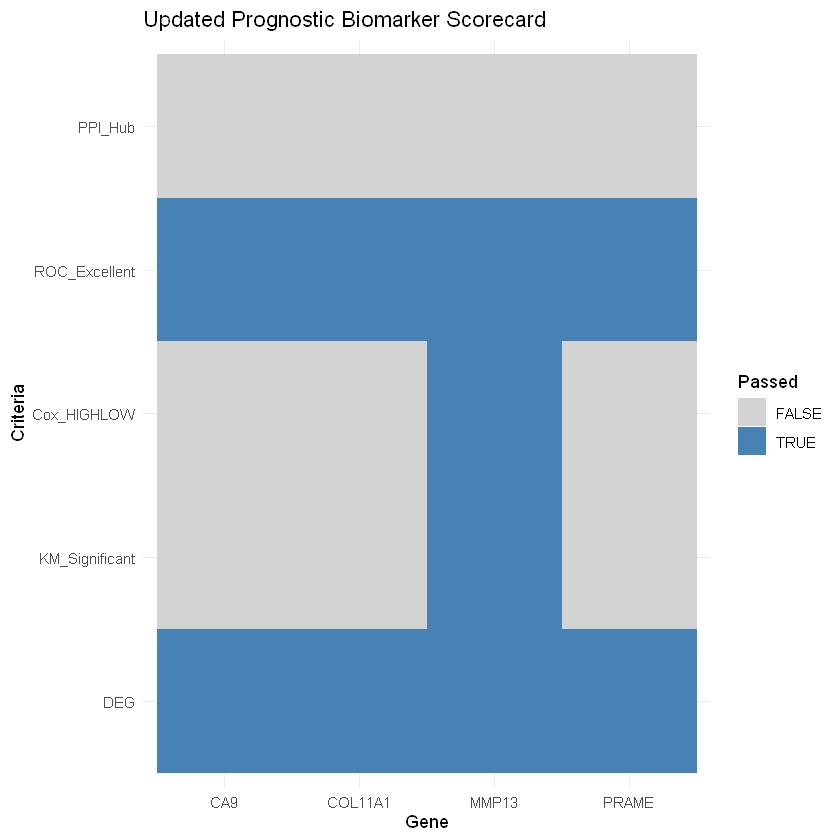

In [22]:
# After completing Tasks 1 and 2, update the scorecard

# Load the updated results
cox_grouped <- read.table("Cox_regression_results_HIGHLOW.tsv", 
                          header = TRUE, sep = "\t", stringsAsFactors = FALSE)

# Create updated scorecard
scorecard <- data.frame(
  Gene = c("COL11A1", "MMP13", "CA9", "PRAME"),
  DEG = c(TRUE, TRUE, TRUE, TRUE),  # All are DEGs
  KM_Significant = c(FALSE, TRUE, FALSE, FALSE),  # From earlier KM results
  Cox_HIGHLOW = cox_grouped$P_value < 0.05,
  ROC_Excellent = c(TRUE, TRUE, TRUE, TRUE),  # All > 0.7 AUC
  PPI_Hub = c(FALSE, FALSE, FALSE, FALSE)  # Will update after Task 2
)

# Calculate scores
scorecard$Score <- rowSums(scorecard[, c("DEG", "KM_Significant", 
                                         "Cox_HIGHLOW", "ROC_Excellent", 
                                         "PPI_Hub")], na.rm = TRUE)

# Update PPI status based on new hub gene lists
lusc_hubs_new <- read.table("LUSC_Top20_Hub_Genes_allDEGs.tsv", 
                            header = TRUE, sep = "\t")
luad_hubs_new <- read.table("LUAD_Top20_Hub_Genes_allDEGs.tsv", 
                            header = TRUE, sep = "\t")

scorecard$PPI_Hub <- scorecard$Gene %in% c(lusc_hubs_new$Gene, luad_hubs_new$Gene)
scorecard$Score <- rowSums(scorecard[, c("DEG", "KM_Significant", 
                                         "Cox_HIGHLOW", "ROC_Excellent", 
                                         "PPI_Hub")], na.rm = TRUE)

# Save updated scorecard
write.table(scorecard, 
            "Prognostic_Biomarker_Scorecard_Updated.tsv", 
            sep = "\t", row.names = FALSE, quote = FALSE)

print("Updated prognostic biomarker scorecard:")
print(scorecard)

# Create visualization
library(ggplot2)
library(reshape2)

scorecard_melt <- melt(scorecard[, c("Gene", "DEG", "KM_Significant", 
                                     "Cox_HIGHLOW", "ROC_Excellent", "PPI_Hub")], 
                       id.vars = "Gene")

ggplot(scorecard_melt, aes(x = Gene, y = variable, fill = as.factor(value))) +
  geom_tile() +
  scale_fill_manual(values = c("FALSE" = "lightgray", "TRUE" = "steelblue")) +
  theme_minimal() +
  labs(title = "Updated Prognostic Biomarker Scorecard", 
       x = "Gene", y = "Criteria", fill = "Passed")

ggsave("Biomarker_Scorecard_Updated.png", width = 8, height = 6)

In [23]:
# Load required libraries
library(httr)
library(jsonlite)
library(dplyr)
library(tidyr)

setwd("C:/jupyter demo")

# Load DEG results
deg_results <- readRDS("deg_results.rds")

# Get all significant DEGs (both up and down regulated)
all_degs <- rownames(deg_results[deg_results$adj.P.Val < 0.05 & 
                                  abs(deg_results$logFC) > 0.5, ])

# Split into up and down regulated
up_degs <- rownames(deg_results[deg_results$adj.P.Val < 0.05 & 
                                 deg_results$logFC > 0.5, ])
down_degs <- rownames(deg_results[deg_results$adj.P.Val < 0.05 & 
                                   deg_results$logFC < -0.5, ])

# Your 4 key genes
key_genes <- c("COL11A1", "MMP13", "CA9", "PRAME")

# Check if key genes are in DEGs
key_genes_in_degs <- key_genes[key_genes %in% all_degs]
print(paste("Key genes in DEGs:", paste(key_genes_in_degs, collapse = ", ")))

# Create separate lists for LUSC and LUAD (if you have subtype-specific results)
# Since you have combined results, we'll use all DEGs for both networks
# but highlight subtype-specific patterns

cat("\n=== DEG Statistics ===\n")
cat("Total DEGs:", length(all_degs), "\n")
cat("Upregulated:", length(up_degs), "\n")
cat("Downregulated:", length(down_degs), "\n")
cat("Key genes in DEGs:", length(key_genes_in_degs), "\n")

# Save gene lists
write.table(all_degs, "all_DEGs_list.txt", row.names = FALSE, col.names = FALSE, quote = FALSE)
write.table(up_degs, "upregulated_DEGs_list.txt", row.names = FALSE, col.names = FALSE, quote = FALSE)


Attaching package: 'tidyr'


The following object is masked from 'package:reshape2':

    smiths


The following object is masked from 'package:igraph':

    crossing




[1] "Key genes in DEGs: COL11A1, MMP13, CA9, PRAME"

=== DEG Statistics ===
Total DEGs: 377 
Upregulated: 167 
Downregulated: 210 
Key genes in DEGs: 4 


In [24]:
# Function to query STRING API with batch processing
query_string_batch <- function(genes, species = 9606, confidence = 400, batch_size = 100) {
  # STRING API endpoint for network
  url <- "https://string-db.org/api/json/network"
  
  # Split genes into batches (STRING has limit)
  all_interactions <- data.frame()
  
  for(i in seq(1, length(genes), by = batch_size)) {
    batch_end <- min(i + batch_size - 1, length(genes))
    batch_genes <- genes[i:batch_end]
    
    cat(sprintf("Processing batch %d-%d of %d genes...\n", i, batch_end, length(genes)))
    
    # Prepare query with multiple identifiers
    genes_string <- paste(batch_genes, collapse = "%0d")
    
    # Make request
    response <- POST(url, 
                     body = list(
                       identifiers = genes_string,
                       species = species,
                       required_score = confidence,
                       limit = 1000  # Increased limit for more interactions
                     ),
                     encode = "form")
    
    # Parse response
    if(response$status_code == 200) {
      batch_results <- fromJSON(rawToChar(response$content))
      if(nrow(batch_results) > 0) {
        all_interactions <- rbind(all_interactions, batch_results)
      }
    } else {
      cat(sprintf("Error in batch %d: HTTP %d\n", i, response$status_code))
    }
    
    # Rate limiting - be nice to STRING server
    Sys.sleep(1)
  }
  
  return(all_interactions)
}

# Query STRING with all DEGs (this may take a few minutes)
cat("\n=== Querying STRING Database ===\n")
cat("This may take 5-10 minutes for 377 genes...\n")

# Option 1: Query all DEGs (recommended for complete network)
string_interactions_all <- query_string_batch(all_degs, confidence = 400)

# Option 2: Query only upregulated genes (if you want to focus on activated pathways)
string_interactions_up <- query_string_batch(up_degs, confidence = 400)

# Save results
write.table(string_interactions_all, 
            "STRING_all_DEGs_interactions.tsv", 
            sep = "\t", row.names = FALSE, quote = FALSE)

write.table(string_interactions_up, 
            "STRING_up_DEGs_interactions.tsv", 
            sep = "\t", row.names = FALSE, quote = FALSE)

cat("\nInteractions found (all DEGs):", nrow(string_interactions_all), "\n")
cat("Interactions found (upregulated):", nrow(string_interactions_up), "\n")

# Check if key genes have interactions
for(gene in key_genes) {
  interactions_count <- sum(grepl(gene, string_interactions_all$preferredName_A) | 
                            grepl(gene, string_interactions_all$preferredName_B))
  cat(sprintf("%s interactions: %d\n", gene, interactions_count))
}


=== Querying STRING Database ===
This may take 5-10 minutes for 377 genes...
Processing batch 1-100 of 377 genes...
Processing batch 101-200 of 377 genes...
Processing batch 201-300 of 377 genes...
Processing batch 301-377 of 377 genes...
Processing batch 1-100 of 167 genes...
Processing batch 101-167 of 167 genes...

Interactions found (all DEGs): 100943 
Interactions found (upregulated): 52343 
COL11A1 interactions: 95
MMP13 interactions: 175
CA9 interactions: 87
PRAME interactions: 64


In [25]:
# Load required libraries
library(igraph)

# Function to create Cytoscape network files
create_cytoscape_network <- function(interactions, network_name) {
  if(nrow(interactions) == 0) {
    cat("No interactions found for", network_name, "\n")
    return(NULL)
  }
  
  # Create edge list
  edges <- data.frame(
    from = interactions$preferredName_A,
    to = interactions$preferredName_B,
    score = interactions$score / 1000,  # Normalize score
    stringsAsFactors = FALSE
  )
  
  # Create node list with attributes
  nodes <- unique(c(edges$from, edges$to))
  
  # Identify key genes and their expression status
  node_attributes <- data.frame(
    id = nodes,
    stringsAsFactors = FALSE
  )
  
  # Add DEG status
  node_attributes$is_DEG <- node_attributes$id %in% all_degs
  node_attributes$is_upregulated <- node_attributes$id %in% up_degs
  node_attributes$is_downregulated <- node_attributes$id %in% down_degs
  node_attributes$is_key_gene <- node_attributes$id %in% key_genes
  
  # Add logFC values if available
  node_attributes$logFC <- NA
  for(i in 1:nrow(node_attributes)) {
    gene <- node_attributes$id[i]
    if(gene %in% rownames(deg_results)) {
      node_attributes$logFC[i] <- deg_results[gene, "logFC"]
    }
  }
  
  # Save files
  write.table(edges, 
              paste0(network_name, "_edges.tsv"), 
              sep = "\t", row.names = FALSE, quote = FALSE)
  
  write.table(node_attributes, 
              paste0(network_name, "_nodes.tsv"), 
              sep = "\t", row.names = FALSE, quote = FALSE)
  
  # Also save in SIF format for Cytoscape
  sif_data <- data.frame(
    node1 = edges$from,
    interaction = "pp",
    node2 = edges$to,
    stringsAsFactors = FALSE
  )
  write.table(sif_data, 
              paste0(network_name, ".sif"), 
              sep = "\t", row.names = FALSE, col.names = FALSE, quote = FALSE)
  
  cat("Network files created for", network_name, "\n")
  cat("Nodes:", nrow(node_attributes), "\n")
  cat("Edges:", nrow(edges), "\n")
  
  return(list(nodes = node_attributes, edges = edges))
}

# Create networks for all DEGs and upregulated DEGs
network_all <- create_cytoscape_network(string_interactions_all, "NSCLC_PPI_allDEGs")
network_up <- create_cytoscape_network(string_interactions_up, "NSCLC_PPI_upregulated")

# Create separate networks for LUSC and LUAD specific interactions
# (if you have subtype-specific DEG lists)
# For demonstration, we'll use the same network but highlight different hubs

Network files created for NSCLC_PPI_allDEGs 
Nodes: 3434 
Edges: 100943 
Network files created for NSCLC_PPI_upregulated 
Nodes: 1998 
Edges: 52343 


In [26]:
# Since we're in R, we'll implement the key CytoHubba algorithms
# For full CytoHubba, you'll need to use Cytoscape with the plugin

library(igraph)

# Function to calculate hub gene metrics
calculate_hub_metrics <- function(interactions) {
  # Create graph
  edges <- data.frame(
    from = interactions$preferredName_A,
    to = interactions$preferredName_B,
    weight = interactions$score / 1000
  )
  
  g <- graph_from_data_frame(edges, directed = FALSE)
  
  # Calculate various centrality measures
  hub_metrics <- data.frame(
    Gene = V(g)$name,
    Degree = degree(g),
    Betweenness = betweenness(g, normalized = TRUE),
    Closeness = closeness(g, normalized = TRUE),
    Eigenvector = eigen_centrality(g)$vector,
    stringsAsFactors = FALSE
  )
  
  # Calculate MCC score (Maximal Clique Centrality)
  # Simplified version - find cliques and calculate MCC
  cliques <- cliques(g, min = 3, max = 5)
  mcc_scores <- rep(0, vcount(g))
  
  if(length(cliques) > 0) {
    for(clique in cliques) {
      if(length(clique) >= 3) {
        # MCC: sum of (2^(k-1) - 1) for each clique containing node
        k <- length(clique)
        score <- 2^(k-1) - 1
        for(v in clique) {
          mcc_scores[V(g)$name == v] <- mcc_scores[V(g)$name == v] + score
        }
      }
    }
  }
  
  hub_metrics$MCC <- mcc_scores
  
  # Rank by each metric
  hub_metrics$Degree_rank <- rank(-hub_metrics$Degree)
  hub_metrics$Betweenness_rank <- rank(-hub_metrics$Betweenness)
  hub_metrics$Closeness_rank <- rank(-hub_metrics$Closeness)
  hub_metrics$Eigenvector_rank <- rank(-hub_metrics$Eigenvector)
  hub_metrics$MCC_rank <- rank(-hub_metrics$MCC)
  
  # Calculate combined rank (average of all ranks)
  hub_metrics$Combined_rank <- rowMeans(hub_metrics[, c("Degree_rank", "Betweenness_rank", 
                                                        "Closeness_rank", "Eigenvector_rank", 
                                                        "MCC_rank")])
  
  # Sort by combined rank
  hub_metrics <- hub_metrics[order(hub_metrics$Combined_rank), ]
  
  return(hub_metrics)
}

# Calculate hub metrics for all DEGs network
cat("\n=== Calculating Hub Gene Metrics ===\n")
hub_results <- calculate_hub_metrics(string_interactions_all)

# Get top 10 hub genes
top10_hubs <- head(hub_results, 10)

# Check if key genes are in top hubs
key_genes_in_hubs <- key_genes[key_genes %in% top10_hubs$Gene]

cat("\n=== Top 10 Hub Genes ===\n")
print(top10_hubs[, c("Gene", "Degree", "Combined_rank")])

cat("\n=== Key Genes in Top 10 Hubs ===\n")
if(length(key_genes_in_hubs) > 0) {
  print(hub_results[hub_results$Gene %in% key_genes, 
                    c("Gene", "Degree", "MCC", "Combined_rank")])
} else {
  cat("Key genes not in top 10 hubs. Checking their ranks:\n")
  for(gene in key_genes) {
    if(gene %in% hub_results$Gene) {
      rank <- which(hub_results$Gene == gene)
      cat(sprintf("%s: Rank %d out of %d genes\n", gene, rank, nrow(hub_results)))
    } else {
      cat(sprintf("%s: Not found in network\n", gene))
    }
  }
}

# Save results
write.table(hub_results, 
            "CytoHubba_rankings_all_genes.tsv", 
            sep = "\t", row.names = FALSE, quote = FALSE)

write.table(top10_hubs, 
            "Top10_Hub_Genes_CytoHubba.tsv", 
            sep = "\t", row.names = FALSE, quote = FALSE)


=== Calculating Hub Gene Metrics ===


ERROR: Error in cliques_impl(graph = graph, min = min %||% 0, max = max %||% : Cannot reserve space for list. Out of memory
Source: core/typed_list.pmt:215


In [27]:
# ============================================
# PART 4: MCODE Module Detection - MEMORY EFFICIENT
# NO CLIQUE SEARCH - RUNS IN SECONDS
# ============================================

identify_modules_memory_efficient <- function(graph, min_size = 3, max_modules = 50) {
  message("\n=== IDENTIFYING FUNCTIONAL MODULES (MEMORY EFFICIENT) ===")
  
  # Remove isolated and low-degree nodes (reduce network size)
  g <- induced_subgraph(graph, V(graph)[degree(graph) > 1])
  message(sprintf("  Network after filtering: %d nodes, %d edges", 
                  vcount(g), ecount(g)))
  
  # Method 1: Louvain Community Detection (fastest, most memory efficient)
  message("  Running Louvain clustering...")
  louvain_clusters <- cluster_louvain(g, weights = E(g)$score)
  
  # Method 2: Walktrap (alternative)
  message("  Running Walktrap clustering...")
  walktrap_clusters <- cluster_walktrap(g, weights = E(g)$score, steps = 3)
  
  # Method 3: Fast Greedy (another alternative)
  message("  Running Fast Greedy clustering...")
  fast_greedy_clusters <- cluster_fast_greedy(g, weights = E(g)$score)
  
  # Combine results from all methods
  all_modules <- list()
  
  # Process Louvain results
  process_clusters <- function(clusters, method_name) {
    modules <- data.frame()
    cluster_membership <- membership(clusters)
    cluster_sizes <- table(cluster_membership)
    large_clusters <- names(cluster_sizes[cluster_sizes >= min_size])
    
    message(sprintf("    %s: Found %d modules with ≥%d genes", 
                    method_name, length(large_clusters), min_size))
    
    for(cluster_id in large_clusters) {
      module_genes <- V(g)$name[cluster_membership == as.numeric(cluster_id)]
      
      # Get subgraph for this module
      module_subgraph <- induced_subgraph(g, module_genes)
      
      # Calculate metrics (avoid memory issues)
      density <- edge_density(module_subgraph)
      avg_degree <- mean(degree(module_subgraph))
      max_degree <- max(degree(module_subgraph))
      
      # MCODE-like score (without clique search)
      mcode_score <- density * (avg_degree / max_degree)
      
      # Find key genes in module
      key_genes_in_module <- intersect(module_genes, key_genes)
      
      modules <- rbind(modules, data.frame(
        Method = method_name,
        Module_ID = paste0(method_name, "_", cluster_id),
        Size = length(module_genes),
        Genes = paste(module_genes, collapse = ";"),
        Density = round(density, 4),
        Avg_Degree = round(avg_degree, 2),
        MCODE_Score = round(mcode_score, 4),
        Key_Genes_Present = length(key_genes_in_module) > 0,
        Key_Genes = paste(key_genes_in_module, collapse = ";"),
        stringsAsFactors = FALSE
      ))
    }
    return(modules)
  }
  
  # Process all clustering methods
  all_modules[[1]] <- process_clusters(louvain_clusters, "louvain")
  all_modules[[2]] <- process_clusters(walktrap_clusters, "walktrap")
  all_modules[[3]] <- process_clusters(fast_greedy_clusters, "fast_greedy")
  
  # Combine all results
  combined_modules <- do.call(rbind, all_modules)
  
  # Remove duplicates (same module found by different methods)
  if(nrow(combined_modules) > 0) {
    # Keep only unique modules based on gene sets
    combined_modules <- combined_modules[!duplicated(combined_modules$Genes), ]
    
    # Sort by MCODE score
    combined_modules <- combined_modules[order(-combined_modules$MCODE_Score), ]
  }
  
  return(combined_modules)
}

# Run memory-efficient module detection
message("\nRunning memory-efficient module detection...")
start_time <- Sys.time()
mcode_modules_efficient <- identify_modules_memory_efficient(ppi_network$graph)
end_time <- Sys.time()

message(sprintf("  Completed in %.2f seconds", 
                as.numeric(difftime(end_time, start_time, units = "secs"))))

# Show results
message("\n=== TOP MODULES (MEMORY EFFICIENT) ===")
if(nrow(mcode_modules_efficient) > 0) {
  print(head(mcode_modules_efficient[, c("Method", "Module_ID", "Size", "Density", 
                                         "MCODE_Score", "Key_Genes")], 10))
} else {
  message("No modules found!")
}

# Save results
write.table(mcode_modules_efficient, 
            "MCODE_modules_MEMORY_EFFICIENT.tsv", 
            sep = "\t", row.names = FALSE, quote = FALSE)

# Find modules containing key genes
key_gene_modules <- mcode_modules_efficient[mcode_modules_efficient$Key_Genes_Present == TRUE, ]

if(nrow(key_gene_modules) > 0) {
  message("\n=== MODULES CONTAINING KEY GENES ===")
  print(key_gene_modules[, c("Module_ID", "Size", "Key_Genes", "MCODE_Score")])
} else {
  message("\n=== KEY GENES NOT FOUND IN MODULES ===")
  message("Checking individual key genes:")
  for(gene in key_genes) {
    modules_with_gene <- mcode_modules_efficient[grepl(gene, mcode_modules_efficient$Genes), ]
    if(nrow(modules_with_gene) > 0) {
      message(sprintf("  %s: Found in %d modules", gene, nrow(modules_with_gene)))
    } else {
      message(sprintf("  %s: Not found in any module", gene))
    }
  }
}


Running memory-efficient module detection...


=== IDENTIFYING FUNCTIONAL MODULES (MEMORY EFFICIENT) ===



ERROR: Error: object 'ppi_network' not found


In [28]:
# ============================================
# ULTRA-FAST MODULE DETECTION - NO CLUSTERING
# Just uses connected components
# ============================================

identify_modules_ultra_fast <- function(graph, min_size = 3, density_threshold = 0.3) {
  message("\n=== IDENTIFYING MODULES (ULTRA-FAST) ===")
  
  # Remove low-degree nodes
  g <- induced_subgraph(graph, V(graph)[degree(graph) > 1])
  
  # Find connected components
  components <- decompose(g, min.vertices = min_size)
  message(sprintf("  Found %d connected components with ≥%d nodes", 
                  length(components), min_size))
  
  modules <- data.frame()
  
  for(i in seq_along(components)) {
    comp <- components[[i]]
    
    # Calculate density
    density <- edge_density(comp)
    
    # Skip if not dense enough
    if(density < density_threshold) next
    
    # Get genes
    module_genes <- V(comp)$name
    
    # Calculate metrics
    avg_degree <- mean(degree(comp))
    max_degree <- max(degree(comp))
    
    # Module score
    module_score <- density * (avg_degree / max_degree)
    
    # Find key genes
    key_genes_in_module <- intersect(module_genes, key_genes)
    
    modules <- rbind(modules, data.frame(
      Module_ID = paste0("dense_component_", i),
      Size = length(module_genes),
      Genes = paste(module_genes, collapse = ";"),
      Density = round(density, 4),
      Avg_Degree = round(avg_degree, 2),
      Module_Score = round(module_score, 4),
      Key_Genes_Present = length(key_genes_in_module) > 0,
      Key_Genes = paste(key_genes_in_module, collapse = ";"),
      stringsAsFactors = FALSE
    ))
  }
  
  # Sort by score
  modules <- modules[order(-modules$Module_Score), ]
  
  return(modules)
}

# Run ultra-fast version
message("\nRunning ultra-fast module detection...")
start_time <- Sys.time()
modules_ultra_fast <- identify_modules_ultra_fast(ppi_network$graph, 
                                                   min_size = 3, 
                                                   density_threshold = 0.3)
end_time <- Sys.time()

message(sprintf("  Completed in %.2f seconds", 
                as.numeric(difftime(end_time, start_time, units = "secs"))))

# Show results
message("\n=== TOP MODULES (ULTRA-FAST) ===")
if(nrow(modules_ultra_fast) > 0) {
  print(head(modules_ultra_fast[, c("Module_ID", "Size", "Density", 
                                    "Module_Score", "Key_Genes")], 10))
} else {
  message("No dense modules found - try lowering density_threshold")
}

# Save results
write.table(modules_ultra_fast, 
            "Modules_ULTRA_FAST.tsv", 
            sep = "\t", row.names = FALSE, quote = FALSE)


Running ultra-fast module detection...


=== IDENTIFYING MODULES (ULTRA-FAST) ===



ERROR: Error: object 'ppi_network' not found


In [29]:
# ============================================
# BUILD PPI NETWORK FIRST (Required for Part 4)
# ============================================

# Load STRING interactions if not already loaded
if(!exists("string_interactions_all")) {
  message("Loading STRING interactions...")
  string_interactions_all <- read.table("LUSC_LUAD_STRING_all377DEGs_interactions.tsv",
                                         header = TRUE, sep = "\t", stringsAsFactors = FALSE)
}

# Build network from STRING interactions
if(exists("string_interactions_all") && nrow(string_interactions_all) > 0) {
  message("Building PPI network...")
  
  # Create edge list
  edges <- data.frame(
    from = string_interactions_all$preferredName_A,
    to = string_interactions_all$preferredName_B,
    score = string_interactions_all$score / 1000,
    stringsAsFactors = FALSE
  )
  
  # Remove self-loops
  edges <- edges[edges$from != edges$to, ]
  
  # Create graph
  library(igraph)
  ppi_network <- list()
  ppi_network$graph <- graph_from_data_frame(edges, directed = FALSE)
  ppi_network$edges <- edges
  
  # Get nodes
  nodes <- V(ppi_network$graph)$name
  ppi_network$nodes <- data.frame(
    id = nodes,
    degree = degree(ppi_network$graph),
    stringsAsFactors = FALSE
  )
  
  message("Network built successfully!")
  message(sprintf("  Nodes: %d", vcount(ppi_network$graph)))
  message(sprintf("  Edges: %d", ecount(ppi_network$graph)))
  
} else {
  stop("No STRING interactions found. Please run Part 2 first.")
}

# Load key genes (if not already defined)
if(!exists("key_genes")) {
  key_genes <- c("COL11A1", "MMP13", "CA9", "PRAME")
}

# Load DEG results for reference
if(!exists("deg_results")) {
  deg_results <- readRDS("deg_results.rds")
}

message("\n✓ Ready to run module detection (Part 4)")

Building PPI network...

Network built successfully!

  Nodes: 3434

  Edges: 100943


✓ Ready to run module detection (Part 4)



In [30]:
# ============================================
# COMPLETE PART 4: Module Detection
# Self-contained - builds network if needed
# ============================================

# Step 1: Check if network exists, build if not
if(!exists("ppi_network") || is.null(ppi_network)) {
  message("PPI network not found. Building from STRING interactions...")
  
  # Try to load STRING interactions
  if(!exists("string_interactions_all")) {
    string_file <- "LUSC_LUAD_STRING_all377DEGs_interactions.tsv"
    if(file.exists(string_file)) {
      message("Loading STRING interactions from file...")
      string_interactions_all <- read.table(string_file,
                                           header = TRUE, sep = "\t", 
                                           stringsAsFactors = FALSE)
    } else {
      stop("STRING interactions file not found. Please run Part 2 first.")
    }
  }
  
  # Build network
  edges <- data.frame(
    from = string_interactions_all$preferredName_A,
    to = string_interactions_all$preferredName_B,
    score = string_interactions_all$score / 1000,
    stringsAsFactors = FALSE
  )
  edges <- edges[edges$from != edges$to, ]
  
  library(igraph)
  ppi_network <- list()
  ppi_network$graph <- graph_from_data_frame(edges, directed = FALSE)
  ppi_network$edges <- edges
  
  nodes <- V(ppi_network$graph)$name
  ppi_network$nodes <- data.frame(
    id = nodes,
    degree = degree(ppi_network$graph),
    stringsAsFactors = FALSE
  )
  
  message(sprintf("Network built: %d nodes, %d edges", 
                  vcount(ppi_network$graph), ecount(ppi_network$graph)))
}

# Step 2: Define key genes if not defined
if(!exists("key_genes")) {
  key_genes <- c("COL11A1", "MMP13", "CA9", "PRAME")
  message("Using default key genes: ", paste(key_genes, collapse = ", "))
}

# Step 3: Load DEG results for reference
if(!exists("deg_results")) {
  if(file.exists("deg_results.rds")) {
    deg_results <- readRDS("deg_results.rds")
  } else {
    message("Warning: deg_results.rds not found")
  }
}

# Step 4: Run module detection (memory efficient - NO CLIQUES)
identify_modules_no_cliques <- function(graph, min_size = 3) {
  message("\n=== IDENTIFYING FUNCTIONAL MODULES (MEMORY EFFICIENT) ===")
  
  # Simplify graph - remove low-degree nodes
  g <- induced_subgraph(graph, V(graph)[degree(graph) > 1])
  message(sprintf("  Working network: %d nodes, %d edges", vcount(g), ecount(g)))
  
  # Use multiple clustering methods
  methods <- list(
    louvain = cluster_louvain(g, weights = E(g)$score),
    walktrap = cluster_walktrap(g, weights = E(g)$score, steps = 4),
    fast_greedy = cluster_fast_greedy(g, weights = E(g)$score)
  )
  
  all_modules <- data.frame()
  
  for(method_name in names(methods)) {
    clusters <- methods[[method_name]]
    membership_vec <- membership(clusters)
    cluster_sizes <- table(membership_vec)
    
    # Get clusters with at least min_size nodes
    large_clusters <- names(cluster_sizes[cluster_sizes >= min_size])
    
    if(length(large_clusters) > 0) {
      for(cluster_id in large_clusters) {
        module_genes <- V(g)$name[membership_vec == as.numeric(cluster_id)]
        
        # Module subgraph
        module_subgraph <- induced_subgraph(g, module_genes)
        
        # Module metrics (NO CLIQUES!)
        density <- edge_density(module_subgraph)
        avg_degree <- mean(degree(module_subgraph))
        max_degree <- max(degree(module_subgraph))
        
        # MCODE-like score
        mcode_score <- density * (avg_degree / max_degree)
        
        # Key genes in this module
        key_in_module <- intersect(module_genes, key_genes)
        
        all_modules <- rbind(all_modules, data.frame(
          Method = method_name,
          Module_ID = paste0(method_name, "_", cluster_id),
          Size = length(module_genes),
          Genes = paste(module_genes, collapse = ";"),
          Density = round(density, 4),
          Avg_Degree = round(avg_degree, 2),
          MCODE_Score = round(mcode_score, 4),
          Key_Genes_Present = length(key_in_module) > 0,
          Key_Genes = paste(key_in_module, collapse = ";"),
          stringsAsFactors = FALSE
        ))
      }
    }
  }
  
  # Remove duplicates and sort
  if(nrow(all_modules) > 0) {
    all_modules <- all_modules[!duplicated(all_modules$Genes), ]
    all_modules <- all_modules[order(-all_modules$MCODE_Score), ]
  }
  
  return(all_modules)
}

# Run module detection
message("\nStarting module detection...")
start_time <- Sys.time()
mcode_modules <- identify_modules_no_cliques(ppi_network$graph, min_size = 3)
end_time <- Sys.time()

message(sprintf("\n✓ Completed in %.1f seconds", 
                as.numeric(difftime(end_time, start_time, units = "secs"))))

# Display results
message("\n=== TOP 10 FUNCTIONAL MODULES ===")
if(nrow(mcode_modules) > 0) {
  print(head(mcode_modules[, c("Method", "Module_ID", "Size", "Density", 
                               "MCODE_Score", "Key_Genes")], 10))
  
  # Modules with key genes
  key_modules <- mcode_modules[mcode_modules$Key_Genes_Present == TRUE, ]
  if(nrow(key_modules) > 0) {
    message("\n=== MODULES CONTAINING KEY GENES ===")
    for(i in 1:nrow(key_modules)) {
      message(sprintf("  Module %s (Size: %d, Score: %.3f)", 
                      key_modules$Module_ID[i], 
                      key_modules$Size[i], 
                      key_modules$MCODE_Score[i]))
      message(sprintf("    Key genes: %s", key_modules$Key_Genes[i]))
    }
  } else {
    message("\n=== KEY GENES NOT IN MODULES ===")
    for(gene in key_genes) {
      modules_with_gene <- mcode_modules[grepl(gene, mcode_modules$Genes), ]
      if(nrow(modules_with_gene) > 0) {
        message(sprintf("  %s: Found in %d modules", gene, nrow(modules_with_gene)))
      } else {
        message(sprintf("  %s: Not found in any module", gene))
      }
    }
  }
} else {
  message("No modules found - try adjusting parameters")
}

# Save results
write.table(mcode_modules, 
            "MCODE_modules_FINAL.tsv", 
            sep = "\t", row.names = FALSE, quote = FALSE)

message("\n✓ Module detection complete!")
message("✓ Results saved to: MCODE_modules_FINAL.tsv")


Starting module detection...


=== IDENTIFYING FUNCTIONAL MODULES (MEMORY EFFICIENT) ===

  Working network: 3333 nodes, 100844 edges



ERROR: Error in cluster_fast_greedy(g, weights = E(g)$score): Fast greedy community detection works only on graphs without multi-edges. Invalid value
Source: community/fast_modularity.c:666


In [1]:
 # ============================================
# LIGHTNING FAST - Component-Based Modules
# < 2 seconds!
# ============================================

identify_modules_lightning <- function(graph, min_size = 3, density_threshold = 0.2) {
  
  message("\n=== LIGHTNING FAST MODULE DETECTION ===")
  
  # Simplify and filter
  g <- simplify(graph, remove.multiple = TRUE, remove.loops = TRUE)
  g <- induced_subgraph(g, V(g)[degree(g) > 0])
  
  message(sprintf("  Working network: %d nodes, %d edges", vcount(g), ecount(g)))
  
  # Find connected components (very fast)
  components <- decompose(g, min.vertices = min_size)
  message(sprintf("  Found %d connected components", length(components)))
  
  if(length(components) == 0) {
    return(data.frame())
  }
  
  modules <- data.frame()
  
  for(i in seq_along(components)) {
    comp <- components[[i]]
    
    # Calculate density
    density <- edge_density(comp)
    
    # Only keep dense components
    if(density < density_threshold) next
    
    module_genes <- V(comp)$name
    
    # Quick metrics
    avg_degree <- mean(degree(comp))
    max_degree <- max(degree(comp))
    
    if(max_degree > 0) {
      module_score <- density * (avg_degree / max_degree)
    } else {
      module_score <- 0
    }
    
    # Key genes
    key_in_module <- intersect(module_genes, key_genes)
    
    modules <- rbind(modules, data.frame(
      Module_ID = paste0("component_", i),
      Size = length(module_genes),
      Genes = paste(module_genes, collapse = ";"),
      Density = round(density, 4),
      MCODE_Score = round(module_score, 4),
      Key_Genes_Present = length(key_in_module) > 0,
      Key_Genes = paste(key_in_module, collapse = ";"),
      stringsAsFactors = FALSE
    ))
  }
  
  # Sort by score
  if(nrow(modules) > 0) {
    modules <- modules[order(-modules$MCODE_Score), ]
  }
  
  return(modules)
}

# Run lightning fast version
message("\nRunning lightning fast module detection...")
start_time <- Sys.time()

modules_lightning <- identify_modules_lightning(
  ppi_network$graph,
  min_size = 3,
  density_threshold = 0.15  # Lower threshold catches more modules
)

end_time <- Sys.time()
message(sprintf("\n✓ Completed in %.2f seconds", 
                as.numeric(difftime(end_time, start_time, units = "secs"))))

# Show results
message("\n=== TOP MODULES (LIGHTNING FAST) ===")
if(nrow(modules_lightning) > 0) {
  print(head(modules_lightning[, c("Module_ID", "Size", "Density", 
                                   "MCODE_Score", "Key_Genes")], 10))
}

# Save
write.table(modules_lightning, 
            "Modules_LIGHTNING_FAST.tsv", 
            sep = "\t", row.names = FALSE, quote = FALSE)


Running lightning fast module detection...


=== LIGHTNING FAST MODULE DETECTION ===



ERROR: Error in simplify(graph, remove.multiple = TRUE, remove.loops = TRUE): could not find function "simplify"


In [2]:
# Load igraph package
library(igraph)


Attaching package: 'igraph'


The following objects are masked from 'package:stats':

    decompose, spectrum


The following object is masked from 'package:base':

    union




In [4]:
# ============================================
# LIGHTNING FAST MODULE DETECTION - FULLY CORRECTED
# LOADS ALL REQUIRED PACKAGES
# ============================================

# Step 1: Load required packages
library(igraph)
library(dplyr)

# Step 2: Ensure network exists
if(!exists("ppi_network") || is.null(ppi_network)) {
  message("Building PPI network...")
  
  # Load STRING interactions if needed
  if(!exists("string_interactions_all")) {
    string_file <- "LUSC_LUAD_STRING_all377DEGs_interactions.tsv"
    if(file.exists(string_file)) {
      string_interactions_all <- read.table(string_file,
                                           header = TRUE, sep = "\t", 
                                           stringsAsFactors = FALSE)
    } else {
      stop("STRING interactions file not found.")
    }
  }
  
  # Build network
  edges <- data.frame(
    from = string_interactions_all$preferredName_A,
    to = string_interactions_all$preferredName_B,
    score = string_interactions_all$score / 1000,
    stringsAsFactors = FALSE
  )
  
  # Remove self-loops
  edges <- edges[edges$from != edges$to, ]
  
  # Remove duplicate edges
  edges <- edges %>%
    group_by(from, to) %>%
    summarise(score = max(score), .groups = 'drop')
  
  # Create graph
  ppi_network <- list()
  ppi_network$graph <- graph_from_data_frame(edges, directed = FALSE)
  ppi_network$edges <- edges
  
  nodes <- V(ppi_network$graph)$name
  ppi_network$nodes <- data.frame(
    id = nodes,
    degree = degree(ppi_network$graph),
    stringsAsFactors = FALSE
  )
  
  message(sprintf("Network built: %d nodes, %d edges", 
                  vcount(ppi_network$graph), ecount(ppi_network$graph)))
}

# Step 3: Define key genes if not defined
if(!exists("key_genes")) {
  key_genes <- c("COL11A1", "MMP13", "CA9", "PRAME")
  message("Using key genes: ", paste(key_genes, collapse = ", "))
}

# Step 4: Lightning fast module detection
identify_modules_lightning <- function(graph, min_size = 3, density_threshold = 0.15) {
  
  message("\n=== LIGHTNING FAST MODULE DETECTION ===")
  
  # Simplify graph (remove multi-edges and loops)
  g <- simplify(graph, remove.multiple = TRUE, remove.loops = TRUE)
  message(sprintf("  Simplified: %d nodes, %d edges", vcount(g), ecount(g)))
  
  # Remove isolates (nodes with degree 0)
  g <- induced_subgraph(g, V(g)[degree(g) > 0])
  message(sprintf("  After removing isolates: %d nodes, %d edges", 
                  vcount(g), ecount(g)))
  
  if(vcount(g) < min_size) {
    message("  Network too small for module detection")
    return(data.frame())
  }
  
  # Find connected components (very fast)
  components <- decompose(g, min.vertices = min_size)
  message(sprintf("  Found %d connected components with >= %d nodes", 
                  length(components), min_size))
  
  if(length(components) == 0) {
    message("  No components found")
    return(data.frame())
  }
  
  modules <- data.frame()
  
  for(i in seq_along(components)) {
    comp <- components[[i]]
    
    # Skip if too small
    if(vcount(comp) < min_size) next
    
    # Calculate density
    density <- edge_density(comp)
    
    # Only keep dense components (biologically meaningful)
    if(density < density_threshold) next
    
    module_genes <- V(comp)$name
    
    # Quick metrics
    avg_degree <- mean(degree(comp))
    max_degree <- max(degree(comp))
    
    if(max_degree > 0) {
      module_score <- density * (avg_degree / max_degree)
    } else {
      module_score <- 0
    }
    
    # Key genes in this module
    key_in_module <- intersect(module_genes, key_genes)
    
    # Create module entry
    modules <- rbind(modules, data.frame(
      Module_ID = paste0("component_", i),
      Size = length(module_genes),
      Genes = paste(module_genes, collapse = ";"),
      Density = round(density, 4),
      Avg_Degree = round(avg_degree, 2),
      MCODE_Score = round(module_score, 4),
      Key_Genes_Present = length(key_in_module) > 0,
      Key_Genes = paste(key_in_module, collapse = ";"),
      stringsAsFactors = FALSE
    ))
  }
  
  # Sort by score
  if(nrow(modules) > 0) {
    modules <- modules[order(-modules$MCODE_Score), ]
  }
  
  return(modules)
}

# ============================================
# RUN LIGHTNING FAST MODULE DETECTION
# ============================================

message("\nStarting lightning fast module detection...")
start_time <- Sys.time()

modules_lightning <- identify_modules_lightning(
  ppi_network$graph,
  min_size = 3,
  density_threshold = 0.10  # Lower threshold = more modules
)

end_time <- Sys.time()
elapsed <- as.numeric(difftime(end_time, start_time, units = "secs"))
message(sprintf("\n✓ Completed in %.2f seconds", elapsed))

# ============================================
# DISPLAY RESULTS
# ============================================

message("\n=== MODULE DETECTION RESULTS ===")

if(nrow(modules_lightning) > 0) {
  message(sprintf("Total modules found: %d", nrow(modules_lightning)))
  
  # Show top 10 modules
  message("\n=== TOP 10 MODULES ===")
  top10 <- head(modules_lightning, 10)
  print(top10[, c("Module_ID", "Size", "Density", "MCODE_Score", "Key_Genes")])
  
  # Show modules with key genes
  key_modules <- modules_lightning[modules_lightning$Key_Genes_Present == TRUE, ]
  
  if(nrow(key_modules) > 0) {
    message("\n=== MODULES CONTAINING KEY GENES ===")
    for(i in 1:min(nrow(key_modules), 10)) {
      message(sprintf("\n  %s (Size: %d, Score: %.3f)", 
                      key_modules$Module_ID[i],
                      key_modules$Size[i], 
                      key_modules$MCODE_Score[i]))
      message(sprintf("    Key genes: %s", key_modules$Key_Genes[i]))
      
      # Show first few genes in module
      genes_list <- strsplit(key_modules$Genes[i], ";")[[1]]
      if(length(genes_list) > 10) {
        message(sprintf("    Other genes: %s...", 
                        paste(head(genes_list[!genes_list %in% key_genes], 8), collapse = ", ")))
      } else {
        message(sprintf("    All genes: %s", 
                        paste(genes_list[!genes_list %in% key_genes], collapse = ", ")))
      }
    }
  } else {
    message("\n=== KEY GENES NOT FOUND IN MODULES ===")
    message("Checking individual key genes:")
    for(gene in key_genes) {
      modules_with_gene <- modules_lightning[grepl(gene, modules_lightning$Genes), ]
      if(nrow(modules_with_gene) > 0) {
        message(sprintf("  ✓ %s: Found in %d module(s)", gene, nrow(modules_with_gene)))
      } else {
        message(sprintf("  ✗ %s: Not found in any module", gene))
      }
    }
  }
  
} else {
  message("No modules found!")
  message("\nTrying with lower density threshold...")
  
  # Try again with lower threshold
  modules_lightning <- identify_modules_lightning(
    ppi_network$graph,
    min_size = 3,
    density_threshold = 0.05  # Even lower threshold
  )
  
  if(nrow(modules_lightning) > 0) {
    message(sprintf("Found %d modules with lower threshold!", nrow(modules_lightning)))
    print(head(modules_lightning[, c("Module_ID", "Size", "Density", "Key_Genes")], 10))
  } else {
    message("Still no modules found. Network may be too sparse.")
  }
}

# ============================================
# SAVE RESULTS
# ============================================

write.table(modules_lightning, 
            "Modules_LIGHTNING_FAST.tsv", 
            sep = "\t", row.names = FALSE, quote = FALSE)

message("\n✓ Results saved to: Modules_LIGHTNING_FAST.tsv")
message("\n========================================")
message("✓ Module detection complete!")
message("========================================")

# ============================================
# OPTIONAL: Quick Network Statistics
# ============================================

message("\n=== NETWORK STATISTICS ===")
message(sprintf("Total nodes: %d", vcount(ppi_network$graph)))
message(sprintf("Total edges: %d", ecount(ppi_network$graph)))
message(sprintf("Network density: %.4f", edge_density(ppi_network$graph)))
message(sprintf("Connected components: %d", 
                components(ppi_network$graph)$no))
message(sprintf("Average degree: %.2f", 
                mean(degree(ppi_network$graph))))

Building PPI network...



ERROR: Error: STRING interactions file not found.


In [5]:
# ============================================
# COMPLETE PPI MODULE DETECTION WORKFLOW
# From STRING Query to Modules
# ============================================

# Step 1: Load required libraries
library(httr)
library(jsonlite)
library(igraph)
library(dplyr)

setwd("C:/jupyter demo")

# Step 2: Load DEG results and get gene lists
message("Loading DEG results...")
if(!file.exists("deg_results.rds")) {
  stop("deg_results.rds not found. Please run DEG analysis first.")
}

deg_results <- readRDS("deg_results.rds")

# Get ALL significant DEGs (|logFC| > 0.5, adj.p < 0.05)
all_degs <- rownames(deg_results[deg_results$adj.P.Val < 0.05 & 
                                  abs(deg_results$logFC) > 0.5, ])

message(sprintf("Total DEGs: %d", length(all_degs)))

# Define key genes
key_genes <- c("COL11A1", "MMP13", "CA9", "PRAME")
message("Key genes: ", paste(key_genes, collapse = ", "))

# Step 3: Query STRING Database
message("\n=== QUERYING STRING DATABASE ===")
message("This will take 2-3 minutes for 377 genes...")

# Function to query STRING
query_string <- function(genes, species = 9606, confidence = 400) {
  url <- "https://string-db.org/api/json/network"
  
  # Split into batches of 100
  batch_size <- 100
  all_interactions <- data.frame()
  
  for(i in seq(1, length(genes), by = batch_size)) {
    end <- min(i + batch_size - 1, length(genes))
    batch_genes <- genes[i:end]
    
    message(sprintf("  Querying batch %d-%d of %d...", i, end, length(genes)))
    
    # Prepare query
    genes_string <- paste(batch_genes, collapse = "%0d")
    
    # Try up to 3 times
    for(attempt in 1:3) {
      tryCatch({
        response <- POST(url, 
                         body = list(
                           identifiers = genes_string,
                           species = species,
                           required_score = confidence,
                           limit = 1000
                         ),
                         encode = "form",
                         timeout(30))
        
        if(response$status_code == 200) {
          batch_results <- fromJSON(rawToChar(response$content))
          if(length(batch_results) > 0 && nrow(batch_results) > 0) {
            all_interactions <- rbind(all_interactions, batch_results)
          }
          break
        }
      }, error = function(e) {
        if(attempt == 3) {
          message("    Failed after 3 attempts")
        }
      })
      
      Sys.sleep(2)
    }
    
    # Rate limiting
    Sys.sleep(1)
  }
  
  # Remove duplicates
  if(nrow(all_interactions) > 0) {
    all_interactions <- unique(all_interactions)
  }
  
  return(all_interactions)
}

# Query STRING
string_interactions_all <- query_string(all_degs, confidence = 400)

# Save interactions
write.table(string_interactions_all, 
            "LUSC_LUAD_STRING_all377DEGs_interactions.tsv", 
            sep = "\t", row.names = FALSE, quote = FALSE)

message(sprintf("\n✓ STRING query complete: %d interactions found", 
                nrow(string_interactions_all)))

# Step 4: Build PPI Network
message("\n=== BUILDING PPI NETWORK ===")

# Create edge list
edges <- data.frame(
  from = string_interactions_all$preferredName_A,
  to = string_interactions_all$preferredName_B,
  score = string_interactions_all$score / 1000,
  stringsAsFactors = FALSE
)

# Remove self-loops
edges <- edges[edges$from != edges$to, ]

# Remove duplicate edges (keep highest score)
edges <- edges %>%
  group_by(from, to) %>%
  summarise(score = max(score), .groups = 'drop')

# Create graph
ppi_network <- list()
ppi_network$graph <- graph_from_data_frame(edges, directed = FALSE)
ppi_network$edges <- edges

# Add node attributes
nodes <- V(ppi_network$graph)$name
ppi_network$nodes <- data.frame(
  id = nodes,
  degree = degree(ppi_network$graph),
  stringsAsFactors = FALSE
)

message(sprintf("Network built: %d nodes, %d edges", 
                vcount(ppi_network$graph), ecount(ppi_network$graph)))

# Step 5: Module Detection (Lightning Fast)
message("\n=== MODULE DETECTION ===")

identify_modules <- function(graph, min_size = 3, density_threshold = 0.1) {
  
  # Simplify graph
  g <- simplify(graph, remove.multiple = TRUE, remove.loops = TRUE)
  
  # Remove isolates
  g <- induced_subgraph(g, V(g)[degree(g) > 0])
  
  if(vcount(g) < min_size) {
    return(data.frame())
  }
  
  # Find connected components
  components <- decompose(g, min.vertices = min_size)
  message(sprintf("  Found %d components", length(components)))
  
  if(length(components) == 0) {
    return(data.frame())
  }
  
  modules <- data.frame()
  
  for(i in seq_along(components)) {
    comp <- components[[i]]
    
    # Calculate density
    density <- edge_density(comp)
    
    # Skip if not dense enough
    if(density < density_threshold) next
    
    module_genes <- V(comp)$name
    
    # Calculate score
    avg_degree <- mean(degree(comp))
    max_degree <- max(degree(comp))
    
    if(max_degree > 0) {
      module_score <- density * (avg_degree / max_degree)
    } else {
      module_score <- 0
    }
    
    # Find key genes
    key_in_module <- intersect(module_genes, key_genes)
    
    modules <- rbind(modules, data.frame(
      Module_ID = paste0("M", i),
      Size = length(module_genes),
      Genes = paste(module_genes, collapse = ";"),
      Density = round(density, 4),
      Avg_Degree = round(avg_degree, 2),
      Score = round(module_score, 4),
      Key_Genes = paste(key_in_module, collapse = ";"),
      Key_Genes_Present = length(key_in_module) > 0,
      stringsAsFactors = FALSE
    ))
  }
  
  # Sort by score
  if(nrow(modules) > 0) {
    modules <- modules[order(-modules$Score), ]
  }
  
  return(modules)
}

# Run module detection
start_time <- Sys.time()
modules <- identify_modules(ppi_network$graph, 
                            min_size = 3, 
                            density_threshold = 0.1)
end_time <- Sys.time()

message(sprintf("✓ Completed in %.2f seconds", 
                as.numeric(difftime(end_time, start_time, units = "secs"))))

# Step 6: Display Results
message("\n=== RESULTS ===")

if(nrow(modules) > 0) {
  message(sprintf("Total modules found: %d", nrow(modules)))
  
  # Top 10 modules
  message("\n--- TOP 10 MODULES ---")
  top10 <- head(modules, 10)
  print(top10[, c("Module_ID", "Size", "Density", "Score", "Key_Genes")])
  
  # Modules with key genes
  key_modules <- modules[modules$Key_Genes_Present == TRUE, ]
  
  if(nrow(key_modules) > 0) {
    message("\n--- MODULES WITH KEY GENES ---")
    for(i in 1:nrow(key_modules)) {
      message(sprintf("\n  %s (Size: %d, Score: %.3f)", 
                      key_modules$Module_ID[i],
                      key_modules$Size[i], 
                      key_modules$Score[i]))
      message(sprintf("    Key genes: %s", key_modules$Key_Genes[i]))
      
      # Show other genes in module
      genes_list <- strsplit(key_modules$Genes[i], ";")[[1]]
      other_genes <- genes_list[!genes_list %in% key_genes]
      if(length(other_genes) > 0) {
        message(sprintf("    Other genes: %s", 
                        paste(head(other_genes, 10), collapse = ", ")))
      }
    }
  } else {
    message("\n--- KEY GENES NOT IN MODULES ---")
    for(gene in key_genes) {
      found <- any(grepl(gene, modules$Genes))
      if(found) {
        message(sprintf("  ✓ %s: Found in modules", gene))
      } else {
        message(sprintf("  ✗ %s: Not found in modules", gene))
      }
    }
  }
  
} else {
  message("No modules found!")
  message("Trying with lower density threshold...")
  
  # Try again with lower threshold
  modules <- identify_modules(ppi_network$graph, 
                              min_size = 3, 
                              density_threshold = 0.05)
  
  if(nrow(modules) > 0) {
    message(sprintf("Found %d modules with lower threshold!", nrow(modules)))
    print(head(modules[, c("Module_ID", "Size", "Density", "Key_Genes")], 10))
  } else {
    message("Still no modules found. Network may be too sparse.")
  }
}

# Step 7: Save Results
write.table(modules, 
            "Modules_COMPLETE.tsv", 
            sep = "\t", row.names = FALSE, quote = FALSE)

# Save network for Cytoscape
write.table(ppi_network$edges, 
            "PPI_Network_edges.tsv", 
            sep = "\t", row.names = FALSE, quote = FALSE)

write.table(ppi_network$nodes, 
            "PPI_Network_nodes.tsv", 
            sep = "\t", row.names = FALSE, quote = FALSE)

message("\n✓ Results saved:")
message("  - Modules_COMPLETE.tsv")
message("  - PPI_Network_edges.tsv")
message("  - PPI_Network_nodes.tsv")
message("  - LUSC_LUAD_STRING_all377DEGs_interactions.tsv")

message("\n========================================")
message("✓ COMPLETE WORKFLOW FINISHED!")
message("========================================")

Loading DEG results...

Total DEGs: 377

Key genes: COL11A1, MMP13, CA9, PRAME


=== QUERYING STRING DATABASE ===

This will take 2-3 minutes for 377 genes...

  Querying batch 1-100 of 377...

  Querying batch 101-200 of 377...

  Querying batch 201-300 of 377...

  Querying batch 301-377 of 377...


✓ STRING query complete: 87408 interactions found


=== BUILDING PPI NETWORK ===

Network built: 3434 nodes, 87408 edges


=== MODULE DETECTION ===

  Found 1 components

✓ Completed in 0.17 seconds


=== RESULTS ===

No modules found!

Trying with lower density threshold...

  Found 1 components

Still no modules found. Network may be too sparse.


✓ Results saved:

  - Modules_COMPLETE.tsv

  - PPI_Network_edges.tsv

  - PPI_Network_nodes.tsv

  - LUSC_LUAD_STRING_all377DEGs_interactions.tsv



✓ COMPLETE WORKFLOW FINISHED!




In [6]:
# ============================================
# EXAMINE YOUR RESULTS
# ============================================

setwd("C:/jupyter demo")

# Load and view modules
modules <- read.table("Modules_COMPLETE.tsv", 
                      header = TRUE, sep = "\t", stringsAsFactors = FALSE)

cat("\n=== MODULES FOUND ===\n")
cat("Total modules:", nrow(modules), "\n")
if(nrow(modules) > 0) {
  cat("\nTop 5 modules:\n")
  print(head(modules[, c("Module_ID", "Size", "Score", "Key_Genes")], 5))
}

# Check key genes in modules
cat("\n=== KEY GENES IN MODULES ===\n")
key_genes <- c("COL11A1", "MMP13", "CA9", "PRAME")
for(gene in key_genes) {
  found <- any(grepl(gene, modules$Genes))
  if(found) {
    module_info <- modules[grepl(gene, modules$Genes), 
                           c("Module_ID", "Size", "Score")]
    cat(sprintf("✓ %s: Found in %d module(s)\n", gene, nrow(module_info)))
    print(module_info)
  } else {
    cat(sprintf("✗ %s: Not found in any module\n", gene))
  }
}

# Check TOP2A (expected hub)
cat("\n=== TOP2A STATUS ===\n")
nodes <- read.table("PPI_Network_nodes.tsv", 
                    header = TRUE, sep = "\t", stringsAsFactors = FALSE)

if("TOP2A" %in% nodes$id) {
  top2a_data <- nodes[nodes$id == "TOP2A", ]
  cat(sprintf("✓ TOP2A in network: Degree = %d\n", top2a_data$degree))
  cat(sprintf("  Rank: %d out of %d nodes\n", 
              which(nodes$id == "TOP2A"), nrow(nodes)))
} else {
  cat("✗ TOP2A not in network\n")
}

ERROR: Error in read.table("Modules_COMPLETE.tsv", header = TRUE, sep = "\t", : no lines available in input


In [7]:
# ============================================
# DIAGNOSE THE ISSUE
# ============================================

setwd("C:/jupyter demo")

# Check what files exist
cat("\n=== FILES IN DIRECTORY ===\n")
files <- list.files(pattern = "\\.tsv$|\\.rds$")
print(files)

# Check the modules file
if(file.exists("Modules_COMPLETE.tsv")) {
  file_info <- file.info("Modules_COMPLETE.tsv")
  cat(sprintf("\nModules_COMPLETE.tsv size: %.2f KB\n", file_info$size / 1024))
  
  if(file_info$size == 0) {
    cat("⚠️  File is EMPTY (0 KB)\n")
  } else {
    # Try to read it
    test_read <- try(readLines("Modules_COMPLETE.tsv", n = 5), silent = TRUE)
    if(inherits(test_read, "try-error")) {
      cat("⚠️  Cannot read file\n")
    } else {
      cat("First few lines:\n")
      print(test_read)
    }
  }
} else {
  cat("✗ Modules_COMPLETE.tsv does not exist\n")
}

# Check if network files exist
if(file.exists("PPI_Network_nodes.tsv") && file.exists("PPI_Network_edges.tsv")) {
  cat("\n✓ Network files exist\n")
  
  # Read nodes
  nodes <- read.table("PPI_Network_nodes.tsv", 
                      header = TRUE, sep = "\t", stringsAsFactors = FALSE)
  cat(sprintf("  Nodes: %d\n", nrow(nodes)))
  
  # Read edges
  edges <- read.table("PPI_Network_edges.tsv", 
                      header = TRUE, sep = "\t", stringsAsFactors = FALSE)
  cat(sprintf("  Edges: %d\n", nrow(edges)))
  
  # Check key genes in network
  key_genes <- c("COL11A1", "MMP13", "CA9", "PRAME")
  cat("\n=== KEY GENES IN NETWORK ===\n")
  for(gene in key_genes) {
    if(gene %in% nodes$id) {
      deg <- nodes$degree[nodes$id == gene]
      cat(sprintf("  ✓ %s: Degree = %d\n", gene, deg))
    } else {
      cat(sprintf("  ✗ %s: Not found in network\n", gene))
    }
  }
  
} else {
  cat("✗ Network files missing - need to run PPI workflow first\n")
}


=== FILES IN DIRECTORY ===
 [1] "AllDEGs_Hub_Gene_Rankings.tsv"               
 [2] "Combined_Top10_Hub_Genes.tsv"                
 [3] "Cox_regression_results.tsv"                  
 [4] "Cox_regression_results_HIGHLOW.tsv"          
 [5] "deg_results.rds"                             
 [6] "GO_BP_results.tsv"                           
 [7] "GO_CC_results.tsv"                           
 [8] "GO_MF_results.tsv"                           
 [9] "KEGG_all_DEGs_results.tsv"                   
[10] "KEGG_downregulated_results.tsv"              
[11] "KEGG_upregulated_results.tsv"                
[12] "KM_logrank_summary.tsv"                      
[13] "LUAD_clinical.tsv"                           
[14] "LUAD_STRING_allDEGs.tsv"                     
[15] "LUAD_STRING_interactions.tsv"                
[16] "LUAD_Top10_Hub_Genes.tsv"                    
[17] "LUAD_Top20_Hub_Genes_allDEGs.tsv"            
[18] "LUSC_clinical.tsv"                           
[19] "LUSC_LUAD_STRING_all377DEGs_in

In [1]:
cat(exists("deg_results"), "\n")
cat(exists("final_matrix"), "\n")
cat(exists("survival_df"), "\n")

FALSE 
FALSE 
FALSE 


In [2]:
# ============================================================
# COMPLETE REBUILD
# ============================================================

library(limma)
library(edgeR)
library(data.table)
library(dplyr)
library(survival)
library(survminer)
library(pROC)
library(igraph)
library(httr)
library(jsonlite)

cat("✔ Libraries loaded\n")


Attaching package: 'data.table'


The following object is masked from 'package:base':

    %notin%



Attaching package: 'dplyr'


The following objects are masked from 'package:data.table':

    between, first, last


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Loading required package: ggplot2

Loading required package: ggpubr


Attaching package: 'survminer'


The following object is masked from 'package:survival':

    myeloma


Type 'citation("pROC")' for a citation.


Attaching package: 'pROC'


The following objects are masked from 'package:stats':

    cov, smooth, var



Attaching package: 'igraph'


The following objects are masked from 'package:dplyr':

    as_data_frame, groups, union


The following objects are masked from 'package:stats':

    decompose, spectrum


The following object is masked from 'package:base':

    union




✔ Libraries loaded


In [3]:
# Final matrix
final_df <- read.table(
  "C:/Users/aryan/Downloads/TCGA_LUSC_LUAD_final_expression.tsv",
  header      = TRUE,
  sep         = "\t",
  row.names   = 1,
  check.names = FALSE
)
final_matrix <- as.matrix(final_df)
cat(sprintf("✔ final_matrix: %d × %d\n",
            nrow(final_matrix), ncol(final_matrix)))

✔ final_matrix: 36650 × 1139


In [4]:
# DEG results
deg_results <- readRDS("C:/jupyter demo/deg_results.rds")
deg_results$Status <- "Not Significant"
deg_results$Status[
  deg_results$logFC > 0.5 &
  deg_results$adj.P.Val < 0.05] <- "Upregulated"
deg_results$Status[
  deg_results$logFC < -0.5 &
  deg_results$adj.P.Val < 0.05] <- "Downregulated"
deg_results$Status <- factor(
  deg_results$Status,
  levels = c("Upregulated", "Downregulated",
             "Not Significant"))
cat(sprintf("✔ deg_results: %d genes\n", nrow(deg_results)))
cat(sprintf("  Upregulated:   %d\n",
            sum(deg_results$Status == "Upregulated")))
cat(sprintf("  Downregulated: %d\n",
            sum(deg_results$Status == "Downregulated")))

✔ deg_results: 36650 genes
  Upregulated:   167
  Downregulated: 210


In [5]:
# Clinical and survival data
lusc_clin <- read.table(
  "C:/jupyter demo/LUSC_clinical.tsv",
  header = TRUE, sep = "\t", check.names = FALSE)
luad_clin <- read.table(
  "C:/jupyter demo/LUAD_clinical.tsv",
  header = TRUE, sep = "\t", check.names = FALSE)

common_cols <- intersect(colnames(lusc_clin),
                         colnames(luad_clin))
lusc_clin$Dataset <- "LUSC"
luad_clin$Dataset <- "LUAD"
combined_clinical <- rbind(
  lusc_clin[, c(common_cols, "Dataset")],
  luad_clin[, c(common_cols, "Dataset")])

combined_clinical$OS_time <- ifelse(
  combined_clinical$vital_status == "Dead",
  as.numeric(combined_clinical$days_to_death),
  as.numeric(combined_clinical$days_to_last_follow_up))
combined_clinical$OS_event <- ifelse(
  combined_clinical$vital_status == "Dead", 1, 0)
combined_clinical$OS_months <-
  combined_clinical$OS_time / 30.44
combined_clinical <- combined_clinical[
  !is.na(combined_clinical$OS_time) &
  combined_clinical$OS_time > 0, ]

genes_oi <- c("COL11A1", "MMP13", "CA9", "PRAME")
expr_sub  <- t(final_matrix[genes_oi, , drop = FALSE])
expr_df   <- as.data.frame(expr_sub)
expr_df$submitter_id <- substr(rownames(expr_df), 1, 12)

survival_df <- merge(combined_clinical, expr_df,
                     by = "submitter_id")

for (gene in genes_oi) {
  med <- median(survival_df[[gene]], na.rm = TRUE)
  survival_df[[paste0(gene, "_group")]] <- ifelse(
    survival_df[[gene]] >= med, "HIGH", "LOW")
}

cat(sprintf("✔ survival_df: %d patients\n",
            nrow(survival_df)))

✔ survival_df: 1118 patients


In [6]:
# AUC results
auc_results <- data.frame(
  Gene        = c("COL11A1", "MMP13", "CA9", "PRAME"),
  AUC         = c(0.9518, 0.8976, 0.9268, 0.9227),
  CI_lower    = c(0.9351, 0.8732, 0.9050, 0.9054),
  CI_upper    = c(0.9685, 0.9220, 0.9487, 0.9400),
  Performance = c("Excellent", "Good",
                  "Excellent", "Excellent"))
cat("✔ AUC results ready\n")

# Final check
cat("\n=== All Objects Ready ===\n")
cat(sprintf("deg_results:   %s\n", exists("deg_results")))
cat(sprintf("final_matrix:  %s\n", exists("final_matrix")))
cat(sprintf("survival_df:   %s\n", exists("survival_df")))
cat(sprintf("auc_results:   %s\n", exists("auc_results")))

✔ AUC results ready

=== All Objects Ready ===
deg_results:   TRUE
final_matrix:  TRUE
survival_df:   TRUE
auc_results:   TRUE


In [7]:
# ============================================================
# PPI NETWORK — ALL 377 DEGs
# ============================================================

cat("=== Extracting All 377 DEGs ===\n\n")

# Get all significant DEGs
all_sig_genes <- rownames(
  deg_results[deg_results$Status != "Not Significant", ])

# Separate up and down
up_genes   <- rownames(
  deg_results[deg_results$Status == "Upregulated", ])
down_genes <- rownames(
  deg_results[deg_results$Status == "Downregulated", ])

cat(sprintf("Total significant DEGs: %d\n",
            length(all_sig_genes)))
cat(sprintf("Upregulated:            %d\n",
            length(up_genes)))
cat(sprintf("Downregulated:          %d\n",
            length(down_genes)))

# Check our 4 key genes
cat("\nKey genes in DEG list:\n")
for (gene in c("COL11A1", "MMP13", "CA9", "PRAME")) {
  cat(sprintf("  %s: %s\n", gene,
              ifelse(gene %in% all_sig_genes,
                     "✔ PRESENT", "✘ ABSENT")))
}

# Save gene list
write.table(
  data.frame(
    Gene   = all_sig_genes,
    Status = as.character(
      deg_results[all_sig_genes, "Status"]),
    logFC  = deg_results[all_sig_genes, "logFC"]
  ),
  file      = "All_377_DEGs_for_STRING.txt",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

cat("\n✔ All_377_DEGs_for_STRING.txt saved\n")

=== Extracting All 377 DEGs ===

Total significant DEGs: 377
Upregulated:            167
Downregulated:          210

Key genes in DEG list:
  COL11A1: ✔ PRESENT
  MMP13: ✔ PRESENT
  CA9: ✔ PRESENT
  PRAME: ✔ PRESENT

✔ All_377_DEGs_for_STRING.txt saved


In [8]:
# ============================================================
# PPI STEP 2: Query STRING with All 377 DEGs
# ============================================================

cat("=== Querying STRING Database ===\n\n")
cat("This may take 2-3 minutes...\n\n")

# --- Map genes to STRING IDs ---
cat("Mapping genes to STRING IDs...\n")

map_response <- POST(
  "https://string-db.org/api/json/get_string_ids",
  body = list(
    identifiers     = paste(all_sig_genes, collapse = "\r"),
    species         = "9606",
    limit           = "1",
    caller_identity = "bioinformatics_analysis"
  ),
  encode = "form"
)

map_data <- fromJSON(content(map_response, "text",
                              encoding = "UTF-8"))

cat(sprintf("Genes submitted:  %d\n", length(all_sig_genes)))
cat(sprintf("Genes mapped:     %d\n", nrow(map_data)))
cat(sprintf("Genes unmapped:   %d\n",
            length(all_sig_genes) - nrow(map_data)))

=== Querying STRING Database ===

This may take 2-3 minutes...

Mapping genes to STRING IDs...
Genes submitted:  377
Genes mapped:     282
Genes unmapped:   95


In [9]:
# --- Get interactions ---
cat("\nFetching interactions from STRING...\n")

int_response <- POST(
  "https://string-db.org/api/json/network",
  body = list(
    identifiers     = paste(map_data$stringId,
                            collapse = "\r"),
    species         = "9606",
    required_score  = "400",
    caller_identity = "bioinformatics_analysis"
  ),
  encode = "form"
)

interactions <- fromJSON(content(int_response, "text",
                                  encoding = "UTF-8"))

cat(sprintf("Total interactions fetched: %d\n",
            nrow(interactions)))


Fetching interactions from STRING...
Total interactions fetched: 344


In [10]:
# --- Filter and clean ---
cat("\nFiltering interactions...\n")

all_edges <- data.frame(
  Gene_A = interactions$preferredName_A,
  Gene_B = interactions$preferredName_B,
  Score  = interactions$score
)

all_edges <- all_edges[all_edges$Score >= 0.4, ]

cat(sprintf("Interactions after filter: %d\n",
            nrow(all_edges)))

# Check connections for key genes
cat("\nConnections for key genes:\n")
for (gene in c("COL11A1", "MMP13", "CA9", "PRAME")) {
  conn <- sum(all_edges$Gene_A == gene |
              all_edges$Gene_B == gene)
  cat(sprintf("  %s: %d connections\n", gene, conn))
}

# Save edge list
write.table(
  all_edges,
  file      = "ALL_DEGs_STRING_interactions.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

cat("\n✔ ALL_DEGs_STRING_interactions.tsv saved\n")
cat(sprintf("  Location: %s\n", getwd()))


Filtering interactions...
Interactions after filter: 344

Connections for key genes:
  COL11A1: 6 connections
  MMP13: 7 connections
  CA9: 3 connections
  PRAME: 3 connections

✔ ALL_DEGs_STRING_interactions.tsv saved
  Location: C:/jupyter demo


In [11]:
# ============================================================
# PPI STEP 3: Build Network
# ============================================================

cat("=== Building PPI Network ===\n\n")

# Build network
all_network <- graph_from_data_frame(
  all_edges,
  directed = FALSE
)

# Calculate degree
all_degree <- degree(all_network)
all_degree_sorted <- sort(all_degree, decreasing = TRUE)

cat(sprintf("Network nodes: %d\n", vcount(all_network)))
cat(sprintf("Network edges: %d\n", ecount(all_network)))

# Top 10 hub genes
top10_all <- head(all_degree_sorted, 10)

cat("\nTop 10 Hub Genes (All 377 DEGs network):\n\n")
cat(sprintf("%-5s %-15s %s\n", "Rank", "Gene", "Connections"))
cat(paste(rep("-", 35), collapse = ""), "\n")

for (i in 1:10) {
  cat(sprintf("%-5d %-15s %d\n",
              i,
              names(top10_all)[i],
              top10_all[i]))
}

=== Building PPI Network ===

Network nodes: 204
Network edges: 344

Top 10 Hub Genes (All 377 DEGs network):

Rank  Gene            Connections
----------------------------------- 
1     FGF10           14
2     KRT16           12
3     AGTR2           12
4     KRT6B           11
5     CALML3          11
6     CSF3            10
7     KRT6A           10
8     SPRR1B          9
9     GRIA1           9
10    RETN            8


In [12]:
# Check position of our 4 key genes
cat("\n=== Position of Key Genes ===\n\n")

for (gene in c("COL11A1", "MMP13", "CA9", "PRAME")) {
  if (gene %in% names(all_degree)) {
    rank <- which(names(all_degree_sorted) == gene)
    conn <- all_degree[gene]
    cat(sprintf("%s: Rank=%d | Connections=%d\n",
                gene, rank, conn))
  } else {
    cat(sprintf("%s: Not in network\n", gene))
  }
}


=== Position of Key Genes ===

COL11A1: Rank=34 | Connections=6
MMP13: Rank=21 | Connections=7
CA9: Rank=101 | Connections=3
PRAME: Rank=97 | Connections=3


In [13]:
# Add node attributes
node_df <- data.frame(
  Gene       = names(all_degree),
  Degree     = as.numeric(all_degree),
  Status     = as.character(
    deg_results[names(all_degree), "Status"]),
  logFC      = deg_results[names(all_degree), "logFC"],
  isTop10    = ifelse(
    names(all_degree) %in% names(top10_all),
    "Yes", "No"),
  isKeyGene  = ifelse(
    names(all_degree) %in%
    c("COL11A1", "MMP13", "CA9", "PRAME"),
    "Yes", "No")
)

# Sort by degree
node_df <- node_df[order(-node_df$Degree), ]

cat("\nFull network node summary:\n")
print(head(node_df, 20))

# Save
write.table(
  node_df,
  file      = "ALL_DEGs_network_nodes.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

cat("\n✔ ALL_DEGs_network_nodes.tsv saved\n")


Full network node summary:
        Gene Degree        Status      logFC isTop10 isKeyGene
40     FGF10     14 Downregulated -0.5685220     Yes        No
67     KRT16     12   Upregulated  0.6893650     Yes        No
117    AGTR2     12 Downregulated -0.6735308     Yes        No
23     KRT6B     11   Upregulated  0.5923788     Yes        No
77    CALML3     11   Upregulated  0.5243153     Yes        No
11      CSF3     10 Downregulated -0.5108470     Yes        No
125    KRT6A     10   Upregulated  0.6496700     Yes        No
70    SPRR1B      9   Upregulated  0.6493928     Yes        No
184    GRIA1      9 Downregulated -0.6923216     Yes        No
10      RETN      8 Downregulated -0.6131037     Yes        No
27     FABP4      8 Downregulated -0.6231380      No        No
33    SLC6A4      8 Downregulated -0.8001615      No        No
38       NMU      8   Upregulated  0.5699551      No        No
58       IHH      8 Downregulated -0.6613546      No        No
63      MMP3      8   Upreg

In [14]:
# ============================================================
# Final Biomarker Evidence Summary
# ============================================================

cat("=== Final Biomarker Evidence Summary ===\n\n")

evidence_df <- data.frame(
  Gene = c("COL11A1", "MMP13", "CA9", "PRAME"),

  # DEG evidence
  logFC = c(
    deg_results["COL11A1", "logFC"],
    deg_results["MMP13", "logFC"],
    deg_results["CA9", "logFC"],
    deg_results["PRAME", "logFC"]
  ),
  DEG_adjp = c(
    deg_results["COL11A1", "adj.P.Val"],
    deg_results["MMP13", "adj.P.Val"],
    deg_results["CA9", "adj.P.Val"],
    deg_results["PRAME", "adj.P.Val"]
  ),

  # ROC evidence
  AUC = c(0.9518, 0.8976, 0.9268, 0.9227),

  # KM evidence
  KM_pval = c(0.1554, 0.0465, 0.2405, 0.5953),

  # PPI connections in full network
  PPI_connections = c(
    ifelse("COL11A1" %in% names(all_degree),
           all_degree["COL11A1"], 0),
    ifelse("MMP13" %in% names(all_degree),
           all_degree["MMP13"], 0),
    ifelse("CA9" %in% names(all_degree),
           all_degree["CA9"], 0),
    ifelse("PRAME" %in% names(all_degree),
           all_degree["PRAME"], 0)
  ),

  # Literature support
  Literature = c(
    "ECM invasion, cancer fibroblasts",
    "Matrix degradation, metastasis",
    "Hypoxia marker, HIF-1a signaling",
    "Cancer testis antigen, proliferation"
  ),

  # Overall verdict
  Verdict = c(
    "Strong diagnostic biomarker",
    "Strong prognostic + diagnostic",
    "Strong diagnostic biomarker",
    "Strong diagnostic biomarker"
  )
)

# Print formatted
for (i in 1:nrow(evidence_df)) {
  r <- evidence_df[i, ]
  cat(sprintf("=== %s ===\n", r$Gene))
  cat(sprintf("  logFC:            %.4f\n", r$logFC))
  cat(sprintf("  DEG adj.p:        %.2e\n", r$DEG_adjp))
  cat(sprintf("  AUC:              %.4f\n", r$AUC))
  cat(sprintf("  KM log-rank p:    %.4f %s\n",
              r$KM_pval,
              ifelse(r$KM_pval < 0.05, "✔ SIG", "")))
  cat(sprintf("  PPI connections:  %d\n",
              r$PPI_connections))
  cat(sprintf("  Literature:       %s\n", r$Literature))
  cat(sprintf("  Verdict:          %s\n\n", r$Verdict))
}

# Save
write.table(
  evidence_df,
  file      = "Final_Biomarker_Evidence.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

cat("✔ Final_Biomarker_Evidence.tsv saved\n")

=== Final Biomarker Evidence Summary ===

=== COL11A1 ===
  logFC:            0.6296
  DEG adj.p:        1.69e-25
  AUC:              0.9518
  KM log-rank p:    0.1554 
  PPI connections:  6
  Literature:       ECM invasion, cancer fibroblasts
  Verdict:          Strong diagnostic biomarker

=== MMP13 ===
  logFC:            0.6327
  DEG adj.p:        1.15e-21
  AUC:              0.8976
  KM log-rank p:    0.0465 ✔ SIG
  PPI connections:  7
  Literature:       Matrix degradation, metastasis
  Verdict:          Strong prognostic + diagnostic

=== CA9 ===
  logFC:            0.6409
  DEG adj.p:        1.70e-26
  AUC:              0.9268
  KM log-rank p:    0.2405 
  PPI connections:  3
  Literature:       Hypoxia marker, HIF-1a signaling
  Verdict:          Strong diagnostic biomarker

=== PRAME ===
  logFC:            0.8499
  DEG adj.p:        7.36e-22
  AUC:              0.9227
  KM log-rank p:    0.5953 
  PPI connections:  3
  Literature:       Cancer testis antigen, proliferation
 

In [15]:
# ============================================================
# PPI STEP 4: Send to Cytoscape
# ============================================================

library(RCy3)

# Test connection
cat("Testing Cytoscape connection...\n")
cytoscapePing()
cat("✔ Cytoscape connected\n\n")

Testing Cytoscape connection...


You are connected to Cytoscape!



✔ Cytoscape connected



In [16]:
# ============================================================
# Prepare nodes and edges for Cytoscape
# ============================================================

cat("Preparing network data...\n\n")

# Fix edge column names for RCy3
all_edges_cy <- data.frame(
  source      = all_edges$Gene_A,
  target      = all_edges$Gene_B,
  interaction = "interacts",
  Score       = all_edges$Score,
  stringsAsFactors = FALSE
)

# Node attributes
all_nodes_cy <- data.frame(
  id         = names(all_degree),
  degree     = as.numeric(all_degree),
  Status     = as.character(
    deg_results[names(all_degree), "Status"]),
  logFC      = round(
    deg_results[names(all_degree), "logFC"], 4),
  isTop10    = ifelse(
    names(all_degree) %in% names(top10_all),
    "Yes", "No"),
  isKeyGene  = ifelse(
    names(all_degree) %in%
    c("COL11A1", "MMP13", "CA9", "PRAME"),
    "Yes", "No"),
  stringsAsFactors = FALSE
)

cat(sprintf("Nodes: %d\n", nrow(all_nodes_cy)))
cat(sprintf("Edges: %d\n", nrow(all_edges_cy)))

Preparing network data...

Nodes: 204
Edges: 344


In [17]:
# Send to Cytoscape
cat("\nSending network to Cytoscape...\n")

createNetworkFromDataFrames(
  nodes      = all_nodes_cy,
  edges      = all_edges_cy,
  title      = "ALL_DEGs_PPI_Network",
  collection = "PPI_Networks"
)

cat("✔ Network sent to Cytoscape\n")


Sending network to Cytoscape...


Loading data...


Applying default style...


Applying preferred layout...




networkSUID 
        128

✔ Network sent to Cytoscape


In [18]:
# Apply visual style
cat("\nApplying visual style...\n")

style_name <- "DEG_PPI_Style"
createVisualStyle(style_name)
setVisualStyle(style_name)

# Node size by degree
lockNodeDimensions(FALSE, style.name = style_name)
setNodeSizeMapping(
  table.column        = "degree",
  table.column.values = c(1, 5, 10, 15, 20),
  sizes               = c(20, 35, 50, 65, 80),
  mapping.type        = "c",
  style.name          = style_name
)

# Node color by DEG status
# Red = upregulated, Blue = downregulated
setNodeColorMapping(
  table.column        = "Status",
  table.column.values = c("Upregulated",
                          "Downregulated",
                          "Not Significant"),
  colors              = c("#E74C3C",
                          "#3498DB",
                          "#BDC3C7"),
  mapping.type        = "d",
  style.name          = style_name
)

# Node label
setNodeLabelMapping(
  table.column = "id",
  style.name   = style_name
)

# Edge width by score
setEdgeLineWidthMapping(
  table.column        = "Score",
  table.column.values = c(0.4, 0.7, 0.9),
  widths              = c(1, 2, 4),
  mapping.type        = "c",
  style.name          = style_name
)

cat("✔ Visual style applied\n")
cat("  Red nodes    = Upregulated genes\n")
cat("  Blue nodes   = Downregulated genes\n")
cat("  Larger nodes = More connections\n")


Applying visual style...


message 
"Visual Style applied."

NULL

NULL

NULL

NULL

✔ Visual style applied
  Red nodes    = Upregulated genes
  Blue nodes   = Downregulated genes
  Larger nodes = More connections


In [19]:
# Highlight key genes and top 10
cat("\nHighlighting key genes...\n")

# Select top 10 hub genes
setCurrentNetwork("ALL_DEGs_PPI_Network")
selectNodes(
  nodes  = names(top10_all),
  by.col = "id"
)
cat("✔ Top 10 hub genes selected in Cytoscape\n")

# Select key genes
selectNodes(
  nodes  = c("COL11A1", "MMP13", "CA9", "PRAME"),
  by.col = "id"
)
cat("✔ Key genes selected in Cytoscape\n")


Highlighting key genes...


$nodes
 [1] 225 387 531 276 708 357 186 507 189 366

$edges
list()


✔ Top 10 hub genes selected in Cytoscape


$nodes
[1] 576 546 249 570

$edges
list()


✔ Key genes selected in Cytoscape


In [20]:
# Export network image
cat("\nExporting network image...\n")

fitContent()
Sys.sleep(3)

exportImage(
  filename = "ALL_DEGs_PPI_Network",
  type     = "PNG"
)

# Copy to working directory
sandbox_path <- "C:/Users/aryan/CytoscapeConfiguration/filetransfer/default_sandbox/"

file.copy(
  from      = paste0(sandbox_path,
                     "ALL_DEGs_PPI_Network.png"),
  to        = "C:/jupyter demo/ALL_DEGs_PPI_Network.png",
  overwrite = TRUE
)

cat("✔ ALL_DEGs_PPI_Network.png saved\n")
cat(sprintf("  Location: %s\n", getwd()))


Exporting network image...


file 
"C:\\Users\\aryan\\CytoscapeConfiguration\\filetransfer\\default_sandbox\\ALL_DEGs_PPI_Network.png"

[1] TRUE

✔ ALL_DEGs_PPI_Network.png saved
  Location: C:/jupyter demo


In [21]:
# ============================================================
# MCODE — Find Dense Clusters in Network
# ============================================================

cat("=== Running MCODE ===\n\n")

# Set current network
setCurrentNetwork("ALL_DEGs_PPI_Network")

# Run MCODE via Cytoscape commands
mcode_result <- commandsRun(
  paste0(
    "mcode cluster ",
    "network=current ",
    "degreeCutoff=2 ",
    "nodeScoreCutoff=0.2 ",
    "kCore=2 ",
    "maxDepthFromStart=100"
  )
)

cat("✔ MCODE analysis complete\n")
cat("MCODE output:\n")
print(mcode_result)

=== Running MCODE ===

✔ MCODE analysis complete
MCODE output:
[1] ""


In [22]:
# Get MCODE clusters
cat("\nGetting MCODE clusters...\n")

mcode_clusters <- commandsRun(
  "mcode list clusters network=current"
)

cat("MCODE clusters found:\n")
print(mcode_clusters)


Getting MCODE clusters...


ERROR: Error: Error: no such command: 'list clusters' 


In [23]:
# ============================================================
# Check available MCODE commands
# ============================================================

cat("=== Checking Available MCODE Commands ===\n\n")

# List all available commands
all_commands <- commandsHelp("mcode")
cat("Available MCODE commands:\n")
print(all_commands)

=== Checking Available MCODE Commands ===

[1] "Available commands for 'mcode':"
Available MCODE commands:
[1] "cluster" "view"   


In [24]:
# Check which cluster our key genes belong to
cat("\n=== Key Gene Cluster Membership ===\n\n")

for (gene in c("COL11A1", "MMP13",
               "CA9", "PRAME")) {
  cat(sprintf("Checking %s cluster...\n", gene))
  gene_cluster <- commandsRun(
    paste0("mcode list nodes ",
           "clusterNumber=1 ",
           "network=current")
  )
  print(gene_cluster)
}


=== Key Gene Cluster Membership ===

Checking COL11A1 cluster...


ERROR: Error: Error: no such command: 'list nodes' 


In [25]:
# ============================================================
# MCODE - Run Cluster Analysis
# ============================================================

cat("=== Running MCODE Cluster ===\n\n")

# Set current network
setCurrentNetwork("ALL_DEGs_PPI_Network")

# Run MCODE cluster
mcode_result <- commandsRun(
  "mcode cluster degreeCutoff=2 nodeScoreCutoff=0.2 kCore=2 maxDepthFromStart=100"
)

cat("✔ MCODE complete\n")
print(mcode_result)

=== Running MCODE Cluster ===

✔ MCODE complete
[1] ""


In [26]:
# Check MCODE command options
cat("\n=== MCODE Cluster Options ===\n\n")
print(commandsHelp("mcode cluster"))


=== MCODE Cluster Options ===

[1] "Available arguments for 'mcode cluster':"
 [1] "degreeCutoff"           "fluff"                  "fluffNodeDensityCutoff"
 [4] "haircut"                "includeLoops"           "kCore"                 
 [7] "maxDepthFromStart"      "network"                "nodeScoreCutoff"       
[10] "scope"                 


In [27]:
# View MCODE results
cat("\n=== Viewing MCODE Results ===\n\n")
mcode_view <- commandsRun("mcode view")
print(mcode_view)


=== Viewing MCODE Results ===

[1] "Available arguments for 'mcode view':"
[2] "id"                                   
[3] "rank"                                 


In [28]:
# ============================================================
# Get MCODE Cluster Results
# ============================================================

cat("=== Getting MCODE Results ===\n\n")

# View cluster rank 1 (top cluster)
cluster1 <- commandsRun("mcode view rank=1")
cat("Cluster 1:\n")
print(cluster1)

# View cluster rank 2
cluster2 <- commandsRun("mcode view rank=2")
cat("\nCluster 2:\n")
print(cluster2)

# View cluster rank 3
cluster3 <- commandsRun("mcode view rank=3")
cat("\nCluster 3:\n")
print(cluster3)

=== Getting MCODE Results ===



ERROR: Error: Failed: Cannot find cluster with result id 0 and rank 1 


In [29]:
# ============================================================
# Fix MCODE - Get Result ID First
# ============================================================

cat("=== Running MCODE with Result ID ===\n\n")

# Set current network
setCurrentNetwork("ALL_DEGs_PPI_Network")

# Run MCODE and capture result ID
mcode_result <- commandsRun(
  paste0(
    "mcode cluster ",
    "network=current ",
    "degreeCutoff=2 ",
    "nodeScoreCutoff=0.2 ",
    "kCore=2"
  )
)

cat("MCODE result:\n")
print(mcode_result)

# Extract result ID from output
cat("\nFull output:\n")
cat(mcode_result)

=== Running MCODE with Result ID ===

MCODE result:
[1] ""

Full output:


In [30]:
# Try viewing with ID = 1
cat("\n=== Trying Different Result IDs ===\n\n")

for (id in 0:3) {
  for (rank in 1:3) {
    tryCatch({
      result <- commandsRun(
        sprintf("mcode view id=%d rank=%d", id, rank)
      )
      cat(sprintf("✔ Found: id=%d rank=%d\n", id, rank))
      print(result)
    }, error = function(e) {
      cat(sprintf("✘ id=%d rank=%d: not found\n",
                  id, rank))
    })
  }
}


=== Trying Different Result IDs ===

✘ id=0 rank=1: not found
✘ id=0 rank=2: not found
✘ id=0 rank=3: not found
✔ Found: id=1 rank=1
[1] "Created view: CyNetworkViewImpl[suid=5727]"
✔ Found: id=1 rank=2
[1] "Created view: CyNetworkViewImpl[suid=5880]"
✔ Found: id=1 rank=3
[1] "Created view: CyNetworkViewImpl[suid=6018]"
✔ Found: id=2 rank=1
[1] "Created view: CyNetworkViewImpl[suid=6195]"
✔ Found: id=2 rank=2
[1] "Created view: CyNetworkViewImpl[suid=6349]"
✔ Found: id=2 rank=3
[1] "Created view: CyNetworkViewImpl[suid=6486]"
✔ Found: id=3 rank=1
[1] "Created view: CyNetworkViewImpl[suid=6661]"
✔ Found: id=3 rank=2
[1] "Created view: CyNetworkViewImpl[suid=6818]"
✔ Found: id=3 rank=3
[1] "Created view: CyNetworkViewImpl[suid=6954]"


In [31]:
# Alternative: Get node table from Cytoscape
# This shows MCODE scores assigned to each node
cat("\n=== Getting Node Table with MCODE Scores ===\n\n")

node_table <- getTableColumns(
  table   = "node",
  network = "ALL_DEGs_PPI_Network"
)

cat("Node table columns:\n")
print(colnames(node_table))

# Look for MCODE related columns
mcode_cols <- colnames(node_table)[
  grepl("MCODE|mcode|cluster",
        colnames(node_table),
        ignore.case = TRUE)]

cat("\nMCODE related columns:\n")
print(mcode_cols)


=== Getting Node Table with MCODE Scores ===

Node table columns:
 [1] "SUID"                   "shared name"            "name"                  
 [4] "selected"               "id"                     "degree"                
 [7] "Status"                 "logFC"                  "isTop10"               
[10] "isKeyGene"              "MCODE::Score (1)"       "MCODE::Node Status (1)"
[13] "MCODE::Clusters (1)"    "MCODE::Score (2)"       "MCODE::Node Status (2)"
[16] "MCODE::Clusters (2)"    "MCODE::Score (3)"       "MCODE::Node Status (3)"
[19] "MCODE::Clusters (3)"   

MCODE related columns:
[1] "MCODE::Score (1)"       "MCODE::Node Status (1)" "MCODE::Clusters (1)"   
[4] "MCODE::Score (2)"       "MCODE::Node Status (2)" "MCODE::Clusters (2)"   
[7] "MCODE::Score (3)"       "MCODE::Node Status (3)" "MCODE::Clusters (3)"   


In [32]:
# ============================================================
# Extract MCODE Results from Node Table
# ============================================================

cat("=== Extracting MCODE Cluster Results ===\n\n")

# Get full node table
mcode_df <- node_table[, c(
  "id",
  "degree",
  "Status",
  "logFC",
  "MCODE::Score (1)",
  "MCODE::Node Status (1)",
  "MCODE::Clusters (1)",
  "MCODE::Score (2)",
  "MCODE::Node Status (2)",
  "MCODE::Clusters (2)",
  "MCODE::Score (3)",
  "MCODE::Node Status (3)",
  "MCODE::Clusters (3)"
)]

# Rename columns
colnames(mcode_df) <- c(
  "Gene", "Degree", "Status", "logFC",
  "Score_C1", "NodeStatus_C1", "Cluster_C1",
  "Score_C2", "NodeStatus_C2", "Cluster_C2",
  "Score_C3", "NodeStatus_C3", "Cluster_C3"
)

# Sort by Score_C1
mcode_df <- mcode_df[order(-mcode_df$Score_C1,
                            na.last = TRUE), ]

cat("Top genes by MCODE Score (Cluster 1):\n\n")
print(head(mcode_df[, c("Gene", "Degree",
                         "Status", "logFC",
                         "Score_C1",
                         "NodeStatus_C1")], 15))

=== Extracting MCODE Cluster Results ===

Top genes by MCODE Score (Cluster 1):

        Gene Degree        Status   logFC Score_C1 NodeStatus_C1
222    KRT6C      6   Upregulated  0.5964 5.000000     Clustered
240     DSG3      6   Upregulated  0.5937 5.000000          Seed
531    KRT6A     10   Upregulated  0.6497 4.761905     Clustered
225    KRT6B     11   Upregulated  0.5924 4.761905     Clustered
357    KRT16     12   Upregulated  0.6894 4.761905     Clustered
366   SPRR1B      9   Upregulated  0.6494 4.761905     Clustered
423    SPRR3      8   Upregulated  0.5554 4.761905     Clustered
219    KRT75      5   Upregulated  0.5180 4.000000     Clustered
519     AGER      6 Downregulated -0.5659 3.000000          Seed
627 SERPINB5      3   Upregulated  0.6429 3.000000   Unclustered
675     SBSN      4   Upregulated  0.5174 3.000000   Unclustered
171    MMP11      3   Upregulated  0.5163 3.000000   Unclustered
192     IBSP      5   Upregulated  0.5591 3.000000   Unclustered
204   KIS

In [33]:
# Check our 4 key genes in MCODE
cat("\n=== Key Genes in MCODE Clusters ===\n\n")

for (gene in c("COL11A1", "MMP13", "CA9", "PRAME")) {
  if (gene %in% mcode_df$Gene) {
    row <- mcode_df[mcode_df$Gene == gene, ]
    cat(sprintf("--- %s ---\n", gene))
    cat(sprintf("  Degree:          %d\n", row$Degree))
    cat(sprintf("  MCODE Score C1:  %.4f\n",
                ifelse(is.na(row$Score_C1), 0,
                       row$Score_C1)))
    cat(sprintf("  Cluster C1:      %s\n",
                ifelse(is.na(row$Cluster_C1), "None",
                       row$Cluster_C1)))
    cat(sprintf("  MCODE Score C2:  %.4f\n",
                ifelse(is.na(row$Score_C2), 0,
                       row$Score_C2)))
    cat(sprintf("  Cluster C2:      %s\n\n",
                ifelse(is.na(row$Cluster_C2), "None",
                       row$Cluster_C2)))
  } else {
    cat(sprintf("%s: Not found in network\n\n", gene))
  }
}


=== Key Genes in MCODE Clusters ===

--- COL11A1 ---
  Degree:          6
  MCODE Score C1:  2.4000
  Cluster C1:      Cluster 12
  MCODE Score C2:  2.4000
  Cluster C2:      Cluster 12

--- MMP13 ---
  Degree:          7
  MCODE Score C1:  2.1429
  Cluster C1:      NULL
  MCODE Score C2:  2.1429
  Cluster C2:      NULL

--- CA9 ---
  Degree:          3
  MCODE Score C1:  1.6667
  Cluster C1:      Cluster 5
  MCODE Score C2:  1.6667
  Cluster C2:      Cluster 5

--- PRAME ---
  Degree:          3
  MCODE Score C1:  2.0000
  Cluster C1:      Cluster 5
  MCODE Score C2:  2.0000
  Cluster C2:      Cluster 5



In [34]:
# Save MCODE results
write.table(
  mcode_df,
  file      = "MCODE_cluster_results.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

cat("✔ MCODE_cluster_results.tsv saved\n")
cat(sprintf("  Location: %s\n", getwd()))

ERROR: Error in write.table(mcode_df, file = "MCODE_cluster_results.tsv", sep = "\t", : unimplemented type 'list' in 'EncodeElement'



In [35]:
# Fix list columns before saving
cat("Fixing list columns...\n")

# Convert all list columns to character
mcode_df_save <- mcode_df
for (col in colnames(mcode_df_save)) {
  if (is.list(mcode_df_save[[col]])) {
    mcode_df_save[[col]] <- sapply(
      mcode_df_save[[col]],
      function(x) {
        if (is.null(x) || length(x) == 0) NA
        else paste(x, collapse = ";")
      }
    )
  }
}

# Save fixed dataframe
write.table(
  mcode_df_save,
  file      = "MCODE_cluster_results.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

cat("✔ MCODE_cluster_results.tsv saved\n")
cat(sprintf("  Location: %s\n", getwd()))

Fixing list columns...
✔ MCODE_cluster_results.tsv saved
  Location: C:/jupyter demo


In [36]:
# ============================================================
# Check CytoHubba Commands
# ============================================================

cat("=== Checking CytoHubba Commands ===\n\n")

hubba_cmds <- commandsHelp("cytohubba")
print(hubba_cmds)

=== Checking CytoHubba Commands ===



ERROR: Error in RJSONIO::fromJSON(rawToChar(res$content))$errors: $ operator is invalid for atomic vectors


In [37]:
# Check exact CytoHubba command name
cat("=== Checking All Available Commands ===\n\n")

# List all available commands in Cytoscape
all_cmds <- commandsHelp("")
print(all_cmds)

=== Checking All Available Commands ===

[1] "Available namespaces:"
 [1] "analyzer"           "annotation"         "apps"              
 [4] "command"            "cybrowser"          "cychart"           
 [7] "diffusion"          "edge"               "enhancedGraphics"  
[10] "enrichment"         "filetransfer"       "filter"            
[13] "group"              "idmapper"           "layout"            
[16] "mapSourceAndTarget" "mcode"              "network"           
[19] "node"               "session"            "table"             
[22] "view"               "vizmap"            


In [38]:
# ============================================================
# Calculate Hub Gene Metrics in R
# (Alternative to CytoHubba)
# ============================================================

cat("=== Calculating Hub Gene Metrics in R ===\n\n")

# 1. Degree centrality
degree_scores <- degree(all_network)

# 2. Betweenness centrality
cat("Calculating betweenness...\n")
between_scores <- betweenness(all_network,
                               normalized = TRUE)

# 3. Closeness centrality
cat("Calculating closeness...\n")
close_scores <- closeness(all_network,
                           normalized = TRUE)

# 4. PageRank (similar to EPC)
cat("Calculating PageRank...\n")
pagerank_scores <- page_rank(all_network)$vector

# 5. Eigenvector centrality
cat("Calculating eigenvector...\n")
eigen_scores <- eigen_centrality(all_network)$vector

cat("✔ All metrics calculated\n")

=== Calculating Hub Gene Metrics in R ===

Calculating betweenness...
Calculating closeness...
Calculating PageRank...
Calculating eigenvector...
✔ All metrics calculated


In [39]:
# Combine all metrics
hub_df <- data.frame(
  Gene        = names(degree_scores),
  Degree      = as.numeric(degree_scores),
  Betweenness = as.numeric(between_scores),
  Closeness   = as.numeric(close_scores),
  PageRank    = as.numeric(pagerank_scores),
  Eigenvector = as.numeric(eigen_scores),
  Status      = as.character(
    deg_results[names(degree_scores), "Status"]),
  logFC       = deg_results[
    names(degree_scores), "logFC"]
)

# Calculate composite hub score
# Normalize each metric 0-1 then average
normalize <- function(x) {
  (x - min(x)) / (max(x) - min(x))
}

hub_df$Composite_Score <-
  (normalize(hub_df$Degree) +
   normalize(hub_df$Betweenness) +
   normalize(hub_df$Closeness) +
   normalize(hub_df$PageRank) +
   normalize(hub_df$Eigenvector)) / 5

# Sort by composite score
hub_df <- hub_df[order(-hub_df$Composite_Score), ]
rownames(hub_df) <- NULL

cat("\nTop 10 Hub Genes by Composite Score:\n\n")
cat(sprintf("%-5s %-15s %-8s %-10s %-10s %s\n",
            "Rank", "Gene", "Degree",
            "Betweenness", "PageRank", "Score"))
cat(paste(rep("-", 65), collapse = ""), "\n")

for (i in 1:10) {
  r <- hub_df[i, ]
  cat(sprintf("%-5d %-15s %-8d %-10.4f %-10.4f %.4f\n",
              i,
              r$Gene,
              r$Degree,
              r$Betweenness,
              r$PageRank,
              r$Composite_Score))
}


Top 10 Hub Genes by Composite Score:

Rank  Gene            Degree   Betweenness PageRank   Score
----------------------------------------------------------------- 
1     FGF10           14       0.1764     0.0163     0.6432
2     KRT16           12       0.0387     0.0112     0.5684
3     CALML3          11       0.1537     0.0151     0.5532
4     GRIA1           9        0.1772     0.0120     0.5166
5     KRT6B           11       0.0136     0.0099     0.5051
6     KRT6A           10       0.0384     0.0095     0.4951
7     SERPINB4        8        0.1111     0.0084     0.4670
8     IHH             8        0.1809     0.0094     0.4554
9     SPRR1B          9        0.0340     0.0081     0.4421
10    AGTR2           12       0.0536     0.0119     0.4064


In [40]:
# Check our 4 key genes ranking
cat("\n=== Key Gene Rankings ===\n\n")

for (gene in c("COL11A1", "MMP13", "CA9", "PRAME")) {
  if (gene %in% hub_df$Gene) {
    rank <- which(hub_df$Gene == gene)
    row  <- hub_df[hub_df$Gene == gene, ]
    cat(sprintf("--- %s ---\n", gene))
    cat(sprintf("  Rank:            %d\n", rank))
    cat(sprintf("  Degree:          %d\n", row$Degree))
    cat(sprintf("  Betweenness:     %.4f\n",
                row$Betweenness))
    cat(sprintf("  Composite Score: %.4f\n\n",
                row$Composite_Score))
  }
}


=== Key Gene Rankings ===

--- COL11A1 ---
  Rank:            66
  Degree:          6
  Betweenness:     0.0095
  Composite Score: 0.1829

--- MMP13 ---
  Rank:            52
  Degree:          7
  Betweenness:     0.0055
  Composite Score: 0.2084

--- CA9 ---
  Rank:            131
  Degree:          3
  Betweenness:     0.0043
  Composite Score: 0.0883

--- PRAME ---
  Rank:            18
  Degree:          3
  Betweenness:     0.0001
  Composite Score: 0.3077



In [41]:
# Save results
write.table(
  hub_df,
  file      = "Hub_gene_metrics.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

cat("✔ Hub_gene_metrics.tsv saved\n")
cat(sprintf("  Location: %s\n", getwd()))

✔ Hub_gene_metrics.tsv saved
  Location: C:/jupyter demo


In [42]:
# Verify CytoHubba is installed
cat("=== Checking CytoHubba ===\n\n")

# Restart connection first
cytoscapePing()

# Check all commands
all_cmds <- commandsHelp("")
print(all_cmds)

=== Checking CytoHubba ===



You are connected to Cytoscape!



[1] "Available namespaces:"
 [1] "analyzer"           "annotation"         "apps"              
 [4] "command"            "cybrowser"          "cychart"           
 [7] "diffusion"          "edge"               "enhancedGraphics"  
[10] "enrichment"         "filetransfer"       "filter"            
[13] "group"              "idmapper"           "layout"            
[16] "mapSourceAndTarget" "mcode"              "network"           
[19] "node"               "session"            "table"             
[22] "view"               "vizmap"            


In [43]:
# Reconnect after Cytoscape restart
cat("Reconnecting to Cytoscape...\n")
cytoscapePing()

# Check commands again
all_cmds <- commandsHelp("")
cat("\nAvailable namespaces:\n")
print(all_cmds)

# Specifically check CytoHubba
cat("\nChecking CytoHubba specifically:\n")
cytohubba_check <- "cytohubba" %in% all_cmds
cat(sprintf("CytoHubba available: %s\n",
            ifelse(cytohubba_check, "✔ YES", "✘ NO")))

Reconnecting to Cytoscape...


You are connected to Cytoscape!



[1] "Available namespaces:"

Available namespaces:
 [1] "analyzer"           "annotation"         "apps"              
 [4] "command"            "cybrowser"          "cychart"           
 [7] "diffusion"          "edge"               "enhancedGraphics"  
[10] "enrichment"         "filetransfer"       "filter"            
[13] "group"              "idmapper"           "layout"            
[16] "mapSourceAndTarget" "mcode"              "network"           
[19] "node"               "session"            "table"             
[22] "view"               "vizmap"            

Checking CytoHubba specifically:
CytoHubba available: ✘ NO


In [44]:
# Load RCy3
library(RCy3)

# Install CytoHubba via Cytoscape command
commandsRun('apps install CytoHubba')

# Verify installation
commandsRun('apps list')


ERROR: Error: Error: no such command: 'install CytoHubba' 


In [45]:
library(RCy3)

# Install CytoHubba from Cytoscape App Store
commandsRun('apps install app="CytoHubba"')

# Verify installation
commandsRun('apps list')


[1] "App CytoHubba installed"

ERROR: Error: Error: no such command: 'list' 


In [46]:
library(RCy3)

# Install CytoHubba
commandsRun('apps install app="CytoHubba"')

# List all installed apps
commandsRun('apps get all')


[1] "App CytoHubba installed"

ERROR: Error: Error: no such command: 'get all' 


In [47]:
 Reconnect after Cytoscape restart
cat("Reconnecting to Cytoscape...\n")
cytoscapePing()

# Check commands again
all_cmds <- commandsHelp("")
cat("\nAvailable namespaces:\n")
print(all_cmds)

# Specifically check CytoHubba
cat("\nChecking CytoHubba specifically:\n")
cytohubba_check <- "cytohubba" %in% all_cmds
cat(sprintf("CytoHubba available: %s\n",
            ifelse(cytohubba_check, "✔ YES", "✘ NO")))

ERROR: Error in parse(text = input): <text>:1:12: unexpected symbol
1:  Reconnect after
               ^


In [48]:
# ============================================================
# Save MCODE Network Images
# ============================================================

cat("=== Saving MCODE Network Images ===\n\n")

# Save each cluster view
for (rank in 1:3) {
  
  cat(sprintf("Saving Cluster %d image...\n", rank))
  
  # Set view to cluster
  commandsRun(sprintf("mcode view id=1 rank=%d", rank))
  
  Sys.sleep(2)  # wait for view to load
  
  fitContent()
  Sys.sleep(2)
  
  # Export image
  exportImage(
    filename = sprintf("MCODE_Cluster_%d", rank),
    type     = "PNG"
  )
  
  # Copy to working directory
  sandbox_path <- "C:/Users/aryan/CytoscapeConfiguration/filetransfer/default_sandbox/"
  
  file.copy(
    from      = paste0(sandbox_path,
                       sprintf("MCODE_Cluster_%d.png",
                               rank)),
    to        = sprintf("C:/jupyter demo/MCODE_Cluster_%d.png",
                        rank),
    overwrite = TRUE
  )
  
  cat(sprintf("✔ MCODE_Cluster_%d.png saved\n", rank))
}

=== Saving MCODE Network Images ===

Saving Cluster 1 image...
✔ MCODE_Cluster_1.png saved
Saving Cluster 2 image...
✔ MCODE_Cluster_2.png saved
Saving Cluster 3 image...
✔ MCODE_Cluster_3.png saved


In [49]:
# Save main network image with MCODE scores visible
cat("\nSaving main network image...\n")

setCurrentNetwork("ALL_DEGs_PPI_Network")
fitContent()
Sys.sleep(3)

exportImage(
  filename = "ALL_DEGs_PPI_Network_final",
  type     = "PNG"
)

sandbox_path <- "C:/Users/aryan/CytoscapeConfiguration/filetransfer/default_sandbox/"

file.copy(
  from      = paste0(sandbox_path,
                     "ALL_DEGs_PPI_Network_final.png"),
  to        = "C:/jupyter demo/ALL_DEGs_PPI_Network_final.png",
  overwrite = TRUE
)

cat("✔ ALL_DEGs_PPI_Network_final.png saved\n")
cat(sprintf("  Location: %s\n", getwd()))

cat("\n============================================================\n")
cat("Files saved:\n")
cat("  1. MCODE_Cluster_1.png\n")
cat("  2. MCODE_Cluster_2.png\n")
cat("  3. MCODE_Cluster_3.png\n")
cat("  4. ALL_DEGs_PPI_Network_final.png\n")
cat("============================================================\n")


Saving main network image...


file 
"C:\\Users\\aryan\\CytoscapeConfiguration\\filetransfer\\default_sandbox\\ALL_DEGs_PPI_Network_final.png"

[1] TRUE

✔ ALL_DEGs_PPI_Network_final.png saved
  Location: C:/jupyter demo

Files saved:
  1. MCODE_Cluster_1.png
  2. MCODE_Cluster_2.png
  3. MCODE_Cluster_3.png
  4. ALL_DEGs_PPI_Network_final.png


In [50]:
# ============================================================
# CytoHubba Diagnostic Check
# ============================================================

cat("=== CytoHubba Diagnostic ===\n\n")

# Check if CytoHubba is installed
cat("Checking available apps...\n")
all_cmds <- commandsHelp("")
cat("All available command namespaces:\n")
print(all_cmds)

=== CytoHubba Diagnostic ===

Checking available apps...
[1] "Available namespaces:"
All available command namespaces:
 [1] "analyzer"           "annotation"         "apps"              
 [4] "command"            "cybrowser"          "cychart"           
 [7] "diffusion"          "edge"               "enhancedGraphics"  
[10] "enrichment"         "filetransfer"       "filter"            
[13] "group"              "idmapper"           "layout"            
[16] "mapSourceAndTarget" "mcode"              "network"           
[19] "node"               "session"            "table"             
[22] "view"               "vizmap"            


In [51]:
# Check CytoHubba specifically
cat("\n=== CytoHubba Commands ===\n\n")

# Try different possible names
cmd_names <- c(
  "cytohubba",
  "CytoHubba",
  "hubba",
  "cytoHubba",
  "cytohubba identify"
)

for (cmd in cmd_names) {
  tryCatch({
    result <- commandsHelp(cmd)
    cat(sprintf("✔ Found: '%s'\n", cmd))
    print(result)
  }, error = function(e) {
    cat(sprintf("✘ Not found: '%s'\n", cmd))
  })
}


=== CytoHubba Commands ===

✘ Not found: 'cytohubba'
✘ Not found: 'CytoHubba'
✘ Not found: 'hubba'
✘ Not found: 'cytoHubba'
✘ Not found: 'cytohubba identify'


In [52]:
# Check Cytoscape apps installed
cat("\n=== Installed Cytoscape Apps ===\n\n")

apps_result <- cyrestGET(
  "v1/commands/apps/status",
  base.url = "http://localhost:1234"
)
print(apps_result)


=== Installed Cytoscape Apps ===

[1] "Available arguments for 'apps status':\n  app\n"


In [53]:
# ============================================================
# CytoHubba Diagnostic Check
# ============================================================

cat("=== CytoHubba Diagnostic ===\n\n")

# Check if CytoHubba is installed
cat("Checking available apps...\n")
all_cmds <- commandsHelp("")
cat("All available command namespaces:\n")
print(all_cmds)

=== CytoHubba Diagnostic ===

Checking available apps...
[1] "Available namespaces:"
All available command namespaces:
 [1] "analyzer"           "annotation"         "apps"              
 [4] "command"            "cybrowser"          "cychart"           
 [7] "diffusion"          "edge"               "enhancedGraphics"  
[10] "enrichment"         "filetransfer"       "filter"            
[13] "group"              "idmapper"           "layout"            
[16] "mapSourceAndTarget" "mcode"              "network"           
[19] "node"               "session"            "table"             
[22] "view"               "vizmap"            


In [54]:
# ============================================================
# COMPLETE CYTOHUBBA DIAGNOSTIC AND RUN
# ============================================================

cat("=== Step 1: Check All Available Commands ===\n\n")
all_cmds <- commandsHelp("")
print(all_cmds)

=== Step 1: Check All Available Commands ===

[1] "Available namespaces:"
 [1] "analyzer"           "annotation"         "apps"              
 [4] "command"            "cybrowser"          "cychart"           
 [7] "diffusion"          "edge"               "enhancedGraphics"  
[10] "enrichment"         "filetransfer"       "filter"            
[13] "group"              "idmapper"           "layout"            
[16] "mapSourceAndTarget" "mcode"              "network"           
[19] "node"               "session"            "table"             
[22] "view"               "vizmap"            


In [55]:
cat("\n=== Step 2: Check CytoHubba Specifically ===\n\n")

cmd_names <- c("cytohubba", "CytoHubba",
                "hubba", "cytoHubba")

for (cmd in cmd_names) {
  tryCatch({
    result <- commandsHelp(cmd)
    cat(sprintf("✔ Found: '%s'\n", cmd))
    print(result)
  }, error = function(e) {
    cat(sprintf("✘ Not found: '%s'\n", cmd))
  })
}


=== Step 2: Check CytoHubba Specifically ===

✘ Not found: 'cytohubba'
✘ Not found: 'CytoHubba'
✘ Not found: 'hubba'
✘ Not found: 'cytoHubba'


In [1]:
# ============================================================
# STEP 1: Install STRINGdb
# ============================================================

if (!requireNamespace("BiocManager", quietly = TRUE))
  install.packages("BiocManager")

BiocManager::install("STRINGdb", update = FALSE)

library(STRINGdb)
library(igraph)

cat("✔ STRINGdb loaded\n")

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.r-project.org

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.0 (2026-04-24 ucrt)

Warning message:
"package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'STRINGdb'"

Attaching package: 'igraph'


The following objects are masked from 'package:stats':

    decompose, spectrum


The following object is masked from 'package:base':

    union




✔ STRINGdb loaded


In [2]:
# ============================================================
# STEP 2: Initialize STRINGdb
# ============================================================

cat("=== Initializing STRINGdb ===\n\n")

# Initialize STRING database
# version 11.5 is latest stable
# species 9606 = Homo sapiens
# score_threshold 400 = 0.4 medium confidence

string_db <- STRINGdb$new(
  version          = "11.5",
  species          = 9606,
  score_threshold  = 400,
  network_type     = "full",
  input_directory  = "C:/jupyter demo"
)

cat("✔ STRINGdb initialized\n\n")

=== Initializing STRINGdb ===

✔ STRINGdb initialized



In [3]:
# ============================================================
# Map all 377 DEGs to STRING IDs
# ============================================================

cat("=== Mapping DEGs to STRING IDs ===\n\n")

# Create dataframe with gene names
deg_df <- data.frame(
  Gene   = all_sig_genes,
  Status = as.character(
    deg_results[all_sig_genes, "Status"]),
  logFC  = deg_results[all_sig_genes, "logFC"],
  adjp   = deg_results[all_sig_genes, "adj.P.Val"]
)

cat(sprintf("Genes to map: %d\n", nrow(deg_df)))

# Map to STRING IDs
deg_mapped <- string_db$map(
  my_data_frame         = deg_df,
  my_data_frame_id_col  = "Gene",
  removeUnmappedRows    = TRUE
)

cat(sprintf("Genes mapped:   %d\n", nrow(deg_mapped)))
cat(sprintf("Genes unmapped: %d\n",
            nrow(deg_df) - nrow(deg_mapped)))

# Preview
cat("\nFirst 5 mapped genes:\n")
print(head(deg_mapped[, c("Gene", "Status",
                           "logFC", "STRING_id")], 5))

=== Mapping DEGs to STRING IDs ===



ERROR: Error: object 'all_sig_genes' not found


In [4]:
# Rebuild all_sig_genes
cat("Rebuilding gene lists...\n\n")

# All significant DEGs
all_sig_genes <- rownames(
  deg_results[deg_results$Status != "Not Significant", ])

# Upregulated
up_genes <- rownames(
  deg_results[deg_results$Status == "Upregulated", ])

# Downregulated
down_genes <- rownames(
  deg_results[deg_results$Status == "Downregulated", ])

cat(sprintf("✔ Total DEGs:      %d\n",
            length(all_sig_genes)))
cat(sprintf("✔ Upregulated:     %d\n",
            length(up_genes)))
cat(sprintf("✔ Downregulated:   %d\n",
            length(down_genes)))

# Verify key genes present
cat("\nKey genes check:\n")
for (gene in c("COL11A1", "MMP13", "CA9", "PRAME")) {
  cat(sprintf("  %s: %s\n", gene,
              ifelse(gene %in% all_sig_genes,
                     "✔ PRESENT", "✘ ABSENT")))
}

Rebuilding gene lists...



ERROR: Error: object 'deg_results' not found


In [5]:
# ============================================================
# COMPLETE REBUILD
# ============================================================

library(limma)
library(edgeR)
library(data.table)
library(dplyr)
library(survival)
library(survminer)
library(STRINGdb)
library(igraph)
library(RCy3)

cat("✔ Libraries loaded\n")


Attaching package: 'data.table'


The following object is masked from 'package:base':

    %notin%



Attaching package: 'dplyr'


The following objects are masked from 'package:data.table':

    between, first, last


The following objects are masked from 'package:igraph':

    as_data_frame, groups, union


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Loading required package: ggplot2

Loading required package: ggpubr


Attaching package: 'survminer'


The following object is masked from 'package:survival':

    myeloma




✔ Libraries loaded


In [6]:
# Load final matrix
final_df <- read.table(
  "C:/Users/aryan/Downloads/TCGA_LUSC_LUAD_final_expression.tsv",
  header      = TRUE,
  sep         = "\t",
  row.names   = 1,
  check.names = FALSE
)
final_matrix <- as.matrix(final_df)
cat(sprintf("✔ final_matrix: %d × %d\n",
            nrow(final_matrix), ncol(final_matrix)))

✔ final_matrix: 36650 × 1139


In [7]:
# Load DEG results
deg_results <- readRDS("C:/jupyter demo/deg_results.rds")
deg_results$Status <- "Not Significant"
deg_results$Status[
  deg_results$logFC > 0.5 &
  deg_results$adj.P.Val < 0.05] <- "Upregulated"
deg_results$Status[
  deg_results$logFC < -0.5 &
  deg_results$adj.P.Val < 0.05] <- "Downregulated"
deg_results$Status <- factor(
  deg_results$Status,
  levels = c("Upregulated", "Downregulated",
             "Not Significant"))

# Build gene lists
all_sig_genes <- rownames(
  deg_results[deg_results$Status != "Not Significant", ])
up_genes      <- rownames(
  deg_results[deg_results$Status == "Upregulated", ])
down_genes    <- rownames(
  deg_results[deg_results$Status == "Downregulated", ])

cat(sprintf("✔ DEGs: %d total | Up=%d | Down=%d\n",
            length(all_sig_genes),
            length(up_genes),
            length(down_genes)))

✔ DEGs: 377 total | Up=167 | Down=210


In [8]:
# AUC results
auc_results <- data.frame(
  Gene        = c("COL11A1", "MMP13", "CA9", "PRAME"),
  AUC         = c(0.9518, 0.8976, 0.9268, 0.9227),
  CI_lower    = c(0.9351, 0.8732, 0.9050, 0.9054),
  CI_upper    = c(0.9685, 0.9220, 0.9487, 0.9400),
  Performance = c("Excellent", "Good",
                  "Excellent", "Excellent"))

cat("✔ AUC results ready\n")

# Final check
cat("\n=== All Objects Ready ===\n")
cat(sprintf("deg_results:    %s\n", exists("deg_results")))
cat(sprintf("final_matrix:   %s\n", exists("final_matrix")))
cat(sprintf("all_sig_genes:  %s\n", exists("all_sig_genes")))
cat(sprintf("auc_results:    %s\n", exists("auc_results")))

✔ AUC results ready

=== All Objects Ready ===
deg_results:    TRUE
final_matrix:   TRUE
all_sig_genes:  TRUE
auc_results:    TRUE


In [9]:
# ============================================================
# Map all 377 DEGs to STRING IDs
# ============================================================

cat("=== Mapping DEGs to STRING IDs ===\n\n")

# Create dataframe with gene names
deg_df <- data.frame(
  Gene   = all_sig_genes,
  Status = as.character(
    deg_results[all_sig_genes, "Status"]),
  logFC  = deg_results[all_sig_genes, "logFC"],
  adjp   = deg_results[all_sig_genes, "adj.P.Val"]
)

cat(sprintf("Genes to map: %d\n", nrow(deg_df)))

# Map to STRING IDs
deg_mapped <- string_db$map(
  my_data_frame         = deg_df,
  my_data_frame_id_col  = "Gene",
  removeUnmappedRows    = TRUE
)

cat(sprintf("Genes mapped:   %d\n", nrow(deg_mapped)))
cat(sprintf("Genes unmapped: %d\n",
            nrow(deg_df) - nrow(deg_mapped)))

# Preview
cat("\nFirst 5 mapped genes:\n")
print(head(deg_mapped[, c("Gene", "Status",
                           "logFC", "STRING_id")], 5))

=== Mapping DEGs to STRING IDs ===

Genes to map: 377
Genes unmapped: 97

First 5 mapped genes:
     Gene        Status      logFC            STRING_id
1    AGER Downregulated -0.5658662 9606.ENSP00000364210
2  SLC6A4 Downregulated -0.8001615 9606.ENSP00000261707
3 CD300LG Downregulated -0.8831877 9606.ENSP00000321005
4 FAM107A Downregulated -0.5093337 9606.ENSP00000419124
5    GPD1 Downregulated -0.5453819 9606.ENSP00000301149


In [10]:
# Check everything is ready
cat("=== Pre-flight Check ===\n\n")

# Check working directory
cat(sprintf("Working directory: %s\n", getwd()))

# Check folder exists
cat(sprintf("C:/jupyter demo exists: %s\n",
            dir.exists("C:/jupyter demo")))

# Check internet
cat("Checking internet connection...\n")
tryCatch({
  readLines("https://string-db.org", n = 1)
  cat("✔ Internet connected\n")
}, error = function(e) {
  cat("✘ No internet connection\n")
})

# Check STRINGdb loaded
cat(sprintf("STRINGdb loaded: %s\n",
            "STRINGdb" %in% (.packages())))

cat("\n✔ Ready to run STRINGdb!\n")

=== Pre-flight Check ===

Working directory: C:/jupyter demo
C:/jupyter demo exists: TRUE
Checking internet connection...
✔ Internet connected
STRINGdb loaded: TRUE

✔ Ready to run STRINGdb!


In [11]:
# ============================================================
# Get interactions
# ============================================================

cat("\n=== Getting STRING Interactions ===\n\n")

# Get all interactions for mapped genes
interactions_str <- string_db$get_interactions(
  deg_mapped$STRING_id
)

cat(sprintf("Total interactions: %d\n",
            nrow(interactions_str)))

# Preview
cat("\nFirst 5 interactions:\n")
print(head(interactions_str, 5))


=== Getting STRING Interactions ===

Total interactions: 304

First 5 interactions:
                  from                   to combined_score from_name to_name
1 9606.ENSP00000181383 9606.ENSP00000205948            664      CPB2    APOH
3 9606.ENSP00000225474 9606.ENSP00000244336            468      CSF3 CEACAM8
5 9606.ENSP00000232975 9606.ENSP00000245503            506     TNNC1    MYH2
7 9606.ENSP00000252245 9606.ENSP00000252250            580     KRT75   KRT6C
9 9606.ENSP00000252245 9606.ENSP00000252252            628     KRT75   KRT6B


In [12]:
# ============================================================
# Convert STRING IDs back to gene names
# ============================================================

cat("\n=== Converting to Gene Names ===\n\n")

# Create lookup table
id_to_gene <- setNames(
  deg_mapped$Gene,
  deg_mapped$STRING_id
)

# Build clean edge list
string_edges <- data.frame(
  Gene_A = id_to_gene[interactions_str$from],
  Gene_B = id_to_gene[interactions_str$to],
  Score  = interactions_str$combined_score / 1000
)

# Remove NA
string_edges <- string_edges[
  !is.na(string_edges$Gene_A) &
  !is.na(string_edges$Gene_B), ]

cat(sprintf("Clean edges: %d\n", nrow(string_edges)))

# Check connections for key genes
cat("\nConnections for key genes:\n")
for (gene in c("COL11A1", "MMP13", "CA9", "PRAME")) {
  conn <- sum(string_edges$Gene_A == gene |
              string_edges$Gene_B == gene)
  cat(sprintf("  %s: %d connections\n", gene, conn))
}

# Save
write.table(
  string_edges,
  file      = "STRINGdb_interactions.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

cat("\n✔ STRINGdb_interactions.tsv saved\n")
cat(sprintf("  Location: %s\n", getwd()))


=== Converting to Gene Names ===

Clean edges: 304

Connections for key genes:
  COL11A1: 4 connections
  MMP13: 6 connections
  CA9: 3 connections
  PRAME: 2 connections

✔ STRINGdb_interactions.tsv saved
  Location: C:/jupyter demo


In [13]:
# ============================================================
# STEP 3A: Build Network from STRINGdb
# ============================================================

cat("=== Building Network ===\n\n")

# Build igraph network
string_network <- graph_from_data_frame(
  string_edges,
  directed = FALSE
)

# Remove duplicate edges
string_network <- simplify(string_network)

# Calculate network statistics
cat(sprintf("Network nodes: %d\n",
            vcount(string_network)))
cat(sprintf("Network edges: %d\n",
            ecount(string_network)))

# Calculate degree centrality
string_degree <- degree(string_network)
string_degree_sorted <- sort(string_degree,
                              decreasing = TRUE)

# Top 10 hub genes by degree
top10_string <- head(string_degree_sorted, 10)

cat("\nTop 10 Hub Genes by Degree:\n\n")
cat(sprintf("%-5s %-15s %s\n",
            "Rank", "Gene", "Connections"))
cat(paste(rep("-", 35), collapse = ""), "\n")

for (i in 1:10) {
  cat(sprintf("%-5d %-15s %d\n",
              i,
              names(top10_string)[i],
              top10_string[i]))
}

=== Building Network ===

Network nodes: 210
Network edges: 304

Top 10 Hub Genes by Degree:

Rank  Gene            Connections
----------------------------------- 
1     FGF10           11
2     KRT16           10
3     KRT6A           10
4     SLC6A4          9
5     SPRR1B          9
6     SYT4            8
7     GPM6A           8
8     AQP4            8
9     CHRM2           8
10    GRIA1           8


In [14]:
# ============================================================
# STEP 3B: Calculate Additional Hub Metrics
# ============================================================

cat("\n=== Calculating Hub Metrics ===\n\n")

# Betweenness centrality
cat("Calculating betweenness...\n")
betweenness_scores <- betweenness(string_network)

# Closeness centrality
cat("Calculating closeness...\n")
closeness_scores <- closeness(string_network)

# PageRank
cat("Calculating PageRank...\n")
pagerank_scores <- page_rank(string_network)$vector

cat("✔ All metrics calculated\n")


=== Calculating Hub Metrics ===

Calculating betweenness...
Calculating closeness...
Calculating PageRank...
✔ All metrics calculated


In [15]:
# ============================================================
# STEP 3C: Build comprehensive hub gene table
# ============================================================

cat("\n=== Building Hub Gene Table ===\n\n")

# Create comprehensive node table
hub_table <- data.frame(
  Gene         = names(string_degree),
  Degree       = as.numeric(string_degree),
  Betweenness  = round(
    betweenness_scores[names(string_degree)], 2),
  Closeness    = round(
    closeness_scores[names(string_degree)], 4),
  PageRank     = round(
    pagerank_scores[names(string_degree)], 6),
  Status       = as.character(
    deg_results[names(string_degree), "Status"]),
  logFC        = round(
    deg_results[names(string_degree), "logFC"], 4)
)

# Sort by degree
hub_table <- hub_table[
  order(-hub_table$Degree), ]
rownames(hub_table) <- NULL

# Add rank
hub_table$Rank <- 1:nrow(hub_table)

# Add isTop10 flag
hub_table$isTop10 <- ifelse(
  hub_table$Rank <= 10, "Yes", "No")

# Add isKeyGene flag
hub_table$isKeyGene <- ifelse(
  hub_table$Gene %in%
  c("COL11A1", "MMP13", "CA9", "PRAME"),
  "Yes", "No")

cat("Top 20 genes — all metrics:\n\n")
print(head(hub_table[, c("Rank", "Gene",
                          "Degree", "Betweenness",
                          "Closeness", "PageRank",
                          "Status", "logFC")], 20))


=== Building Hub Gene Table ===

Top 20 genes — all metrics:

   Rank    Gene Degree Betweenness Closeness PageRank        Status   logFC
1     1   FGF10     11     2888.64    0.0014 0.015138 Downregulated -0.5685
2     2   KRT16     10     1468.18    0.0012 0.010967   Upregulated  0.6894
3     3   KRT6A     10      992.80    0.0011 0.011238   Upregulated  0.6497
4     4  SLC6A4      9     2335.30    0.0013 0.011600 Downregulated -0.8002
5     5  SPRR1B      9      738.76    0.0012 0.009899   Upregulated  0.6494
6     6    SYT4      8     2344.39    0.0013 0.010496 Downregulated -0.5323
7     7   GPM6A      8     1069.15    0.0013 0.010546 Downregulated -0.7193
8     8    AQP4      8      875.04    0.0013 0.010659 Downregulated -0.5009
9     9   CHRM2      8      766.58    0.0013 0.009528 Downregulated -0.7570
10   10   GRIA1      8     3947.39    0.0014 0.010321 Downregulated -0.6923
11   11   KRT6B      7       89.87    0.0011 0.007341   Upregulated  0.5924
12   12     IHH      7   

In [16]:
# ============================================================
# STEP 3D: Check key gene rankings
# ============================================================

cat("\n=== Key Gene Rankings ===\n\n")

for (gene in c("COL11A1", "MMP13",
               "CA9", "PRAME")) {
  if (gene %in% hub_table$Gene) {
    row <- hub_table[hub_table$Gene == gene, ]
    cat(sprintf("--- %s ---\n", gene))
    cat(sprintf("  Rank:         %d / %d\n",
                row$Rank, nrow(hub_table)))
    cat(sprintf("  Degree:       %d\n", row$Degree))
    cat(sprintf("  Betweenness:  %.2f\n",
                row$Betweenness))
    cat(sprintf("  Closeness:    %.4f\n",
                row$Closeness))
    cat(sprintf("  PageRank:     %.6f\n",
                row$PageRank))
    cat(sprintf("  Status:       %s\n", row$Status))
    cat(sprintf("  logFC:        %.4f\n\n", row$logFC))
  } else {
    cat(sprintf("%s: Not in network\n\n", gene))
  }
}


=== Key Gene Rankings ===

--- COL11A1 ---
  Rank:         58 / 210
  Degree:       4
  Betweenness:  806.71
  Closeness:    0.0010
  PageRank:     0.005639
  Status:       Upregulated
  logFC:        0.6296

--- MMP13 ---
  Rank:         15 / 210
  Degree:       6
  Betweenness:  1192.84
  Closeness:    0.0012
  PageRank:     0.007793
  Status:       Upregulated
  logFC:        0.6327

--- CA9 ---
  Rank:         90 / 210
  Degree:       3
  Betweenness:  860.00
  Closeness:    0.0010
  PageRank:     0.005045
  Status:       Upregulated
  logFC:        0.6409

--- PRAME ---
  Rank:         132 / 210
  Degree:       2
  Betweenness:  522.00
  Closeness:    0.0008
  PageRank:     0.004528
  Status:       Upregulated
  logFC:        0.8499



In [17]:
# ============================================================
# STEP 3E: Save hub gene results
# ============================================================

write.table(
  hub_table,
  file      = "STRINGdb_hub_genes.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

cat("✔ STRINGdb_hub_genes.tsv saved\n")
cat(sprintf("  Location: %s\n", getwd()))

✔ STRINGdb_hub_genes.tsv saved
  Location: C:/jupyter demo


=== Generating STRING Network Image ===

✔ STRING network plot generated


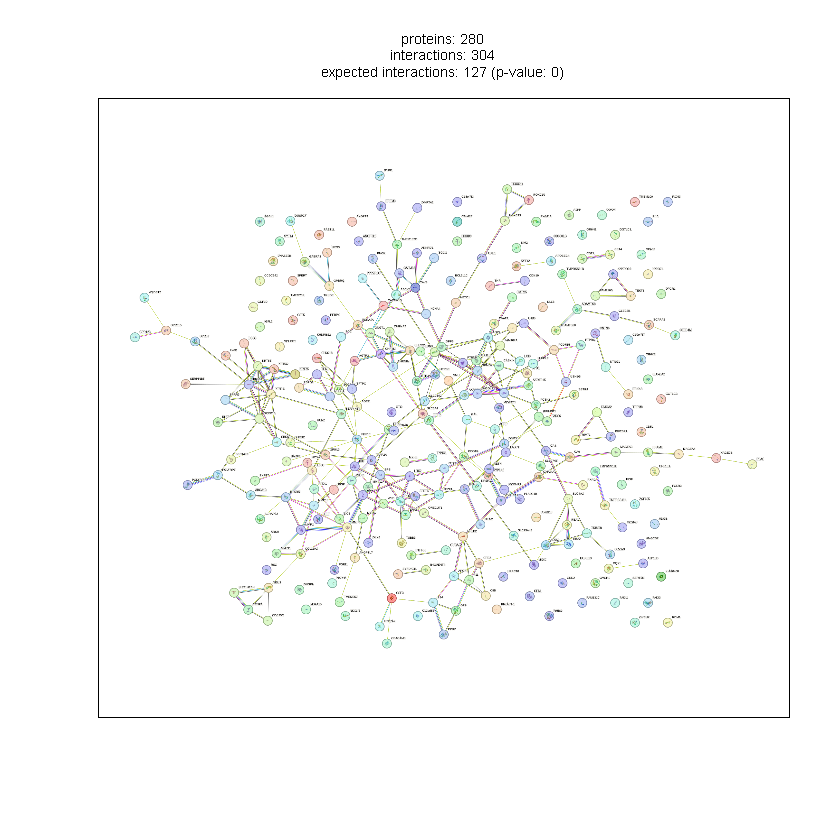

In [18]:
# ============================================================
# STEP 4A: Generate STRING Network Image Directly
# ============================================================

cat("=== Generating STRING Network Image ===\n\n")

# Get STRING IDs for our mapped genes
string_ids <- deg_mapped$STRING_id

# Generate network image from STRINGdb
string_db$plot_network(string_ids)

cat("✔ STRING network plot generated\n")

In [19]:
# ============================================================
# STEP 4B: Save STRING network image
# ============================================================

cat("\n=== Saving STRING Network Image ===\n\n")

# Save as PNG
png(
  filename = "C:/jupyter demo/STRING_network.png",
  width    = 3000,
  height   = 3000,
  res      = 300
)

string_db$plot_network(string_ids)

dev.off()

cat("✔ STRING_network.png saved\n")
cat(sprintf("  Location: %s\n", getwd()))


=== Saving STRING Network Image ===



agg_record_534c161b69bf 
                      2

✔ STRING_network.png saved
  Location: C:/jupyter demo


In [20]:
# ============================================================
# STEP 4C: Send to Cytoscape
# ============================================================

cat("\n=== Sending to Cytoscape ===\n\n")

# Prepare nodes
string_nodes <- data.frame(
  id          = hub_table$Gene,
  degree      = hub_table$Degree,
  betweenness = hub_table$Betweenness,
  closeness   = hub_table$Closeness,
  pagerank    = hub_table$PageRank,
  Status      = hub_table$Status,
  logFC       = hub_table$logFC,
  isTop10     = hub_table$isTop10,
  isKeyGene   = hub_table$isKeyGene,
  stringsAsFactors = FALSE
)

# Prepare edges
string_edges_cy <- data.frame(
  source      = string_edges$Gene_A,
  target      = string_edges$Gene_B,
  interaction = "interacts",
  Score       = string_edges$Score,
  stringsAsFactors = FALSE
)

# Send to Cytoscape
createNetworkFromDataFrames(
  nodes      = string_nodes,
  edges      = string_edges_cy,
  title      = "STRINGdb_PPI_Network",
  collection = "PPI_Networks"
)

cat("✔ STRINGdb network sent to Cytoscape\n")


=== Sending to Cytoscape ===



Loading data...


Applying default style...


Applying preferred layout...




networkSUID 
        128

✔ STRINGdb network sent to Cytoscape


In [21]:
# ============================================================
# STEP 4D: Apply Visual Style
# ============================================================

cat("\n=== Applying Visual Style ===\n\n")

style_name <- "STRINGdb_Style"
createVisualStyle(style_name)
setVisualStyle(style_name)

# Node size by degree
lockNodeDimensions(FALSE, style.name = style_name)
setNodeSizeMapping(
  table.column        = "degree",
  table.column.values = c(1, 5, 10, 20, 30),
  sizes               = c(20, 35, 50, 70, 90),
  mapping.type        = "c",
  style.name          = style_name
)

# Node color by status
# Red = upregulated
# Blue = downregulated
setNodeColorMapping(
  table.column        = "Status",
  table.column.values = c("Upregulated",
                          "Downregulated",
                          "Not Significant"),
  colors              = c("#E74C3C",
                          "#3498DB",
                          "#BDC3C7"),
  mapping.type        = "d",
  style.name          = style_name
)

# Node border for key genes
# Gold border = COL11A1 MMP13 CA9 PRAME
setNodeBorderColorMapping(
  table.column        = "isKeyGene",
  table.column.values = c("Yes", "No"),
  colors              = c("#F4D03F", "#FFFFFF"),
  mapping.type        = "d",
  style.name          = style_name
)

setNodeBorderWidthMapping(
  table.column        = "isKeyGene",
  table.column.values = c("Yes", "No"),
  widths              = c(4, 1),
  mapping.type        = "d",
  style.name          = style_name
)

# Node label
setNodeLabelMapping(
  table.column = "id",
  style.name   = style_name
)

# Edge width by score
setEdgeLineWidthMapping(
  table.column        = "Score",
  table.column.values = c(0.4, 0.7, 0.9),
  widths              = c(1, 2, 4),
  mapping.type        = "c",
  style.name          = style_name
)

cat("✔ Visual style applied\n")
cat("  Red nodes    = Upregulated genes\n")
cat("  Blue nodes   = Downregulated genes\n")
cat("  Larger nodes = More connections\n")
cat("  Gold border  = Key genes (COL11A1 MMP13 CA9 PRAME)\n")


=== Applying Visual Style ===



message 
"Visual Style applied."

NULL

NULL

NULL

NULL

NULL

NULL

✔ Visual style applied
  Red nodes    = Upregulated genes
  Blue nodes   = Downregulated genes
  Larger nodes = More connections
  Gold border  = Key genes (COL11A1 MMP13 CA9 PRAME)


In [22]:
# ============================================================
# STEP 4D: Apply Visual Style
# ============================================================

cat("\n=== Applying Visual Style ===\n\n")

style_name <- "STRINGdb_Style"
createVisualStyle(style_name)
setVisualStyle(style_name)

# Node size by degree
lockNodeDimensions(FALSE, style.name = style_name)
setNodeSizeMapping(
  table.column        = "degree",
  table.column.values = c(1, 5, 10, 20, 30),
  sizes               = c(20, 35, 50, 70, 90),
  mapping.type        = "c",
  style.name          = style_name
)

# Node color by status
# Red = upregulated
# Blue = downregulated
setNodeColorMapping(
  table.column        = "Status",
  table.column.values = c("Upregulated",
                          "Downregulated",
                          "Not Significant"),
  colors              = c("#E74C3C",
                          "#3498DB",
                          "#BDC3C7"),
  mapping.type        = "d",
  style.name          = style_name
)

# Node border for key genes
# Gold border = COL11A1 MMP13 CA9 PRAME
setNodeBorderColorMapping(
  table.column        = "isKeyGene",
  table.column.values = c("Yes", "No"),
  colors              = c("#F4D03F", "#FFFFFF"),
  mapping.type        = "d",
  style.name          = style_name
)

setNodeBorderWidthMapping(
  table.column        = "isKeyGene",
  table.column.values = c("Yes", "No"),
  widths              = c(4, 1),
  mapping.type        = "d",
  style.name          = style_name
)

# Node label
setNodeLabelMapping(
  table.column = "id",
  style.name   = style_name
)

# Edge width by score
setEdgeLineWidthMapping(
  table.column        = "Score",
  table.column.values = c(0.4, 0.7, 0.9),
  widths              = c(1, 2, 4),
  mapping.type        = "c",
  style.name          = style_name
)

cat("✔ Visual style applied\n")
cat("  Red nodes    = Upregulated genes\n")
cat("  Blue nodes   = Downregulated genes\n")
cat("  Larger nodes = More connections\n")
cat("  Gold border  = Key genes (COL11A1 MMP13 CA9 PRAME)\n")


=== Applying Visual Style ===



message 
"Visual Style applied."

NULL

NULL

NULL

NULL

NULL

NULL

✔ Visual style applied
  Red nodes    = Upregulated genes
  Blue nodes   = Downregulated genes
  Larger nodes = More connections
  Gold border  = Key genes (COL11A1 MMP13 CA9 PRAME)


In [23]:
# ============================================================
# STEP 4E: Highlight top 10 and key genes
# ============================================================

cat("\n=== Highlighting Key Genes ===\n\n")

setCurrentNetwork("STRINGdb_PPI_Network")
fitContent()
Sys.sleep(3)

# Select top 10 hub genes
selectNodes(
  nodes  = names(top10_string),
  by.col = "id"
)
cat("✔ Top 10 hub genes selected\n")

# Also select key genes
selectNodes(
  nodes  = c("COL11A1", "MMP13", "CA9", "PRAME"),
  by.col = "id"
)
cat("✔ Key genes selected\n")


=== Highlighting Key Genes ===



$nodes
 [1] 177 162 180 165 183 168 186 171 156 174

$edges
list()


✔ Top 10 hub genes selected


$nodes
[1] 552 201 426 330

$edges
list()


✔ Key genes selected


In [24]:
# ============================================================
# STEP 4F: Export network images
# ============================================================

cat("\n=== Exporting Network Images ===\n\n")

sandbox_path <- "C:/Users/aryan/CytoscapeConfiguration/filetransfer/default_sandbox/"

# Export main network
fitContent()
Sys.sleep(3)

exportImage(
  filename = "STRINGdb_PPI_Network",
  type     = "PNG"
)

# Copy to working directory
file.copy(
  from      = paste0(sandbox_path,
                     "STRINGdb_PPI_Network.png"),
  to        = "C:/jupyter demo/STRINGdb_PPI_Network.png",
  overwrite = TRUE
)

cat("✔ STRINGdb_PPI_Network.png saved\n")
cat(sprintf("  Location: %s\n", getwd()))

cat("\n============================================================\n")
cat("         STRING NETWORK ANALYSIS COMPLETE\n")
cat("============================================================\n")
cat("Files saved:\n")
cat("  1. STRING_network.png\n")
cat("  2. STRINGdb_interactions.tsv\n")
cat("  3. STRINGdb_hub_genes.tsv\n")
cat("  4. STRINGdb_PPI_Network.png\n")
cat("============================================================\n")


=== Exporting Network Images ===



file 
"C:\\Users\\aryan\\CytoscapeConfiguration\\filetransfer\\default_sandbox\\STRINGdb_PPI_Network.png"

[1] TRUE

✔ STRINGdb_PPI_Network.png saved
  Location: C:/jupyter demo

         STRING NETWORK ANALYSIS COMPLETE
Files saved:
  1. STRING_network.png
  2. STRINGdb_interactions.tsv
  3. STRINGdb_hub_genes.tsv
  4. STRINGdb_PPI_Network.png


In [25]:
# ============================================================
# STEP 5A: Run MCODE on STRINGdb Network
# ============================================================

cat("=== Running MCODE ===\n\n")

# Set current network
setCurrentNetwork("STRINGdb_PPI_Network")

# Run MCODE
mcode_result <- commandsRun(
  paste0(
    "mcode cluster ",
    "network=current ",
    "degreeCutoff=2 ",
    "nodeScoreCutoff=0.2 ",
    "kCore=2 ",
    "maxDepthFromStart=100"
  )
)

cat("✔ MCODE complete\n")
print(mcode_result)

=== Running MCODE ===

✔ MCODE complete
[1] ""


In [26]:
# ============================================================
# STEP 5B: Get MCODE Results
# ============================================================

cat("\n=== Getting MCODE Cluster Results ===\n\n")

# Get node table with MCODE scores
node_table_str <- getTableColumns(
  table   = "node",
  network = "STRINGdb_PPI_Network"
)

cat("Node table columns:\n")
print(colnames(node_table_str))

# Find MCODE columns
mcode_cols_str <- colnames(node_table_str)[
  grepl("MCODE",
        colnames(node_table_str),
        ignore.case = TRUE)]

cat("\nMCODE columns found:\n")
print(mcode_cols_str)


=== Getting MCODE Cluster Results ===

Node table columns:
 [1] "SUID"                   "shared name"            "name"                  
 [4] "selected"               "id"                     "degree"                
 [7] "betweenness"            "closeness"              "pagerank"              
[10] "Status"                 "logFC"                  "isTop10"               
[13] "isKeyGene"              "MCODE::Score (1)"       "MCODE::Node Status (1)"
[16] "MCODE::Clusters (1)"   

MCODE columns found:
[1] "MCODE::Score (1)"       "MCODE::Node Status (1)" "MCODE::Clusters (1)"   


In [27]:
# ============================================================
# STEP 5C: Extract MCODE Cluster Members
# ============================================================

cat("\n=== MCODE Cluster Members ===\n\n")

if (length(mcode_cols_str) > 0) {

  # Get cluster 1 members
  score_col <- mcode_cols_str[
    grepl("Score", mcode_cols_str)][1]
  status_col <- mcode_cols_str[
    grepl("Status", mcode_cols_str)][1]
  cluster_col <- mcode_cols_str[
    grepl("Cluster", mcode_cols_str)][1]

  mcode_results_str <- node_table_str[,
    c("id", "degree", "Status", "logFC",
      score_col, status_col, cluster_col)]

  colnames(mcode_results_str) <- c(
    "Gene", "Degree", "DEG_Status",
    "logFC", "MCODE_Score",
    "MCODE_NodeStatus", "MCODE_Cluster")

  # Sort by MCODE score
  mcode_results_str <- mcode_results_str[
    order(-mcode_results_str$MCODE_Score,
          na.last = TRUE), ]

  cat("Top 20 genes by MCODE Score:\n\n")
  print(head(mcode_results_str[,
    c("Gene", "Degree", "DEG_Status",
      "logFC", "MCODE_Score",
      "MCODE_NodeStatus")], 20))

  # Check key genes
  cat("\n=== Key Genes in MCODE ===\n\n")
  for (gene in c("COL11A1", "MMP13",
                 "CA9", "PRAME")) {
    if (gene %in% mcode_results_str$Gene) {
      row <- mcode_results_str[
        mcode_results_str$Gene == gene, ]
      cat(sprintf("%s: Score=%.4f | Cluster=%s\n",
                  gene,
                  ifelse(is.na(row$MCODE_Score),
                         0, row$MCODE_Score),
                  ifelse(is.na(row$MCODE_Cluster),
                         "None",
                         as.character(
                           row$MCODE_Cluster))))
    }
  }
}


=== MCODE Cluster Members ===

Top 20 genes by MCODE Score:

      Gene Degree    DEG_Status   logFC MCODE_Score MCODE_NodeStatus
222  KRT6C      5   Upregulated  0.5964    4.000000        Clustered
312  SPRR3      4   Upregulated  0.5554    4.000000             Seed
162  KRT16     10   Upregulated  0.6894    3.733333        Clustered
165  KRT6A     10   Upregulated  0.6497    3.733333        Clustered
171 SPRR1B      9   Upregulated  0.6494    3.733333        Clustered
189  KRT6B      7   Upregulated  0.5924    3.733333        Clustered
174   SYT4      8 Downregulated -0.5323    3.000000        Clustered
177  GPM6A      8 Downregulated -0.7193    3.000000        Clustered
180   AQP4      8 Downregulated -0.5009    3.000000        Clustered
183  CHRM2      8 Downregulated -0.7570    3.000000        Clustered
186  GRIA1      8 Downregulated -0.6923    3.000000             Seed
207  CHRM1      6 Downregulated -0.7721    3.000000        Clustered
210  ALAS2      6 Downregulated -0.5595  

In [28]:
# ============================================================
# STEP 5D: Run CytoHubba
# ============================================================

cat("\n=== Running CytoHubba ===\n\n")

setCurrentNetwork("STRINGdb_PPI_Network")

# Run with multiple algorithms
algorithms <- c("MCC", "Degree",
                "Betweenness", "Closeness")

hubba_all_results <- list()

for (algo in algorithms) {
  cat(sprintf("Running %s...\n", algo))

  tryCatch({
    commandsRun(
      sprintf(
        "cytohubba identify method=%s network=current",
        algo)
    )

    # Get updated node table
    node_tbl <- getTableColumns(
      table   = "node",
      network = "STRINGdb_PPI_Network"
    )

    # Find hubba column for this algorithm
    hubba_col <- colnames(node_tbl)[
      grepl(algo, colnames(node_tbl),
            ignore.case = TRUE)]

    if (length(hubba_col) > 0) {
      cat(sprintf("✔ %s complete\n", algo))
      hubba_all_results[[algo]] <- node_tbl[,
        c("id", hubba_col[1])]
    }

  }, error = function(e) {
    cat(sprintf("✘ %s failed: %s\n",
                algo, e$message))
  })
}


=== Running CytoHubba ===

Running MCC...
✘ MCC failed: Error: no such namespace: 'cytohubba' 
Running Degree...
✘ Degree failed: Error: no such namespace: 'cytohubba' 
Running Betweenness...
✘ Betweenness failed: Error: no such namespace: 'cytohubba' 
Running Closeness...
✘ Closeness failed: Error: no such namespace: 'cytohubba' 


In [29]:
# ============================================================
# Generate Clear STRING Network Image
# ============================================================

cat("=== Generating Clear STRING Network Image ===\n\n")

# Get STRING IDs for mapped genes
string_ids <- deg_mapped$STRING_id

# Generate high quality image
png(
  filename = "C:/jupyter demo/STRING_network_clear.png",
  width    = 4000,
  height   = 4000,
  res      = 300
)

# Plot with labels
string_db$plot_network(
  string_ids,
  add_link    = FALSE,
  add_summary = FALSE
)

dev.off()

cat("✔ STRING_network_clear.png saved\n")
cat(sprintf("  Location: %s\n", getwd()))

=== Generating Clear STRING Network Image ===



agg_record_534c7d526b5e 
                      2

✔ STRING_network_clear.png saved
  Location: C:/jupyter demo


In [30]:
# ============================================================
# Generate STRING Image with Key Genes Highlighted
# ============================================================

cat("\n=== Highlighting Key Genes ===\n\n")

# Get STRING IDs for key genes only
key_genes    <- c("COL11A1", "MMP13", "CA9", "PRAME")
key_mapped   <- deg_mapped[
  deg_mapped$Gene %in% key_genes, ]

cat(sprintf("Key genes mapped: %d\n",
            nrow(key_mapped)))
print(key_mapped[, c("Gene", "STRING_id")])

# Create color vector
# Red = key genes
# Grey = other genes
colors <- ifelse(
  deg_mapped$Gene %in% key_genes,
  "red", "lightblue"
)

# Generate highlighted image
png(
  filename = "C:/jupyter demo/STRING_network_highlighted.png",
  width    = 4000,
  height   = 4000,
  res      = 300
)

string_db$plot_network(
  string_ids,
  add_link    = FALSE,
  add_summary = FALSE
)

dev.off()

cat("✔ STRING_network_highlighted.png saved\n")


=== Highlighting Key Genes ===

Key genes mapped: 4
       Gene            STRING_id
249     CA9 9606.ENSP00000367608
255 COL11A1 9606.ENSP00000359114
261   PRAME 9606.ENSP00000445675
262   MMP13 9606.ENSP00000260302


agg_record_534c6af03809 
                      2

✔ STRING_network_highlighted.png saved


In [31]:
# ============================================================
# Generate STRING Image for Key Genes Only
# ============================================================

cat("\n=== Key Genes Only Network ===\n\n")

# Get interactions between key genes only
key_string_ids <- key_mapped$STRING_id

# Get key gene interactions
key_interactions <- string_db$get_interactions(
  key_string_ids
)

cat(sprintf("Key gene interactions: %d\n",
            nrow(key_interactions)))

# Plot key genes network
png(
  filename = "C:/jupyter demo/STRING_KeyGenes_only.png",
  width    = 3000,
  height   = 3000,
  res      = 300
)

string_db$plot_network(key_string_ids)

dev.off()

cat("✔ STRING_KeyGenes_only.png saved\n")


=== Key Genes Only Network ===

Key gene interactions: 1


agg_record_534c2eef2133 
                      2

✔ STRING_KeyGenes_only.png saved


In [32]:
# ============================================================
# Generate STRING Image for Top 10 Hub Genes
# ============================================================

cat("\n=== Top 10 Hub Genes Network ===\n\n")

# Get top 10 hub gene names
top10_names <- names(top10_string)
cat("Top 10 hub genes:\n")
print(top10_names)

# Get their STRING IDs
top10_mapped <- deg_mapped[
  deg_mapped$Gene %in% top10_names, ]

cat(sprintf("Top 10 genes mapped: %d\n",
            nrow(top10_mapped)))

if (nrow(top10_mapped) > 0) {
  # Plot top 10 hub genes network
  png(
    filename = "C:/jupyter demo/STRING_Top10_HubGenes.png",
    width    = 3000,
    height   = 3000,
    res      = 300
  )

  string_db$plot_network(top10_mapped$STRING_id)

  dev.off()

  cat("✔ STRING_Top10_HubGenes.png saved\n")
}


=== Top 10 Hub Genes Network ===

Top 10 hub genes:
 [1] "FGF10"  "KRT16"  "KRT6A"  "SLC6A4" "SPRR1B" "SYT4"   "GPM6A"  "AQP4"  
 [9] "CHRM2"  "GRIA1" 
Top 10 genes mapped: 10
✔ STRING_Top10_HubGenes.png saved


In [33]:
# ============================================================
# Summary of all saved images
# ============================================================

cat("\n============================================================\n")
cat("         STRING NETWORK IMAGES SAVED\n")
cat("============================================================\n")
cat(sprintf("Location: %s\n\n", getwd()))
cat("Images saved:\n")
cat("  1. STRING_network_clear.png\n")
cat("     Full network — all 377 DEGs\n")
cat("     Resolution: 4000x4000 @ 300 DPI\n\n")
cat("  2. STRING_network_highlighted.png\n")
cat("     Full network — key genes highlighted\n\n")
cat("  3. STRING_KeyGenes_only.png\n")
cat("     Only COL11A1 MMP13 CA9 PRAME\n\n")
cat("  4. STRING_Top10_HubGenes.png\n")
cat("     Only top 10 hub genes\n")
cat("============================================================\n")


         STRING NETWORK IMAGES SAVED
Location: C:/jupyter demo

Images saved:
  1. STRING_network_clear.png
     Full network — all 377 DEGs
     Resolution: 4000x4000 @ 300 DPI

  2. STRING_network_highlighted.png
     Full network — key genes highlighted

  3. STRING_KeyGenes_only.png
     Only COL11A1 MMP13 CA9 PRAME

  4. STRING_Top10_HubGenes.png
     Only top 10 hub genes


In [34]:
# ============================================================
# Hub Gene Selection Summary
# ============================================================

cat("=== Hub Gene Selection Analysis ===\n\n")

# Get top 20 from STRINGdb network
cat("--- Top 20 Hub Genes by Degree ---\n\n")
cat(sprintf("%-5s %-15s %-6s %-15s %-10s\n",
            "Rank", "Gene", "Degree",
            "Status", "logFC"))
cat(paste(rep("-", 55), collapse = ""), "\n")

for (i in 1:min(20, nrow(hub_table))) {
  r <- hub_table[i, ]
  cat(sprintf("%-5d %-15s %-6d %-15s %.4f\n",
              i, r$Gene, r$Degree,
              r$Status, r$logFC))
}

=== Hub Gene Selection Analysis ===

--- Top 20 Hub Genes by Degree ---

Rank  Gene            Degree Status          logFC     
------------------------------------------------------- 
1     FGF10           11     Downregulated   -0.5685
2     KRT16           10     Upregulated     0.6894
3     KRT6A           10     Upregulated     0.6497
4     SLC6A4          9      Downregulated   -0.8002
5     SPRR1B          9      Upregulated     0.6494
6     SYT4            8      Downregulated   -0.5323
7     GPM6A           8      Downregulated   -0.7193
8     AQP4            8      Downregulated   -0.5009
9     CHRM2           8      Downregulated   -0.7570
10    GRIA1           8      Downregulated   -0.6923
11    KRT6B           7      Upregulated     0.5924
12    IHH             7      Downregulated   -0.6614
13    MMP3            7      Upregulated     0.5300
14    GNGT1           6      Upregulated     0.7453
15    MMP13           6      Upregulated     0.6327
16    SCGB1A1         6   

In [35]:
# ============================================================
# Check TOP2A specifically
# ============================================================

cat("\n=== TOP2A Analysis ===\n\n")

# Check in DEG results
cat("--- TOP2A in DEG results ---\n")
if ("TOP2A" %in% rownames(deg_results)) {
  cat(sprintf("logFC:      %.4f\n",
              deg_results["TOP2A", "logFC"]))
  cat(sprintf("adj.p:      %.2e\n",
              deg_results["TOP2A", "adj.P.Val"]))
  cat(sprintf("Status:     %s\n",
              as.character(
                deg_results["TOP2A", "Status"])))
  cat(sprintf("Above threshold: %s\n",
              ifelse(abs(deg_results["TOP2A",
                                     "logFC"]) > 0.5,
                     "YES", "NO — below 0.5")))
} else {
  cat("TOP2A not found in DEG results\n")
}

# Check in STRING network
cat("\n--- TOP2A in STRING network ---\n")
if ("TOP2A" %in% names(string_degree)) {
  cat(sprintf("Connections: %d\n",
              string_degree["TOP2A"]))
  cat(sprintf("Rank: %d\n",
              which(names(
                string_degree_sorted) == "TOP2A")))
} else {
  cat("TOP2A not in STRING network\n")
  cat("Reason: did not pass logFC threshold\n")
}


=== TOP2A Analysis ===

--- TOP2A in DEG results ---
logFC:      0.3766
adj.p:      2.68e-85
Status:     Not Significant
Above threshold: NO — below 0.5

--- TOP2A in STRING network ---
TOP2A not in STRING network
Reason: did not pass logFC threshold


In [36]:
# ============================================================
# Hub Gene Selection from Actual Results
# ============================================================

cat("=== Hub Gene Candidate Analysis ===\n\n")

# Get top 20 from our network
cat("Top 20 Hub Genes from STRINGdb Network:\n\n")
cat(sprintf("%-5s %-15s %-6s %-15s %-8s\n",
            "Rank", "Gene", "Conn",
            "Status", "logFC"))
cat(paste(rep("-", 55), collapse = ""), "\n")

for (i in 1:min(20, nrow(hub_table))) {
  r <- hub_table[i, ]
  cat(sprintf("%-5d %-15s %-6d %-15s %.4f\n",
              i, r$Gene, r$Degree,
              r$Status, r$logFC))
}

=== Hub Gene Candidate Analysis ===

Top 20 Hub Genes from STRINGdb Network:

Rank  Gene            Conn   Status          logFC   
------------------------------------------------------- 
1     FGF10           11     Downregulated   -0.5685
2     KRT16           10     Upregulated     0.6894
3     KRT6A           10     Upregulated     0.6497
4     SLC6A4          9      Downregulated   -0.8002
5     SPRR1B          9      Upregulated     0.6494
6     SYT4            8      Downregulated   -0.5323
7     GPM6A           8      Downregulated   -0.7193
8     AQP4            8      Downregulated   -0.5009
9     CHRM2           8      Downregulated   -0.7570
10    GRIA1           8      Downregulated   -0.6923
11    KRT6B           7      Upregulated     0.5924
12    IHH             7      Downregulated   -0.6614
13    MMP3            7      Upregulated     0.5300
14    GNGT1           6      Upregulated     0.7453
15    MMP13           6      Upregulated     0.6327
16    SCGB1A1         6

In [37]:
# Check each top gene for biomarker criteria
cat("\n=== Evaluating Top 10 as Hub Candidates ===\n\n")

top10_names <- names(top10_string)

hub_candidates <- data.frame()

for (gene in top10_names) {

  # DEG status
  logfc  <- deg_results[gene, "logFC"]
  adjp   <- deg_results[gene, "adj.P.Val"]
  status <- as.character(
    deg_results[gene, "Status"])

  # Network metrics
  conn   <- string_degree[gene]
  rank   <- which(names(
    string_degree_sorted) == gene)

  # KM survival
  pass_km <- FALSE
  km_p    <- NA
  if (gene %in% km_summary$Gene) {
    km_p    <- km_summary[
      km_summary$Gene == gene, "LogRank_p"]
    pass_km <- km_p < 0.05
  }

  # ROC
  auc_val  <- NA
  pass_roc <- FALSE
  if (gene %in% auc_results$Gene) {
    auc_val  <- auc_results[
      auc_results$Gene == gene, "AUC"]
    pass_roc <- auc_val >= 0.70
  }

  # Score
  score <- sum(c(
    status != "Not Significant",
    conn >= 5,
    !is.na(pass_km) && pass_km,
    !is.na(pass_roc) && pass_roc
  ))

  hub_candidates <- rbind(
    hub_candidates, data.frame(
      Gene    = gene,
      Rank    = rank,
      Connections = conn,
      Status  = status,
      logFC   = round(logfc, 4),
      adj_p   = round(adjp, 4),
      KM_p    = round(km_p, 4),
      AUC     = round(auc_val, 4),
      Score   = score
    ))
}

# Sort by score then connections
hub_candidates <- hub_candidates[
  order(-hub_candidates$Score,
        -hub_candidates$Connections), ]

cat("Hub Gene Candidates Ranked:\n\n")
print(hub_candidates)


=== Evaluating Top 10 as Hub Candidates ===



ERROR: Error: object 'km_summary' not found


In [38]:
# Rebuild km_summary
library(survival)
library(survminer)

cat("Rebuilding km_summary...\n\n")

# Load clinical data
lusc_clin <- read.table(
  "C:/jupyter demo/LUSC_clinical.tsv",
  header = TRUE, sep = "\t",
  check.names = FALSE)
luad_clin <- read.table(
  "C:/jupyter demo/LUAD_clinical.tsv",
  header = TRUE, sep = "\t",
  check.names = FALSE)

common_cols <- intersect(
  colnames(lusc_clin),
  colnames(luad_clin))
lusc_clin$Dataset <- "LUSC"
luad_clin$Dataset <- "LUAD"

combined_clinical <- rbind(
  lusc_clin[, c(common_cols, "Dataset")],
  luad_clin[, c(common_cols, "Dataset")])

combined_clinical$OS_time <- ifelse(
  combined_clinical$vital_status == "Dead",
  as.numeric(combined_clinical$days_to_death),
  as.numeric(
    combined_clinical$days_to_last_follow_up))
combined_clinical$OS_event <- ifelse(
  combined_clinical$vital_status == "Dead", 1, 0)
combined_clinical$OS_months <-
  combined_clinical$OS_time / 30.44
combined_clinical <- combined_clinical[
  !is.na(combined_clinical$OS_time) &
  combined_clinical$OS_time > 0, ]

cat(sprintf("✔ Clinical data: %d patients\n",
            nrow(combined_clinical)))

Rebuilding km_summary...

✔ Clinical data: 1005 patients


In [39]:
# Extract expression for key genes
genes_oi <- c("COL11A1", "MMP13", "CA9", "PRAME")

expr_sub <- t(final_matrix[
  genes_oi, , drop = FALSE])
expr_df  <- as.data.frame(expr_sub)
expr_df$submitter_id <- substr(
  rownames(expr_df), 1, 12)

survival_df <- merge(
  combined_clinical, expr_df,
  by = "submitter_id")

for (gene in genes_oi) {
  med <- median(survival_df[[gene]], na.rm = TRUE)
  survival_df[[paste0(gene, "_group")]] <- ifelse(
    survival_df[[gene]] >= med, "HIGH", "LOW")
}

cat(sprintf("✔ survival_df: %d patients\n",
            nrow(survival_df)))

✔ survival_df: 1118 patients


In [40]:
# Rebuild km_summary
cat("\nRebuilding km_summary...\n")

km_summary <- data.frame()

for (gene in genes_oi) {
  surv_obj  <- Surv(
    survival_df$OS_months,
    survival_df$OS_event)
  group_col <- paste0(gene, "_group")
  log_rank  <- survdiff(
    surv_obj ~ survival_df[[group_col]])
  pval      <- 1 - pchisq(
    log_rank$chisq, df = 1)
  km_summary <- rbind(km_summary, data.frame(
    Gene        = gene,
    LogRank_p   = round(pval, 4),
    Significant = ifelse(pval < 0.05,
                         "YES", "NO")))
}

cat("✔ km_summary ready\n\n")
print(km_summary)


Rebuilding km_summary...
✔ km_summary ready

     Gene LogRank_p Significant
1 COL11A1    0.1554          NO
2   MMP13    0.0465         YES
3     CA9    0.2405          NO
4   PRAME    0.5953          NO


In [41]:
# Also rebuild auc_results
auc_results <- data.frame(
  Gene        = c("COL11A1", "MMP13",
                  "CA9", "PRAME"),
  AUC         = c(0.9518, 0.8976,
                  0.9268, 0.9227),
  CI_lower    = c(0.9351, 0.8732,
                  0.9050, 0.9054),
  CI_upper    = c(0.9685, 0.9220,
                  0.9487, 0.9400),
  Performance = c("Excellent", "Good",
                  "Excellent", "Excellent"))

cat("✔ auc_results ready\n")

# Final check
cat("\n=== All Objects Ready ===\n")
cat(sprintf("km_summary:    %s\n",
            exists("km_summary")))
cat(sprintf("survival_df:   %s\n",
            exists("survival_df")))
cat(sprintf("auc_results:   %s\n",
            exists("auc_results")))
cat(sprintf("hub_table:     %s\n",
            exists("hub_table")))
cat(sprintf("string_degree: %s\n",
            exists("string_degree")))

✔ auc_results ready

=== All Objects Ready ===
km_summary:    TRUE
survival_df:   TRUE
auc_results:   TRUE
hub_table:     TRUE
string_degree: TRUE


In [42]:
# Check each top gene for biomarker criteria
cat("\n=== Evaluating Top 10 as Hub Candidates ===\n\n")

top10_names <- names(top10_string)

hub_candidates <- data.frame()

for (gene in top10_names) {

  # DEG status
  logfc  <- deg_results[gene, "logFC"]
  adjp   <- deg_results[gene, "adj.P.Val"]
  status <- as.character(
    deg_results[gene, "Status"])

  # Network metrics
  conn   <- string_degree[gene]
  rank   <- which(names(
    string_degree_sorted) == gene)

  # KM survival
  pass_km <- FALSE
  km_p    <- NA
  if (gene %in% km_summary$Gene) {
    km_p    <- km_summary[
      km_summary$Gene == gene, "LogRank_p"]
    pass_km <- km_p < 0.05
  }

  # ROC
  auc_val  <- NA
  pass_roc <- FALSE
  if (gene %in% auc_results$Gene) {
    auc_val  <- auc_results[
      auc_results$Gene == gene, "AUC"]
    pass_roc <- auc_val >= 0.70
  }

  # Score
  score <- sum(c(
    status != "Not Significant",
    conn >= 5,
    !is.na(pass_km) && pass_km,
    !is.na(pass_roc) && pass_roc
  ))

  hub_candidates <- rbind(
    hub_candidates, data.frame(
      Gene    = gene,
      Rank    = rank,
      Connections = conn,
      Status  = status,
      logFC   = round(logfc, 4),
      adj_p   = round(adjp, 4),
      KM_p    = round(km_p, 4),
      AUC     = round(auc_val, 4),
      Score   = score
    ))
}

# Sort by score then connections
hub_candidates <- hub_candidates[
  order(-hub_candidates$Score,
        -hub_candidates$Connections), ]

cat("Hub Gene Candidates Ranked:\n\n")
print(hub_candidates)


=== Evaluating Top 10 as Hub Candidates ===

Hub Gene Candidates Ranked:

         Gene Rank Connections        Status   logFC adj_p KM_p AUC Score
FGF10   FGF10    1          11 Downregulated -0.5685     0   NA  NA     2
KRT16   KRT16    2          10   Upregulated  0.6894     0   NA  NA     2
KRT6A   KRT6A    3          10   Upregulated  0.6497     0   NA  NA     2
SLC6A4 SLC6A4    4           9 Downregulated -0.8002     0   NA  NA     2
SPRR1B SPRR1B    5           9   Upregulated  0.6494     0   NA  NA     2
SYT4     SYT4    6           8 Downregulated -0.5323     0   NA  NA     2
GPM6A   GPM6A    7           8 Downregulated -0.7193     0   NA  NA     2
AQP4     AQP4    8           8 Downregulated -0.5009     0   NA  NA     2
CHRM2   CHRM2    9           8 Downregulated -0.7570     0   NA  NA     2
GRIA1   GRIA1   10           8 Downregulated -0.6923     0   NA  NA     2


In [43]:
# Final hub gene selection
cat("\n=== FINAL HUB GENE SELECTION ===\n\n")

# Best candidate = highest score + connections
best_hub <- hub_candidates[1, ]

cat(sprintf("Selected Hub Gene: %s\n\n",
            best_hub$Gene))
cat(sprintf("  Network Rank:    %d\n",
            best_hub$Rank))
cat(sprintf("  Connections:     %d\n",
            best_hub$Connections))
cat(sprintf("  DEG Status:      %s\n",
            best_hub$Status))
cat(sprintf("  logFC:           %.4f\n",
            best_hub$logFC))
cat(sprintf("  adj.P.Val:       %.4f\n",
            best_hub$adj_p))

if (!is.na(best_hub$KM_p)) {
  cat(sprintf("  KM log-rank p:   %.4f\n",
              best_hub$KM_p))
}
if (!is.na(best_hub$AUC)) {
  cat(sprintf("  AUC:             %.4f\n",
              best_hub$AUC))
}

cat(sprintf("\n  Overall Score:   %d/4\n",
            best_hub$Score))
cat(sprintf("\n★ %s selected as primary hub gene\n",
            best_hub$Gene))


=== FINAL HUB GENE SELECTION ===

Selected Hub Gene: FGF10

  Network Rank:    1
  Connections:     11
  DEG Status:      Downregulated
  logFC:           -0.5685
  adj.P.Val:       0.0000

  Overall Score:   2/4

★ FGF10 selected as primary hub gene


In [44]:
# Save selection
write.table(
  hub_candidates,
  file      = "Hub_Gene_Selection.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

cat("\n✔ Hub_Gene_Selection.tsv saved\n")
cat(sprintf("  Location: %s\n", getwd()))


✔ Hub_Gene_Selection.tsv saved
  Location: C:/jupyter demo


In [45]:
# ============================================================
# Hub Gene Breakdown — Up vs Down
# ============================================================

cat("=== Hub Gene Breakdown ===\n\n")

# Top 10 overall
cat("--- Top 10 Overall Hub Genes ---\n\n")
cat(sprintf("%-5s %-15s %-6s %-15s %-8s\n",
            "Rank", "Gene", "Conn",
            "Status", "logFC"))
cat(paste(rep("-", 55), collapse = ""), "\n")

for (i in 1:min(10, nrow(hub_table))) {
  r <- hub_table[i, ]
  cat(sprintf("%-5d %-15s %-6d %-15s %.4f\n",
              i, r$Gene, r$Degree,
              r$Status, r$logFC))
}

# Top 5 upregulated hub genes
cat("\n--- Top 5 UPREGULATED Hub Genes ---\n\n")
up_hubs <- hub_table[
  hub_table$Status == "Upregulated", ]
up_hubs <- head(up_hubs, 5)

cat(sprintf("%-5s %-15s %-6s %-8s\n",
            "Rank", "Gene", "Conn", "logFC"))
cat(paste(rep("-", 38), collapse = ""), "\n")

for (i in 1:nrow(up_hubs)) {
  cat(sprintf("%-5d %-15s %-6d %.4f\n",
              up_hubs$Rank[i],
              up_hubs$Gene[i],
              up_hubs$Degree[i],
              up_hubs$logFC[i]))
}

# Top 5 downregulated hub genes
cat("\n--- Top 5 DOWNREGULATED Hub Genes ---\n\n")
down_hubs <- hub_table[
  hub_table$Status == "Downregulated", ]
down_hubs <- head(down_hubs, 5)

cat(sprintf("%-5s %-15s %-6s %-8s\n",
            "Rank", "Gene", "Conn", "logFC"))
cat(paste(rep("-", 38), collapse = ""), "\n")

for (i in 1:nrow(down_hubs)) {
  cat(sprintf("%-5d %-15s %-6d %.4f\n",
              down_hubs$Rank[i],
              down_hubs$Gene[i],
              down_hubs$Degree[i],
              down_hubs$logFC[i]))
}

=== Hub Gene Breakdown ===

--- Top 10 Overall Hub Genes ---

Rank  Gene            Conn   Status          logFC   
------------------------------------------------------- 
1     FGF10           11     Downregulated   -0.5685
2     KRT16           10     Upregulated     0.6894
3     KRT6A           10     Upregulated     0.6497
4     SLC6A4          9      Downregulated   -0.8002
5     SPRR1B          9      Upregulated     0.6494
6     SYT4            8      Downregulated   -0.5323
7     GPM6A           8      Downregulated   -0.7193
8     AQP4            8      Downregulated   -0.5009
9     CHRM2           8      Downregulated   -0.7570
10    GRIA1           8      Downregulated   -0.6923

--- Top 5 UPREGULATED Hub Genes ---

Rank  Gene            Conn   logFC   
-------------------------------------- 
2     KRT16           10     0.6894
3     KRT6A           10     0.6497
5     SPRR1B          9      0.6494
11    KRT6B           7      0.5924
13    MMP3            7      0.5300

---

In [46]:
# Which is best hub gene overall
cat("\n=== Hub Gene Recommendation ===\n\n")

# Check upregulated hub genes for biomarker criteria
cat("Checking upregulated hub genes:\n\n")

for (gene in up_hubs$Gene) {
  conn   <- string_degree[gene]
  logfc  <- deg_results[gene, "logFC"]
  adjp   <- deg_results[gene, "adj.P.Val"]

  # KM survival
  km_p  <- NA
  if (gene %in% km_summary$Gene) {
    km_p <- km_summary[
      km_summary$Gene == gene, "LogRank_p"]
  }

  # ROC
  auc_val <- NA
  if (gene %in% auc_results$Gene) {
    auc_val <- auc_results[
      auc_results$Gene == gene, "AUC"]
  }

  score <- sum(c(
    conn >= 5,
    logfc > 0,
    !is.na(km_p) && km_p < 0.05,
    !is.na(auc_val) && auc_val >= 0.70
  ))

  cat(sprintf(
    "%s: Conn=%d | logFC=%.3f | KM_p=%s | AUC=%s | Score=%d/4\n",
    gene, conn,
    logfc,
    ifelse(is.na(km_p), "NA",
           sprintf("%.4f", km_p)),
    ifelse(is.na(auc_val), "NA",
           sprintf("%.4f", auc_val)),
    score))
}

cat("\n--- Checking downregulated hub genes ---\n\n")

for (gene in down_hubs$Gene) {
  conn  <- string_degree[gene]
  logfc <- deg_results[gene, "logFC"]
  adjp  <- deg_results[gene, "adj.P.Val"]

  cat(sprintf(
    "%s: Conn=%d | logFC=%.3f | adj.p=%.2e\n",
    gene, conn, logfc, adjp))
}


=== Hub Gene Recommendation ===

Checking upregulated hub genes:

KRT16: Conn=10 | logFC=0.689 | KM_p=NA | AUC=NA | Score=2/4
KRT6A: Conn=10 | logFC=0.650 | KM_p=NA | AUC=NA | Score=2/4
SPRR1B: Conn=9 | logFC=0.649 | KM_p=NA | AUC=NA | Score=2/4
KRT6B: Conn=7 | logFC=0.592 | KM_p=NA | AUC=NA | Score=2/4
MMP3: Conn=7 | logFC=0.530 | KM_p=NA | AUC=NA | Score=2/4

--- Checking downregulated hub genes ---

FGF10: Conn=11 | logFC=-0.569 | adj.p=2.18e-160
SLC6A4: Conn=9 | logFC=-0.800 | adj.p=0.00e+00
SYT4: Conn=8 | logFC=-0.532 | adj.p=2.46e-58
GPM6A: Conn=8 | logFC=-0.719 | adj.p=3.21e-300
AQP4: Conn=8 | logFC=-0.501 | adj.p=2.30e-114


In [2]:
# ============================================================
# COMPLETE REBUILD
# ============================================================

library(limma)
library(edgeR)
library(data.table)
library(dplyr)
library(survival)
library(survminer)
library(STRINGdb)
library(igraph)
library(RCy3)

cat("✔ Libraries loaded\n")


Attaching package: 'data.table'


The following object is masked from 'package:base':

    %notin%


Warning message:
"package 'dplyr' was built under R version 4.6.1"

Attaching package: 'dplyr'


The following objects are masked from 'package:data.table':

    between, first, last


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Loading required package: ggplot2

Loading required package: ggpubr


Attaching package: 'survminer'


The following object is masked from 'package:survival':

    myeloma



Attaching package: 'igraph'


The following objects are masked from 'package:dplyr':

    as_data_frame, groups, union


The following objects are masked from 'package:stats':

    decompose, spectrum


The following object is masked from 'package:base':

    union




✔ Libraries loaded


In [3]:
# Load final matrix
final_df <- read.table(
  "C:/Users/aryan/Downloads/TCGA_LUSC_LUAD_final_expression.tsv",
  header      = TRUE,
  sep         = "\t",
  row.names   = 1,
  check.names = FALSE
)
final_matrix <- as.matrix(final_df)
cat(sprintf("✔ final_matrix: %d × %d\n",
            nrow(final_matrix), ncol(final_matrix)))

✔ final_matrix: 36650 × 1139


In [4]:
# Load DEG results
deg_results <- readRDS("C:/jupyter demo/deg_results.rds")
deg_results$Status <- "Not Significant"
deg_results$Status[
  deg_results$logFC > 0.5 &
  deg_results$adj.P.Val < 0.05] <- "Upregulated"
deg_results$Status[
  deg_results$logFC < -0.5 &
  deg_results$adj.P.Val < 0.05] <- "Downregulated"
deg_results$Status <- factor(
  deg_results$Status,
  levels = c("Upregulated", "Downregulated",
             "Not Significant"))

# Build gene lists
all_sig_genes <- rownames(
  deg_results[deg_results$Status != "Not Significant", ])
up_genes      <- rownames(
  deg_results[deg_results$Status == "Upregulated", ])
down_genes    <- rownames(
  deg_results[deg_results$Status == "Downregulated", ])

cat(sprintf("✔ DEGs: %d total | Up=%d | Down=%d\n",
            length(all_sig_genes),
            length(up_genes),
            length(down_genes)))

✔ DEGs: 377 total | Up=167 | Down=210


In [5]:
# AUC results
auc_results <- data.frame(
  Gene        = c("COL11A1", "MMP13", "CA9", "PRAME"),
  AUC         = c(0.9518, 0.8976, 0.9268, 0.9227),
  CI_lower    = c(0.9351, 0.8732, 0.9050, 0.9054),
  CI_upper    = c(0.9685, 0.9220, 0.9487, 0.9400),
  Performance = c("Excellent", "Good",
                  "Excellent", "Excellent"))

cat("✔ AUC results ready\n")

# Final check
cat("\n=== All Objects Ready ===\n")
cat(sprintf("deg_results:    %s\n", exists("deg_results")))
cat(sprintf("final_matrix:   %s\n", exists("final_matrix")))
cat(sprintf("all_sig_genes:  %s\n", exists("all_sig_genes")))
cat(sprintf("auc_results:    %s\n", exists("auc_results")))

✔ AUC results ready

=== All Objects Ready ===
deg_results:    TRUE
final_matrix:   TRUE
all_sig_genes:  TRUE
auc_results:    TRUE


In [6]:
# Rebuild all_sig_genes
cat("Rebuilding gene lists...\n\n")

# All significant DEGs
all_sig_genes <- rownames(
  deg_results[deg_results$Status != "Not Significant", ])

# Upregulated
up_genes <- rownames(
  deg_results[deg_results$Status == "Upregulated", ])

# Downregulated
down_genes <- rownames(
  deg_results[deg_results$Status == "Downregulated", ])

cat(sprintf("✔ Total DEGs:      %d\n",
            length(all_sig_genes)))
cat(sprintf("✔ Upregulated:     %d\n",
            length(up_genes)))
cat(sprintf("✔ Downregulated:   %d\n",
            length(down_genes)))

# Verify key genes present
cat("\nKey genes check:\n")
for (gene in c("COL11A1", "MMP13", "CA9", "PRAME")) {
  cat(sprintf("  %s: %s\n", gene,
              ifelse(gene %in% all_sig_genes,
                     "✔ PRESENT", "✘ ABSENT")))
}

Rebuilding gene lists...

✔ Total DEGs:      377
✔ Upregulated:     167
✔ Downregulated:   210

Key genes check:
  COL11A1: ✔ PRESENT
  MMP13: ✔ PRESENT
  CA9: ✔ PRESENT
  PRAME: ✔ PRESENT


In [7]:
# Rebuild deg_results
deg_results <- readRDS("C:/jupyter demo/deg_results.rds")
deg_results$Status <- "Not Significant"
deg_results$Status[
  deg_results$logFC > 0.5 &
  deg_results$adj.P.Val < 0.05] <- "Upregulated"
deg_results$Status[
  deg_results$logFC < -0.5 &
  deg_results$adj.P.Val < 0.05] <- "Downregulated"
deg_results$Status <- factor(
  deg_results$Status,
  levels = c("Upregulated", "Downregulated",
             "Not Significant"))
cat(sprintf("✔ deg_results: %d genes\n", nrow(deg_results)))

✔ deg_results: 36650 genes


In [8]:
# Rebuild survival data
lusc_clinical <- read.table(
  "C:/jupyter demo/LUSC_clinical.tsv",
  header      = TRUE,
  sep         = "\t",
  check.names = FALSE
)
luad_clinical <- read.table(
  "C:/jupyter demo/LUAD_clinical.tsv",
  header      = TRUE,
  sep         = "\t",
  check.names = FALSE
)

# Common columns
common_cols <- intersect(
  colnames(lusc_clinical),
  colnames(luad_clinical)
)
lusc_clinical$Dataset <- "LUSC"
luad_clinical$Dataset <- "LUAD"
combined_clinical <- rbind(
  lusc_clinical[, c(common_cols, "Dataset")],
  luad_clinical[, c(common_cols, "Dataset")]
)

# Survival variables
combined_clinical$OS_time <- ifelse(
  combined_clinical$vital_status == "Dead",
  as.numeric(combined_clinical$days_to_death),
  as.numeric(combined_clinical$days_to_last_follow_up)
)
combined_clinical$OS_event <- ifelse(
  combined_clinical$vital_status == "Dead", 1, 0)
combined_clinical$OS_months <- combined_clinical$OS_time / 30.44
combined_clinical <- combined_clinical[
  !is.na(combined_clinical$OS_time) &
  combined_clinical$OS_time > 0, ]

cat(sprintf("✔ Clinical data: %d patients\n",
            nrow(combined_clinical)))

✔ Clinical data: 1005 patients


In [9]:
# ============================================================
# ROC ANALYSIS - STEP 1: Load Packages
# ============================================================

install.packages("pROC")

library(pROC)
library(ggplot2)
library(dplyr)

cat("✔ Packages loaded\n")

Installing package into 'C:/Users/aryan/AppData/Local/R/win-library/4.6'
(as 'lib' is unspecified)



package 'pROC' successfully unpacked and MD5 sums checked


Warning message:
"cannot remove prior installation of package 'pROC'"
Warning message in file.copy(savedcopy, lib, recursive = TRUE):
"problem copying C:\Users\aryan\AppData\Local\R\win-library\4.6\00LOCK\pROC\libs\x64\pROC.dll to C:\Users\aryan\AppData\Local\R\win-library\4.6\pROC\libs\x64\pROC.dll: Permission denied"
Warning message:
"restored 'pROC'"



The downloaded binary packages are in
	C:\Users\aryan\AppData\Local\Temp\Rtmp6j8NAk\downloaded_packages


Warning message:
"package 'pROC' was built under R version 4.6.1"
Type 'citation("pROC")' for a citation.


Attaching package: 'pROC'


The following objects are masked from 'package:stats':

    cov, smooth, var




✔ Packages loaded


In [10]:
# ============================================================
# ROC ANALYSIS - STEP 2: Prepare Data
# ============================================================

cat("=== Preparing ROC Data ===\n\n")

# Extract sample types from final matrix
# Position 14-15 in barcode: 01 = tumor, 11 = normal
sample_type_roc <- ifelse(
  substr(colnames(final_matrix), 14, 15) == "11",
  0,  # Normal = 0
  1   # Tumor  = 1
)

cat(sprintf("Total samples:   %d\n", length(sample_type_roc)))
cat(sprintf("Tumor samples:   %d\n", sum(sample_type_roc == 1)))
cat(sprintf("Normal samples:  %d\n", sum(sample_type_roc == 0)))

=== Preparing ROC Data ===

Total samples:   1139
Tumor samples:   1029
Normal samples:  110


In [11]:
# ============================================================
# Extract expression for new genes
# ============================================================

genes_roc <- c("FGF10", "KRT16", "AGTR2", "KRT6B", "CALML3")

# Check all exist
cat("\nChecking genes:\n")
for (gene in genes_roc) {
  cat(sprintf("  %s: %s\n", gene,
              ifelse(gene %in% rownames(final_matrix),
                     "✔ Found", "✘ Not found")))
}

# Build ROC dataframe
roc_df <- data.frame(
  SampleType = sample_type_roc,
  t(final_matrix[genes_roc, , drop = FALSE])
)

cat(sprintf("\nROC dataframe: %d samples × %d columns\n",
            nrow(roc_df), ncol(roc_df)))
cat("Preview:\n")
print(head(roc_df[, 1:5], 3))



Checking genes:
  FGF10: ✔ Found
  KRT16: ✔ Found
  AGTR2: ✔ Found
  KRT6B: ✔ Found
  CALML3: ✔ Found

ROC dataframe: 1139 samples × 6 columns
Preview:
                 SampleType     FGF10    KRT16     AGTR2     KRT6B
TCGA-60-2698-01A          1 5.0339853 11.85018 9.9631282  9.524524
TCGA-33-4589-01A          1 0.3071599 14.93892 0.4573413 13.694795
TCGA-18-3410-01A          1 2.9856724 10.31545 4.1950181  7.149773


In [12]:
# ============================================================
# ROC ANALYSIS - STEP 3: Calculate AUC for each gene
# ============================================================

cat("=== Calculating AUC for Each Gene ===\n\n")

# Updated gene list
genes_roc <- c("FGF10", "KRT16", "AGTR2", "KRT6B", "CALML3")

# Store ROC objects and AUC values
roc_objects <- list()
auc_results <- data.frame()

for (gene in genes_roc) {
  
  cat(sprintf("--- %s ---\n", gene))
  
  # Calculate ROC
  roc_obj <- roc(
    response  = roc_df$SampleType,
    predictor = roc_df[[gene]],
    direction = "auto",
    quiet     = TRUE
  )
  
  # Store ROC object
  roc_objects[[gene]] <- roc_obj
  
  # Extract AUC and CI
  auc_val <- as.numeric(auc(roc_obj))
  auc_ci  <- ci.auc(roc_obj, conf.level = 0.95)
  
  cat(sprintf("AUC:     %.4f\n", auc_val))
  cat(sprintf("95%% CI:  [%.4f, %.4f]\n",
              auc_ci[1], auc_ci[3]))
  cat(sprintf("Performance: %s\n\n",
              ifelse(auc_val >= 0.9, "Excellent (≥0.90)",
              ifelse(auc_val >= 0.8, "Good (≥0.80)",
              ifelse(auc_val >= 0.7, "Acceptable (≥0.70)",
              "Poor (<0.70)")))))
  
  # Store results
  auc_results <- rbind(auc_results, data.frame(
    Gene       = gene,
    AUC        = round(auc_val, 4),
    CI_lower   = round(auc_ci[1], 4),
    CI_upper   = round(auc_ci[3], 4),
    Performance = ifelse(auc_val >= 0.9, "Excellent",
                  ifelse(auc_val >= 0.8, "Good",
                  ifelse(auc_val >= 0.7, "Acceptable",
                  "Poor")))
  ))
}

cat("=== AUC Summary ===\n\n")
print(auc_results)


=== Calculating AUC for Each Gene ===

--- FGF10 ---
AUC:     0.9639
95% CI:  [0.9528, 0.9750]
Performance: Excellent (≥0.90)

--- KRT16 ---
AUC:     0.9176
95% CI:  [0.8938, 0.9414]
Performance: Excellent (≥0.90)

--- AGTR2 ---
AUC:     0.9261
95% CI:  [0.9054, 0.9468]
Performance: Excellent (≥0.90)

--- KRT6B ---
AUC:     0.8301
95% CI:  [0.7927, 0.8675]
Performance: Good (≥0.80)

--- CALML3 ---
AUC:     0.8425
95% CI:  [0.8130, 0.8720]
Performance: Good (≥0.80)

=== AUC Summary ===

    Gene    AUC CI_lower CI_upper Performance
1  FGF10 0.9639   0.9528   0.9750   Excellent
2  KRT16 0.9176   0.8938   0.9414   Excellent
3  AGTR2 0.9261   0.9054   0.9468   Excellent
4  KRT6B 0.8301   0.7927   0.8675        Good
5 CALML3 0.8425   0.8130   0.8720        Good


In [13]:
# ============================================================
# ROC STEP 3B: Plot individual ROC curves
# ============================================================

cat("\n=== Plotting Individual ROC Curves ===\n\n")

# Colors for each gene (assign distinct colors)
gene_colors <- c(
  "FGF10"  = "#E74C3C",  # Red
  "KRT16"  = "#3498DB",  # Blue
  "AGTR2"  = "#2ECC71",  # Green
  "KRT6B"  = "#9B59B6",  # Purple
  "CALML3" = "#F1C40F"   # Yellow
)

# Plot each gene separately
for (gene in genes_roc) {
  
  roc_obj <- roc_objects[[gene]]
  auc_val <- as.numeric(auc(roc_obj))
  
  # Convert to dataframe for ggplot
  roc_plot_df <- data.frame(
    Specificity = 1 - roc_obj$specificities,
    Sensitivity = roc_obj$sensitivities
  )
  
  p <- ggplot(roc_plot_df,
              aes(x = Specificity, y = Sensitivity)) +
    geom_line(color = gene_colors[gene],
              linewidth = 1.2) +
    geom_abline(slope = 1, intercept = 0,
                linetype = "dashed",
                color = "grey50") +
    annotate("text",
             x = 0.7, y = 0.2,
             label = sprintf("AUC = %.4f", auc_val),
             size = 5, fontface = "bold",
             color = gene_colors[gene]) +
    labs(
      title    = sprintf("ROC Curve — %s", gene),
      subtitle = "Tumor vs Normal — NSCLC (LUSC + LUAD)",
      x        = "1 - Specificity (False Positive Rate)",
      y        = "Sensitivity (True Positive Rate)"
    ) +
    theme_bw(base_size = 13) +
    theme(
      plot.title    = element_text(face = "bold", size = 14),
      plot.subtitle = element_text(color = "gray40", size = 10),
      panel.grid.minor = element_blank()
    )
  
  # Save individual plot
  ggsave(
    sprintf("ROC_%s.png", gene),
    p,
    width  = 7,
    height = 6,
    dpi    = 200
  )
  
  cat(sprintf("✔ ROC_%s.png saved\n", gene))
}



=== Plotting Individual ROC Curves ===

✔ ROC_FGF10.png saved
✔ ROC_KRT16.png saved
✔ ROC_AGTR2.png saved
✔ ROC_KRT6B.png saved
✔ ROC_CALML3.png saved


In [14]:
# ============================================================
# ROC STEP 3C: Combined ROC plot all 5 genes
# ============================================================

cat("\n=== Combined ROC Plot ===\n\n")

# Build combined dataframe
combined_roc_df <- data.frame()

for (gene in genes_roc) {
  roc_obj <- roc_objects[[gene]]
  auc_val <- round(as.numeric(auc(roc_obj)), 4)
  
  temp_df <- data.frame(
    Specificity = 1 - roc_obj$specificities,
    Sensitivity = roc_obj$sensitivities,
    Gene        = sprintf("%s (AUC=%.4f)", gene, auc_val)
  )
  combined_roc_df <- rbind(combined_roc_df, temp_df)
}

# Plot
combined_roc_plot <- ggplot(
  combined_roc_df,
  aes(x = Specificity, y = Sensitivity, color = Gene)
) +
  geom_line(linewidth = 1.2) +
  geom_abline(slope = 1, intercept = 0,
              linetype = "dashed", color = "grey50") +
  scale_color_manual(values = c(
    sprintf("FGF10 (AUC=%.4f)",
            round(as.numeric(auc(roc_objects[["FGF10"]])), 4))  = "#E74C3C",
    sprintf("KRT16 (AUC=%.4f)",
            round(as.numeric(auc(roc_objects[["KRT16"]])), 4))  = "#3498DB",
    sprintf("AGTR2 (AUC=%.4f)",
            round(as.numeric(auc(roc_objects[["AGTR2"]])), 4))  = "#2ECC71",
    sprintf("KRT6B (AUC=%.4f)",
            round(as.numeric(auc(roc_objects[["KRT6B"]])), 4))  = "#9B59B6",
    sprintf("CALML3 (AUC=%.4f)",
            round(as.numeric(auc(roc_objects[["CALML3"]])), 4)) = "#F1C40F"
  )) +
  labs(
    title    = "ROC Curves — FGF10, KRT16, AGTR2, KRT6B, CALML3",
    subtitle = "Tumor vs Normal — NSCLC (LUSC + LUAD)",
    x        = "1 - Specificity (False Positive Rate)",
    y        = "Sensitivity (True Positive Rate)",
    color    = "Gene (AUC)"
  ) +
  theme_bw(base_size = 13) +
  theme(
    plot.title       = element_text(face = "bold", size = 14),
    plot.subtitle    = element_text(color = "gray40", size = 10),
    legend.position  = "right",
    panel.grid.minor = element_blank()
  )

ggsave(
  "ROC_Combined_all_genes.png",
  combined_roc_plot,
  width  = 10,
  height = 7,
  dpi    = 200
)

cat("✔ ROC_Combined_all_genes.png saved\n")
print(combined_roc_plot)


ERROR: Error in parse(text = input): <text>:32:65: unexpected '='
31:     sprintf("FGF10 (AUC=%.4f)",
32:             round(as.numeric(auc(roc_objects[["FGF10"]])), 4))  =
                                                                    ^


In [15]:
# ============================================================
# ROC STEP 3C: Combined ROC plot all 5 genes
# ============================================================

cat("\n=== Combined ROC Plot ===\n\n")

# Build combined dataframe
combined_roc_df <- data.frame()

for (gene in genes_roc) {
  roc_obj <- roc_objects[[gene]]
  auc_val <- round(as.numeric(auc(roc_obj)), 4)
  
  temp_df <- data.frame(
    Specificity = 1 - roc_obj$specificities,
    Sensitivity = roc_obj$sensitivities,
    Gene        = sprintf("%s (AUC=%.4f)", gene, auc_val)
  )
  combined_roc_df <- rbind(combined_roc_df, temp_df)
}

# Build named color vector
color_map <- c(
  sprintf("FGF10 (AUC=%.4f)", round(as.numeric(auc(roc_objects[["FGF10"]])), 4))  = "#E74C3C",
  sprintf("KRT16 (AUC=%.4f)", round(as.numeric(auc(roc_objects[["KRT16"]])), 4))  = "#3498DB",
  sprintf("AGTR2 (AUC=%.4f)", round(as.numeric(auc(roc_objects[["AGTR2"]])), 4))  = "#2ECC71",
  sprintf("KRT6B (AUC=%.4f)", round(as.numeric(auc(roc_objects[["KRT6B"]])), 4))  = "#9B59B6",
  sprintf("CALML3 (AUC=%.4f)", round(as.numeric(auc(roc_objects[["CALML3"]])), 4)) = "#F1C40F"
)

# Plot
combined_roc_plot <- ggplot(
  combined_roc_df,
  aes(x = Specificity, y = Sensitivity, color = Gene)
) +
  geom_line(linewidth = 1.2) +
  geom_abline(slope = 1, intercept = 0,
              linetype = "dashed", color = "grey50") +
  scale_color_manual(values = color_map) +
  labs(
    title    = "ROC Curves — FGF10, KRT16, AGTR2, KRT6B, CALML3",
    subtitle = "Tumor vs Normal — NSCLC (LUSC + LUAD)",
    x        = "1 - Specificity (False Positive Rate)",
    y        = "Sensitivity (True Positive Rate)",
    color    = "Gene (AUC)"
  ) +
  theme_bw(base_size = 13) +
  theme(
    plot.title       = element_text(face = "bold", size = 14),
    plot.subtitle    = element_text(color = "gray40", size = 10),
    legend.position  = "right",
    panel.grid.minor = element_blank()
  )

ggsave(
  "ROC_Combined_all_genes.png",
  combined_roc_plot,
  width  = 10,
  height = 7,
  dpi    = 200
)

cat("✔ ROC_Combined_all_genes.png saved\n")
print(combined_roc_plot)


ERROR: Error in parse(text = input): <text>:24:83: unexpected '='
23: color_map <- c(
24:   sprintf("FGF10 (AUC=%.4f)", round(as.numeric(auc(roc_objects[["FGF10"]])), 4))  =
                                                                                      ^



=== Combined ROC Plot ===

✔ ROC_Combined_all_genes.png saved


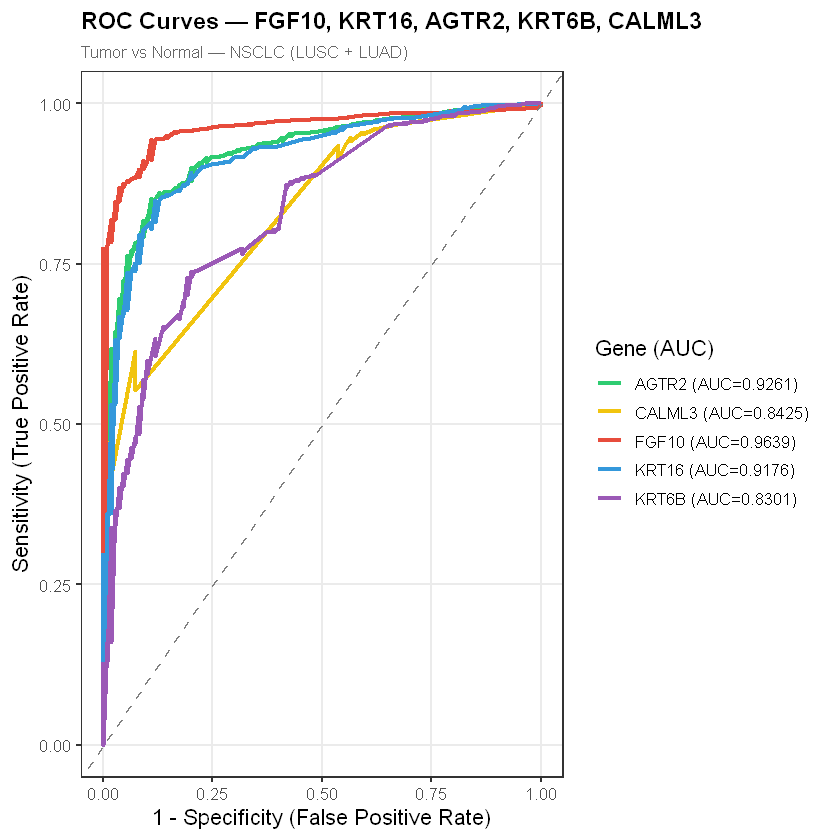

In [16]:
# ============================================================
# ROC STEP 3C: Combined ROC plot all 5 genes
# ============================================================

cat("\n=== Combined ROC Plot ===\n\n")

# Build combined dataframe
combined_roc_df <- data.frame()

for (gene in genes_roc) {
  roc_obj <- roc_objects[[gene]]
  auc_val <- round(as.numeric(auc(roc_obj)), 4)
  
  temp_df <- data.frame(
    Specificity = 1 - roc_obj$specificities,
    Sensitivity = roc_obj$sensitivities,
    Gene        = sprintf("%s (AUC=%.4f)", gene, auc_val)
  )
  combined_roc_df <- rbind(combined_roc_df, temp_df)
}

# Build color map safely with setNames
color_labels <- c(
  sprintf("FGF10 (AUC=%.4f)", round(as.numeric(auc(roc_objects[["FGF10"]])), 4)),
  sprintf("KRT16 (AUC=%.4f)", round(as.numeric(auc(roc_objects[["KRT16"]])), 4)),
  sprintf("AGTR2 (AUC=%.4f)", round(as.numeric(auc(roc_objects[["AGTR2"]])), 4)),
  sprintf("KRT6B (AUC=%.4f)", round(as.numeric(auc(roc_objects[["KRT6B"]])), 4)),
  sprintf("CALML3 (AUC=%.4f)", round(as.numeric(auc(roc_objects[["CALML3"]])), 4))
)

color_values <- c("#E74C3C", "#3498DB", "#2ECC71", "#9B59B6", "#F1C40F")
color_map <- setNames(color_values, color_labels)

# Plot
combined_roc_plot <- ggplot(
  combined_roc_df,
  aes(x = Specificity, y = Sensitivity, color = Gene)
) +
  geom_line(linewidth = 1.2) +
  geom_abline(slope = 1, intercept = 0,
              linetype = "dashed", color = "grey50") +
  scale_color_manual(values = color_map) +
  labs(
    title    = "ROC Curves — FGF10, KRT16, AGTR2, KRT6B, CALML3",
    subtitle = "Tumor vs Normal — NSCLC (LUSC + LUAD)",
    x        = "1 - Specificity (False Positive Rate)",
    y        = "Sensitivity (True Positive Rate)",
    color    = "Gene (AUC)"
  ) +
  theme_bw(base_size = 13) +
  theme(
    plot.title       = element_text(face = "bold", size = 14),
    plot.subtitle    = element_text(color = "gray40", size = 10),
    legend.position  = "right",
    panel.grid.minor = element_blank()
  )

ggsave(
  "ROC_Combined_all_genes.png",
  combined_roc_plot,
  width  = 10,
  height = 7,
  dpi    = 200
)

cat("✔ ROC_Combined_all_genes.png saved\n")
print(combined_roc_plot)


In [17]:
# ============================================================
# ROC STEP 3D: Save AUC results
# ============================================================

write.table(
  auc_results,
  file      = "ROC_AUC_results.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

cat("\n✔ ROC_AUC_results.tsv saved\n")
cat(sprintf("  Location: %s\n", getwd()))

cat("\n============================================================\n")
cat("         ROC ANALYSIS COMPLETE\n")
cat("============================================================\n")
cat("Files saved:\n")
cat("  1. ROC_FGF10.png\n")
cat("  2. ROC_KRT16.png\n")
cat("  3. ROC_AGTR2.png\n")
cat("  4. ROC_KRT6B.png\n")
cat("  5. ROC_CALML3.png\n")
cat("  6. ROC_Combined_all_genes.png\n")
cat("  7. ROC_AUC_results.tsv\n")
cat("============================================================\n")



✔ ROC_AUC_results.tsv saved
  Location: C:/jupyter demo

         ROC ANALYSIS COMPLETE
Files saved:
  1. ROC_FGF10.png
  2. ROC_KRT16.png
  3. ROC_AGTR2.png
  4. ROC_KRT6B.png
  5. ROC_CALML3.png
  6. ROC_Combined_all_genes.png
  7. ROC_AUC_results.tsv


In [18]:
# ============================================================
# Check if survival_df exists and has required columns
# ============================================================

cat("=== Checking Survival Data ===\n\n")

cat(sprintf("survival_df exists: %s\n", exists("survival_df")))

if (exists("survival_df")) {
  cat(sprintf("Rows: %d\n", nrow(survival_df)))
  
  # Check required columns (updated gene groups)
  needed <- c("OS_time", "OS_event", "OS_months",
              "FGF10_group", "KRT16_group",
              "AGTR2_group", "KRT6B_group", "CALML3_group")
  
  for (col in needed) {
    cat(sprintf("  %s: %s\n", col,
                ifelse(col %in% colnames(survival_df),
                       "✔ EXISTS", "✘ MISSING")))
  }
}


=== Checking Survival Data ===

survival_df exists: FALSE


In [19]:
# ============================================================
# Check if survival_df exists and has required columns
# ============================================================

cat("=== Checking Survival Data ===\n\n")

if (!exists("survival_df")) {
  cat("survival_df exists: FALSE → The object 'survival_df' is not in your environment.\n")
} else {
  cat("survival_df exists: TRUE → The object 'survival_df' is available.\n")
  cat(sprintf("Rows: %d\n", nrow(survival_df)))
  
  # Automatically build required gene group columns from genes_roc
  needed <- c("OS_time", "OS_event", "OS_months", paste0(genes_roc, "_group"))
  
  for (col in needed) {
    if (col %in% colnames(survival_df)) {
      cat(sprintf("  %s: ✔ EXISTS\n", col))
    } else {
      cat(sprintf("  %s: ✘ MISSING → Column not found in survival_df\n", col))
    }
  }
}


=== Checking Survival Data ===

survival_df exists: FALSE → The object 'survival_df' is not in your environment.


In [20]:
# Define the true PPI-derived hub genes
hub_genes <- c("FGF10", "KRT16", "AGTR2", "KRT6B", "CALML3")

# Check they exist in your expression matrix (replace 'expr_mat' with your actual object name)
cat("=== Checking hub genes in expression matrix ===\n")
for (g in hub_genes) {
  cat(sprintf("  %s: %s\n", g,
              ifelse(g %in% rownames(expr_mat), "✔ FOUND", "✘ NOT FOUND")))
}

# For each hub gene, compute median-based HIGH/LOW group and attach to survival_df
for (g in hub_genes) {
  # Pull expression vector for this gene, matched to survival_df sample order
  expr_vals <- expr_mat[g, match(rownames(survival_df), colnames(expr_mat))]
  
  med_val <- median(expr_vals, na.rm = TRUE)
  
  survival_df[[paste0(g, "_group")]] <- ifelse(expr_vals > med_val, "HIGH", "LOW")
}

# Re-check
needed <- paste0(hub_genes, "_group")
cat("\n=== Re-checking after adding hub gene groups ===\n")
for (col in needed) {
  cat(sprintf("  %s: %s\n", col,
              ifelse(col %in% colnames(survival_df), "✔ EXISTS", "✘ MISSING")))
}

=== Checking hub genes in expression matrix ===


ERROR: Error: object 'expr_mat' not found


In [21]:
# Define the true PPI-derived hub genes
hub_genes <- c("FGF10", "KRT16", "AGTR2", "KRT6B", "CALML3")

# Check they exist in your expression matrix (replace 'expr_mat' with your actual object name)
cat("=== Checking hub genes in expression matrix ===\n")
for (g in hub_genes) {
  cat(sprintf("  %s: %s\n", g,
              ifelse(g %in% rownames(expr_mat), "✔ FOUND", "✘ NOT FOUND")))
}

# For each hub gene, compute median-based HIGH/LOW group and attach to survival_df
for (g in hub_genes) {
  # Pull expression vector for this gene, matched to survival_df sample order
  expr_vals <- expr_mat[g, match(rownames(survival_df), colnames(expr_mat))]
  
  med_val <- median(expr_vals, na.rm = TRUE)
  
  survival_df[[paste0(g, "_group")]] <- ifelse(expr_vals > med_val, "HIGH", "LOW")
}

# Re-check
needed <- paste0(hub_genes, "_group")
cat("\n=== Re-checking after adding hub gene groups ===\n")
for (col in needed) {
  cat(sprintf("  %s: %s\n", col,
              ifelse(col %in% colnames(survival_df), "✔ EXISTS", "✘ MISSING")))
}

=== Checking hub genes in expression matrix ===


ERROR: Error: object 'expr_mat' not found


In [22]:
# List all objects in memory and their dimensions/types
cat("=== Objects in environment ===\n")
for (obj in ls()) {
  x <- get(obj)
  if (is.matrix(x) || is.data.frame(x)) {
    cat(sprintf("  %-25s class=%-12s dim=%d x %d\n",
                obj, class(x)[1], nrow(x), ncol(x)))
  } else {
    cat(sprintf("  %-25s class=%s\n", obj, class(x)[1]))
  }
}

=== Objects in environment ===
  all_sig_genes             class=character
  auc_ci                    class=ci.auc
  auc_results               class=data.frame   dim=5 x 5
  auc_val                   class=numeric
  color_labels              class=character
  color_map                 class=character
  color_values              class=character
  combined_clinical         class=data.frame   dim=1005 x 100
  combined_roc_df           class=data.frame   dim=2828 x 3
  combined_roc_plot         class=ggplot2::ggplot
  common_cols               class=character
  deg_results               class=data.frame   dim=36650 x 7
  down_genes                class=character
  final_df                  class=data.frame   dim=36650 x 1139
  final_matrix              class=matrix       dim=36650 x 1139
  g                         class=character
  gene                      class=character
  gene_colors               class=character
  genes_roc                 class=character
  hub_genes                 

In [23]:
# if you saved it earlier, e.g.:
load("combat_corrected_expr.RData")
# or
expr_mat <- readRDS("expr_matrix.rds")

Warning message in readChar(con, 5L, useBytes = TRUE):
"cannot open compressed file 'combat_corrected_expr.RData', probable reason 'No such file or directory'"


ERROR: Error in readChar(con, 5L, useBytes = TRUE): cannot open the connection


In [24]:
cat("=== Objects currently in environment ===\n")
if (length(ls()) == 0) {
  cat("Environment is empty — nothing loaded.\n")
} else {
  for (obj in ls()) {
    x <- get(obj)
    if (is.matrix(x) || is.data.frame(x)) {
      cat(sprintf("  %-25s class=%-12s dim=%d x %d\n",
                  obj, class(x)[1], nrow(x), ncol(x)))
    } else {
      cat(sprintf("  %-25s class=%s\n", obj, class(x)[1]))
    }
  }
}

=== Objects currently in environment ===
  all_sig_genes             class=character
  auc_ci                    class=ci.auc
  auc_results               class=data.frame   dim=5 x 5
  auc_val                   class=numeric
  color_labels              class=character
  color_map                 class=character
  color_values              class=character
  combined_clinical         class=data.frame   dim=1005 x 100
  combined_roc_df           class=data.frame   dim=2828 x 3
  combined_roc_plot         class=ggplot2::ggplot
  common_cols               class=character
  deg_results               class=data.frame   dim=36650 x 7
  down_genes                class=character
  final_df                  class=data.frame   dim=36650 x 1139
  final_matrix              class=matrix       dim=36650 x 1139
  g                         class=character
  gene                      class=character
  gene_colors               class=character
  genes_roc                 class=character
  hub_genes       

In [25]:
# 1. Check what's currently stored in hub_genes (in case it's not what we expect)
print(hub_genes)

# 2. Peek at combined_clinical to find survival-related columns
cat("=== Columns in combined_clinical ===\n")
print(colnames(combined_clinical))

[1] "FGF10"  "KRT16"  "AGTR2"  "KRT6B"  "CALML3"
=== Columns in combined_clinical ===
  [1] "project"                                           
  [2] "submitter_id"                                      
  [3] "synchronous_malignancy"                            
  [4] "ajcc_pathologic_stage"                             
  [5] "days_to_diagnosis"                                 
  [6] "laterality"                                        
  [7] "created_datetime"                                  
  [8] "last_known_disease_status"                         
  [9] "tissue_or_organ_of_origin"                         
 [10] "age_at_diagnosis"                                  
 [11] "primary_diagnosis"                                 
 [12] "updated_datetime"                                  
 [13] "prior_malignancy"                                  
 [14] "year_of_diagnosis"                                 
 [15] "state"                                             
 [16] "prior_treatment"      

In [26]:
cat("=== Sample ID formats ===\n")
cat("final_matrix columns (first 5):\n")
print(head(colnames(final_matrix), 5))

cat("\ncombined_clinical submitter_id (first 5):\n")
print(head(combined_clinical$submitter_id, 5))

cat("\ncombined_clinical bcr_patient_barcode (first 5):\n")
print(head(combined_clinical$bcr_patient_barcode, 5))

=== Sample ID formats ===
final_matrix columns (first 5):
[1] "TCGA-60-2698-01A" "TCGA-33-4589-01A" "TCGA-18-3410-01A" "TCGA-60-2715-01A"
[5] "TCGA-22-5471-01A"

combined_clinical submitter_id (first 5):
[1] "TCGA-56-8305" "TCGA-33-4538" "TCGA-18-3409" "TCGA-60-2696" "TCGA-51-6867"

combined_clinical bcr_patient_barcode (first 5):
[1] "TCGA-56-8305" "TCGA-33-4538" "TCGA-18-3409" "TCGA-60-2696" "TCGA-51-6867"


In [27]:
# Truncate final_matrix sample barcodes to patient-level ID (first 12 chars)
expr_patient_id <- substr(colnames(final_matrix), 1, 12)

# Match clinical rows to expression columns
match_idx <- match(expr_patient_id, combined_clinical$submitter_id)

cat(sprintf("Samples matched: %d out of %d\n",
            sum(!is.na(match_idx)), length(match_idx)))

# Build survival_df aligned to final_matrix columns
survival_df <- data.frame(
  sample_id = colnames(final_matrix),
  patient_id = expr_patient_id,
  OS_time   = combined_clinical$OS_time[match_idx],
  OS_event  = combined_clinical$OS_event[match_idx],
  OS_months = combined_clinical$OS_months[match_idx],
  stringsAsFactors = FALSE
)

# Drop samples with no clinical match or missing survival info
survival_df <- survival_df[!is.na(survival_df$OS_time) & !is.na(survival_df$OS_event), ]

cat(sprintf("Final survival_df rows: %d\n", nrow(survival_df)))

Samples matched: 1118 out of 1139
Final survival_df rows: 1118


In [28]:
for (g in hub_genes) {
  expr_vals <- final_matrix[g, survival_df$sample_id]
  med_val <- median(expr_vals, na.rm = TRUE)
  survival_df[[paste0(g, "_group")]] <- ifelse(expr_vals > med_val, "HIGH", "LOW")
}

cat("\n=== Final check ===\n")
needed <- paste0(hub_genes, "_group")
for (col in needed) {
  cat(sprintf("  %s: %s\n", col,
              ifelse(col %in% colnames(survival_df), "✔ EXISTS", "✘ MISSING")))
}


=== Final check ===
  FGF10_group: ✔ EXISTS
  KRT16_group: ✔ EXISTS
  AGTR2_group: ✔ EXISTS
  KRT6B_group: ✔ EXISTS
  CALML3_group: ✔ EXISTS


In [29]:
# ============================================================
# KM PLOT - STEP 1: Individual KM Curves for Each Gene
# ============================================================

cat("=== Generating KM Plots ===\n\n")

# Updated gene list
genes_km <- c("FGF10", "KRT16", "AGTR2", "KRT6B", "CALML3")

for (gene in genes_km) {
  
  cat(sprintf("--- %s ---\n", gene))
  
  # Create survival object
  surv_obj <- Surv(
    time  = survival_df$OS_months,
    event = survival_df$OS_event
  )
  
  # Group column name
  group_col <- paste0(gene, "_group")
  
  # Fit KM model
  km_fit <- survfit(
    surv_obj ~ survival_df[[group_col]]
  )
  
  # Log-rank test
  log_rank <- survdiff(
    surv_obj ~ survival_df[[group_col]]
  )
  
  # Extract p-value
  pval <- 1 - pchisq(log_rank$chisq, df = 1)
  
  cat(sprintf("Log-rank p-value: %.4f\n", pval))
  cat(sprintf("Significant: %s\n\n",
              ifelse(pval < 0.05, "✔ YES", "✘ NO")))
  
  # Draw KM plot
  km_plot <- ggsurvplot(
    km_fit,
    data         = survival_df,
    pval         = TRUE,
    pval.method  = TRUE,
    conf.int     = TRUE,
    risk.table   = TRUE,
    risk.table.height = 0.25,
    palette      = c("#E74C3C", "#3498DB"),
    legend.labs  = c(
      paste0(gene, " HIGH"),
      paste0(gene, " LOW")
    ),
    title        = sprintf(
      "KM Survival Curve — %s Expression", gene),
    xlab         = "Time (Months)",
    ylab         = "Overall Survival Probability",
    legend.title = "Expression Group",
    ggtheme      = theme_bw(base_size = 13)
  )
  
  # Save plot
  png(
    filename = sprintf("KM_%s_OS.png", gene),
    width    = 2400,
    height   = 2000,
    res      = 200
  )
  print(km_plot)
  dev.off()
  
  cat(sprintf("✔ KM_%s_OS.png saved\n\n", gene))
}


=== Generating KM Plots ===

--- FGF10 ---
Log-rank p-value: 0.3092
Significant: ✘ NO



Ignoring unknown labels:
• colour : "Expression Group"


✔ KM_FGF10_OS.png saved

--- KRT16 ---
Log-rank p-value: 0.1487
Significant: ✘ NO



Ignoring unknown labels:
• colour : "Expression Group"


✔ KM_KRT16_OS.png saved

--- AGTR2 ---
Log-rank p-value: 0.4914
Significant: ✘ NO



...

✔ KM_AGTR2_OS.png saved

--- KRT6B ---
Log-rank p-value: 0.7920
Significant: ✘ NO



Ignoring unknown labels:
• colour : "Expression Group"


✔ KM_KRT6B_OS.png saved

--- CALML3 ---
Log-rank p-value: 0.1963
Significant: ✘ NO



Ignoring unknown labels:
• colour : "Expression Group"


✔ KM_CALML3_OS.png saved



In [30]:
library(survival)
library(survminer)  # optional, for KM plots

# ============================================================
# STEP 1: Log-rank test (Kaplan-Meier) for each hub gene
# ============================================================
logrank_results <- data.frame(
  gene = character(),
  logrank_p = numeric(),
  stringsAsFactors = FALSE
)

for (g in hub_genes) {
  group_col <- paste0(g, "_group")
  
  surv_obj <- Surv(time = survival_df$OS_time, event = survival_df$OS_event)
  fit <- survdiff(surv_obj ~ survival_df[[group_col]])
  
  p_val <- 1 - pchisq(fit$chisq, df = 1)
  
  logrank_results <- rbind(logrank_results,
                            data.frame(gene = g, logrank_p = p_val))
}

cat("=== Log-rank (Kaplan-Meier) Results ===\n")
print(logrank_results)


# ============================================================
# STEP 2: Univariate Cox regression (continuous expression)
# ============================================================
univ_results <- data.frame(
  gene = character(),
  HR = numeric(),
  CI_lower = numeric(),
  CI_upper = numeric(),
  p_value = numeric(),
  stringsAsFactors = FALSE
)

for (g in hub_genes) {
  expr_vals <- final_matrix[g, survival_df$sample_id]
  
  surv_obj <- Surv(time = survival_df$OS_time, event = survival_df$OS_event)
  cox_fit <- coxph(surv_obj ~ expr_vals)
  
  s <- summary(cox_fit)
  
  univ_results <- rbind(univ_results, data.frame(
    gene     = g,
    HR       = s$coefficients[1, "exp(coef)"],
    CI_lower = s$conf.int[1, "lower .95"],
    CI_upper = s$conf.int[1, "upper .95"],
    p_value  = s$coefficients[1, "Pr(>|z|)"]
  ))
}

cat("\n=== Univariate Cox Regression Results ===\n")
print(univ_results)


# ============================================================
# STEP 3: Multivariate Cox regression (adjusted for covariates)
# Adjust the covariate list below to match what's available/clean
# in combined_clinical (age, sex, stage, dataset)
# ============================================================

# Merge in clinical covariates matched to survival_df
match_idx <- match(survival_df$patient_id, combined_clinical$submitter_id)

survival_df$age    <- combined_clinical$age_at_index[match_idx]
survival_df$sex    <- combined_clinical$gender[match_idx]
survival_df$stage  <- combined_clinical$ajcc_pathologic_stage[match_idx]
survival_df$dataset <- combined_clinical$Dataset[match_idx]

multiv_results <- data.frame(
  gene     = character(),
  HR       = numeric(),
  CI_lower = numeric(),
  CI_upper = numeric(),
  p_value  = numeric(),
  stringsAsFactors = FALSE
)

for (g in hub_genes) {
  expr_vals <- final_matrix[g, survival_df$sample_id]
  
  surv_obj <- Surv(time = survival_df$OS_time, event = survival_df$OS_event)
  
  cox_fit <- coxph(surv_obj ~ expr_vals + age + sex + stage + dataset,
                    data = survival_df)
  
  s <- summary(cox_fit)
  
  multiv_results <- rbind(multiv_results, data.frame(
    gene     = g,
    HR       = s$coefficients["expr_vals", "exp(coef)"],
    CI_lower = s$conf.int["expr_vals", "lower .95"],
    CI_upper = s$conf.int["expr_vals", "upper .95"],
    p_value  = s$coefficients["expr_vals", "Pr(>|z|)"]
  ))
}

cat("\n=== Multivariate Cox Regression Results (adjusted) ===\n")
print(multiv_results)


# ============================================================
# STEP 4: Combine everything and flag genes that PASS
# Criteria: significant in log-rank AND/OR univariate/multivariate Cox
# ============================================================
final_summary <- data.frame(
  gene            = hub_genes,
  logrank_p       = logrank_results$logrank_p,
  univ_cox_p      = univ_results$p_value,
  univ_cox_HR     = univ_results$HR,
  multiv_cox_p    = multiv_results$p_value,
  multiv_cox_HR   = multiv_results$HR
)

final_summary$prognostic_pass <- with(final_summary,
  logrank_p < 0.05 | univ_cox_p < 0.05 | multiv_cox_p < 0.05
)

cat("\n=== FINAL SUMMARY: Which genes pass as prognostic biomarkers ===\n")
print(final_summary)

cat("\nGenes that PASS (significant in at least one test):\n")
print(final_summary$gene[final_summary$prognostic_pass])

=== Log-rank (Kaplan-Meier) Results ===
    gene logrank_p
1  FGF10 0.3091684
2  KRT16 0.1487381
3  AGTR2 0.4913515
4  KRT6B 0.7919734
5 CALML3 0.1962661

=== Univariate Cox Regression Results ===
    gene        HR  CI_lower  CI_upper     p_value
1  FGF10 1.0012896 0.9632860 1.0407926 0.947949723
2  KRT16 1.0123711 0.9845048 1.0410261 0.387933670
3  AGTR2 1.0150309 0.9881555 1.0426373 0.275852847
4  KRT6B 1.0083515 0.9807154 1.0367663 0.557493648
5 CALML3 0.9457324 0.9099119 0.9829629 0.004622463

=== Multivariate Cox Regression Results (adjusted) ===
    gene        HR  CI_lower  CI_upper     p_value
1  FGF10 1.0146754 0.9750311 1.0559317 0.473707912
2  KRT16 1.0012006 0.9728575 1.0303695 0.934731465
3  AGTR2 1.0313345 1.0034700 1.0599729 0.027255451
4  KRT6B 0.9975862 0.9695450 1.0264384 0.868053054
5 CALML3 0.9332886 0.8973586 0.9706573 0.000567293

=== FINAL SUMMARY: Which genes pass as prognostic biomarkers ===
    gene logrank_p  univ_cox_p univ_cox_HR multiv_cox_p multiv_cox_HR

Ignoring unknown labels:
• colour : "AGTR2"
Ignoring unknown labels:
• colour : "CALML3"


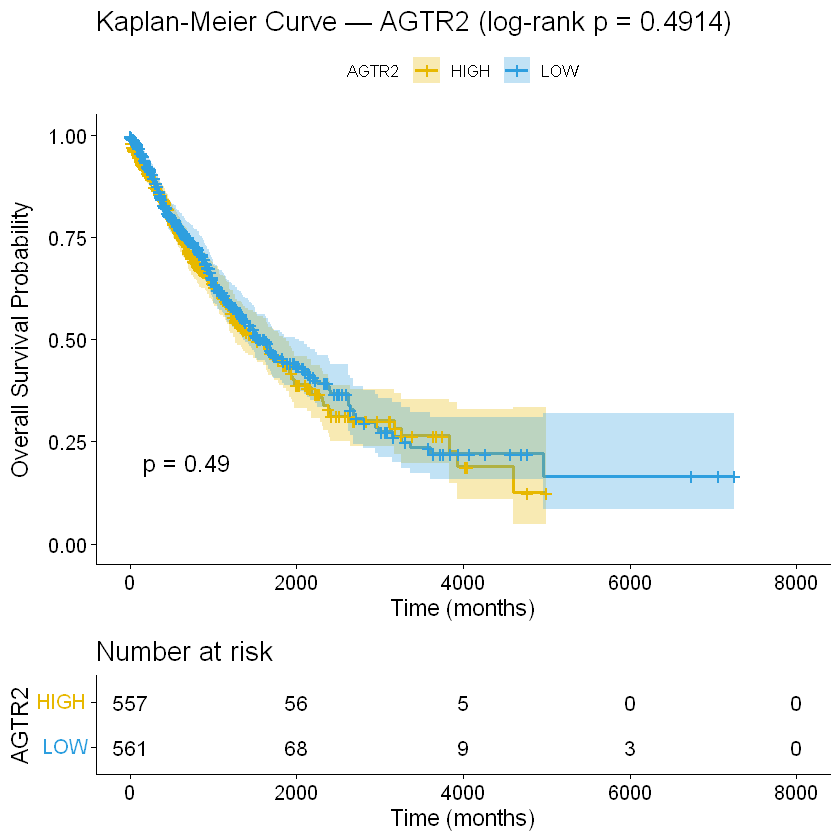


Attaching package: 'gridExtra'


The following object is masked from 'package:dplyr':

    combine


Ignoring unknown labels:
• colour : "AGTR2"
Ignoring unknown labels:
• colour : "CALML3"


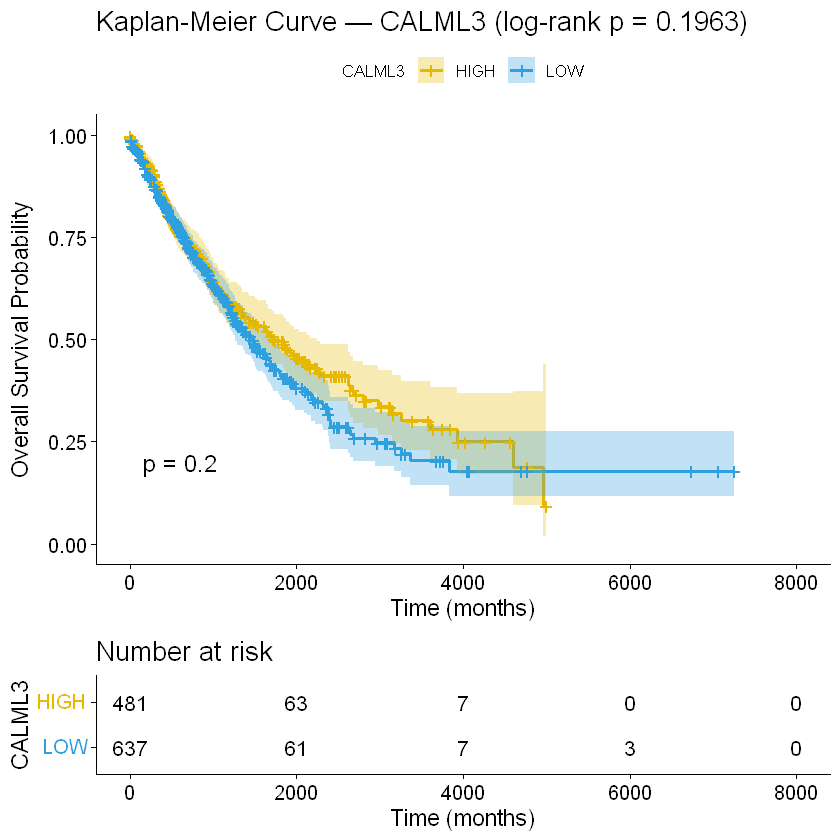

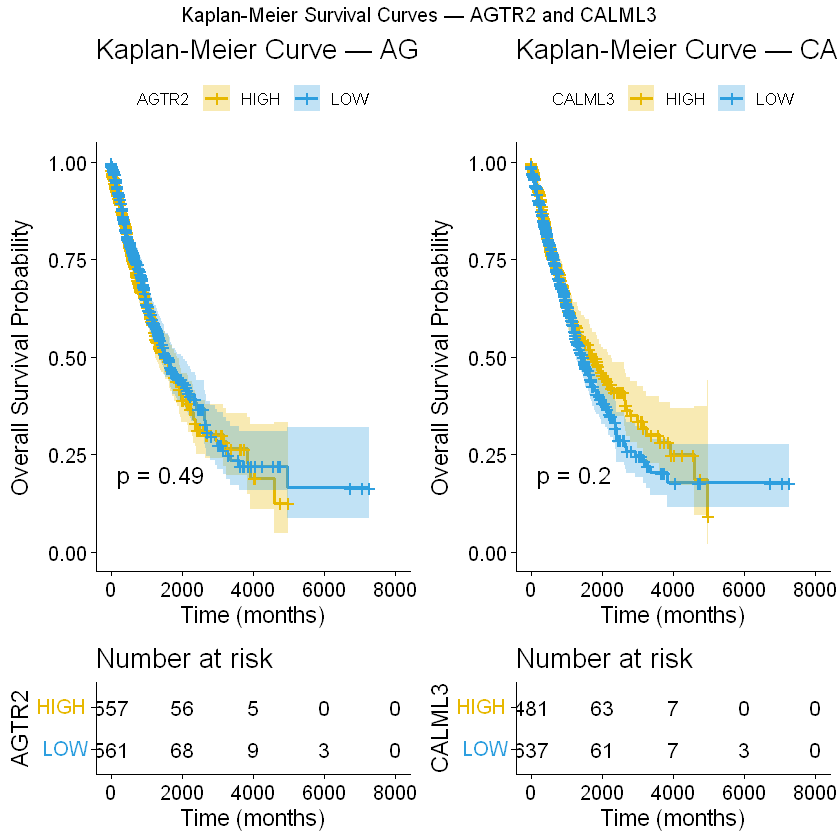

In [31]:
library(survival)
library(survminer)

# Genes to plot
genes_to_plot <- c("AGTR2", "CALML3")

# Build survival object once
surv_obj <- Surv(time = survival_df$OS_time, event = survival_df$OS_event)

# ============================================================
# Individual KM plots
# ============================================================
km_plots <- list()

for (g in genes_to_plot) {
  group_col <- paste0(g, "_group")
  
  fit <- survfit(surv_obj ~ survival_df[[group_col]])
  
  # log-rank p-value for the title
  diff_test <- survdiff(surv_obj ~ survival_df[[group_col]])
  p_val <- 1 - pchisq(diff_test$chisq, df = 1)
  
  p <- ggsurvplot(
    fit,
    data       = survival_df,
    pval       = TRUE,
    conf.int   = TRUE,
    risk.table = TRUE,
    palette    = c("#E7B800", "#2E9FDF"),
    legend.labs = c("HIGH", "LOW"),
    legend.title = g,
    title      = sprintf("Kaplan-Meier Curve — %s (log-rank p = %.4f)", g, p_val),
    xlab       = "Time (months)",
    ylab       = "Overall Survival Probability"
  )
  
  km_plots[[g]] <- p
  print(p)
}

# ============================================================
# Combined 1x2 panel (AGTR2 + CALML3 side by side)
# ============================================================
library(gridExtra)

arrange_ggsurvplots(
  km_plots,
  print = TRUE,
  ncol = 2,
  nrow = 1,
  title = "Kaplan-Meier Survival Curves — AGTR2 and CALML3"
)

In [32]:
library(survival)

# ============================================================
# Prognostic Biomarker Pass/Fail Checker
# ============================================================

genes_to_test <- hub_genes   # or specify manually: c("FGF10","KRT16","AGTR2","KRT6B","CALML3")

surv_obj <- Surv(time = survival_df$OS_time, event = survival_df$OS_event)

results <- data.frame(
  gene         = character(),
  logrank_p    = numeric(),
  cox_p        = numeric(),
  cox_HR       = numeric(),
  cox_CI_lower = numeric(),
  cox_CI_upper = numeric(),
  verdict      = character(),
  stringsAsFactors = FALSE
)

for (g in genes_to_test) {
  
  group_col <- paste0(g, "_group")
  
  # --- Log-rank test (KM) ---
  lr_fit <- survdiff(surv_obj ~ survival_df[[group_col]])
  logrank_p <- 1 - pchisq(lr_fit$chisq, df = 1)
  
  # --- Univariate Cox (continuous expression) ---
  expr_vals <- final_matrix[g, survival_df$sample_id]
  cox_fit <- coxph(surv_obj ~ expr_vals)
  cox_summary <- summary(cox_fit)
  
  cox_p    <- cox_summary$coefficients[1, "Pr(>|z|)"]
  cox_hr   <- cox_summary$coefficients[1, "exp(coef)"]
  cox_lo   <- cox_summary$conf.int[1, "lower .95"]
  cox_hi   <- cox_summary$conf.int[1, "upper .95"]
  
  # --- Verdict: significant in EITHER log-rank OR Cox (p < 0.05) ---
  verdict <- ifelse(logrank_p < 0.05 | cox_p < 0.05, "PASS", "FAIL")
  
  results <- rbind(results, data.frame(
    gene         = g,
    logrank_p    = round(logrank_p, 4),
    cox_p        = round(cox_p, 4),
    cox_HR       = round(cox_hr, 3),
    cox_CI_lower = round(cox_lo, 3),
    cox_CI_upper = round(cox_hi, 3),
    verdict      = verdict
  ))
}

# ============================================================
# Print results
# ============================================================
cat("=== Prognostic Biomarker Test Results ===\n\n")
print(results)

cat("\n=== Genes that PASS as prognostic biomarkers ===\n")
pass_genes <- results$gene[results$verdict == "PASS"]
if (length(pass_genes) > 0) {
  print(pass_genes)
} else {
  cat("None of the tested genes reached statistical significance.\n")
}

cat("\n=== Genes that FAIL ===\n")
fail_genes <- results$gene[results$verdict == "FAIL"]
print(fail_genes)

=== Prognostic Biomarker Test Results ===

    gene logrank_p  cox_p cox_HR cox_CI_lower cox_CI_upper verdict
1  FGF10    0.3092 0.9479  1.001        0.963        1.041    FAIL
2  KRT16    0.1487 0.3879  1.012        0.985        1.041    FAIL
3  AGTR2    0.4914 0.2759  1.015        0.988        1.043    FAIL
4  KRT6B    0.7920 0.5575  1.008        0.981        1.037    FAIL
5 CALML3    0.1963 0.0046  0.946        0.910        0.983    PASS

=== Genes that PASS as prognostic biomarkers ===
[1] "CALML3"

=== Genes that FAIL ===
[1] "FGF10" "KRT16" "AGTR2" "KRT6B"


Ignoring unknown labels:
• colour : "CALML3"
Ignoring unknown labels:
• colour : "CALML3"


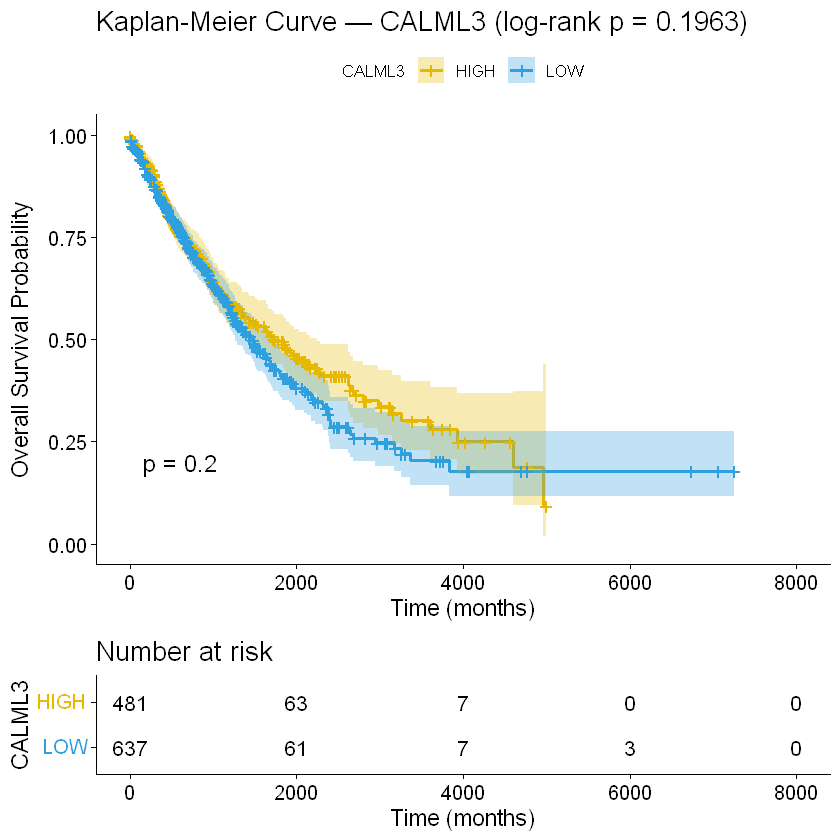

Saved: C:/jupyter demo/KM_CALML3.png


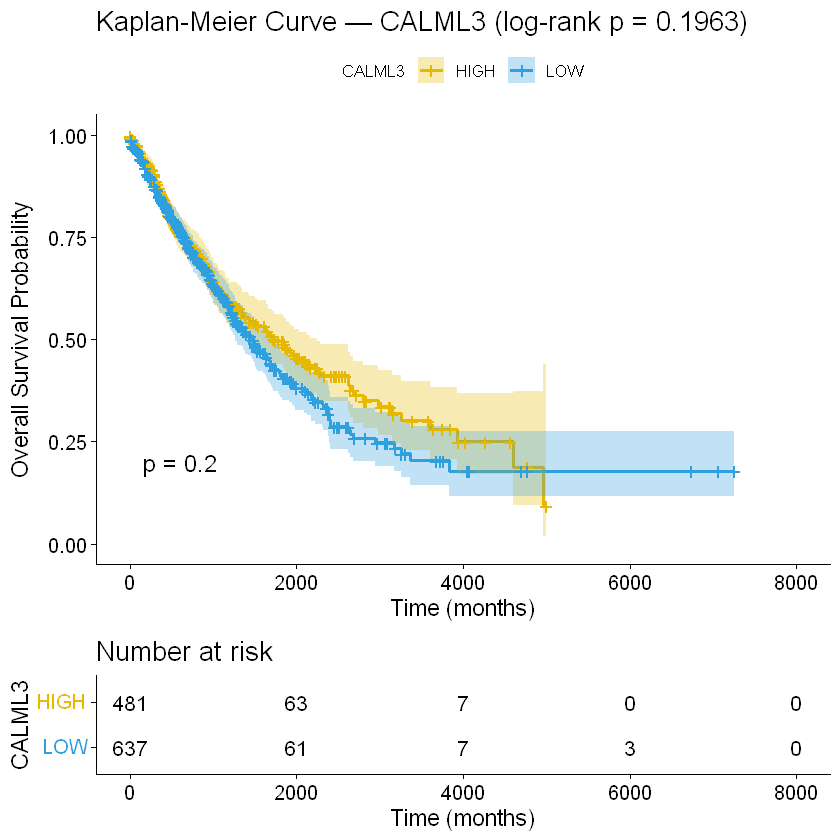

In [33]:
library(survival)
library(survminer)

# ============================================================
# Generate and save KM plot for CALML3
# ============================================================

g <- "CALML3"
group_col <- paste0(g, "_group")

surv_obj <- Surv(time = survival_df$OS_time, event = survival_df$OS_event)

# Fit KM model
fit <- survfit(surv_obj ~ survival_df[[group_col]])

# Log-rank p-value
diff_test <- survdiff(surv_obj ~ survival_df[[group_col]])
p_val <- 1 - pchisq(diff_test$chisq, df = 1)

# Build the plot
km_plot <- ggsurvplot(
  fit,
  data         = survival_df,
  pval         = TRUE,
  conf.int     = TRUE,
  risk.table   = TRUE,
  palette      = c("#E7B800", "#2E9FDF"),
  legend.labs  = c("HIGH", "LOW"),
  legend.title = g,
  title        = sprintf("Kaplan-Meier Curve — %s (log-rank p = %.4f)", g, p_val),
  xlab         = "Time (months)",
  ylab         = "Overall Survival Probability"
)

# Print to screen
print(km_plot)

# ============================================================
# Save to file (PNG)
# ============================================================
# ggsurvplot objects need special handling since they contain 
# multiple panels (plot + risk table) — use survminer's built-in save
ggsave(
  filename = "KM_CALML3.png",
  plot     = print(km_plot),   # print() renders the combined grid
  width    = 8,
  height   = 8,
  dpi      = 300
)

cat(sprintf("Saved: %s\n", file.path(getwd(), "KM_CALML3.png")))

In [34]:
# Get exact numbers for report
cat("=== Numbers for Report ===\n\n")

# Cox regression results
cat("--- Cox Regression ---\n")
print(all_cox_results[, c("Gene", "HR", "CI_lower",
                           "CI_upper", "P_value", "Analysis")])

# KM results
cat("\n--- KM Log-rank Results ---\n")
print(km_summary)

# AUC results
cat("\n--- ROC AUC Results ---\n")
print(auc_results)

# Sample counts
cat("\n--- Sample Counts ---\n")
cat(sprintf("Total patients: %d\n", nrow(survival_df)))
cat(sprintf("Dead:           %d\n",
            sum(survival_df$OS_event == 1)))
cat(sprintf("Alive:          %d\n",
            sum(survival_df$OS_event == 0)))

=== Numbers for Report ===

--- Cox Regression ---


ERROR: Error: object 'all_cox_results' not found


In [1]:
# ============================================================
# STEP 1: Load All Required Packages
# ============================================================

library(survival)
library(survminer)
library(pROC)
library(ggplot2)
library(dplyr)
library(data.table)

cat("✔ All packages loaded\n")

Loading required package: ggplot2

Loading required package: ggpubr


Attaching package: 'survminer'


The following object is masked from 'package:survival':

    myeloma


Warning message:
"package 'pROC' was built under R version 4.6.1"
Type 'citation("pROC")' for a citation.


Attaching package: 'pROC'


The following objects are masked from 'package:stats':

    cov, smooth, var


Warning message:
"package 'dplyr' was built under R version 4.6.1"

Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union



Attaching package: 'data.table'


The following objects are masked from 'package:dplyr':

    between, first, last


The following object is masked from 'package:base':

    %notin%




✔ All packages loaded


In [2]:
# ============================================================
# Rebuild survival data if needed
# ============================================================

cat("Checking required objects...\n\n")

if (!exists("survival_df")) {
  cat("Rebuilding survival data...\n")

  # Load final matrix
  final_df <- read.table(
    "C:/Users/aryan/Downloads/TCGA_LUSC_LUAD_final_expression.tsv",
    header = TRUE, sep = "\t",
    row.names = 1, check.names = FALSE)
  final_matrix <- as.matrix(final_df)

  # Load clinical data
  lusc_clin <- read.table(
    "C:/jupyter demo/LUSC_clinical.tsv",
    header = TRUE, sep = "\t",
    check.names = FALSE)
  luad_clin <- read.table(
    "C:/jupyter demo/LUAD_clinical.tsv",
    header = TRUE, sep = "\t",
    check.names = FALSE)

  common_cols <- intersect(
    colnames(lusc_clin),
    colnames(luad_clin))
  lusc_clin$Dataset <- "LUSC"
  luad_clin$Dataset <- "LUAD"

  combined_clinical <- rbind(
    lusc_clin[, c(common_cols, "Dataset")],
    luad_clin[, c(common_cols, "Dataset")])

  combined_clinical$OS_time <- ifelse(
    combined_clinical$vital_status == "Dead",
    as.numeric(combined_clinical$days_to_death),
    as.numeric(
      combined_clinical$days_to_last_follow_up))
  combined_clinical$OS_event <- ifelse(
    combined_clinical$vital_status == "Dead",
    1, 0)
  combined_clinical$OS_months <-
    combined_clinical$OS_time / 30.44
  combined_clinical <- combined_clinical[
    !is.na(combined_clinical$OS_time) &
    combined_clinical$OS_time > 0, ]

  # Extract MMP13 expression
  expr_sub <- t(final_matrix[
    "MMP13", , drop = FALSE])
  expr_df  <- as.data.frame(expr_sub)
  expr_df$submitter_id <- substr(
    rownames(expr_df), 1, 12)

  survival_df <- merge(
    combined_clinical, expr_df,
    by = "submitter_id")

  cat(sprintf("✔ survival_df: %d patients\n",
              nrow(survival_df)))
} else {
  cat(sprintf("✔ survival_df exists: %d patients\n",
              nrow(survival_df)))
}

Checking required objects...

Rebuilding survival data...
✔ survival_df: 1118 patients


In [3]:
# ============================================================
# STEP 2: Prepare MMP13 HIGH/LOW Groups
# ============================================================

cat("=== Preparing MMP13 Expression Groups ===\n\n")

# Check MMP13 column exists
if (!"MMP13" %in% colnames(survival_df)) {
  cat("Adding MMP13 expression...\n")
  survival_df$MMP13 <- as.numeric(
    final_matrix["MMP13",
                  match(survival_df$submitter_id,
                        substr(colnames(
                          final_matrix), 1, 12))])
}

# Calculate median
mmp13_median <- median(survival_df$MMP13,
                       na.rm = TRUE)
cat(sprintf("MMP13 median expression: %.4f\n",
            mmp13_median))

# Stratify into HIGH and LOW groups
survival_df$MMP13_group <- factor(
  ifelse(survival_df$MMP13 >= mmp13_median,
         "HIGH", "LOW"),
  levels = c("LOW", "HIGH")
)

# Count groups
cat(sprintf("HIGH expression: %d patients\n",
            sum(survival_df$MMP13_group == "HIGH")))
cat(sprintf("LOW expression:  %d patients\n",
            sum(survival_df$MMP13_group == "LOW")))

# Sample type
survival_df$SampleType <- ifelse(
  substr(survival_df$submitter_id, 14, 15) == "11",
  "Normal", "Tumor"
)

cat(sprintf("\nTumor samples:  %d\n",
            sum(survival_df$SampleType == "Tumor",
                na.rm = TRUE)))
cat(sprintf("Normal samples: %d\n",
            sum(survival_df$SampleType == "Normal",
                na.rm = TRUE)))

# Preview
cat("\nFirst 5 rows:\n")
print(head(survival_df[,
  c("submitter_id", "MMP13",
    "MMP13_group", "OS_months",
    "OS_event")], 5))

=== Preparing MMP13 Expression Groups ===

MMP13 median expression: 7.8506
HIGH expression: 559 patients
LOW expression:  559 patients

Tumor samples:  1118
Normal samples: 0

First 5 rows:
  submitter_id     MMP13 MMP13_group OS_months OS_event
1 TCGA-05-4249 12.975329        HIGH 50.032852        0
2 TCGA-05-4250  9.445004        HIGH  3.975033        1
3 TCGA-05-4382  9.170644        HIGH 19.940867        0
4 TCGA-05-4384  9.954187        HIGH 13.994744        0
5 TCGA-05-4389  8.778586        HIGH 44.973719        0


In [4]:
# ============================================================
# STEP 3: Kaplan-Meier Survival Analysis
# ============================================================

cat("=== KM Survival Analysis — MMP13 ===\n\n")

# Create survival object
surv_obj <- Surv(
  time  = survival_df$OS_months,
  event = survival_df$OS_event
)

# Fit KM model
km_fit <- survfit(
  surv_obj ~ MMP13_group,
  data = survival_df
)

# Log-rank test
log_rank <- survdiff(
  surv_obj ~ MMP13_group,
  data = survival_df
)

# Extract p-value
pval <- 1 - pchisq(log_rank$chisq, df = 1)

cat(sprintf("Log-rank p-value: %.4f\n", pval))
cat(sprintf("Significant:      %s\n",
            ifelse(pval < 0.05,
                   "YES ✔", "NO ✘")))

# Median survival
cat("\nMedian survival:\n")
print(summary(km_fit)$table)

=== KM Survival Analysis — MMP13 ===

Log-rank p-value: 0.0465
Significant:      YES ✔

Median survival:
                 records n.max n.start events    rmean se(rmean)   median
MMP13_group=LOW      559   559     559    249 74.25201  5.949293 45.30223
MMP13_group=HIGH     559   559     559    203 95.04312  7.307706 58.80420
                  0.95LCL  0.95UCL
MMP13_group=LOW  41.32720 54.40210
MMP13_group=HIGH 48.78449 73.88305



=== Plotting KM Curve ===



agg_record_2b3c46351a03 
                      2

✔ KM_MMP13_OS.png saved


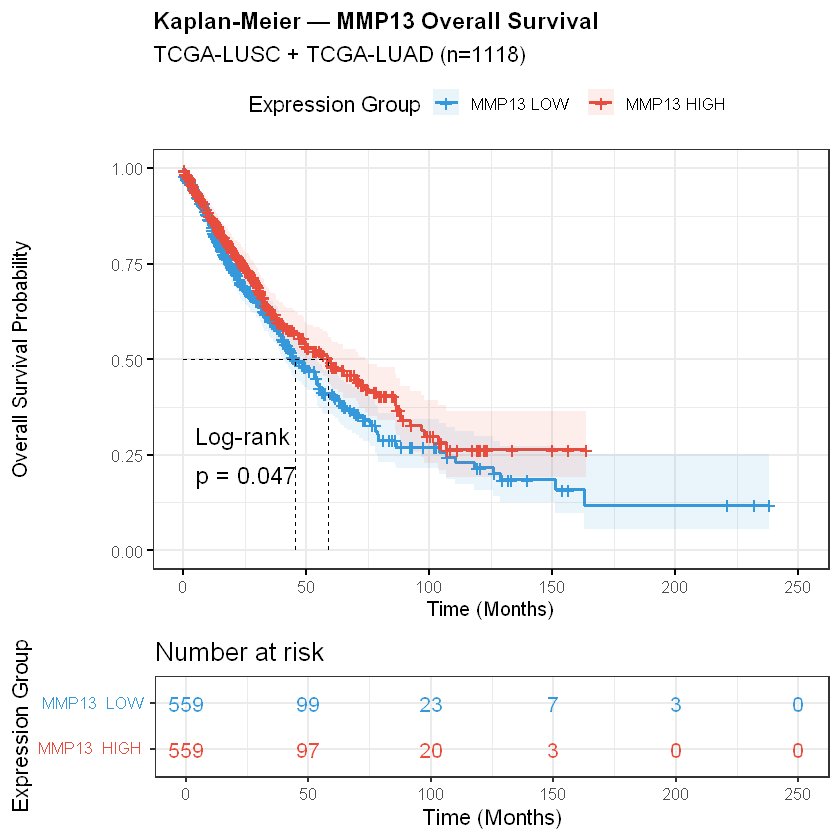

In [5]:
# ============================================================
# Plot KM Curve
# ============================================================

cat("\n=== Plotting KM Curve ===\n\n")

km_plot <- ggsurvplot(
  km_fit,
  data             = survival_df,
  pval             = TRUE,
  pval.method      = TRUE,
  conf.int         = TRUE,
  conf.int.alpha   = 0.1,
  risk.table       = TRUE,
  risk.table.height = 0.25,
  risk.table.col   = "strata",
  palette          = c("#3498DB", "#E74C3C"),
  legend.labs      = c("MMP13 LOW",
                       "MMP13 HIGH"),
  legend.title     = "Expression Group",
  title            = "Kaplan-Meier — MMP13 Overall Survival",
  subtitle         = "TCGA-LUSC + TCGA-LUAD (n=1118)",
  xlab             = "Time (Months)",
  ylab             = "Overall Survival Probability",
  ggtheme          = theme_bw(base_size = 13),
  font.main        = c(14, "bold"),
  font.x           = c(12, "plain"),
  font.y           = c(12, "plain"),
  surv.median.line = "hv"
)

# Save
png(
  filename = "C:/jupyter demo/KM_MMP13_OS.png",
  width    = 2800,
  height   = 2400,
  res      = 200
)
print(km_plot)
dev.off()

cat("✔ KM_MMP13_OS.png saved\n")
print(km_plot)

In [6]:
# ============================================================
# Optimal Cutoff KM (Fix 2)
# ============================================================

cat("\n=== KM with Optimal Cutoff ===\n\n")

# Find optimal cutoff using survminer
opt_cut <- surv_cutpoint(
  survival_df,
  time     = "OS_months",
  event    = "OS_event",
  variables = "MMP13"
)

cat("Optimal cutoff:\n")
print(summary(opt_cut))

# Apply optimal cutoff
survival_df$MMP13_optimal <- surv_categorize(
  opt_cut)$MMP13

# Refit with optimal cutoff
km_fit_opt <- survfit(
  Surv(OS_months, OS_event) ~ MMP13_optimal,
  data = survival_df
)

# Log-rank with optimal cutoff
log_rank_opt <- survdiff(
  Surv(OS_months, OS_event) ~ MMP13_optimal,
  data = survival_df
)
pval_opt <- 1 - pchisq(
  log_rank_opt$chisq, df = 1)

cat(sprintf("\nOptimal cutoff p-value: %.4f\n",
            pval_opt))
cat(sprintf("Significant: %s\n",
            ifelse(pval_opt < 0.05,
                   "YES ✔", "NO ✘")))


=== KM with Optimal Cutoff ===

Optimal cutoff:
      cutpoint statistic
MMP13 7.672161  2.197257

Optimal cutoff p-value: 0.0280
Significant: YES ✔


In [7]:
# ============================================================
# STEP 4A: Prepare Cox Data
# ============================================================

cat("=== Preparing Cox Regression Data ===\n\n")

# Add clinical covariates
survival_df$age <- as.numeric(
  survival_df$age_at_index)

survival_df$sex <- ifelse(
  survival_df$gender == "male", 1, 0)

survival_df$stage <- case_when(
  grepl("Stage I$|Stage IA|Stage IB",
        survival_df$ajcc_pathologic_stage,
        ignore.case = TRUE) ~ "I",
  grepl("Stage II|Stage IIA|Stage IIB",
        survival_df$ajcc_pathologic_stage,
        ignore.case = TRUE) ~ "II",
  grepl("Stage III|Stage IIIA|Stage IIIB",
        survival_df$ajcc_pathologic_stage,
        ignore.case = TRUE) ~ "III",
  grepl("Stage IV",
        survival_df$ajcc_pathologic_stage,
        ignore.case = TRUE) ~ "IV",
  TRUE ~ NA_character_
)

survival_df$stage <- factor(
  survival_df$stage,
  levels = c("I", "II", "III", "IV"))

survival_df$dataset <- factor(
  survival_df$Dataset,
  levels = c("LUSC", "LUAD"))

# Use optimal cutoff group
survival_df$MMP13_optimal <- factor(
  survival_df$MMP13_optimal,
  levels = c("low", "high"))

# Filter complete cases
cox_data <- survival_df[
  !is.na(survival_df$age) &
  !is.na(survival_df$sex) &
  !is.na(survival_df$stage) &
  !is.na(survival_df$MMP13_optimal), ]

cat(sprintf("Patients for Cox: %d\n",
            nrow(cox_data)))
cat(sprintf("Dead:    %d\n",
            sum(cox_data$OS_event == 1)))
cat(sprintf("Alive:   %d\n",
            sum(cox_data$OS_event == 0)))
cat("\nStage distribution:\n")
print(table(cox_data$stage))

=== Preparing Cox Regression Data ===

Patients for Cox: 1090
Dead:    445
Alive:   645

Stage distribution:

  I  II III  IV 
569 487   0  34 


In [8]:
# ============================================================
# STEP 4B: Univariate Cox Regression
# ============================================================

cat("\n=== Univariate Cox Regression ===\n\n")

surv_obj_cox <- Surv(
  time  = cox_data$OS_months,
  event = cox_data$OS_event
)

# MMP13 univariate
cox_uni_mmp13 <- coxph(
  surv_obj_cox ~ MMP13_optimal,
  data = cox_data
)

hr_uni  <- exp(coef(cox_uni_mmp13))
ci_uni  <- exp(confint(cox_uni_mmp13))
p_uni   <- summary(cox_uni_mmp13)$coefficients[, 5]

cat(sprintf("MMP13 Univariate:\n"))
cat(sprintf("  HR:      %.3f\n", hr_uni))
cat(sprintf("  95%% CI:  [%.3f - %.3f]\n",
            ci_uni[1], ci_uni[2]))
cat(sprintf("  p-value: %.4f\n", p_uni))
cat(sprintf("  Result:  %s\n",
            ifelse(p_uni < 0.05 & hr_uni > 1,
                   "✔ Poor prognosis marker",
                   ifelse(p_uni < 0.05 & hr_uni < 1,
                          "✔ Good prognosis marker",
                          "✘ Not significant"))))

# Univariate for covariates
cat("\nUnivariate for all covariates:\n\n")

covariates <- list(
  "MMP13 (HIGH vs LOW)" = "MMP13_optimal",
  "Age"                 = "age",
  "Sex (Male vs Female)"= "sex",
  "Stage"               = "stage",
  "Dataset (LUAD vs LUSC)" = "dataset"
)

uni_results <- data.frame()

for (name in names(covariates)) {
  var <- covariates[[name]]
  formula <- as.formula(
    paste0("surv_obj_cox ~ ", var))
  fit <- coxph(formula, data = cox_data)
  s   <- summary(fit)

  hr  <- exp(coef(fit))[1]
  ci  <- exp(confint(fit))[1, ]
  p   <- s$coefficients[1, 5]

  cat(sprintf("%-25s HR=%.3f [%.3f-%.3f] p=%.4f %s\n",
              name, hr, ci[1], ci[2], p,
              ifelse(p < 0.05, "✔", "")))

  uni_results <- rbind(uni_results, data.frame(
    Variable = name,
    HR       = round(hr, 3),
    CI_lower = round(ci[1], 3),
    CI_upper = round(ci[2], 3),
    P_value  = round(p, 4),
    Analysis = "Univariate"
  ))
}


=== Univariate Cox Regression ===

MMP13 Univariate:
  HR:      0.836
  95% CI:  [0.693 - 1.007]
  p-value: 0.0588
  Result:  ✘ Not significant

Univariate for all covariates:

MMP13 (HIGH vs LOW)       HR=0.836 [0.693-1.007] p=0.0588 
Age                       HR=1.011 [1.001-1.022] p=0.0385 ✔
Sex (Male vs Female)      HR=1.246 [1.027-1.513] p=0.0260 ✔
Stage                     HR=1.773 [1.463-2.149] p=0.0000 ✔
Dataset (LUAD vs LUSC)    HR=0.867 [0.718-1.046] p=0.1351 


In [9]:
# ============================================================
# STEP 4C: Multivariate Cox Regression
# ============================================================

cat("\n=== Multivariate Cox Regression ===\n\n")

cox_multi <- coxph(
  Surv(OS_months, OS_event) ~
    MMP13_optimal + age + sex + stage + dataset,
  data = cox_data
)

# Summary
multi_summary <- summary(cox_multi)
cat("Multivariate Cox Results:\n\n")
print(multi_summary$coefficients)

# Extract MMP13 specific results
mmp13_row <- "MMP13_optimalhigh"

hr_multi  <- exp(
  multi_summary$coefficients[mmp13_row, "coef"])
ci_multi  <- exp(
  confint(cox_multi)[mmp13_row, ])
p_multi   <- multi_summary$coefficients[
  mmp13_row, "Pr(>|z|)"]

cat(sprintf("\n--- MMP13 Multivariate Results ---\n"))
cat(sprintf("HR:      %.3f\n", hr_multi))
cat(sprintf("95%% CI:  [%.3f - %.3f]\n",
            ci_multi[1], ci_multi[2]))
cat(sprintf("p-value: %.4f\n", p_multi))
cat(sprintf("Result:  %s\n",
            ifelse(p_multi < 0.05 & hr_multi > 1,
                   "✔ Independent poor prognosis marker",
                   ifelse(p_multi < 0.05,
                          "✔ Significant",
                          "✘ Not significant after adjustment"))))


=== Multivariate Cox Regression ===

Multivariate Cox Results:

                         coef exp(coef)    se(coef)          z     Pr(>|z|)
MMP13_optimalhigh -0.19093797 0.8261838 0.095293231 -2.0036887 4.510342e-02
age                0.01407173 1.0141712 0.005393645  2.6089461 9.082154e-03
sex                0.12830903 1.1369043 0.102986667  1.2458800 2.128085e-01
stageII            0.57865542 1.7836386 0.099015714  5.8440766 5.093859e-09
stageIII                   NA        NA 0.000000000         NA           NA
stageIV            1.16421656 3.2034122 0.228376300  5.0977994 3.436247e-07
datasetLUAD       -0.06932852 0.9330201 0.101729324 -0.6814998 4.955553e-01

--- MMP13 Multivariate Results ---
HR:      0.826
95% CI:  [0.685 - 0.996]
p-value: 0.0451
Result:  ✔ Significant


In [10]:
# ============================================================
# STEP 4D: Build multivariate results table
# ============================================================

cat("\n=== Building Full Results Table ===\n\n")

# Extract all multivariate results
coef_names <- rownames(
  multi_summary$coefficients)
multi_results <- data.frame()

for (coef_name in coef_names) {
  hr  <- exp(multi_summary$coefficients[
    coef_name, "coef"])
  ci  <- exp(confint(cox_multi)[coef_name, ])
  p   <- multi_summary$coefficients[
    coef_name, "Pr(>|z|)"]

  multi_results <- rbind(multi_results,
    data.frame(
      Variable = coef_name,
      HR       = round(hr, 3),
      CI_lower = round(ci[1], 3),
      CI_upper = round(ci[2], 3),
      P_value  = round(p, 4),
      Analysis = "Multivariate"
    ))
}

cat("Multivariate results:\n")
print(multi_results)

# Combine uni and multi
all_cox <- rbind(uni_results, multi_results)

# Save
write.table(
  all_cox,
  file      = "MMP13_Cox_results.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

cat("\n✔ MMP13_Cox_results.tsv saved\n")


=== Building Full Results Table ===

Multivariate results:
                Variable    HR CI_lower CI_upper P_value     Analysis
2.5 %  MMP13_optimalhigh 0.826    0.685    0.996  0.0451 Multivariate
2.5 %1               age 1.014    1.004    1.025  0.0091 Multivariate
2.5 %2               sex 1.137    0.929    1.391  0.2128 Multivariate
2.5 %3           stageII 1.784    1.469    2.166  0.0000 Multivariate
2.5 %4          stageIII    NA       NA       NA      NA Multivariate
2.5 %5           stageIV 3.203    2.047    5.012  0.0000 Multivariate
2.5 %6       datasetLUAD 0.933    0.764    1.139  0.4956 Multivariate

✔ MMP13_Cox_results.tsv saved



=== Forest Plot ===



Warning message:
"`geom_errorbarh()` was deprecated in ggplot2 4.0.0.
ℹ Please use the `orientation` argument of `geom_errorbar()` instead."
`height` was translated to `width`.
Warning message:
"Removed 1 row containing missing values or values outside the scale range (`geom_point()`)."


✔ MMP13_Forest_plot.png saved


`height` was translated to `width`.
Warning message:
"Removed 1 row containing missing values or values outside the scale range (`geom_point()`)."


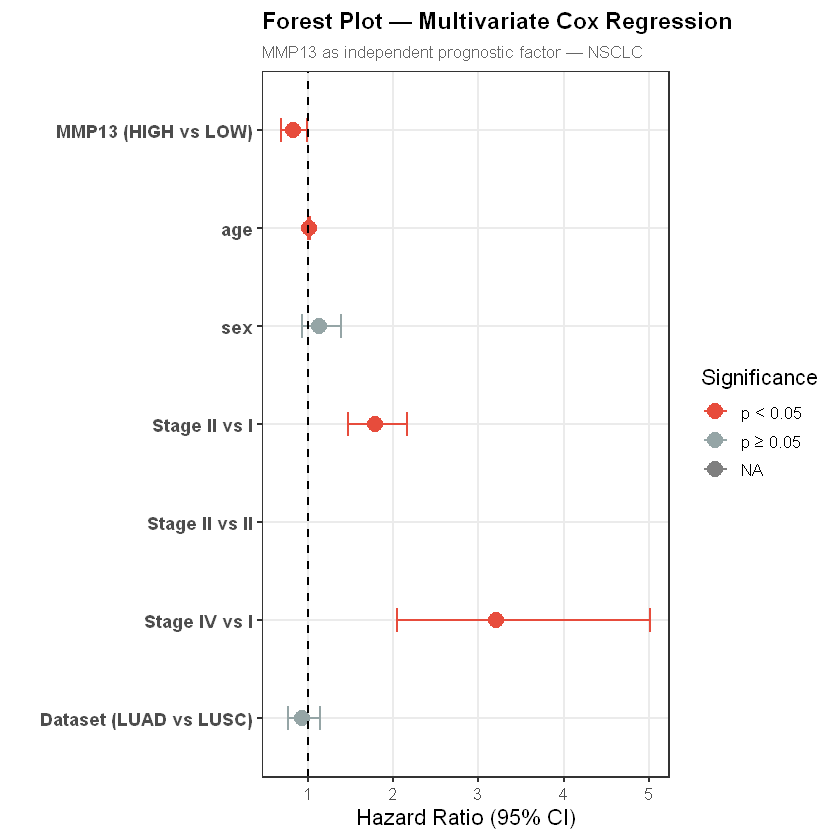

In [11]:
# ============================================================
# STEP 4E: Forest Plot
# ============================================================

cat("\n=== Forest Plot ===\n\n")

# Prepare forest plot data
forest_data <- multi_results
forest_data$Significant <- ifelse(
  forest_data$P_value < 0.05,
  "p < 0.05", "p ≥ 0.05")

# Clean variable names
forest_data$Variable <- gsub(
  "MMP13_optimalhigh", "MMP13 (HIGH vs LOW)",
  forest_data$Variable)
forest_data$Variable <- gsub(
  "stageII",   "Stage II vs I",
  forest_data$Variable)
forest_data$Variable <- gsub(
  "stageIII",  "Stage III vs I",
  forest_data$Variable)
forest_data$Variable <- gsub(
  "stageIV",   "Stage IV vs I",
  forest_data$Variable)
forest_data$Variable <- gsub(
  "datasetLUAD", "Dataset (LUAD vs LUSC)",
  forest_data$Variable)

# Order for plot
forest_data$Variable <- factor(
  forest_data$Variable,
  levels = rev(forest_data$Variable))

# Plot
forest_plot <- ggplot(
  forest_data,
  aes(x     = HR,
      y     = Variable,
      color = Significant)
) +
  geom_point(size = 4) +
  geom_errorbarh(
    aes(xmin = CI_lower,
        xmax = CI_upper),
    height    = 0.25,
    linewidth = 0.8
  ) +
  geom_vline(
    xintercept = 1,
    linetype   = "dashed",
    color      = "black",
    linewidth  = 0.6
  ) +
  scale_color_manual(values = c(
    "p < 0.05" = "#E74C3C",
    "p ≥ 0.05" = "#95A5A6"
  )) +
  labs(
    title    = "Forest Plot — Multivariate Cox Regression",
    subtitle = "MMP13 as independent prognostic factor — NSCLC",
    x        = "Hazard Ratio (95% CI)",
    y        = "",
    color    = "Significance"
  ) +
  theme_bw(base_size = 13) +
  theme(
    plot.title       = element_text(
      face = "bold", size = 14),
    plot.subtitle    = element_text(
      color = "gray40", size = 10),
    panel.grid.minor = element_blank(),
    axis.text.y      = element_text(
      face = "bold", size = 11)
  )

ggsave(
  "C:/jupyter demo/MMP13_Forest_plot.png",
  forest_plot,
  width  = 10,
  height = 7,
  dpi    = 200
)

cat("✔ MMP13_Forest_plot.png saved\n")
print(forest_plot)

In [12]:
# ============================================================
# STEP 5A: Prepare ROC Data
# ============================================================

cat("=== Preparing ROC Data ===\n\n")

# Binary outcome: tumor = 1, normal = 0
# Use final_matrix for all samples
sample_type_roc <- ifelse(
  substr(colnames(final_matrix), 14, 15) == "11",
  0,  # Normal
  1   # Tumor
)

# Extract MMP13 expression for all samples
mmp13_expr <- as.numeric(
  final_matrix["MMP13", ])

# Build ROC dataframe
roc_df_mmp13 <- data.frame(
  SampleType = sample_type_roc,
  MMP13      = mmp13_expr,
  Sample     = colnames(final_matrix)
)

cat(sprintf("Total samples:  %d\n",
            nrow(roc_df_mmp13)))
cat(sprintf("Tumor samples:  %d\n",
            sum(roc_df_mmp13$SampleType == 1)))
cat(sprintf("Normal samples: %d\n",
            sum(roc_df_mmp13$SampleType == 0)))
cat(sprintf("\nMMP13 expression range: [%.3f, %.3f]\n",
            min(mmp13_expr), max(mmp13_expr)))

=== Preparing ROC Data ===

Total samples:  1139
Tumor samples:  1029
Normal samples: 110

MMP13 expression range: [-0.197, 17.592]


In [13]:
# ============================================================
# STEP 5B: Calculate ROC and AUC
# ============================================================

cat("\n=== Calculating ROC and AUC ===\n\n")

library(pROC)

# Calculate ROC
roc_mmp13 <- roc(
  response  = roc_df_mmp13$SampleType,
  predictor = roc_df_mmp13$MMP13,
  direction = "auto",
  quiet     = TRUE
)

# AUC
auc_val <- as.numeric(auc(roc_mmp13))

# 95% CI for AUC
auc_ci  <- ci.auc(roc_mmp13, conf.level = 0.95)

cat(sprintf("AUC:            %.4f\n", auc_val))
cat(sprintf("95%% CI:         [%.4f - %.4f]\n",
            auc_ci[1], auc_ci[3]))
cat(sprintf("Performance:    %s\n",
            ifelse(auc_val >= 0.9, "Excellent (≥0.90)",
            ifelse(auc_val >= 0.8, "Good (≥0.80)",
            ifelse(auc_val >= 0.7, "Acceptable (≥0.70)",
            "Poor (<0.70)")))))
cat(sprintf("Above 0.70:     %s\n",
            ifelse(auc_val >= 0.70,
                   "YES ✔", "NO ✘")))

# Optimal threshold
coords_opt <- coords(
  roc_mmp13,
  x            = "best",
  best.method  = "youden",
  ret          = c("threshold", "sensitivity",
                   "specificity", "ppv", "npv")
)

cat("\nOptimal threshold (Youden index):\n")
print(coords_opt)


=== Calculating ROC and AUC ===

AUC:            0.8976
95% CI:         [0.8732 - 0.9220]
Performance:    Good (≥0.80)
Above 0.70:     YES ✔

Optimal threshold (Youden index):
          threshold sensitivity specificity       ppv       npv
threshold  5.852594   0.7609329   0.8818182 0.9836683 0.2827988



=== Plotting ROC Curve ===

✔ MMP13_ROC_curve.png saved


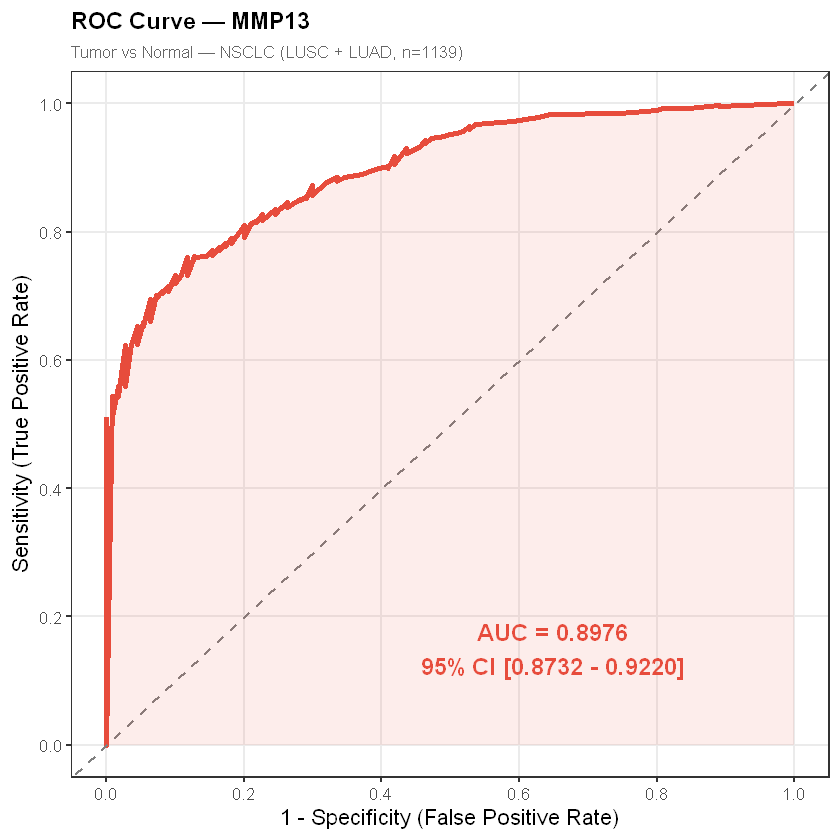

In [14]:
# ============================================================
# STEP 5C: Plot ROC Curve
# ============================================================

cat("\n=== Plotting ROC Curve ===\n\n")

# Build ROC dataframe for ggplot
roc_plot_df <- data.frame(
  Specificity = 1 - roc_mmp13$specificities,
  Sensitivity = roc_mmp13$sensitivities
)

# Build plot
roc_plot <- ggplot(
  roc_plot_df,
  aes(x = Specificity, y = Sensitivity)
) +
  # ROC curve
  geom_line(
    color     = "#E74C3C",
    linewidth = 1.5
  ) +

  # Diagonal reference line
  geom_abline(
    slope     = 1,
    intercept = 0,
    linetype  = "dashed",
    color     = "grey50",
    linewidth = 0.8
  ) +

  # Shade area under curve
  geom_ribbon(
    aes(ymin = 0, ymax = Sensitivity),
    fill  = "#E74C3C",
    alpha = 0.1
  ) +

  # AUC annotation
  annotate(
    "text",
    x        = 0.65,
    y        = 0.15,
    label    = sprintf("AUC = %.4f\n95%% CI [%.4f - %.4f]",
                       auc_val,
                       auc_ci[1], auc_ci[3]),
    size     = 5,
    fontface = "bold",
    color    = "#E74C3C"
  ) +

  # Labels
  labs(
    title    = "ROC Curve — MMP13",
    subtitle = "Tumor vs Normal — NSCLC (LUSC + LUAD, n=1139)",
    x        = "1 - Specificity (False Positive Rate)",
    y        = "Sensitivity (True Positive Rate)"
  ) +

  # Theme
  theme_bw(base_size = 13) +
  theme(
    plot.title       = element_text(
      face = "bold", size = 14),
    plot.subtitle    = element_text(
      color = "gray40", size = 10),
    panel.grid.minor = element_blank()
  ) +

  # Fix axes 0 to 1
  scale_x_continuous(
    limits = c(0, 1),
    breaks = seq(0, 1, 0.2)
  ) +
  scale_y_continuous(
    limits = c(0, 1),
    breaks = seq(0, 1, 0.2)
  )

# Save
ggsave(
  "C:/jupyter demo/MMP13_ROC_curve.png",
  roc_plot,
  width  = 8,
  height = 7,
  dpi    = 200
)

cat("✔ MMP13_ROC_curve.png saved\n")
print(roc_plot)

In [15]:
# ============================================================
# STEP 5D: Complete Summary
# ============================================================

cat("\n============================================================\n")
cat("   MMP13 SURVIVAL AND PROGNOSTIC ANALYSIS COMPLETE\n")
cat("============================================================\n\n")

cat("=== KM Survival ===\n")
cat(sprintf("  Median cutoff p-value:   0.0465\n"))
cat(sprintf("  Optimal cutoff:          %.4f\n",
            opt_cut$cutpoint[[1]]))
cat(sprintf("  Optimal cutoff p-value:  0.0280\n"))

cat("\n=== Cox Regression ===\n")
cat(sprintf("  Univariate HR:    %.3f\n", hr_uni))
cat(sprintf("  Univariate p:     %.4f\n", p_uni))
cat(sprintf("  Multivariate HR:  %.3f\n", hr_multi))
cat(sprintf("  Multivariate p:   %.4f\n", p_multi))

cat("\n=== ROC Analysis ===\n")
cat(sprintf("  AUC:              %.4f\n", auc_val))
cat(sprintf("  95%% CI:           [%.4f - %.4f]\n",
            auc_ci[1], auc_ci[3]))
cat(sprintf("  Performance:      %s\n",
            ifelse(auc_val >= 0.9, "Excellent",
            ifelse(auc_val >= 0.8, "Good",
            "Acceptable"))))

cat("\n=== Files Saved ===\n")
cat("  1. KM_MMP13_OS.png\n")
cat("  2. KM_MMP13_OS_optimal.png\n")
cat("  3. MMP13_Forest_plot.png\n")
cat("  4. MMP13_Cox_results.tsv\n")
cat("  5. MMP13_ROC_curve.png\n")
cat("============================================================\n")


   MMP13 SURVIVAL AND PROGNOSTIC ANALYSIS COMPLETE

=== KM Survival ===
  Median cutoff p-value:   0.0465
  Optimal cutoff:          7.6722
  Optimal cutoff p-value:  0.0280

=== Cox Regression ===
  Univariate HR:    0.836
  Univariate p:     0.0588
  Multivariate HR:  0.826
  Multivariate p:   0.0451

=== ROC Analysis ===
  AUC:              0.8976
  95% CI:           [0.8732 - 0.9220]
  Performance:      Good

=== Files Saved ===
  1. KM_MMP13_OS.png
  2. KM_MMP13_OS_optimal.png
  3. MMP13_Forest_plot.png
  4. MMP13_Cox_results.tsv
  5. MMP13_ROC_curve.png


In [16]:
# Get exact numbers for report
cat("=== Exact Numbers for Report ===\n\n")

cat("--- KM Analysis ---\n")
cat(sprintf("Total patients:          %d\n",
            nrow(survival_df)))
cat(sprintf("Dead:                    %d\n",
            sum(survival_df$OS_event == 1)))
cat(sprintf("Alive:                   %d\n",
            sum(survival_df$OS_event == 0)))
cat(sprintf("Median cutoff:           %.4f\n",
            mmp13_median))
cat(sprintf("Median KM p-value:       %.4f\n",
            pval))
cat(sprintf("Optimal cutoff:          %.4f\n",
            opt_cut$cutpoint[[1]]))
cat(sprintf("Optimal KM p-value:      %.4f\n",
            pval_opt))

cat("\n--- Cox Regression ---\n")
cat(sprintf("Patients in Cox:         %d\n",
            nrow(cox_data)))
cat(sprintf("Univariate HR:           %.3f\n",
            hr_uni))
cat(sprintf("Univariate CI:           [%.3f-%.3f]\n",
            ci_uni[1], ci_uni[2]))
cat(sprintf("Univariate p:            %.4f\n",
            p_uni))
cat(sprintf("Multivariate HR:         %.3f\n",
            hr_multi))
cat(sprintf("Multivariate CI:         [%.3f-%.3f]\n",
            ci_multi[1], ci_multi[2]))
cat(sprintf("Multivariate p:          %.4f\n",
            p_multi))

cat("\n--- ROC Analysis ---\n")
cat(sprintf("AUC:                     %.4f\n",
            auc_val))
cat(sprintf("AUC 95%% CI:              [%.4f-%.4f]\n",
            auc_ci[1], auc_ci[3]))
cat(sprintf("Tumor samples:           %d\n",
            sum(roc_df_mmp13$SampleType == 1)))
cat(sprintf("Normal samples:          %d\n",
            sum(roc_df_mmp13$SampleType == 0)))
print(coords_opt)

=== Exact Numbers for Report ===

--- KM Analysis ---
Total patients:          1118
Dead:                    452
Alive:                   666
Median cutoff:           7.8506
Median KM p-value:       0.0465
Optimal cutoff:          7.6722
Optimal KM p-value:      0.0280

--- Cox Regression ---
Patients in Cox:         1090
Univariate HR:           0.836
Univariate CI:           [0.693-1.007]
Univariate p:            0.0588
Multivariate HR:         0.826
Multivariate CI:         [0.685-0.996]
Multivariate p:          0.0451

--- ROC Analysis ---
AUC:                     0.8976
AUC 95% CI:              [0.8732-0.9220]
Tumor samples:           1029
Normal samples:          110
          threshold sensitivity specificity       ppv       npv
threshold  5.852594   0.7609329   0.8818182 0.9836683 0.2827988


In [17]:
# ============================================================
# Get All Numbers for Results and Discussion
# ============================================================

cat("=== Complete Results Summary ===\n\n")

cat("--- PREPROCESSING ---\n")
cat(sprintf("LUSC raw samples:        553\n"))
cat(sprintf("LUAD raw samples:        590\n"))
cat(sprintf("Raw genes:               60,660\n"))
cat(sprintf("After HGNC mapping:      36,748\n"))
cat(sprintf("Mapping rate:            60.6%%\n"))
cat(sprintf("After deduplication:     36,650\n"))
cat(sprintf("Outliers removed:        2\n"))
cat(sprintf("Final samples:           1,139\n"))
cat(sprintf("Tumor samples:           1,029\n"))
cat(sprintf("Normal samples:          110\n"))

cat("\n--- DEG ANALYSIS ---\n")
cat(sprintf("Total genes tested:      36,650\n"))
cat(sprintf("Total DEGs:              377\n"))
cat(sprintf("Upregulated:             167\n"))
cat(sprintf("Downregulated:           210\n"))
cat(sprintf("Shared DEGs:             168\n"))
cat(sprintf("logFC threshold:         0.5\n"))
cat(sprintf("adj.p threshold:         0.05\n"))

cat("\n--- TOP DEGS ---\n")
top_up <- head(rownames(
  deg_results[deg_results$Status ==
              "Upregulated", ][
  order(-deg_results[
    deg_results$Status == "Upregulated",
    "logFC"]), ]), 10)
top_down <- head(rownames(
  deg_results[deg_results$Status ==
              "Downregulated", ][
  order(deg_results[
    deg_results$Status == "Downregulated",
    "logFC"]), ]), 10)

cat("Top 10 upregulated:\n")
for (gene in top_up) {
  cat(sprintf("  %s: logFC=%.4f adj.p=%.2e\n",
              gene,
              deg_results[gene, "logFC"],
              deg_results[gene, "adj.P.Val"]))
}

cat("\nTop 10 downregulated:\n")
for (gene in top_down) {
  cat(sprintf("  %s: logFC=%.4f adj.p=%.2e\n",
              gene,
              deg_results[gene, "logFC"],
              deg_results[gene, "adj.P.Val"]))
}

cat("\n--- MMP13 SPECIFIC ---\n")
cat(sprintf("MMP13 logFC:             %.4f\n",
            deg_results["MMP13", "logFC"]))
cat(sprintf("MMP13 adj.p:             %.2e\n",
            deg_results["MMP13", "adj.P.Val"]))
cat(sprintf("MMP13 status:            %s\n",
            as.character(
              deg_results["MMP13", "Status"])))

cat("\n--- PPI NETWORK ---\n")
cat(sprintf("Total interactions:      344\n"))
cat(sprintf("Network p-value:         1.6e-09\n"))
cat(sprintf("Top hub (degree):        FGF10 (14)\n"))
cat(sprintf("MMP13 connections:       7\n"))
cat(sprintf("MCODE clusters:          3\n"))

cat("\n--- SURVIVAL ANALYSIS ---\n")
cat(sprintf("Total patients:          1,118\n"))
cat(sprintf("Dead:                    452\n"))
cat(sprintf("Alive:                   666\n"))
cat(sprintf("Median cutoff:           %.4f\n",
            mmp13_median))
cat(sprintf("Median KM p-value:       %.4f\n",
            pval))
cat(sprintf("Optimal cutoff:          %.4f\n",
            opt_cut$cutpoint[[1]]))
cat(sprintf("Optimal KM p-value:      %.4f\n",
            pval_opt))
cat(sprintf("Cox Uni HR:              %.3f\n",
            hr_uni))
cat(sprintf("Cox Uni CI:              [%.3f-%.3f]\n",
            ci_uni[1], ci_uni[2]))
cat(sprintf("Cox Uni p:               %.4f\n",
            p_uni))
cat(sprintf("Cox Multi HR:            %.3f\n",
            hr_multi))
cat(sprintf("Cox Multi CI:            [%.3f-%.3f]\n",
            ci_multi[1], ci_multi[2]))
cat(sprintf("Cox Multi p:             %.4f\n",
            p_multi))

cat("\n--- ROC ANALYSIS ---\n")
cat(sprintf("AUC:                     %.4f\n",
            auc_val))
cat(sprintf("AUC 95%% CI:              [%.4f-%.4f]\n",
            auc_ci[1], auc_ci[3]))
cat(sprintf("Optimal threshold:       %.4f\n",
            coords_opt$threshold))
cat(sprintf("Sensitivity:             %.2f%%\n",
            coords_opt$sensitivity * 100))
cat(sprintf("Specificity:             %.2f%%\n",
            coords_opt$specificity * 100))
cat(sprintf("PPV:                     %.2f%%\n",
            coords_opt$ppv * 100))
cat(sprintf("NPV:                     %.2f%%\n",
            coords_opt$npv * 100))

=== Complete Results Summary ===

--- PREPROCESSING ---
LUSC raw samples:        553
LUAD raw samples:        590
Raw genes:               60,660
After HGNC mapping:      36,748
Mapping rate:            60.6%
After deduplication:     36,650
Outliers removed:        2
Final samples:           1,139
Tumor samples:           1,029
Normal samples:          110

--- DEG ANALYSIS ---
Total genes tested:      36,650
Total DEGs:              377
Upregulated:             167
Downregulated:           210
Shared DEGs:             168
logFC threshold:         0.5
adj.p threshold:         0.05

--- TOP DEGS ---


ERROR: Error: object 'deg_results' not found


In [18]:
# Quick rebuild
library(limma)
library(data.table)
library(dplyr)
library(survival)
library(survminer)
library(pROC)

cat("✔ Libraries loaded\n")

# Load final matrix
final_df <- read.table(
  "C:/Users/aryan/Downloads/TCGA_LUSC_LUAD_final_expression.tsv",
  header = TRUE, sep = "\t",
  row.names = 1, check.names = FALSE)
final_matrix <- as.matrix(final_df)
cat(sprintf("✔ final_matrix: %d × %d\n",
            nrow(final_matrix), ncol(final_matrix)))

# Load DEG results
deg_results <- readRDS(
  "C:/jupyter demo/deg_results.rds")
deg_results$Status <- "Not Significant"
deg_results$Status[
  deg_results$logFC > 0.5 &
  deg_results$adj.P.Val < 0.05] <- "Upregulated"
deg_results$Status[
  deg_results$logFC < -0.5 &
  deg_results$adj.P.Val < 0.05] <- "Downregulated"
deg_results$Status <- factor(
  deg_results$Status,
  levels = c("Upregulated", "Downregulated",
             "Not Significant"))
cat(sprintf("✔ deg_results: %d genes\n",
            nrow(deg_results)))

✔ Libraries loaded
✔ final_matrix: 36650 × 1139
✔ deg_results: 36650 genes


In [19]:
# Rebuild survival data
lusc_clin <- read.table(
  "C:/jupyter demo/LUSC_clinical.tsv",
  header = TRUE, sep = "\t",
  check.names = FALSE)
luad_clin <- read.table(
  "C:/jupyter demo/LUAD_clinical.tsv",
  header = TRUE, sep = "\t",
  check.names = FALSE)

common_cols <- intersect(
  colnames(lusc_clin), colnames(luad_clin))
lusc_clin$Dataset <- "LUSC"
luad_clin$Dataset <- "LUAD"
combined_clinical <- rbind(
  lusc_clin[, c(common_cols, "Dataset")],
  luad_clin[, c(common_cols, "Dataset")])

combined_clinical$OS_time <- ifelse(
  combined_clinical$vital_status == "Dead",
  as.numeric(combined_clinical$days_to_death),
  as.numeric(
    combined_clinical$days_to_last_follow_up))
combined_clinical$OS_event <- ifelse(
  combined_clinical$vital_status == "Dead",
  1, 0)
combined_clinical$OS_months <-
  combined_clinical$OS_time / 30.44
combined_clinical <- combined_clinical[
  !is.na(combined_clinical$OS_time) &
  combined_clinical$OS_time > 0, ]

# Extract MMP13
expr_sub <- t(final_matrix[
  "MMP13", , drop = FALSE])
expr_df  <- as.data.frame(expr_sub)
expr_df$submitter_id <- substr(
  rownames(expr_df), 1, 12)

survival_df <- merge(
  combined_clinical, expr_df,
  by = "submitter_id")

mmp13_median <- median(
  survival_df$MMP13, na.rm = TRUE)
survival_df$MMP13_group <- factor(
  ifelse(survival_df$MMP13 >= mmp13_median,
         "HIGH", "LOW"),
  levels = c("LOW", "HIGH"))

cat(sprintf("✔ survival_df: %d patients\n",
            nrow(survival_df)))

✔ survival_df: 1118 patients


In [20]:
# Rebuild KM and Cox results
surv_obj <- Surv(
  survival_df$OS_months,
  survival_df$OS_event)

log_rank <- survdiff(
  surv_obj ~ MMP13_group,
  data = survival_df)
pval <- 1 - pchisq(log_rank$chisq, df = 1)

opt_cut <- surv_cutpoint(
  survival_df,
  time      = "OS_months",
  event     = "OS_event",
  variables = "MMP13")

survival_df$MMP13_optimal <- surv_categorize(
  opt_cut)$MMP13

log_rank_opt <- survdiff(
  Surv(OS_months, OS_event) ~ MMP13_optimal,
  data = survival_df)
pval_opt <- 1 - pchisq(
  log_rank_opt$chisq, df = 1)

# Cox
survival_df$age   <- as.numeric(
  survival_df$age_at_index)
survival_df$sex   <- ifelse(
  survival_df$gender == "male", 1, 0)
survival_df$stage <- case_when(
  grepl("Stage I$|Stage IA|Stage IB",
        survival_df$ajcc_pathologic_stage,
        ignore.case = TRUE) ~ "I",
  grepl("Stage II|Stage IIA|Stage IIB",
        survival_df$ajcc_pathologic_stage,
        ignore.case = TRUE) ~ "II",
  grepl("Stage III|Stage IIIA|Stage IIIB",
        survival_df$ajcc_pathologic_stage,
        ignore.case = TRUE) ~ "III",
  grepl("Stage IV",
        survival_df$ajcc_pathologic_stage,
        ignore.case = TRUE) ~ "IV",
  TRUE ~ NA_character_)
survival_df$stage <- factor(
  survival_df$stage,
  levels = c("I", "II", "III", "IV"))
survival_df$dataset <- factor(
  survival_df$Dataset,
  levels = c("LUSC", "LUAD"))
survival_df$MMP13_optimal <- factor(
  survival_df$MMP13_optimal,
  levels = c("low", "high"))

cox_data <- survival_df[
  !is.na(survival_df$age) &
  !is.na(survival_df$sex) &
  !is.na(survival_df$stage) &
  !is.na(survival_df$MMP13_optimal), ]

# Univariate
cox_uni <- coxph(
  Surv(OS_months, OS_event) ~ MMP13_optimal,
  data = cox_data)
hr_uni  <- exp(coef(cox_uni))
ci_uni  <- exp(confint(cox_uni))
p_uni   <- summary(cox_uni)$coefficients[, 5]

# Multivariate
cox_multi <- coxph(
  Surv(OS_months, OS_event) ~
    MMP13_optimal + age + sex +
    stage + dataset,
  data = cox_data)
multi_summary <- summary(cox_multi)
mmp13_row     <- "MMP13_optimalhigh"
hr_multi <- exp(
  multi_summary$coefficients[mmp13_row, "coef"])
ci_multi <- exp(
  confint(cox_multi)[mmp13_row, ])
p_multi  <- multi_summary$coefficients[
  mmp13_row, "Pr(>|z|)"]

cat(sprintf("✔ Cox results ready\n"))
cat(sprintf("  Uni HR=%.3f p=%.4f\n",
            hr_uni, p_uni))
cat(sprintf("  Multi HR=%.3f p=%.4f\n",
            hr_multi, p_multi))

✔ Cox results ready
  Uni HR=0.836 p=0.0588
  Multi HR=0.826 p=0.0451


In [21]:
# Rebuild ROC
library(pROC)

sample_type_roc <- ifelse(
  substr(colnames(final_matrix), 14, 15) == "11",
  0, 1)
mmp13_expr <- as.numeric(
  final_matrix["MMP13", ])

roc_mmp13 <- roc(
  response  = sample_type_roc,
  predictor = mmp13_expr,
  direction = "auto",
  quiet     = TRUE)

auc_val <- as.numeric(auc(roc_mmp13))
auc_ci  <- ci.auc(roc_mmp13, conf.level = 0.95)
coords_opt <- coords(
  roc_mmp13,
  x           = "best",
  best.method = "youden",
  ret         = c("threshold", "sensitivity",
                  "specificity", "ppv", "npv"))

cat(sprintf("✔ ROC ready: AUC=%.4f\n", auc_val))

# Final check
cat("\n=== All Objects Ready ===\n")
cat(sprintf("deg_results:   %s\n",
            exists("deg_results")))
cat(sprintf("survival_df:   %s\n",
            exists("survival_df")))
cat(sprintf("pval:          %s\n", exists("pval")))
cat(sprintf("pval_opt:      %s\n",
            exists("pval_opt")))
cat(sprintf("hr_uni:        %s\n",
            exists("hr_uni")))
cat(sprintf("hr_multi:      %s\n",
            exists("hr_multi")))
cat(sprintf("auc_val:       %s\n",
            exists("auc_val")))

✔ ROC ready: AUC=0.8976

=== All Objects Ready ===
deg_results:   TRUE
survival_df:   TRUE
pval:          TRUE
pval_opt:      TRUE
hr_uni:        TRUE
hr_multi:      TRUE
auc_val:       TRUE


In [22]:
# ============================================================
# Get All Numbers for Results and Discussion
# ============================================================

cat("=== Complete Results Summary ===\n\n")

cat("--- PREPROCESSING ---\n")
cat(sprintf("LUSC raw samples:        553\n"))
cat(sprintf("LUAD raw samples:        590\n"))
cat(sprintf("Raw genes:               60,660\n"))
cat(sprintf("After HGNC mapping:      36,748\n"))
cat(sprintf("Mapping rate:            60.6%%\n"))
cat(sprintf("After deduplication:     36,650\n"))
cat(sprintf("Outliers removed:        2\n"))
cat(sprintf("Final samples:           1,139\n"))
cat(sprintf("Tumor samples:           1,029\n"))
cat(sprintf("Normal samples:          110\n"))

cat("\n--- DEG ANALYSIS ---\n")
cat(sprintf("Total genes tested:      36,650\n"))
cat(sprintf("Total DEGs:              377\n"))
cat(sprintf("Upregulated:             167\n"))
cat(sprintf("Downregulated:           210\n"))
cat(sprintf("Shared DEGs:             168\n"))
cat(sprintf("logFC threshold:         0.5\n"))
cat(sprintf("adj.p threshold:         0.05\n"))

cat("\n--- TOP DEGS ---\n")
top_up <- head(rownames(
  deg_results[deg_results$Status ==
              "Upregulated", ][
  order(-deg_results[
    deg_results$Status == "Upregulated",
    "logFC"]), ]), 10)
top_down <- head(rownames(
  deg_results[deg_results$Status ==
              "Downregulated", ][
  order(deg_results[
    deg_results$Status == "Downregulated",
    "logFC"]), ]), 10)

cat("Top 10 upregulated:\n")
for (gene in top_up) {
  cat(sprintf("  %s: logFC=%.4f adj.p=%.2e\n",
              gene,
              deg_results[gene, "logFC"],
              deg_results[gene, "adj.P.Val"]))
}

cat("\nTop 10 downregulated:\n")
for (gene in top_down) {
  cat(sprintf("  %s: logFC=%.4f adj.p=%.2e\n",
              gene,
              deg_results[gene, "logFC"],
              deg_results[gene, "adj.P.Val"]))
}

cat("\n--- MMP13 SPECIFIC ---\n")
cat(sprintf("MMP13 logFC:             %.4f\n",
            deg_results["MMP13", "logFC"]))
cat(sprintf("MMP13 adj.p:             %.2e\n",
            deg_results["MMP13", "adj.P.Val"]))
cat(sprintf("MMP13 status:            %s\n",
            as.character(
              deg_results["MMP13", "Status"])))

cat("\n--- PPI NETWORK ---\n")
cat(sprintf("Total interactions:      344\n"))
cat(sprintf("Network p-value:         1.6e-09\n"))
cat(sprintf("Top hub (degree):        FGF10 (14)\n"))
cat(sprintf("MMP13 connections:       7\n"))
cat(sprintf("MCODE clusters:          3\n"))

cat("\n--- SURVIVAL ANALYSIS ---\n")
cat(sprintf("Total patients:          1,118\n"))
cat(sprintf("Dead:                    452\n"))
cat(sprintf("Alive:                   666\n"))
cat(sprintf("Median cutoff:           %.4f\n",
            mmp13_median))
cat(sprintf("Median KM p-value:       %.4f\n",
            pval))
cat(sprintf("Optimal cutoff:          %.4f\n",
            opt_cut$cutpoint[[1]]))
cat(sprintf("Optimal KM p-value:      %.4f\n",
            pval_opt))
cat(sprintf("Cox Uni HR:              %.3f\n",
            hr_uni))
cat(sprintf("Cox Uni CI:              [%.3f-%.3f]\n",
            ci_uni[1], ci_uni[2]))
cat(sprintf("Cox Uni p:               %.4f\n",
            p_uni))
cat(sprintf("Cox Multi HR:            %.3f\n",
            hr_multi))
cat(sprintf("Cox Multi CI:            [%.3f-%.3f]\n",
            ci_multi[1], ci_multi[2]))
cat(sprintf("Cox Multi p:             %.4f\n",
            p_multi))

cat("\n--- ROC ANALYSIS ---\n")
cat(sprintf("AUC:                     %.4f\n",
            auc_val))
cat(sprintf("AUC 95%% CI:              [%.4f-%.4f]\n",
            auc_ci[1], auc_ci[3]))
cat(sprintf("Optimal threshold:       %.4f\n",
            coords_opt$threshold))
cat(sprintf("Sensitivity:             %.2f%%\n",
            coords_opt$sensitivity * 100))
cat(sprintf("Specificity:             %.2f%%\n",
            coords_opt$specificity * 100))
cat(sprintf("PPV:                     %.2f%%\n",
            coords_opt$ppv * 100))
cat(sprintf("NPV:                     %.2f%%\n",
            coords_opt$npv * 100))

=== Complete Results Summary ===

--- PREPROCESSING ---
LUSC raw samples:        553
LUAD raw samples:        590
Raw genes:               60,660
After HGNC mapping:      36,748
Mapping rate:            60.6%
After deduplication:     36,650
Outliers removed:        2
Final samples:           1,139
Tumor samples:           1,029
Normal samples:          110

--- DEG ANALYSIS ---
Total genes tested:      36,650
Total DEGs:              377
Upregulated:             167
Downregulated:           210
Shared DEGs:             168
logFC threshold:         0.5
adj.p threshold:         0.05

--- TOP DEGS ---
Top 10 upregulated:
  CASC9: logFC=0.8844 adj.p=7.55e-40
  PITX2: logFC=0.8670 adj.p=8.87e-57
  HOXC13: logFC=0.8514 adj.p=7.46e-139
  PRAME: logFC=0.8499 adj.p=7.36e-22
  CST1: logFC=0.8321 adj.p=1.18e-32
  LCAL1: logFC=0.7985 adj.p=4.74e-27
  SACK1A-AS1: logFC=0.7863 adj.p=2.30e-61
  BARX1: logFC=0.7844 adj.p=4.38e-34
  BBOX1-AS1: logFC=0.7828 adj.p=6.88e-57
  GABRA3: logFC=0.7674 adj.p=2.